# Tufa Labs ARC3 submission

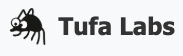

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["jeroencottaar/taaf-kaggle-source-share", "driessmit1/arc3-vllm-h100-wheelhouse-v3", "driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
for command in json.loads((BUNDLE_DIR / "setup_commands.json").read_text()):
    print(f"taaf.kaggle: setup command: {command}", flush=True)
    subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
    # Re-read in case the command persisted new env keys.
    env = _command_env()
    os.environ.update(env)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

In [ ]:
import base64, json, sys
from pathlib import Path
ROOT = Path('/kaggle/working/ewm'); ROOT.mkdir(parents=True, exist_ok=True)
for rel, b64 in json.loads('{"src/server/server.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKZnJvbSBjb3B5IGltcG9ydCBkZWVwY29weQpmcm9tIGRhdGFjbGFzc2VzIGltcG9ydCBkYXRhY2xhc3MKZnJvbSBkYXRldGltZSBpbXBvcnQgZGF0ZXRpbWUsIHRpbWV6b25lCmltcG9ydCBqc29uCmltcG9ydCBsb2dnaW5nCmltcG9ydCBvcwpmcm9tIHBhdGhsaWIgaW1wb3J0IFBhdGgKaW1wb3J0IHN5cwpmcm9tIHRocmVhZGluZyBpbXBvcnQgUkxvY2sKZnJvbSB0eXBpbmcgaW1wb3J0IEFueQpmcm9tIHV1aWQgaW1wb3J0IHV1aWQ0Cgpmcm9tIGZsYXNrIGltcG9ydCBGbGFzaywganNvbmlmeSwgcmVxdWVzdApmcm9tIHdlcmt6ZXVnLmV4Y2VwdGlvbnMgaW1wb3J0IEhUVFBFeGNlcHRpb24KCmZyb20gYXJjX2FnaSBpbXBvcnQgQXJjYWRlLCBPcGVyYXRpb25Nb2RlCmZyb20gYXJjZW5naW5lIGltcG9ydCBHYW1lQWN0aW9uCgojIFBBVEgtQiBsb2NhbCBhZGFwdGF0aW9uOiB3aGVuIEFSQ19PRkZMSU5FX0RJUiBpcyBzZXQsIHNlcnZlIHRoZSBsb2NhbCBkZXYgZ2FtZXMKIyAoZW52aXJvbm1lbnRfZmlsZXMpIHZpYSBhbiBPRkZMSU5FIEFyY2FkZSBpbnN0ZWFkIG9mIHRoZSByZW1vdGUvZGVmYXVsdCBiYWNrZW5kLgpBUkNfT0ZGTElORV9ESVIgPSBvcy5lbnZpcm9uLmdldCgiQVJDX09GRkxJTkVfRElSIikKCgpkZWYgX21ha2VfYXJjYWRlKCkgLT4gQXJjYWRlOgogICAgaWYgQVJDX09GRkxJTkVfRElSOgogICAgICAgIHJldHVybiBBcmNhZGUob3BlcmF0aW9uX21vZGU9T3BlcmF0aW9uTW9kZS5PRkZMSU5FLCBlbnZpcm9ubWVudHNfZGlyPUFSQ19PRkZMSU5FX0RJUikKICAgIHJldHVybiBBcmNhZGUoKQoKU0VSVkVSX0hPU1QgPSBvcy5lbnZpcm9uLmdldCgiQVJDX1NFUlZFUl9IT1NUIiwgIjEyNy4wLjAuMSIpClNFUlZFUl9QT1JUID0gaW50KG9zLmVudmlyb24uZ2V0KCJBUkNfU0VSVkVSX1BPUlQiLCAiODg3OCIpKQpTRVJWRVJfTE9HX1BBVEggPSBQYXRoKG9zLmVudmlyb24uZ2V0KCJBUkNfU0VSVkVSX0xPR19QQVRIIiwgInNlcnZlci5sb2ciKSkKCkFQUCA9IEZsYXNrKF9fbmFtZV9fKQpMT0dHRVIgPSBsb2dnaW5nLmdldExvZ2dlcigiYXJjLXNlcnZlciIpClVOS05PV05fT1JfVVNFRF9HQU1FX0lEX0VSUk9SID0gInVua25vd24gb3IgYWxyZWFkeSB1c2VkIGdhbWVfaWQiCgoKZGVmIGxvYWRfZ2FtZV9pZF9tYXBwaW5nKCkgLT4gZGljdFtzdHIsIHN0cl06CiAgICByYXdfbWFwcGluZyA9IG9zLmVudmlyb24uZ2V0KCJHQU1FX0lEX01BUFBJTkdfSlNPTiIpCiAgICBpZiBub3QgcmF3X21hcHBpbmc6CiAgICAgICAgcmFpc2UgUnVudGltZUVycm9yKCJHQU1FX0lEX01BUFBJTkdfSlNPTiBpcyByZXF1aXJlZCIpCiAgICB0cnk6CiAgICAgICAgbG9hZGVkX21hcHBpbmcgPSBqc29uLmxvYWRzKHJhd19tYXBwaW5nKQogICAgZXhjZXB0IGpzb24uSlNPTkRlY29kZUVycm9yIGFzIGV4YzoKICAgICAgICByYWlzZSBSdW50aW1lRXJyb3IoIkdBTUVfSURfTUFQUElOR19KU09OIG11c3QgYmUgdmFsaWQgSlNPTiIpIGZyb20gZXhjCiAgICBpZiBub3QgaXNpbnN0YW5jZShsb2FkZWRfbWFwcGluZywgZGljdCkgb3Igbm90IGxvYWRlZF9tYXBwaW5nOgogICAgICAgIHJhaXNlIFJ1bnRpbWVFcnJvcigiR0FNRV9JRF9NQVBQSU5HX0pTT04gbXVzdCBiZSBhIG5vbi1lbXB0eSBvYmplY3QiKQogICAgbWFwcGluZzogZGljdFtzdHIsIHN0cl0gPSB7fQogICAgZm9yIGFsaWFzLCBnYW1lX2lkIGluIGxvYWRlZF9tYXBwaW5nLml0ZW1zKCk6CiAgICAgICAgaWYgbm90IGlzaW5zdGFuY2UoYWxpYXMsIHN0cikgb3Igbm90IGFsaWFzLnN0cmlwKCk6CiAgICAgICAgICAgIHJhaXNlIFJ1bnRpbWVFcnJvcigiR0FNRV9JRF9NQVBQSU5HX0pTT04ga2V5cyBtdXN0IGJlIG5vbi1lbXB0eSBzdHJpbmdzIikKICAgICAgICBpZiBub3QgaXNpbnN0YW5jZShnYW1lX2lkLCBzdHIpIG9yIG5vdCBnYW1lX2lkLnN0cmlwKCk6CiAgICAgICAgICAgIHJhaXNlIFJ1bnRpbWVFcnJvcigiR0FNRV9JRF9NQVBQSU5HX0pTT04gdmFsdWVzIG11c3QgYmUgbm9uLWVtcHR5IHN0cmluZ3MiKQogICAgICAgIG1hcHBpbmdbYWxpYXNdID0gZ2FtZV9pZAogICAgcmV0dXJuIG1hcHBpbmcKCgpHQU1FX0lEX01BUFBJTkcgPSBsb2FkX2dhbWVfaWRfbWFwcGluZygpCkdBTUVfSURfTUFQUElOR19MT0NLID0gUkxvY2soKQoKCmRlZiBzZXR1cF9sb2dnaW5nKGxvZ19wYXRoOiBQYXRoKSAtPiBOb25lOgogICAgaWYgbG9nX3BhdGguZXhpc3RzKCk6CiAgICAgICAgcmFpc2UgRmlsZUV4aXN0c0Vycm9yKGYiUmVmdXNpbmcgdG8gc3RhcnQgYmVjYXVzZSBsb2cgZmlsZSBhbHJlYWR5IGV4aXN0czoge2xvZ19wYXRofSIpCiAgICBsb2dfcGF0aC5wYXJlbnQubWtkaXIocGFyZW50cz1UcnVlLCBleGlzdF9vaz1UcnVlKQoKICAgIGZvcm1hdHRlciA9IGxvZ2dpbmcuRm9ybWF0dGVyKAogICAgICAgICIlKGFzY3RpbWUpcyAlKGxldmVsbmFtZSlzIFslKHRocmVhZE5hbWUpc10gJShuYW1lKXM6ICUobWVzc2FnZSlzIiwKICAgICAgICBkYXRlZm10PSIlWS0lbS0lZFQlSDolTTolUyV6IiwKICAgICkKICAgIGZpbGVfaGFuZGxlciA9IGxvZ2dpbmcuRmlsZUhhbmRsZXIobG9nX3BhdGgsIG1vZGU9IngiLCBlbmNvZGluZz0idXRmLTgiKQogICAgZmlsZV9oYW5kbGVyLnNldEZvcm1hdHRlcihmb3JtYXR0ZXIpCiAgICBzdHJlYW1faGFuZGxlciA9IGxvZ2dpbmcuU3RyZWFtSGFuZGxlcihzeXMuc3RkZXJyKQogICAgc3RyZWFtX2hhbmRsZXIuc2V0Rm9ybWF0dGVyKGZvcm1hdHRlcikKCiAgICByb290X2xvZ2dlciA9IGxvZ2dpbmcuZ2V0TG9nZ2VyKCkKICAgIHJvb3RfbG9nZ2VyLmhhbmRsZXJzLmNsZWFyKCkKICAgIHJvb3RfbG9nZ2VyLnNldExldmVsKGxvZ2dpbmcuSU5GTykKICAgIHJvb3RfbG9nZ2VyLmFkZEhhbmRsZXIoZmlsZV9oYW5kbGVyKQogICAgcm9vdF9sb2dnZXIuYWRkSGFuZGxlcihzdHJlYW1faGFuZGxlcikKCiAgICBBUFAubG9nZ2VyLmhhbmRsZXJzLmNsZWFyKCkKICAgIEFQUC5sb2dnZXIucHJvcGFnYXRlID0gVHJ1ZQogICAgbG9nZ2luZy5nZXRMb2dnZXIoIndlcmt6ZXVnIikuc2V0TGV2ZWwobG9nZ2luZy5JTkZPKQoKCkBBUFAuYmVmb3JlX3JlcXVlc3QKZGVmIGxvZ19yZXF1ZXN0KCkgLT4gTm9uZToKICAgIExPR0dFUi5pbmZvKCIlcyAlcyBmcm9tICVzIiwgcmVxdWVzdC5tZXRob2QsIHJlcXVlc3QucGF0aCwgcmVxdWVzdC5yZW1vdGVfYWRkcikKCgpAQVBQLmFmdGVyX3JlcXVlc3QKZGVmIGxvZ19yZXNwb25zZShyZXNwb25zZTogQW55KSAtPiBBbnk6CiAgICBpZiByZXNwb25zZS5zdGF0dXNfY29kZSA+PSA1MDA6CiAgICAgICAgTE9HR0VSLmVycm9yKCIlcyAlcyAtPiAlcyIsIHJlcXVlc3QubWV0aG9kLCByZXF1ZXN0LnBhdGgsIHJlc3BvbnNlLnN0YXR1cykKICAgIGVsaWYgcmVzcG9uc2Uuc3RhdHVzX2NvZGUgPj0gNDAwOgogICAgICAgIExPR0dFUi53YXJuaW5nKCIlcyAlcyAtPiAlcyIsIHJlcXVlc3QubWV0aG9kLCByZXF1ZXN0LnBhdGgsIHJlc3BvbnNlLnN0YXR1cykKICAgIHJldHVybiByZXNwb25zZQoKCkBBUFAuZXJyb3JoYW5kbGVyKEV4Y2VwdGlvbikKZGVmIGxvZ191bmhhbmRsZWRfZXhjZXB0aW9uKGV4YzogRXhjZXB0aW9uKSAtPiBBbnk6CiAgICBpZiBpc2luc3RhbmNlKGV4YywgSFRUUEV4Y2VwdGlvbik6CiAgICAgICAgcmV0dXJuIGV4YwogICAgTE9HR0VSLmV4Y2VwdGlvbigiVW5oYW5kbGVkIGV4Y2VwdGlvbiB3aGlsZSBoYW5kbGluZyAlcyAlcyIsIHJlcXVlc3QubWV0aG9kLCByZXF1ZXN0LnBhdGgpCiAgICByZXR1cm4ganNvbmlmeSh7ImVycm9yIjogcmVwcihleGMpfSksIDUwMAoKCmRlZiBzZXJpYWxpemVfYWN0aW9uX2lucHV0KGZyYW1lX2RhdGE6IEFueSkgLT4gZGljdFtzdHIsIEFueV0gfCBOb25lOgogICAgaWYgZnJhbWVfZGF0YS5hY3Rpb25faW5wdXQgaXMgTm9uZToKICAgICAgICByZXR1cm4gTm9uZQogICAgcmV0dXJuIHsKICAgICAgICAiaWQiOiBmcmFtZV9kYXRhLmFjdGlvbl9pbnB1dC5pZC5uYW1lCiAgICAgICAgaWYgaGFzYXR0cihmcmFtZV9kYXRhLmFjdGlvbl9pbnB1dC5pZCwgIm5hbWUiKQogICAgICAgIGVsc2Ugc3RyKGZyYW1lX2RhdGEuYWN0aW9uX2lucHV0LmlkKSwKICAgICAgICAiZGF0YSI6IGZyYW1lX2RhdGEuYWN0aW9uX2lucHV0LmRhdGEsCiAgICB9CgoKZGVmIHNlcmlhbGl6ZV9mcmFtZShmcmFtZV9kYXRhOiBBbnksIHN0ZXBfaW5kZXg6IGludCkgLT4gZGljdFtzdHIsIEFueV06CiAgICBmcmFtZV9sYXllcnMgPSBbXQogICAgZm9yIGZyYW1lIGluIGZyYW1lX2RhdGEuZnJhbWU6CiAgICAgICAgZnJhbWVfbGF5ZXJzLmFwcGVuZChmcmFtZS50b2xpc3QoKSBpZiBoYXNhdHRyKGZyYW1lLCAidG9saXN0IikgZWxzZSBmcmFtZSkKCiAgICByZXR1cm4gewogICAgICAgICJzdGVwX2luZGV4Ijogc3RlcF9pbmRleCwKICAgICAgICAic3RhdGUiOiBmcmFtZV9kYXRhLnN0YXRlLm5hbWUgaWYgaGFzYXR0cihmcmFtZV9kYXRhLnN0YXRlLCAibmFtZSIpIGVsc2Ugc3RyKGZyYW1lX2RhdGEuc3RhdGUpLAogICAgICAgICJsZXZlbHNfY29tcGxldGVkIjogZnJhbWVfZGF0YS5sZXZlbHNfY29tcGxldGVkLAogICAgICAgICJ3aW5fbGV2ZWxzIjogZnJhbWVfZGF0YS53aW5fbGV2ZWxzLAogICAgICAgICJhdmFpbGFibGVfYWN0aW9ucyI6IGZyYW1lX2RhdGEuYXZhaWxhYmxlX2FjdGlvbnMsCiAgICAgICAgImFjdGlvbl9pbnB1dCI6IHNlcmlhbGl6ZV9hY3Rpb25faW5wdXQoZnJhbWVfZGF0YSksCiAgICAgICAgImZyYW1lIjogZnJhbWVfbGF5ZXJzLAogICAgfQoKCkBkYXRhY2xhc3MKY2xhc3MgU2VydmVyU2Vzc2lvbjoKICAgIHRva2VuOiBzdHIKICAgIGFyY2FkZTogQXJjYWRlCiAgICBlbnY6IEFueQogICAgcmVxdWVzdGVkX2dhbWVfaWQ6IHN0cgogICAgc3RhcnRlZF9hdDogc3RyCiAgICBzdGVwX2luZGV4OiBpbnQgPSAwCiAgICBsYXN0X3N0ZXBfcGF5bG9hZDogZGljdFtzdHIsIEFueV0gfCBOb25lID0gTm9uZQogICAgbG9jazogUkxvY2sgfCBOb25lID0gTm9uZQoKClNFU1NJT05TOiBkaWN0W3N0ciwgU2VydmVyU2Vzc2lvbl0gPSB7fQpTRVNTSU9OU19MT0NLID0gUkxvY2soKQoKCmRlZiBzZXNzaW9uX3Rva2VuX2Zyb21fcmVxdWVzdChwYXlsb2FkOiBkaWN0W3N0ciwgQW55XSB8IE5vbmUgPSBOb25lKSAtPiBzdHI6CiAgICBoZWFkZXJfdG9rZW4gPSByZXF1ZXN0LmhlYWRlcnMuZ2V0KCJYLVNlc3Npb24tVG9rZW4iKQogICAgaWYgaGVhZGVyX3Rva2VuOgogICAgICAgIHJldHVybiBoZWFkZXJfdG9rZW4uc3RyaXAoKQogICAgaWYgcGF5bG9hZCBpcyBub3QgTm9uZToKICAgICAgICBib2R5X3Rva2VuID0gcGF5bG9hZC5nZXQoInNlc3Npb25fdG9rZW4iKQogICAgICAgIGlmIGJvZHlfdG9rZW4gaXMgbm90IE5vbmU6CiAgICAgICAgICAgIHJldHVybiBzdHIoYm9keV90b2tlbikuc3RyaXAoKQogICAgcXVlcnlfdG9rZW4gPSByZXF1ZXN0LmFyZ3MuZ2V0KCJzZXNzaW9uX3Rva2VuIiwgIiIpLnN0cmlwKCkKICAgIHJldHVybiBxdWVyeV90b2tlbgoKCmRlZiByZXF1aXJlX3Nlc3Npb24oc2Vzc2lvbl90b2tlbjogc3RyKSAtPiBTZXJ2ZXJTZXNzaW9uOgogICAgaWYgbm90IHNlc3Npb25fdG9rZW46CiAgICAgICAgcmFpc2UgUnVudGltZUVycm9yKCJzZXNzaW9uX3Rva2VuIGlzIHJlcXVpcmVkLiBTdGFydCBhIHNlc3Npb24gZmlyc3QuIikKICAgIHdpdGggU0VTU0lPTlNfTE9DSzoKICAgICAgICBzZXNzaW9uID0gU0VTU0lPTlMuZ2V0KHNlc3Npb25fdG9rZW4pCiAgICBpZiBzZXNzaW9uIGlzIE5vbmU6CiAgICAgICAgcmFpc2UgUnVudGltZUVycm9yKCJVbmtub3duIHNlc3Npb25fdG9rZW4uIFRoZSBzZXJ2ZXIgc2Vzc2lvbiBtYXkgYmUgZ29uZS4iKQogICAgcmV0dXJuIHNlc3Npb24KCgpkZWYgc2Vzc2lvbl9wYXlsb2FkKHNlc3Npb246IFNlcnZlclNlc3Npb24pIC0+IGRpY3Rbc3RyLCBBbnldOgogICAgcmV0dXJuIHsKICAgICAgICAic2Vzc2lvbl90b2tlbiI6IHNlc3Npb24udG9rZW4sCiAgICAgICAgInJlcXVlc3RlZF9nYW1lX2lkIjogc2Vzc2lvbi5yZXF1ZXN0ZWRfZ2FtZV9pZCwKICAgICAgICAic3RhcnRlZF9hdCI6IHNlc3Npb24uc3RhcnRlZF9hdCwKICAgICAgICAic2VydmVyX3N0ZXBfaW5kZXgiOiBzZXNzaW9uLnN0ZXBfaW5kZXgsCiAgICB9CgoKQEFQUC5nZXQoIi9oZWFsdGgiKQpkZWYgaGVhbHRoKCkgLT4gQW55OgogICAgcmV0dXJuIGpzb25pZnkoeyJzdGF0dXMiOiAib2siLCAic2VydmVyX3N0YXJ0ZWQiOiBkYXRldGltZS5ub3codGltZXpvbmUudXRjKS5pc29mb3JtYXQoKX0pCgoKQEFQUC5wb3N0KCIvZ2FtZS9zdGFydCIpCmRlZiBzdGFydF9nYW1lKCkgLT4gQW55OgogICAgcGF5bG9hZCA9IHJlcXVlc3QuZ2V0X2pzb24oc2lsZW50PVRydWUpIG9yIHt9CiAgICByZXF1ZXN0ZWRfZ2FtZV9pZCA9IHN0cihwYXlsb2FkLmdldCgiZ2FtZV9pZCIsICIiKSkuc3RyaXAoKQogICAgaWYgbm90IHJlcXVlc3RlZF9nYW1lX2lkOgogICAgICAgIExPR0dFUi53YXJuaW5nKCJyZWplY3Rpbmcgc3RhcnQgcmVxdWVzdCB3aXRob3V0IGdhbWVfaWQiKQogICAgICAgIHJldHVybiBqc29uaWZ5KHsiZXJyb3IiOiAiZ2FtZV9pZCBpcyByZXF1aXJlZCJ9KSwgNDAwCgogICAgd2l0aCBHQU1FX0lEX01BUFBJTkdfTE9DSzoKICAgICAgICByZWFsX2dhbWVfaWQgPSBHQU1FX0lEX01BUFBJTkcucG9wKHJlcXVlc3RlZF9nYW1lX2lkLCBOb25lKQogICAgaWYgcmVhbF9nYW1lX2lkIGlzIE5vbmU6CiAgICAgICAgTE9HR0VSLndhcm5pbmcoInJlamVjdGluZyBzdGFydCByZXF1ZXN0IGZvciB1bmtub3duIG9yIHVzZWQgZ2FtZV9pZD0lcyIsIHJlcXVlc3RlZF9nYW1lX2lkKQogICAgICAgIHJldHVybiBqc29uaWZ5KHsiZXJyb3IiOiBVTktOT1dOX09SX1VTRURfR0FNRV9JRF9FUlJPUn0pLCA0MDAKCiAgICBzZWVkID0gaW50KHBheWxvYWQuZ2V0KCJzZWVkIiwgMCkpCiAgICBMT0dHRVIuaW5mbygic3RhcnRpbmcgcmVxdWVzdGVkX2dhbWVfaWQ9JXMgc2VlZD0lcyIsIHJlcXVlc3RlZF9nYW1lX2lkLCBzZWVkKQogICAgYXJjYWRlID0gX21ha2VfYXJjYWRlKCkKICAgIGVudiA9IGFyY2FkZS5tYWtlKHJlYWxfZ2FtZV9pZCwgc2VlZD1zZWVkKQogICAgaWYgZW52IGlzIE5vbmUgb3IgZW52Lm9ic2VydmF0aW9uX3NwYWNlIGlzIE5vbmU6CiAgICAgICAgTE9HR0VSLmVycm9yKCJmYWlsZWQgdG8gY3JlYXRlIGVudmlyb25tZW50IGZvciByZXF1ZXN0ZWRfZ2FtZV9pZD0lcyBzZWVkPSVzIiwgcmVxdWVzdGVkX2dhbWVfaWQsIHNlZWQpCiAgICAgICAgcmV0dXJuIGpzb25pZnkoeyJlcnJvciI6IGYiZmFpbGVkIHRvIGNyZWF0ZSBlbnZpcm9ubWVudCBmb3Ige3JlcXVlc3RlZF9nYW1lX2lkfSJ9KSwgNTAwCgogICAgdG9rZW4gPSB1dWlkNCgpLmhleAogICAgc2Vzc2lvbiA9IFNlcnZlclNlc3Npb24oCiAgICAgICAgdG9rZW49dG9rZW4sCiAgICAgICAgYXJjYWRlPWFyY2FkZSwKICAgICAgICBlbnY9ZW52LAogICAgICAgIHJlcXVlc3RlZF9nYW1lX2lkPXJlcXVlc3RlZF9nYW1lX2lkLAogICAgICAgIHN0YXJ0ZWRfYXQ9ZGF0ZXRpbWUubm93KHRpbWV6b25lLnV0YykuaXNvZm9ybWF0KCksCiAgICAgICAgc3RlcF9pbmRleD0wLAogICAgICAgIGxvY2s9UkxvY2soKSwKICAgICkKICAgIHdpdGggU0VTU0lPTlNfTE9DSzoKICAgICAgICBTRVNTSU9OU1t0b2tlbl0gPSBzZXNzaW9uCiAgICBMT0dHRVIuaW5mbygic3RhcnRlZCBzZXNzaW9uIHRva2VuPSVzIHJlcXVlc3RlZF9nYW1lX2lkPSVzIiwgdG9rZW4sIHJlcXVlc3RlZF9nYW1lX2lkKQogICAgcmVzcG9uc2VfcGF5bG9hZCA9IHsKICAgICAgICAic2Vzc2lvbiI6IHNlc3Npb25fcGF5bG9hZChzZXNzaW9uKSwKICAgICAgICAiZnJhbWUiOiBzZXJpYWxpemVfZnJhbWUoZW52Lm9ic2VydmF0aW9uX3NwYWNlLCBzdGVwX2luZGV4PTApLAogICAgfQogICAgd2l0aCBzZXNzaW9uLmxvY2sgb3IgUkxvY2soKToKICAgICAgICBzZXNzaW9uLmxhc3Rfc3RlcF9wYXlsb2FkID0gZGVlcGNvcHkocmVzcG9uc2VfcGF5bG9hZCkKICAgIHJldHVybiBqc29uaWZ5KHJlc3BvbnNlX3BheWxvYWQpCgoKQEFQUC5wb3N0KCIvZ2FtZS9hY3Rpb24iKQpkZWYgYXBwbHlfYWN0aW9uKCkgLT4gQW55OgogICAgcGF5bG9hZCA9IHJlcXVlc3QuZ2V0X2pzb24oc2lsZW50PVRydWUpIG9yIHt9CiAgICB0cnk6CiAgICAgICAgc2Vzc2lvbiA9IHJlcXVpcmVfc2Vzc2lvbihzZXNzaW9uX3Rva2VuX2Zyb21fcmVxdWVzdChwYXlsb2FkKSkKICAgIGV4Y2VwdCBSdW50aW1lRXJyb3IgYXMgZXhjOgogICAgICAgIExPR0dFUi53YXJuaW5nKCJyZWplY3RpbmcgYWN0aW9uIHJlcXVlc3Q6ICVzIiwgZXhjKQogICAgICAgIHJldHVybiBqc29uaWZ5KHsiZXJyb3IiOiBzdHIoZXhjKX0pLCA0MDAKCiAgICBhY3Rpb25fbmFtZSA9IHBheWxvYWQuZ2V0KCJhY3Rpb24iKQogICAgaWYgbm90IGFjdGlvbl9uYW1lOgogICAgICAgIExPR0dFUi53YXJuaW5nKCJyZWplY3RpbmcgYWN0aW9uIHJlcXVlc3Qgd2l0aG91dCBhY3Rpb24iKQogICAgICAgIHJldHVybiBqc29uaWZ5KHsiZXJyb3IiOiAiYWN0aW9uIGlzIHJlcXVpcmVkIn0pLCA0MDAKCiAgICBhY3Rpb24gPSBHYW1lQWN0aW9uW3N0cihhY3Rpb25fbmFtZSldIGlmIG5vdCBpc2luc3RhbmNlKGFjdGlvbl9uYW1lLCBpbnQpIGVsc2UgR2FtZUFjdGlvbi5mcm9tX2lkKGFjdGlvbl9uYW1lKQogICAgZGF0YSA9IHBheWxvYWQuZ2V0KCJkYXRhIikKICAgIHJlYXNvbmluZyA9IHBheWxvYWQuZ2V0KCJyZWFzb25pbmciKQogICAgaWYgZGF0YSBpcyBub3QgTm9uZSBhbmQgbm90IGlzaW5zdGFuY2UoZGF0YSwgZGljdCk6CiAgICAgICAgcmV0dXJuIGpzb25pZnkoeyJlcnJvciI6ICJkYXRhIG11c3QgYmUgYW4gb2JqZWN0In0pLCA0MDAKICAgIGlmIHJlYXNvbmluZyBpcyBub3QgTm9uZSBhbmQgbm90IGlzaW5zdGFuY2UocmVhc29uaW5nLCBkaWN0KToKICAgICAgICByZXR1cm4ganNvbmlmeSh7ImVycm9yIjogInJlYXNvbmluZyBtdXN0IGJlIGFuIG9iamVjdCJ9KSwgNDAwCgogICAgd2l0aCBzZXNzaW9uLmxvY2sgb3IgUkxvY2soKToKICAgICAgICBpZiBhY3Rpb24gPT0gR2FtZUFjdGlvbi5SRVNFVDoKICAgICAgICAgICAgZnJhbWVfZGF0YSA9IHNlc3Npb24uZW52LnJlc2V0KCkKICAgICAgICBlbHNlOgogICAgICAgICAgICBmcmFtZV9kYXRhID0gc2Vzc2lvbi5lbnYuc3RlcChhY3Rpb24sIGRhdGE9ZGF0YSwgcmVhc29uaW5nPXJlYXNvbmluZykKCiAgICAgICAgaWYgZnJhbWVfZGF0YSBpcyBOb25lOgogICAgICAgICAgICBMT0dHRVIuZXJyb3IoImFjdGlvbiBmYWlsZWQgZm9yIHNlc3Npb249JXMgYWN0aW9uPSVzIiwgc2Vzc2lvbi50b2tlbiwgYWN0aW9uLm5hbWUpCiAgICAgICAgICAgIHJldHVybiBqc29uaWZ5KHsiZXJyb3IiOiBmImFjdGlvbiBmYWlsZWQ6IHthY3Rpb24ubmFtZX0ifSksIDUwMAoKICAgICAgICBzZXNzaW9uLnN0ZXBfaW5kZXggKz0gMQogICAgICAgIExPR0dFUi5pbmZvKAogICAgICAgICAgICAiYXBwbGllZCBhY3Rpb24gc2Vzc2lvbj0lcyBhY3Rpb249JXMgc3RlcF9pbmRleD0lcyBsZXZlbHNfY29tcGxldGVkPSVzIHdpbl9sZXZlbHM9JXMiLAogICAgICAgICAgICBzZXNzaW9uLnRva2VuLAogICAgICAgICAgICBqc29uLmR1bXBzKHsiaWQiOiBhY3Rpb24ubmFtZSwgImRhdGEiOiBkYXRhfSwgc29ydF9rZXlzPVRydWUpLAogICAgICAgICAgICBzZXNzaW9uLnN0ZXBfaW5kZXgsCiAgICAgICAgICAgIGZyYW1lX2RhdGEubGV2ZWxzX2NvbXBsZXRlZCwKICAgICAgICAgICAgZnJhbWVfZGF0YS53aW5fbGV2ZWxzLAogICAgICAgICkKICAgICAgICBzZXJpYWxpemVkX2ZyYW1lID0gc2VyaWFsaXplX2ZyYW1lKGZyYW1lX2RhdGEsIHN0ZXBfaW5kZXg9c2Vzc2lvbi5zdGVwX2luZGV4KQogICAgICAgIGlmIHNlcmlhbGl6ZWRfZnJhbWVbImFjdGlvbl9pbnB1dCJdIGlzIE5vbmU6CiAgICAgICAgICAgIHNlcmlhbGl6ZWRfZnJhbWVbImFjdGlvbl9pbnB1dCJdID0gewogICAgICAgICAgICAgICAgImlkIjogYWN0aW9uLm5hbWUsCiAgICAgICAgICAgICAgICAiZGF0YSI6IGRhdGEsCiAgICAgICAgICAgIH0KICAgICAgICByZXNwb25zZV9wYXlsb2FkID0gewogICAgICAgICAgICAic2Vzc2lvbiI6IHNlc3Npb25fcGF5bG9hZChzZXNzaW9uKSwKICAgICAgICAgICAgImZyYW1lIjogc2VyaWFsaXplZF9mcmFtZSwKICAgICAgICB9CiAgICAgICAgc2Vzc2lvbi5sYXN0X3N0ZXBfcGF5bG9hZCA9IGRlZXBjb3B5KHJlc3BvbnNlX3BheWxvYWQpCiAgICByZXR1cm4ganNvbmlmeShyZXNwb25zZV9wYXlsb2FkKQoKCkBBUFAuZ2V0KCIvZ2FtZS9sYXN0LXN0ZXAiKQpkZWYgbGFzdF9zdGVwKCkgLT4gQW55OgogICAgcGF5bG9hZCA9IHJlcXVlc3QuZ2V0X2pzb24oc2lsZW50PVRydWUpIG9yIHt9CiAgICB0cnk6CiAgICAgICAgc2Vzc2lvbiA9IHJlcXVpcmVfc2Vzc2lvbihzZXNzaW9uX3Rva2VuX2Zyb21fcmVxdWVzdChwYXlsb2FkKSkKICAgIGV4Y2VwdCBSdW50aW1lRXJyb3IgYXMgZXhjOgogICAgICAgIExPR0dFUi53YXJuaW5nKCJyZWplY3RpbmcgbGFzdC1zdGVwIHJlcXVlc3Q6ICVzIiwgZXhjKQogICAgICAgIHJldHVybiBqc29uaWZ5KHsiZXJyb3IiOiBzdHIoZXhjKX0pLCA0MDAKCiAgICB3aXRoIHNlc3Npb24ubG9jayBvciBSTG9jaygpOgogICAgICAgIGlmIHNlc3Npb24ubGFzdF9zdGVwX3BheWxvYWQgaXMgTm9uZToKICAgICAgICAgICAgTE9HR0VSLmVycm9yKCJsYXN0LXN0ZXAgcGF5bG9hZCB1bmF2YWlsYWJsZSBmb3Igc2Vzc2lvbj0lcyIsIHNlc3Npb24udG9rZW4pCiAgICAgICAgICAgIHJldHVybiBqc29uaWZ5KHsiZXJyb3IiOiAiTm8gbGFzdC1zdGVwIHBheWxvYWQgYXZhaWxhYmxlIn0pLCA1MDAKICAgICAgICByZXR1cm4ganNvbmlmeShkZWVwY29weShzZXNzaW9uLmxhc3Rfc3RlcF9wYXlsb2FkKSkKCgpAQVBQLmdldCgiL2dhbWUvY3VycmVudCIpCmRlZiBjdXJyZW50X2dhbWUoKSAtPiBBbnk6CiAgICBwYXlsb2FkID0gcmVxdWVzdC5nZXRfanNvbihzaWxlbnQ9VHJ1ZSkgb3Ige30KICAgIHRyeToKICAgICAgICBzZXNzaW9uID0gcmVxdWlyZV9zZXNzaW9uKHNlc3Npb25fdG9rZW5fZnJvbV9yZXF1ZXN0KHBheWxvYWQpKQogICAgZXhjZXB0IFJ1bnRpbWVFcnJvciBhcyBleGM6CiAgICAgICAgTE9HR0VSLndhcm5pbmcoInJlamVjdGluZyBjdXJyZW50LWdhbWUgcmVxdWVzdDogJXMiLCBleGMpCiAgICAgICAgcmV0dXJuIGpzb25pZnkoeyJlcnJvciI6IHN0cihleGMpfSksIDQwMAoKICAgIHdpdGggc2Vzc2lvbi5sb2NrIG9yIFJMb2NrKCk6CiAgICAgICAgb2JzZXJ2YXRpb24gPSBzZXNzaW9uLmVudi5vYnNlcnZhdGlvbl9zcGFjZQogICAgICAgIGlmIG9ic2VydmF0aW9uIGlzIE5vbmU6CiAgICAgICAgICAgIExPR0dFUi5lcnJvcigib2JzZXJ2YXRpb24gdW5hdmFpbGFibGUgZm9yIHNlc3Npb249JXMiLCBzZXNzaW9uLnRva2VuKQogICAgICAgICAgICByZXR1cm4ganNvbmlmeSh7ImVycm9yIjogIk5vIG9ic2VydmF0aW9uIGF2YWlsYWJsZSJ9KSwgNTAwCgogICAgcmV0dXJuIGpzb25pZnkoCiAgICAgICAgewogICAgICAgICAgICAic2Vzc2lvbiI6IHNlc3Npb25fcGF5bG9hZChzZXNzaW9uKSwKICAgICAgICAgICAgImZyYW1lIjogc2VyaWFsaXplX2ZyYW1lKG9ic2VydmF0aW9uLCBzdGVwX2luZGV4PXNlc3Npb24uc3RlcF9pbmRleCksCiAgICAgICAgfQogICAgKQoKCkBBUFAucG9zdCgiL2dhbWUvc3RvcCIpCmRlZiBzdG9wX2dhbWUoKSAtPiBBbnk6CiAgICBwYXlsb2FkID0gcmVxdWVzdC5nZXRfanNvbihzaWxlbnQ9VHJ1ZSkgb3Ige30KICAgIHNlc3Npb25fdG9rZW4gPSBzZXNzaW9uX3Rva2VuX2Zyb21fcmVxdWVzdChwYXlsb2FkKQogICAgaWYgbm90IHNlc3Npb25fdG9rZW46CiAgICAgICAgTE9HR0VSLndhcm5pbmcoInJlamVjdGluZyBzdG9wIHJlcXVlc3Qgd2l0aG91dCBzZXNzaW9uX3Rva2VuIikKICAgICAgICByZXR1cm4ganNvbmlmeSh7ImVycm9yIjogInNlc3Npb25fdG9rZW4gaXMgcmVxdWlyZWQuIFN0YXJ0IGEgc2Vzc2lvbiBmaXJzdC4ifSksIDQwMAoKICAgIHdpdGggU0VTU0lPTlNfTE9DSzoKICAgICAgICBzZXNzaW9uID0gU0VTU0lPTlMucG9wKHNlc3Npb25fdG9rZW4sIE5vbmUpCiAgICBpZiBzZXNzaW9uIGlzIE5vbmU6CiAgICAgICAgTE9HR0VSLndhcm5pbmcoInJlamVjdGluZyBzdG9wIHJlcXVlc3QgZm9yIHVua25vd24gc2Vzc2lvbj0lcyIsIHNlc3Npb25fdG9rZW4pCiAgICAgICAgcmV0dXJuIGpzb25pZnkoeyJlcnJvciI6ICJVbmtub3duIHNlc3Npb25fdG9rZW4uIFRoZSBzZXJ2ZXIgc2Vzc2lvbiBtYXkgYmUgZ29uZS4ifSksIDQwMAoKICAgIExPR0dFUi5pbmZvKCJzdG9wcGVkIHNlc3Npb24gdG9rZW49JXMgcmVxdWVzdGVkX2dhbWVfaWQ9JXMiLCBzZXNzaW9uLnRva2VuLCBzZXNzaW9uLnJlcXVlc3RlZF9nYW1lX2lkKQogICAgcmV0dXJuIGpzb25pZnkoeyJzdG9wcGVkIjogVHJ1ZSwgInNlc3Npb24iOiBzZXNzaW9uX3BheWxvYWQoc2Vzc2lvbil9KQoKCmRlZiBtYWluKCkgLT4gaW50OgogICAgdHJ5OgogICAgICAgIHNldHVwX2xvZ2dpbmcoU0VSVkVSX0xPR19QQVRIKQogICAgZXhjZXB0IEZpbGVFeGlzdHNFcnJvciBhcyBleGM6CiAgICAgICAgcHJpbnQoZiJlcnJvcjoge2V4Y30iLCBmaWxlPXN5cy5zdGRlcnIsIGZsdXNoPVRydWUpCiAgICAgICAgcmV0dXJuIDEKCiAgICBMT0dHRVIuaW5mbygic3RhcnRpbmcgc2VydmVyIGhvc3Q9JXMgcG9ydD0lcyBsb2c9JXMiLCBTRVJWRVJfSE9TVCwgU0VSVkVSX1BPUlQsIFNFUlZFUl9MT0dfUEFUSCkKICAgIHRyeToKICAgICAgICBBUFAucnVuKGhvc3Q9U0VSVkVSX0hPU1QsIHBvcnQ9U0VSVkVSX1BPUlQsIGRlYnVnPUZhbHNlLCB0aHJlYWRlZD1UcnVlKQogICAgZXhjZXB0IEV4Y2VwdGlvbjoKICAgICAgICBMT0dHRVIuZXhjZXB0aW9uKCJzZXJ2ZXIgc3RvcHBlZCBiZWNhdXNlIEFQUC5ydW4gcmFpc2VkIikKICAgICAgICByZXR1cm4gMQogICAgTE9HR0VSLmluZm8oInNlcnZlciBzdG9wcGVkIikKICAgIHJldHVybiAwCgoKaWYgX19uYW1lX18gPT0gIl9fbWFpbl9fIjoKICAgIHJhaXNlIFN5c3RlbUV4aXQobWFpbigpKQo=", "workspace_init/verify_main_planner.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKZnJvbSBnYW1lX3N0YXR1cyBpbXBvcnQgTEVWRUxfQ09NUExFVEVECmZyb20gc2NyaXB0X3Rvb2xzIGltcG9ydCBtYWluX3BsYW5uZXIsIHJlc29sdmVfbGV2ZWwKZnJvbSBzZXNzaW9uX3Rvb2xzIGltcG9ydCByZWFkX2FsbF9hdHRlbXB0c19mb3JfbGV2ZWwKZnJvbSBzdGF0ZV9yZWNvbnN0cnVjdGlvbl90b29scyBpbXBvcnQgcmVjb25zdHJ1Y3RfaW5pdGlhbF9zdGF0ZSwgc2ltdWxhdGVfYWN0aW9ucwpmcm9tIHRpbWVvdXRfdG9vbHMgaW1wb3J0IGZhaWxfYWZ0ZXJfdGltZW91dAoKClRJTUVPVVRfU0VDT05EUyA9IDE4MApQTEFOTkVSX1RJTUVPVVRfTUVTU0FHRSA9ICJQbGFubmVyIHRvbyBzbG93LCBwbGVhc2UgY29uc2lkZXIgdXNpbmcgYSBmYXN0ZXIgcGxhbm5lci4iCgoKY2xhc3MgUGxhbm5lclZlcmlmaWNhdGlvbkVycm9yKEFzc2VydGlvbkVycm9yKToKICAgICIiIkV4cGVjdGVkIHBsYW5uZXIgdmVyaWZpY2F0aW9uIGZhaWx1cmU7IGRpc3RpbmN0IGZyb20gcGxhbm5lciBpbXBsZW1lbnRhdGlvbiBmYWlsdXJlcy4iIiIKCgpkZWYgX3ZlcmlmeV9sZXZlbChsZXZlbDogaW50KSAtPiBib29sOgogICAgYXR0ZW1wdHMgPSByZWFkX2FsbF9hdHRlbXB0c19mb3JfbGV2ZWwobGV2ZWwpCiAgICBpZiBub3QgYXR0ZW1wdHM6CiAgICAgICAgcHJpbnQoZiJ2ZXJpZnlfbWFpbl9wbGFubmVyLnB5OiBObyBsZXZlbC17bGV2ZWx9IGF0dGVtcHRzIGZvdW5kLCB3ZSBza2lwIHRoaXMgbGV2ZWwiKQogICAgICAgIHJldHVybiBGYWxzZQogICAgaWYgbm90IGFueShhdHRlbXB0WyJzdGF0dXMiXSA9PSBMRVZFTF9DT01QTEVURUQgZm9yIGF0dGVtcHQgaW4gYXR0ZW1wdHMpOgogICAgICAgIHByaW50KGYidmVyaWZ5X21haW5fcGxhbm5lci5weTogTm8gY29tcGxldGVkIGxldmVsLXtsZXZlbH0gYXR0ZW1wdCBmb3VuZCwgd2Ugc2tpcCB0aGlzIGxldmVsIikKICAgICAgICByZXR1cm4gRmFsc2UKCiAgICBpbml0aWFsX3N0YXRlID0gcmVjb25zdHJ1Y3RfaW5pdGlhbF9zdGF0ZShsZXZlbCkKICAgIHBsYW4gPSBtYWluX3BsYW5uZXIoaW5pdGlhbF9zdGF0ZSkKICAgIGlmIG5vdCBwbGFuOgogICAgICAgIHJhaXNlIFBsYW5uZXJWZXJpZmljYXRpb25FcnJvcihmIk1haW4gcGxhbm5lciBkaWQgbm90IGZpbmQgYSBwbGFuIGZyb20gdGhlIGxldmVsLXtsZXZlbH0gaW5pdGlhbCBzdGF0ZS4iKQoKICAgIF8sIGdhbWVfc3RhdHVzID0gc2ltdWxhdGVfYWN0aW9ucyhpbml0aWFsX3N0YXRlLCBwbGFuKQogICAgaWYgZ2FtZV9zdGF0dXMgIT0gTEVWRUxfQ09NUExFVEVEOgogICAgICAgIHJhaXNlIFBsYW5uZXJWZXJpZmljYXRpb25FcnJvcihmIk1haW4gcGxhbm5lciBwbGFuIGZyb20gdGhlIGxldmVsLXtsZXZlbH0gaW5pdGlhbCBzdGF0ZSBkaWQgbm90IHJlYWNoIGNvbXBsZXRpb24uIikKICAgIHJldHVybiBUcnVlCgoKZGVmIG1haW4oKSAtPiBpbnQ6CiAgICB0YXJnZXRfbGV2ZWwgPSByZXNvbHZlX2xldmVsKE5vbmUpCiAgICB2ZXJpZmllZF91cF90b19sZXZlbCA9IDAKICAgIHJlcGxheV9sZXZlbDogaW50IHwgTm9uZSA9IE5vbmUKCiAgICB0cnk6CiAgICAgICAgd2l0aCBmYWlsX2FmdGVyX3RpbWVvdXQoVElNRU9VVF9TRUNPTkRTLCBQTEFOTkVSX1RJTUVPVVRfTUVTU0FHRSk6CiAgICAgICAgICAgIGZvciByZXBsYXlfbGV2ZWwgaW4gcmFuZ2UoMSwgdGFyZ2V0X2xldmVsICsgMSk6CiAgICAgICAgICAgICAgICBpZiBub3QgX3ZlcmlmeV9sZXZlbChyZXBsYXlfbGV2ZWwpOgogICAgICAgICAgICAgICAgICAgIGJyZWFrCiAgICAgICAgICAgICAgICBwcmludChmInZlcmlmeV9tYWluX3BsYW5uZXIucHk6IGxldmVsIHtyZXBsYXlfbGV2ZWx9IHZlcmlmaWVkIikKICAgICAgICAgICAgICAgIHZlcmlmaWVkX3VwX3RvX2xldmVsID0gcmVwbGF5X2xldmVsCiAgICBleGNlcHQgUGxhbm5lclZlcmlmaWNhdGlvbkVycm9yIGFzIGV4YzoKICAgICAgICBsZXZlbF9sYWJlbCA9IHJlcGxheV9sZXZlbCBpZiByZXBsYXlfbGV2ZWwgaXMgbm90IE5vbmUgZWxzZSAidW5rbm93biIKICAgICAgICBwcmludChmInZlcmlmeV9tYWluX3BsYW5uZXIucHk6IHZlcmlmaWNhdGlvbiBmYWlsZWQgZm9yIGxldmVsIHtsZXZlbF9sYWJlbH0iKQogICAgICAgIHByaW50KGV4YykKICAgICAgICByZXR1cm4gMQoKICAgIGlmIHZlcmlmaWVkX3VwX3RvX2xldmVsOgogICAgICAgIHByaW50KGYidmVyaWZ5X21haW5fcGxhbm5lci5weTogbGV2ZWxzIDEuLnt2ZXJpZmllZF91cF90b19sZXZlbH0gcGxhbm5lciB2ZXJpZmljYXRpb24gcGFzc2VkIikKICAgIGVsc2U6CiAgICAgICAgcHJpbnQoInZlcmlmeV9tYWluX3BsYW5uZXIucHk6IG5vIGNvbXBsZXRlZCBsZXZlbHMgdG8gdmVyaWZ5IikKICAgIHJldHVybiAwCgoKaWYgX19uYW1lX18gPT0gIl9fbWFpbl9fIjoKICAgIHJhaXNlIFN5c3RlbUV4aXQobWFpbigpKQo=", "workspace_init/generate_animation_analysis_prompt.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IGFyZ3BhcnNlCmZyb20gcGF0aGxpYiBpbXBvcnQgUGF0aAoKZnJvbSBnYW1lX3N0YXR1cyBpbXBvcnQgTEVWRUxfQ09NUExFVEVECmZyb20gc2Vzc2lvbl90b29scyBpbXBvcnQgX2xhdGVzdF9zZXNzaW9uX2RpciwgcmVhZF9hbGxfYXR0ZW1wdHNfZm9yX2xldmVsCgoKZGVmIF9hdHRlbXB0X2Zvcl9sZXZlbChsZXZlbDogaW50LCBhdHRlbXB0X2luZGV4OiBpbnQsIHNlc3Npb25fZGlyOiBQYXRoKSAtPiBkaWN0OgogICAgYXR0ZW1wdHMgPSByZWFkX2FsbF9hdHRlbXB0c19mb3JfbGV2ZWwobGV2ZWwsIHNlc3Npb25fZGlyKQogICAgZm9yIGF0dGVtcHQgaW4gYXR0ZW1wdHM6CiAgICAgICAgaWYgYXR0ZW1wdFsiYXR0ZW1wdF9pbmRleCJdID09IGF0dGVtcHRfaW5kZXg6CiAgICAgICAgICAgIHJldHVybiBhdHRlbXB0CiAgICByYWlzZSBWYWx1ZUVycm9yKGYiTGV2ZWwge2xldmVsfSBhdHRlbXB0IHthdHRlbXB0X2luZGV4fSB3YXMgbm90IGZvdW5kIGluIHtzZXNzaW9uX2Rpcn0uIikKCgpkZWYgX3N0ZXBfZm9yX2F0dGVtcHQoYXR0ZW1wdDogZGljdCwgc3RlcF9pbmRleDogaW50KSAtPiBkaWN0OgogICAgc3RlcHMgPSBhdHRlbXB0WyJzdGVwcyJdCiAgICBpZiBzdGVwX2luZGV4IDwgMSBvciBzdGVwX2luZGV4ID4gbGVuKHN0ZXBzKToKICAgICAgICByYWlzZSBWYWx1ZUVycm9yKAogICAgICAgICAgICBmIlN0ZXAge3N0ZXBfaW5kZXh9IGlzIG91dCBvZiByYW5nZSBmb3Ige2F0dGVtcHRbJ3BhdGgnXX0gKGF2YWlsYWJsZTogMS4ue2xlbihzdGVwcyl9KS4iCiAgICAgICAgKQogICAgcmV0dXJuIHN0ZXBzW3N0ZXBfaW5kZXggLSAxXQoKCmRlZiBfcHJldmlvdXNfZmluYWxfcGF0aHMoYXR0ZW1wdDogZGljdCwgc3RlcF9pbmRleDogaW50LCBjb3VudDogaW50KSAtPiBsaXN0W3N0cl06CiAgICBzdGFydCA9IG1heCgwLCBzdGVwX2luZGV4IC0gMSAtIGNvdW50KQogICAgZW5kID0gc3RlcF9pbmRleCAtIDEKICAgIHJldHVybiBbYXR0ZW1wdFsic3RlcHMiXVtpZHhdWyJmaW5hbF9mcmFtZV9wbmdfZmlsZW5hbWUiXSBmb3IgaWR4IGluIHJhbmdlKHN0YXJ0LCBlbmQpXQoKCmRlZiBidWlsZF9wcm9tcHQoCiAgICAqLAogICAgc2Vzc2lvbl9kaXI6IFBhdGgsCiAgICBsZXZlbDogaW50LAogICAgYXR0ZW1wdF9pbmRleDogaW50LAogICAgc3RlcF9pbmRleDogaW50LAogICAgcHJldmlvdXNfY291bnQ6IGludCwKKSAtPiBzdHI6CiAgICBhdHRlbXB0ID0gX2F0dGVtcHRfZm9yX2xldmVsKGxldmVsLCBhdHRlbXB0X2luZGV4LCBzZXNzaW9uX2RpcikKICAgIHN0ZXAgPSBfc3RlcF9mb3JfYXR0ZW1wdChhdHRlbXB0LCBzdGVwX2luZGV4KQogICAgcHJldmlvdXNfcGF0aHMgPSBfcHJldmlvdXNfZmluYWxfcGF0aHMoYXR0ZW1wdCwgc3RlcF9pbmRleCwgcHJldmlvdXNfY291bnQpCiAgICBmcmFtZV9wYXRocyA9IGxpc3Qoc3RlcFsiaW50ZXJtZWRpYXRlX2ZyYW1lX3BuZ19maWxlbmFtZXMiXSkKICAgIGlmIHN0ZXBbIm9ic2VydmVkX3N0YXR1cyJdICE9IExFVkVMX0NPTVBMRVRFRDoKICAgICAgICBmcmFtZV9wYXRocy5hcHBlbmQoc3RlcFsiZmluYWxfZnJhbWVfcG5nX2ZpbGVuYW1lIl0pCgogICAgbGluZXMgPSBbCiAgICAgICAgIlBsZWFzZSBhbmFseXplIHRoZSBmb2xsb3dpbmcgc2hvcnQgZnJhbWUgc2VxdWVuY2UgZnJvbSB0aGUgZ2FtZS4iLAogICAgICAgICIiLAogICAgICAgICJHb2FsOiBpbmZlciB3aGF0IGlzIGhhcHBlbmluZyBpbiB0aGUgZ2FtZSBkdXJpbmcgdGhpcyB0cmFuc2l0aW9uIGFuZCB3aGF0IHRoZSBhbmltYXRpb24gaXMgbGlrZWx5IGNvbW11bmljYXRpbmcuIiwKICAgICAgICAiQXNzdW1lIHRoaXMgbWF5IGJlIGEgdmlzdWFsIHB1enpsZSwgc28gc3VidGxlIHZpc3VhbCBjdWVzIG1heSBtYXR0ZXIuIiwKICAgICAgICAiIiwKICAgICAgICAiQmUgY29uY2lzZS4iLAogICAgICAgICJUZWxsIG1lOiIsCiAgICAgICAgIjEuIFdoYXQgaXMgdmlzaWJseSBoYXBwZW5pbmcgZnJhbWUtdG8tZnJhbWUuIiwKICAgICAgICAiMi4gV2hhdCBldmVudCB0aGlzIGFuaW1hdGlvbiBtb3N0IGxpa2VseSBpbmRpY2F0ZXMgaW4gZ2FtZXBsYXkgdGVybXMuIiwKICAgICAgICAiMy4gWW91ciBnZW5lcmFsIGludGVycHJldGF0aW9uIG9mIHdoYXQgdGhlIGdhbWUgaXMgdHJ5aW5nIHRvIGNvbW11bmljYXRlIHRvIHRoZSBwbGF5ZXIuIiwKICAgICAgICAiIiwKICAgICAgICAiUHJlZmVyIGNoZWNraW5nIHRoZSBmcmFtZXMgYnkgZXllIHJhdGhlciB0aGFuIHJlYXNvbmluZyBvbmx5IGZyb20gZmlsZW5hbWVzLiIsCiAgICAgICAgIiIsCiAgICAgICAgZiJTZXNzaW9uOiB7c2Vzc2lvbl9kaXJ9IiwKICAgICAgICBmIkxldmVsOiB7bGV2ZWx9IiwKICAgICAgICBmIkF0dGVtcHQ6IHthdHRlbXB0X2luZGV4fSIsCiAgICAgICAgZiJTdGVwOiB7c3RlcF9pbmRleH0iLAogICAgICAgIGYiQXR0ZW1wdCBwYXRoOiB7YXR0ZW1wdFsncGF0aCddfSIsCiAgICAgICAgIiIsCiAgICAgICAgIkN1cnJlbnQgdHJhbnNpdGlvbiBmcmFtZXM6IiwKICAgIF0KICAgIGxpbmVzLmV4dGVuZChmcmFtZV9wYXRocykKICAgIGlmIHByZXZpb3VzX3BhdGhzOgogICAgICAgIGxpbmVzLmV4dGVuZChbIiIsIGYiUHJldmlvdXMgc2V0dGxlZCBmcmFtZXMgZm9yIHJlZmVyZW5jZSAoe2xlbihwcmV2aW91c19wYXRocyl9KToiXSkKICAgICAgICBsaW5lcy5leHRlbmQocHJldmlvdXNfcGF0aHMpCiAgICByZXR1cm4gIlxuIi5qb2luKGxpbmVzKQoKCmRlZiBtYWluKCkgLT4gaW50OgogICAgcGFyc2VyID0gYXJncGFyc2UuQXJndW1lbnRQYXJzZXIoKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1sZXZlbCIsIHR5cGU9aW50LCByZXF1aXJlZD1UcnVlKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1hdHRlbXB0IiwgdHlwZT1pbnQsIHJlcXVpcmVkPVRydWUpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCItLXN0ZXAiLCB0eXBlPWludCwgcmVxdWlyZWQ9VHJ1ZSkKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoIi0tcHJldmlvdXMtY291bnQiLCB0eXBlPWludCwgZGVmYXVsdD0yKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1zZXNzaW9uLWRpciIsIHR5cGU9UGF0aCwgZGVmYXVsdD1Ob25lKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1vdXRwdXQiLCB0eXBlPVBhdGgsIGRlZmF1bHQ9Tm9uZSkKICAgIGFyZ3MgPSBwYXJzZXIucGFyc2VfYXJncygpCgogICAgc2Vzc2lvbl9kaXIgPSBhcmdzLnNlc3Npb25fZGlyLnJlc29sdmUoKSBpZiBhcmdzLnNlc3Npb25fZGlyIGlzIG5vdCBOb25lIGVsc2UgX2xhdGVzdF9zZXNzaW9uX2RpcigpCiAgICBwcm9tcHQgPSBidWlsZF9wcm9tcHQoCiAgICAgICAgc2Vzc2lvbl9kaXI9c2Vzc2lvbl9kaXIsCiAgICAgICAgbGV2ZWw9YXJncy5sZXZlbCwKICAgICAgICBhdHRlbXB0X2luZGV4PWFyZ3MuYXR0ZW1wdCwKICAgICAgICBzdGVwX2luZGV4PWFyZ3Muc3RlcCwKICAgICAgICBwcmV2aW91c19jb3VudD1hcmdzLnByZXZpb3VzX2NvdW50LAogICAgKQogICAgaWYgYXJncy5vdXRwdXQgaXMgbm90IE5vbmU6CiAgICAgICAgYXJncy5vdXRwdXQud3JpdGVfdGV4dChwcm9tcHQgKyAiXG4iLCBlbmNvZGluZz0idXRmLTgiKQogICAgZWxzZToKICAgICAgICBwcmludChwcm9tcHQpCiAgICByZXR1cm4gMAoKCmlmIF9fbmFtZV9fID09ICJfX21haW5fXyI6CiAgICByYWlzZSBTeXN0ZW1FeGl0KG1haW4oKSkK", "workspace_init/state_reconstruction_tools.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKZnJvbSBnYW1lX3N0YXR1cyBpbXBvcnQgUlVOTklORwpmcm9tIHNlc3Npb25fdG9vbHMgaW1wb3J0ICgKICAgIGF0dGVtcHRfc3RlcF9jb3VudCwKICAgIHJlYWRfYXR0ZW1wdF9wcmVmaXhfZm9yX2xldmVsLAogICAgcmVhZF9jdXJyZW50X2F0dGVtcHQsCiAgICByZWFkX2xhdGVzdF9hdHRlbXB0X2Zvcl9sZXZlbCwKICAgIHRydW5jYXRlX2F0dGVtcHQsCikKZnJvbSB3b3JsZF9tb2RlbF9lbmdpbmUgaW1wb3J0IHdvcmxkX21vZGVsX2VuZ2luZQpmcm9tIHdvcmxkX21vZGVsX3N0YXRlX2lvIGltcG9ydCBpbml0aWFsX3N0YXRlX3JlY29uc3RydWN0aW9uCgoKZGVmIHJlY29uc3RydWN0X2luaXRpYWxfc3RhdGVfZnJvbV9hdHRlbXB0KGxldmVsOiBpbnQsIGF0dGVtcHQ6IGRpY3QpIC0+IGRpY3Q6CiAgICByZXR1cm4gaW5pdGlhbF9zdGF0ZV9yZWNvbnN0cnVjdGlvbihsZXZlbCwgYXR0ZW1wdFsiaW5pdGlhbF9mcmFtZSJdKQoKCmRlZiByZWNvbnN0cnVjdF9zdGF0ZShsZXZlbDogaW50LCBhdHRlbXB0X2luZGV4OiBpbnQsIHN0ZXBfY291bnQ6IGludCkgLT4gZGljdDoKICAgIGF0dGVtcHQgPSByZWFkX2F0dGVtcHRfcHJlZml4X2Zvcl9sZXZlbChsZXZlbCwgYXR0ZW1wdF9pbmRleCwgc3RlcF9jb3VudCkKICAgIGluaXRpYWxfc3RhdGUgPSByZWNvbnN0cnVjdF9pbml0aWFsX3N0YXRlX2Zyb21fYXR0ZW1wdChsZXZlbCwgYXR0ZW1wdCkKICAgIHJldHVybiByZXBsYXlfYXR0ZW1wdF9wcmVmaXgoaW5pdGlhbF9zdGF0ZSwgYXR0ZW1wdCwgYXR0ZW1wdF9zdGVwX2NvdW50KGF0dGVtcHQpKVswXQoKCmRlZiByZWNvbnN0cnVjdF9pbml0aWFsX3N0YXRlKGxldmVsOiBpbnQpIC0+IGRpY3Q6CiAgICBhdHRlbXB0ID0gdHJ1bmNhdGVfYXR0ZW1wdChyZWFkX2xhdGVzdF9hdHRlbXB0X2Zvcl9sZXZlbChsZXZlbCksIDApCiAgICByZXR1cm4gcmVjb25zdHJ1Y3RfaW5pdGlhbF9zdGF0ZV9mcm9tX2F0dGVtcHQobGV2ZWwsIGF0dGVtcHQpCgoKZGVmIHJlY29uc3RydWN0X2N1cnJlbnRfc3RhdGUoKSAtPiBkaWN0OgogICAgYXR0ZW1wdCA9IHJlYWRfY3VycmVudF9hdHRlbXB0KCkKICAgIGxldmVsID0gaW50KGF0dGVtcHRbImxldmVsX2luZGV4Il0pCiAgICByZXR1cm4gcmVjb25zdHJ1Y3Rfc3RhdGUobGV2ZWwsIGludChhdHRlbXB0WyJhdHRlbXB0X2luZGV4Il0pLCBhdHRlbXB0X3N0ZXBfY291bnQoYXR0ZW1wdCkpCgoKZGVmIHNpbXVsYXRlX2FjdGlvbnMoc3RhcnRfc3RhdGU6IGRpY3QsIGFjdGlvbnM6IGxpc3RbZGljdF0pIC0+IHR1cGxlW2RpY3QsIHN0cl06CiAgICBzdGF0ZSA9IHN0YXJ0X3N0YXRlCiAgICBnYW1lX3N0YXR1cyA9IFJVTk5JTkcKICAgIGZvciBhY3Rpb24gaW4gYWN0aW9uczoKICAgICAgICBzdGF0ZSwgZ2FtZV9zdGF0dXMgPSB3b3JsZF9tb2RlbF9lbmdpbmUoc3RhdGUsIGFjdGlvbikKICAgICAgICBpZiBnYW1lX3N0YXR1cyAhPSBSVU5OSU5HOgogICAgICAgICAgICByZXR1cm4gc3RhdGUsIGdhbWVfc3RhdHVzCiAgICByZXR1cm4gc3RhdGUsIGdhbWVfc3RhdHVzCgoKZGVmIHJlcGxheV9hdHRlbXB0X3ByZWZpeChpbml0aWFsX3N0YXRlOiBkaWN0LCBhdHRlbXB0OiBkaWN0LCBzdGVwX2NvdW50OiBpbnQpIC0+IHR1cGxlW2RpY3QsIHN0cl06CiAgICByZXR1cm4gc2ltdWxhdGVfYWN0aW9ucyhpbml0aWFsX3N0YXRlLCBbc3RlcFsiYWN0aW9uIl0gZm9yIHN0ZXAgaW4gYXR0ZW1wdFsic3RlcHMiXVs6c3RlcF9jb3VudF1dKQoKCmRlZiByZXBsYXlfYWN0aW9ucyhzdGFydF9zdGF0ZTogZGljdCwgYWN0aW9uczogbGlzdFtkaWN0XSkgLT4gdHVwbGVbZGljdCwgc3RyXToKICAgIHJldHVybiBzaW11bGF0ZV9hY3Rpb25zKHN0YXJ0X3N0YXRlLCBhY3Rpb25zKQo=", "workspace_init/game_status.py": "UlVOTklORyA9ICJSVU5OSU5HIgpMRVZFTF9DT01QTEVURUQgPSAiTEVWRUxfQ09NUExFVEVEIgpHQU1FX09WRVIgPSAiR0FNRV9PVkVSIgo=", "workspace_init/run_aux_planner.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IGFyZ3BhcnNlCmltcG9ydCBpbXBvcnRsaWIKaW1wb3J0IGpzb24KZnJvbSBwYXRobGliIGltcG9ydCBQYXRoCgpmcm9tIGdhbWVfc3RhdHVzIGltcG9ydCBMRVZFTF9DT01QTEVURUQsIFJVTk5JTkcKZnJvbSBzY3JpcHRfdG9vbHMgaW1wb3J0ICgKICAgIGFkZF9zdGFydF9zb3VyY2VfYXJndW1lbnRzLAogICAgZm9ybWF0X2FjdGlvbiwKICAgIG5vcm1hbGl6ZV9wbGFubmVyX21vZHVsZV9uYW1lLAogICAgc3RhdGVfZnJvbV9zb3VyY2VfYXJncywKKQpmcm9tIHdvcmxkX21vZGVsX3N0YXRlX2lvIGltcG9ydCBzdGF0ZV9yZW5kZXJlcgpmcm9tIG1pc21hdGNoX2FydGlmYWN0cyBpbXBvcnQgbmV4dF9hdXhfcGxhbm5lcl9kaXIsIHNhdmVfbmFtZWRfZnJhbWUKZnJvbSB0aW1lb3V0X3Rvb2xzIGltcG9ydCBmYWlsX2FmdGVyX3RpbWVvdXQKZnJvbSB3b3JsZF9tb2RlbF9lbmdpbmUgaW1wb3J0IHdvcmxkX21vZGVsX2VuZ2luZQoKClRJTUVPVVRfU0VDT05EUyA9IDE4MApQTEFOTkVSX1RJTUVPVVRfTUVTU0FHRSA9ICJQbGFubmVyIHRvbyBzbG93LCBwbGVhc2UgY29uc2lkZXIgdXNpbmcgYSBmYXN0ZXIgcGxhbm5lci4iCgoKZGVmIF9zaW11bGF0ZV9wbGFuKGN1cnJlbnRfc3RhdGU6IGRpY3QsIHBsYW46IGxpc3RbZGljdF0pIC0+IHR1cGxlW3N0ciwgUGF0aCwgbGlzdFtQYXRoXV06CiAgICBhcnRpZmFjdF9kaXIgPSBuZXh0X2F1eF9wbGFubmVyX2RpcigpCiAgICB3cml0dGVuX2ZpbGVzOiBsaXN0W1BhdGhdID0gW10KCiAgICBpbml0aWFsX2ZyYW1lID0gc3RhdGVfcmVuZGVyZXIoY3VycmVudF9zdGF0ZSkKICAgIGFzY2lpX3BhdGgsIHBuZ19wYXRoID0gc2F2ZV9uYW1lZF9mcmFtZShhcnRpZmFjdF9kaXIsICJzdGVwXzAwMDBfaW5pdGlhbCIsIGluaXRpYWxfZnJhbWUpCiAgICB3cml0dGVuX2ZpbGVzLmV4dGVuZChbYXNjaWlfcGF0aCwgcG5nX3BhdGhdKQoKICAgIHN0YXRlID0gY3VycmVudF9zdGF0ZQogICAgZ2FtZV9zdGF0dXMgPSBSVU5OSU5HCiAgICBmb3IgaW5kZXgsIGFjdGlvbiBpbiBlbnVtZXJhdGUocGxhbiwgc3RhcnQ9MSk6CiAgICAgICAgc3RhdGUsIGdhbWVfc3RhdHVzID0gd29ybGRfbW9kZWxfZW5naW5lKHN0YXRlLCBhY3Rpb24pCiAgICAgICAgaWYgZ2FtZV9zdGF0dXMgIT0gUlVOTklORzoKICAgICAgICAgICAgYnJlYWsKICAgICAgICByZW5kZXJlZF9mcmFtZSA9IHN0YXRlX3JlbmRlcmVyKHN0YXRlKQogICAgICAgIGFzY2lpX3BhdGgsIHBuZ19wYXRoID0gc2F2ZV9uYW1lZF9mcmFtZShhcnRpZmFjdF9kaXIsIGYic3RlcF97aW5kZXg6MDRkfSIsIHJlbmRlcmVkX2ZyYW1lKQogICAgICAgIHdyaXR0ZW5fZmlsZXMuZXh0ZW5kKFthc2NpaV9wYXRoLCBwbmdfcGF0aF0pCgogICAgcmV0dXJuIGdhbWVfc3RhdHVzLCBhcnRpZmFjdF9kaXIsIHdyaXR0ZW5fZmlsZXMKCgpkZWYgbWFpbigpIC0+IGludDoKICAgIHBhcnNlciA9IGFyZ3BhcnNlLkFyZ3VtZW50UGFyc2VyKCkKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoInBsYW5uZXJfbW9kdWxlIiwgaGVscD0iUHl0aG9uIG1vZHVsZSBuYW1lLCBmb3IgZXhhbXBsZSBsZXZlbF80X3BsYW5uZXJfMSIpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCItLWdvYWwiLCBoZWxwPSJPcHRpb25hbCBKU09OIGdvYWwgcGFzc2VkIHRvIHBsYW5uZXIoc3RhdGUsIGdvYWw9Li4uKSIpCiAgICBhZGRfc3RhcnRfc291cmNlX2FyZ3VtZW50cyhwYXJzZXIpCiAgICBhcmdzID0gcGFyc2VyLnBhcnNlX2FyZ3MoKQoKICAgIHdpdGggZmFpbF9hZnRlcl90aW1lb3V0KFRJTUVPVVRfU0VDT05EUywgUExBTk5FUl9USU1FT1VUX01FU1NBR0UpOgogICAgICAgIHBsYW5uZXJfbW9kdWxlX25hbWUgPSBub3JtYWxpemVfcGxhbm5lcl9tb2R1bGVfbmFtZShhcmdzLnBsYW5uZXJfbW9kdWxlKQogICAgICAgIHBsYW5uZXJfbW9kdWxlID0gaW1wb3J0bGliLmltcG9ydF9tb2R1bGUocGxhbm5lcl9tb2R1bGVfbmFtZSkKICAgICAgICBpZiBub3QgaGFzYXR0cihwbGFubmVyX21vZHVsZSwgInBsYW5uZXIiKToKICAgICAgICAgICAgcmFpc2UgQXR0cmlidXRlRXJyb3IoZiJ7cGxhbm5lcl9tb2R1bGVfbmFtZX0gZG9lcyBub3QgZGVmaW5lIHBsYW5uZXIoc3RhdGUpLiIpCiAgICAgICAgc3RhdGUsIGRlc2NyaXB0aW9uID0gc3RhdGVfZnJvbV9zb3VyY2VfYXJncyhhcmdzKQogICAgICAgIGdvYWwgPSBOb25lIGlmIGFyZ3MuZ29hbCBpcyBOb25lIGVsc2UganNvbi5sb2FkcyhhcmdzLmdvYWwpCiAgICAgICAgcGxhbiA9IHBsYW5uZXJfbW9kdWxlLnBsYW5uZXIoc3RhdGUpIGlmIGdvYWwgaXMgTm9uZSBlbHNlIHBsYW5uZXJfbW9kdWxlLnBsYW5uZXIoc3RhdGUsIGdvYWw9Z29hbCkKICAgICAgICBpZiBub3QgcGxhbjoKICAgICAgICAgICAgcHJpbnQoZiJydW5fYXV4X3BsYW5uZXIucHk6IG5vIHBsYW4gZm91bmQgZnJvbSB7ZGVzY3JpcHRpb259IHVzaW5nIHtwbGFubmVyX21vZHVsZV9uYW1lfSIpCiAgICAgICAgICAgIHJldHVybiAxCgogICAgICAgIGdhbWVfc3RhdHVzLCBhcnRpZmFjdF9kaXIsIHdyaXR0ZW5fZmlsZXMgPSBfc2ltdWxhdGVfcGxhbihzdGF0ZSwgcGxhbikKCiAgICBwcmludChmInJ1bl9hdXhfcGxhbm5lci5weTogcGxhbiBmcm9tIHtkZXNjcmlwdGlvbn0gdXNpbmcge3BsYW5uZXJfbW9kdWxlX25hbWV9IikKICAgIGlmIGdhbWVfc3RhdHVzID09IExFVkVMX0NPTVBMRVRFRDoKICAgICAgICBwcmludCgicnVuX2F1eF9wbGFubmVyLnB5OiBzaW11bGF0ZWQgcGxhbiByZWFjaGVkIGxldmVsIGNvbXBsZXRpb24iKQogICAgcHJpbnQoZiJydW5fYXV4X3BsYW5uZXIucHk6IHNpbXVsYXRlZCBmcmFtZXMgZm9yIHRoZSBwbGFuIHdlcmUgd3JpdHRlbiB0byB7YXJ0aWZhY3RfZGlyLnJlc29sdmUoKX0iKQogICAgcHJpbnQoInJ1bl9hdXhfcGxhbm5lci5weTogd3JpdHRlbiBmaWxlcyIpCiAgICBmb3IgcGF0aCBpbiB3cml0dGVuX2ZpbGVzOgogICAgICAgIHByaW50KHBhdGgubmFtZSkKICAgIHByaW50KCJcbkFDVElPTlM6IikKICAgIGZvciBhY3Rpb24gaW4gcGxhbjoKICAgICAgICBwcmludChmb3JtYXRfYWN0aW9uKGFjdGlvbikpCiAgICByZXR1cm4gMAoKCmlmIF9fbmFtZV9fID09ICJfX21haW5fXyI6CiAgICByYWlzZSBTeXN0ZW1FeGl0KG1haW4oKSkK", "workspace_init/mismatch_artifacts.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKZnJvbSBwYXRobGliIGltcG9ydCBQYXRoCgppbXBvcnQgbnVtcHkgYXMgbnAKCmZyb20gZnJhbWVfcGxvdF9saWIgaW1wb3J0IHNhdmVfYXNjaWlfZnJhbWVfcG5nLCBzYXZlX21pc21hdGNoX2FzX21hZ25ldGFfcG5nX3YyLCBzYXZlX21pc21hdGNoX3JlZ2lvbl9wbmdfdjEKCgpNSVNNQVRDSF9ST09UID0gUGF0aChfX2ZpbGVfXykucmVzb2x2ZSgpLnBhcmVudCAvICJtaXNtYXRjaF9mcmFtZXMiCkFVWF9QTEFOTkVSX1JPT1QgPSBQYXRoKF9fZmlsZV9fKS5yZXNvbHZlKCkucGFyZW50IC8gImF1eF9wbGFubmVyX2ZyYW1lcyIKCgpkZWYgZnJhbWVfdG9fYXNjaWkoZnJhbWU6IG5wLm5kYXJyYXkpIC0+IHN0cjoKICAgIHJldHVybiAiXG4iLmpvaW4oIiIuam9pbihmb3JtYXQoaW50KHZhbHVlKSwgIlgiKSBmb3IgdmFsdWUgaW4gcm93KSBmb3Igcm93IGluIGZyYW1lKSArICJcbiIKCgpkZWYgbmV4dF9taXNtYXRjaF9kaXIoKSAtPiBQYXRoOgogICAgcmV0dXJuIG5leHRfbnVtYmVyZWRfZGlyKE1JU01BVENIX1JPT1QpCgoKZGVmIG5leHRfbnVtYmVyZWRfZGlyKHJvb3Q6IFBhdGgpIC0+IFBhdGg6CiAgICByb290Lm1rZGlyKHBhcmVudHM9VHJ1ZSwgZXhpc3Rfb2s9VHJ1ZSkKICAgIGV4aXN0aW5nID0gW2ludChwYXRoLm5hbWUpIGZvciBwYXRoIGluIHJvb3QuaXRlcmRpcigpIGlmIHBhdGguaXNfZGlyKCkgYW5kIHBhdGgubmFtZS5pc2RpZ2l0KCldCiAgICBuZXh0X2luZGV4ID0gbWF4KGV4aXN0aW5nLCBkZWZhdWx0PTApICsgMQogICAgbnVtYmVyZWRfZGlyID0gcm9vdCAvIHN0cihuZXh0X2luZGV4KQogICAgbnVtYmVyZWRfZGlyLm1rZGlyKHBhcmVudHM9VHJ1ZSwgZXhpc3Rfb2s9RmFsc2UpCiAgICByZXR1cm4gbnVtYmVyZWRfZGlyCgoKZGVmIG5leHRfYXV4X3BsYW5uZXJfZGlyKCkgLT4gUGF0aDoKICAgIHJldHVybiBuZXh0X251bWJlcmVkX2RpcihBVVhfUExBTk5FUl9ST09UKQoKCmRlZiBzYXZlX25hbWVkX2ZyYW1lKG91dHB1dF9kaXI6IFBhdGgsIHN0ZW06IHN0ciwgZnJhbWU6IG5wLm5kYXJyYXkpIC0+IHR1cGxlW1BhdGgsIFBhdGhdOgogICAgYXNjaWlfcGF0aCA9IG91dHB1dF9kaXIgLyBmIntzdGVtfS50eHQiCiAgICBwbmdfcGF0aCA9IG91dHB1dF9kaXIgLyBmIntzdGVtfS5wbmciCiAgICBhc2NpaV9wYXRoLndyaXRlX3RleHQoZnJhbWVfdG9fYXNjaWkoZnJhbWUpLCBlbmNvZGluZz0idXRmLTgiKQogICAgc2F2ZV9hc2NpaV9mcmFtZV9wbmcoZnJhbWUsIHBuZ19wYXRoKQogICAgcmV0dXJuIGFzY2lpX3BhdGgsIHBuZ19wYXRoCgoKZGVmIHNhdmVfc2ltdWxhdGVkX2ZyYW1lKG1pc21hdGNoX2RpcjogUGF0aCwgcHJlZGljdGVkX2ZyYW1lOiBucC5uZGFycmF5KSAtPiB0dXBsZVtQYXRoLCBQYXRoXToKICAgIHJldHVybiBzYXZlX25hbWVkX2ZyYW1lKG1pc21hdGNoX2RpciwgInNpbXVsYXRlZF9mcmFtZSIsIHByZWRpY3RlZF9mcmFtZSkKCgpkZWYgc2F2ZV9taXNtYXRjaF9yZWdpb25fcG5nKG1pc21hdGNoX2RpcjogUGF0aCwgcmVhbF9mcmFtZTogbnAubmRhcnJheSwgcHJlZGljdGVkX2ZyYW1lOiBucC5uZGFycmF5KSAtPiBQYXRoOgogICAgb3V0cHV0X3BhdGggPSBtaXNtYXRjaF9kaXIgLyAibWlzbWF0Y2hfcmVnaW9uLnBuZyIKICAgIHJldHVybiBzYXZlX21pc21hdGNoX3JlZ2lvbl9wbmdfdjEocmVhbF9mcmFtZSwgcHJlZGljdGVkX2ZyYW1lLCBvdXRwdXRfcGF0aCkKCgpkZWYgc2F2ZV9taXNtYXRjaF9hc19tYWduZXRhX3BuZyhtaXNtYXRjaF9kaXI6IFBhdGgsIHJlYWxfZnJhbWU6IG5wLm5kYXJyYXksIHByZWRpY3RlZF9mcmFtZTogbnAubmRhcnJheSkgLT4gUGF0aDoKICAgIG91dHB1dF9wYXRoID0gbWlzbWF0Y2hfZGlyIC8gIm1pc21hdGNoX2FzX21hZ25ldGEucG5nIgogICAgcmV0dXJuIHNhdmVfbWlzbWF0Y2hfYXNfbWFnbmV0YV9wbmdfdjIocmVhbF9mcmFtZSwgcHJlZGljdGVkX2ZyYW1lLCBvdXRwdXRfcGF0aCkK", "workspace_init/test_timeout.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IHRpbWUKCmZyb20gdGltZW91dF90b29scyBpbXBvcnQgZmFpbF9hZnRlcl90aW1lb3V0CgoKZGVmIG1haW4oKSAtPiBpbnQ6CiAgICB3aXRoIGZhaWxfYWZ0ZXJfdGltZW91dCgxLCAidGVzdCB0aW1lb3V0IHRyaWdnZXJlZCIpOgogICAgICAgIHRpbWUuc2xlZXAoMikKICAgIHJldHVybiAwCgoKaWYgX19uYW1lX18gPT0gIl9fbWFpbl9fIjoKICAgIHJhaXNlIFN5c3RlbUV4aXQobWFpbigpKQo=", "workspace_init/main_prompt.md": "IyBJbnRyb2R1Y3Rpb24KCllvdSBhcmUgcGxheWluZyBhIGdhbWUuCgpZb3UgaW50ZXJhY3Qgd2l0aCB0aGUgcmVhbCBnYW1lIHRocm91Z2ggdGhlIGNsaWVudCBpbiBgY2xpZW50YC4gQmVmb3JlIGRvaW5nIGFueXRoaW5nIGVsc2UsIHJlYWQ6CgotIGBjbGllbnQvUkVBRE1FLm1kYAoKWW91ciBwcmltYXJ5IG9iamVjdGl2ZSBpcyB0byBidWlsZCBhbmQgbWFpbnRhaW4gYW4gZXhlY3V0YWJsZSB3b3JsZCBtb2RlbCBvZiB0aGUgZ2FtZS4KClVzZSB0aGF0IHdvcmxkIG1vZGVsIHRvIHBsYW4gYWN0aW9ucyBhbmQgY29tcGxldGUgYWxsIGxldmVscyB1c2luZyBhcyBmZXcgbW92ZXMgYXMgcG9zc2libGUsIGluY2x1ZGluZyBleHBsb3JhdGlvbiBtb3Zlcy4KCkFjdGlvbnMgdGFrZW4gaW4gdGhlIHJlYWwgZ2FtZSBhcmUgY29zdGx5IGJlY2F1c2UgZWFjaCBtb3ZlIGNvbnN1bWVzIGEgbGltaXRlZCBzdGVwIGJ1ZGdldC4gU2ltdWxhdGlvbiBpbnNpZGUgdGhlIHdvcmxkIG1vZGVsIGlzIGZyZWUuCgpUaGUgZ2FtZSBjb25zaXN0cyBvZiBzZXZlcmFsIGxldmVscyB3aXRoIGluY3JlYXNpbmcgY29tcGxleGl0eS4gTGF0ZXIgbGV2ZWxzIHVzdWFsbHkgZXh0ZW5kIGVhcmxpZXIgbWVjaGFuaWNzIHJhdGhlciB0aGFuIHJlcGxhY2luZyB0aGVtLCBzbyBhIHVzZWZ1bCBtb2RlbCBtYXkgY2FycnkgaWRlYXMgZm9yd2FyZCBhY3Jvc3MgbGV2ZWxzLgoKVGhlIGNsaWVudCBtYXkgcmV0dXJuIG11bHRpcGxlIGZyYW1lcyBmb3IgYSBzaW5nbGUgYWN0aW9uIGJlY2F1c2Ugb2YgYW5pbWF0aW9ucyBvciBzaG9ydCB0cmFuc2l0aW9ucy4gRm9yIHdvcmxkLW1vZGVsIHdvcmssIGZpbmFsIHNldHRsZWQgQVNDSUkgZnJhbWVzIGFyZSB1c3VhbGx5IHRoZSBiZXN0IGZyYW1lIHNvdXJjZS4gSW50ZXJtZWRpYXRlIGFuaW1hdGlvbiBmcmFtZXMgYW5kIFBORyBmcmFtZXMgbWF5IHN0aWxsIHByb3ZpZGUgdmlzdWFsIGNsdWVzIGFib3V0IG1lY2hhbmljcy4KCiMgQXR0ZW1wdHMKCklmIHRoZSBnYW1lIGlzIGluIHRoZSBgR0FNRV9PVkVSYCBzdGF0ZSwgeW91IHNob3VsZCByZXBvcnQgaXQsIGFuZCBJIHdpbGwgZ2l2ZSB5b3UgYW5vdGhlciBhdHRlbXB0IG9uIHRoZSBzYW1lIGxldmVsLgoKUmVtZW1iZXIgdGhhdCB0aGUgZ2FtZSBpcyBkZXRlcm1pbmlzdGljOiBlYWNoIGF0dGVtcHQgc3RhcnRzIGZyb20gZXhhY3RseSB0aGUgc2FtZSBzdGF0ZSwgc28gdGhlIHNhbWUgYWN0aW9ucyB3aWxsIGxlYWQgdG8gZXhhY3RseSB0aGUgc2FtZSByZXN1bHRzLgoKRG8gbm90IHJlcGVhdCB0aGUgc2FtZSBtaXN0YWtlcy4gVGhpbmsgY2FyZWZ1bGx5LCBhbmFseXplIHByZXZpb3VzIGZhaWxlZCBhdHRlbXB0cywgYW5kIHRyeSBhIGRpZmZlcmVudCBhcHByb2FjaCBpbiBuZXcgYXR0ZW1wdHMuCgpZb3UgYXJlIGZvcmJpZGRlbiB0byBjYWxsIFJFU0VUIGJ5IHlvdXJzZWxmLgoKIyBSZXF1aXJlZCBkZWxpdmVyYWJsZXMgZm9yIGVhY2ggbGV2ZWwKCi0gYHdvcmxkX21vZGVsLm1kYCAtLSBjb25jaXNlIGRlc2NyaXB0aW9uIG9mIHRoZSBjdXJyZW50IHdvcmxkIG1vZGVsCi0gYHdvcmxkX21vZGVsX2VuZ2luZS5weWAg4oCUIHdvcmxkIG1vZGVsIGVuZ2luZSwgdXBkYXRlZCBjb250aW51b3VzbHkgc28gaXQgcmVtYWlucyB2YWxpZCBmb3IgYWxsIHNvbHZlZCBsZXZlbHMgc28gZmFyCi0gYHdvcmxkX21vZGVsX3N0YXRlX2lvLnB5YCDigJQgaW5pdGlhbC1zdGF0ZSByZWNvbnN0cnVjdGlvbiBhbmQgb2JzZXJ2YXRpb24gcmVuZGVyaW5nLCB1cGRhdGVkIGNvbnRpbnVvdXNseSBzbyBpdCByZW1haW5zIHZhbGlkIGZvciBhbGwgc29sdmVkIGxldmVscyBzbyBmYXIKLSBgd29ybGRfbW9kZWxfbWFpbl9wbGFubmVyLnB5YCDigJQgbWFpbiBwbGFubmVyLCB1cGRhdGVkIGNvbnRpbnVvdXNseSBzbyBpdCByZW1haW5zIHZhbGlkIGZvciBhbGwgc29sdmVkIGxldmVscyBzbyBmYXIKLSBvcHRpb25hbCBgbGV2ZWxfTl9wbGFubmVyX2kucHlgIOKAlCBhZGRpdGlvbmFsIGludGVybWVkaWF0ZS1zdGF0ZSBwbGFubmVycyB1c2VkIGR1cmluZyBzb2x2aW5nCi0gYGxldmVsX05fcmVhc29uaW5nX2xvZy5tZGAgLS0gc2hvcnQgbG9nIG9mIGh5cG90aGVzZXMsIGV2aWRlbmNlLCBvYnNlcnZhdGlvbnMsIGFuZCBtb2RlbCB1cGRhdGVzIGR1cmluZyBsZXZlbCBzb2x2aW5nCi0gYGxldmVsX05fcmVwb3J0Lm1kYCAtLSBzaG9ydCByZXBvcnQgd3JpdHRlbiBhZnRlciBzb2x2aW5nIHRoZSBsZXZlbCwgZGVzY3JpYmluZyB3aGF0IHlvdSBkaWQgYW5kIHRoZSBmaW5hbCBmb3JtIG9mIHRoZSBtb2RlbAoKCiMgRXhlY3V0YWJsZSB3b3JsZCBtb2RlbAoKWW91ciBleGVjdXRhYmxlIHdvcmxkIG1vZGVsIHNob3VsZCBoYXZlIGZvdXIgZXhwbGljaXQgcGFydHMuCgojIyAxLiBXb3JsZCBtb2RlbCBlbmdpbmUKClRoaXMgaXMgdGhlIGludGVybmFsIGdhbWUgZHluYW1pY3MgbW9kZWwuCgpJdCBzaG91bGQ6CgotIHJlcHJlc2VudCB0aGUgaW50ZXJuYWwgZ2FtZSBzdGF0ZQotIHJlY2VpdmUgYW4gYWN0aW9uCi0gdXBkYXRlIHRoZSBzdGF0ZSBhY2NvcmRpbmcgdG8gaW5mZXJyZWQgbWVjaGFuaWNzCi0gYmUgYXMgc2ltcGxlIGFuZCBnZW5lcmFsIGFzIHBvc3NpYmxlCgpUaGUgd29ybGQgbW9kZWwgZW5naW5lIG11c3QgYmUgaW1wbGVtZW50ZWQgaW4gYHdvcmxkX21vZGVsX2VuZ2luZS5weWAgYXMgYSBmdW5jdGlvbiBjYWxsZWQgYHdvcmxkX21vZGVsX2VuZ2luZWAuCgpUaGUgd29ybGQgbW9kZWwgZW5naW5lIHNob3VsZCBtb2RlbCBvbmx5IHRoZSBkeW5hbWljcyB3aXRoaW4gYSBzaW5nbGUgYXR0ZW1wdC4gSXQgc2hvdWxkIG5vdCBtb2RlbCB0cmFuc2l0aW9ucyBiZXR3ZWVuIGF0dGVtcHRzLgoKYHdvcmxkX21vZGVsX2VuZ2luZWAgbXVzdCByZWNlaXZlIGV4YWN0bHkgdHdvIGFyZ3VtZW50czoKCi0gYHN0YXRlYCDigJQgdGhlIGN1cnJlbnQgaW50ZXJuYWwgd29ybGQtbW9kZWwgc3RhdGUKLSBgYWN0aW9uYCDigJQgdGhlIGFjdGlvbiB0byBhcHBseQoKYW5kIGl0IG11c3QgcmV0dXJuOgoKLSBgbmV3X3N0YXRlYCDigJQgdGhlIG5ldyBpbnRlcm5hbCB3b3JsZC1tb2RlbCBzdGF0ZQotIGBnYW1lX3N0YXR1c2Ag4oCUIG9uZSBvZiBgUlVOTklOR2AsIGBMRVZFTF9DT01QTEVURURgLCBvciBgR0FNRV9PVkVSYCAoYFJVTk5JTkdgIGlzIG5vbi10ZXJtaW5hbCBzdGF0ZSwgYExFVkVMX0NPTVBMRVRFRGAgYW5kIGBHQU1FX09WRVJgIGFyZSB0ZXJtaW5hbCBzdGF0ZXMgZm9yIGFuLWF0dGVtcHQpCgpUaGUgZW5naW5lIHN0YXRlIG11c3QgYmUgYSBkaWN0aW9uYXJ5IHdpdGggdGhlIGZvbGxvd2luZyBvYmxpZ2F0b3J5IGZpZWxkOgoKLSBgbGV2ZWxgIOKAlCB0aGUgbGV2ZWwgaW5kZXgKCmFuZCBpdCBtdXN0IGFsc28gY29udGFpbiB0aGUgaW50ZXJuYWwgcmVwcmVzZW50YXRpb24gb2YgdGhlIG5vbi10ZXJtaW5hbCBnYW1lIHN0YXRlLgoKVGhlIGBhY3Rpb25gIG11c3QgYmUgcmVwcmVzZW50ZWQgYXMgYSBkaWN0aW9uYXJ5IHdpdGggZmllbGQgYG5hbWVgIGFuZCB0d28gb3B0aW9uYWwgcGFyYW1ldGVycyBgeGAgYW5kIGB5YCAoZm9yIGBBQ1RJT042YCkuCgpZb3VyIGdvYWwgaXMgdG8gaW5mZXIgYSBjb21wYWN0IHVuZGVybHlpbmcgcnVsZSBzeXN0ZW0uIFRoZSByZWFsIG1lY2hhbmljcyBhcmUgdXN1YWxseSByZWxhdGl2ZWx5IHNpbXBsZS4KCkRvICoqbm90KiogaGFyZGNvZGUgbGV2ZWwgbGF5b3V0cyBvciBhZCBob2Mgc3BlY2lhbCBjYXNlcyBpbnRvIHRoZSBlbmdpbmUgdW5sZXNzIGFic29sdXRlbHkgbmVjZXNzYXJ5LgoKSWYgc29tZSBpbmZvcm1hdGlvbiByZWFsbHkgaXMgbGV2ZWwtc3BlY2lmaWMsIGlzb2xhdGUgaXQgaW4gYSBjbGVhcmx5IHNlcGFyYXRlZCBsZXZlbC1zcGVjaWZpYyBkYXRhIHN0cnVjdHVyZSByYXRoZXIgdGhhbiBidXJ5aW5nIGl0IGluIHRoZSBlbmdpbmUgbG9naWMuCgpIYXJkY29kZSBhcyBsaXR0bGUgYXMgcG9zc2libGUuClRoZSBtb2RlbCBtdXN0IGV4cGxhaW4gb2JzZXJ2YXRpb25zIHRocm91Z2ggZ2VuZXJhbCBtZWNoYW5pY3MsIG5vdCBieSBtZW1vcml6aW5nIGxldmVsLXNwZWNpZmljIGJlaGF2aW9yLgoKSXQgaXMgc3RyaWN0bHkgZm9yYmlkZGVuIHRvIGxvYWQgcmVhbCBnYW1lIG9ic2VydmF0aW9ucyBpbnRvIHRoZSB3b3JsZCBtb2RlbCBlbmdpbmUgaW4gYW55IHdheS4KCiMjIDIuIFN0YXRlIHJlY29uc3RydWN0aW9uCgpUaGlzIGxvZ2ljIHJlY29uc3RydWN0cyB0aGUgaW5pdGlhbCBzdGF0ZSBvZiB0aGUgaW50ZXJuYWwgd29ybGQgbW9kZWwgZm9yIGVhY2ggbGV2ZWwuCgpJdCBtdXN0IGJlIGltcGxlbWVudGVkIGluIGB3b3JsZF9tb2RlbF9zdGF0ZV9pby5weWAgd2l0aCB0aGUgZm9sbG93aW5nIGZ1bmN0aW9ucy4KCiMjIyBgaW5pdGlhbF9zdGF0ZV9yZWNvbnN0cnVjdGlvbmAKClRoaXMgZnVuY3Rpb24gcmVjb25zdHJ1Y3RzIHRoZSBpbml0aWFsIHN0YXRlIGZvciBhIGdpdmVuIGxldmVsLgoKVGhlIGdhbWUgaXMgZGV0ZXJtaW5pc3RpYyBhdCBsZXZlbCBzdGFydDogYWxsIGF0dGVtcHRzIGZvciB0aGUgc2FtZSBsZXZlbCBiZWdpbiBmcm9tIHRoZSBzYW1lIGluaXRpYWwgd29ybGQgc3RhdGUgYW5kIHByb2R1Y2UgdGhlIHNhbWUgaW5pdGlhbCBvYnNlcnZhdGlvbi4gVGhpcyBpcyB0cnVlIGV2ZW4gaW4gcGFydGlhbGx5IHZpc2libGUgd29ybGRzLgoKSXQgbXVzdCByZWNlaXZlIGV4YWN0bHkgdHdvIHBhcmFtZXRlcnM6CgotIGBsZXZlbF9pbmRleGAg4oCUIHRoZSBpbmRleCBvZiB0aGUgbGV2ZWwKLSBgaW5pdGlhbF9mcmFtZWAg4oCUIHRoZSBpbml0aWFsIHNldHRsZWQgQVNDSUkgZnJhbWUgb2YgdGhlIGN1cnJlbnQgbGV2ZWwKCkZvciBzb21lIGdhbWVzLCB0aGUgZW50aXJlIHdvcmxkIGlzIHZpc2libGUgaW4gdGhlIGluaXRpYWwgZnJhbWU7IHdlIGNhbGwgdGhlc2Ug4oCcZnVsbHkgdmlzaWJsZSB3b3JsZHMu4oCdIEluIHN1Y2ggY2FzZXMsIHlvdSBzaG91bGQgcmVjb25zdHJ1Y3QgdGhlIHdvcmxkIHN0YXRlIGZyb20gdGhlIHByb3ZpZGVkIGluaXRpYWwgZnJhbWUuCgpGb3IgcGFydGlhbGx5IHZpc2libGUgd29ybGRzLCBgaW5pdGlhbF9mcmFtZWAgbWF5IG5vdCBjb250YWluIGVub3VnaCBpbmZvcm1hdGlvbiB0byByZWNvbnN0cnVjdCB0aGUgZnVsbCBpbml0aWFsIHdvcmxkIHN0YXRlLgoKSW4gc3VjaCBjYXNlcywgeW91IG1heSBjaG9vc2UgYW55IGNsZWFuIHJlY29uc3RydWN0aW9uIHN0cmF0ZWd5LCBidXQga2VlcCBpdCBzZXBhcmF0ZSBmcm9tIGBpbml0aWFsX3N0YXRlX3JlY29uc3RydWN0aW9uKC4uLilgLiBPbmUgYWNjZXB0YWJsZSBhcHByb2FjaCBpcyB0byB3cml0ZSBzZXBhcmF0ZSByZWNvbnN0cnVjdGlvbiBjb2RlIHRoYXQgdXNlcyBhbGwgYXZhaWxhYmxlIG9ic2VydmF0aW9ucyBmcm9tIGFsbCBhdHRlbXB0cyBvZiB0aGUgc2FtZSBsZXZlbCB0byBlc3RpbWF0ZSB0aGUgbGV2ZWwtd2lkZSBpbml0aWFsIGZ1bGwgZnJhbWUuIEZvciBzbGlkaW5nIG9yIHNjcm9sbGluZyB3b3JsZHMsIHRoaXMgZnVsbCBmcmFtZSBtYXkgYmUgbGFyZ2VyIHRoYW4gdGhlIHZpc2libGUgYDY0eDY0YCBmcmFtZS4KCklmIHlvdSB1c2UgdGhpcyBhcHByb2FjaCwgc2F2ZSB0aGUgcmVjb25zdHJ1Y3RlZCBmdWxsIGluaXRpYWwgZnJhbWUgYXMgYSBsZXZlbCBhcnRpZmFjdCwgYW5kIGxldCBgaW5pdGlhbF9zdGF0ZV9yZWNvbnN0cnVjdGlvbiguLi4pYCBsb2FkIG9ubHkgdGhhdCBhcnRpZmFjdCwgbm90IHJhdyBhdHRlbXB0cywgc2Vzc2lvbiBsb2dzLCBsYXRlciBvYnNlcnZhdGlvbnMsIG9yIG90aGVyIHJlYWwgZ2FtZSBkYXRhLgoKVGhlIHNhdmVkIGZ1bGwgaW5pdGlhbCBmcmFtZSBpcyBzdGlsbCBhIGh5cG90aGVzaXMuIEJlIGNvbnNlcnZhdGl2ZSBhdCB2aXNpYmlsaXR5IGJvdW5kYXJpZXM6IGRvIG5vdCB0cmVhdCB1bnNlZW4gcmVnaW9ucyBhcyBrbm93biB1bmxlc3MgdGhleSBhcmUgZm9yY2VkIGJ5IGV2aWRlbmNlLgoKSXQgaXMgc3RyaWN0bHkgZm9yYmlkZGVuIHRvIGxvYWQgcmVhbCBnYW1lIG9ic2VydmF0aW9ucyBpbnRvIGBpbml0aWFsX3N0YXRlX3JlY29uc3RydWN0aW9uYCBpbiBhbnkgd2F5LCBleGNlcHQgZm9yIHRoZSBleHBsaWNpdGx5IHByb3ZpZGVkIGluaXRpYWwgZnJhbWUgYW5kIGFueSBleHBsaWNpdGx5IHNhdmVkIGxldmVsLXdpZGUgaW5pdGlhbC1zdGF0ZSByZWNvbnN0cnVjdGlvbiBhcnRpZmFjdC4KCiMjIyBTdGF0ZSBSZWNvbnN0cnVjdGlvbiBQcmluY2lwbGVzCgpUbyByZWNvbnN0cnVjdCBhbnkgbGF0ZXIgbm9uLXRlcm1pbmFsIHN0YXRlIG9mIHRoZSBzYW1lIGF0dGVtcHQ6CgoxLiByZWNvbnN0cnVjdCB0aGUgaW5pdGlhbCBzdGF0ZSB3aXRoIGBpbml0aWFsX3N0YXRlX3JlY29uc3RydWN0aW9uKC4uLilgCjIuIGFkdmFuY2UgaXQgd2l0aCBgd29ybGRfbW9kZWxfZW5naW5lKC4uLilgIGJ5IHNpbXVsYXRpbmcgdGhlIGtub3duIGF0dGVtcHQgYWN0aW9ucyB1cCB0byB0aGUgcmVxdWlyZWQgcHJlZml4CgojIyAzLiBPYnNlcnZhdGlvbiByZW5kZXJlcgoKVGhpcyBpcyB0aGUgZnVuY3Rpb24gdGhhdCB0cmFuc2xhdGVzIHRoZSBpbnRlcm5hbCB3b3JsZC1tb2RlbCBzdGF0ZSBiYWNrIGludG8gdGhlIGV4cGVjdGVkIEFTQ0lJIGZyYW1lLgoKSXQgbXVzdCBiZSBpbXBsZW1lbnRlZCBpbiBgd29ybGRfbW9kZWxfc3RhdGVfaW8ucHlgIGFzIGEgZnVuY3Rpb24gY2FsbGVkIGBzdGF0ZV9yZW5kZXJlcmAuCllvdSBtYXkgYWxzbyBkZWZpbmUgYSBzZXBhcmF0ZSBoZWxwZXIgc3VjaCBhcyBgYXBwbHlfcmVuZGVyX292ZXJyaWRlcyhmcmFtZSwgc3RhdGUsIGxldmVsX2luZGV4LCBhdHRlbXB0X2luZGV4LCBzdGVwX2NvdW50KWAgZm9yIHZlcmlmaWNhdGlvbi1vbmx5IHRlbXBvcmFyeSBmcmFtZSBwYXRjaGVzLgoKYHN0YXRlX3JlbmRlcmVyYCBtdXN0IHJlY2VpdmUgZXhhY3RseSBvbmUgYXJndW1lbnQ6CgotIGBzdGF0ZWAg4oCUIHRoZSBpbnRlcm5hbCB3b3JsZC1tb2RlbCBzdGF0ZSBwcm9kdWNlZCBieSB0aGUgd29ybGQgbW9kZWwgZW5naW5lCgphbmQgaXQgbXVzdCByZXR1cm4gdGhlIGNvcnJlc3BvbmRpbmcgQVNDSUkgZnJhbWUgYXMgYG51bXB5Lm5kYXJyYXlgIG9mIHNoYXBlIGA2NHg2NGAsIGR0eXBlIGBucC5pbnQxNmAuCgpgc3RhdGVfcmVuZGVyZXJgIG9ubHkgbmVlZHMgdG8gcmVuZGVyIG5vbi10ZXJtaW5hbCBsZXZlbCBzdGF0ZXMuIFlvdSBkbyBub3QgbmVlZCB0byByZW5kZXIgYExFVkVMX0NPTVBMRVRFRGAgb3IgYEdBTUVfT1ZFUmAgc3RhdGVzLgoKVGhpcyByZW5kZXJlciBpcyByZXF1aXJlZCBzbyB0aGUgbW9kZWwgY2FuIGJlIHZlcmlmaWVkIGRpcmVjdGx5IGFnYWluc3QgcmVhbCBvYnNlcnZhdGlvbnMuCgpZb3VyIG1vZGVsIGlzIG9ubHkgYWNjZXB0YWJsZSBpZiBpdHMgcmVuZGVyZWQgc2V0dGxlZCBmcmFtZSBtYXRjaGVzIHRoZSByZWFsIHNldHRsZWQgQVNDSUkgZnJhbWUgZXhhY3RseS4KCklmIHlvdSBhYnNvbHV0ZWx5IGNhbm5vdCB5ZXQgZXhwbGFpbiBzb21lIGZyYW1lLWxvY2FsIHZpc3VhbCBkZXRhaWwsIHlvdSBtYXkgdXNlIGBhcHBseV9yZW5kZXJfb3ZlcnJpZGVzKC4uLilgIGFzIGEgbGFzdC1yZXNvcnQgdmVyaWZpY2F0aW9uLW9ubHkgcGF0Y2ggaG9vayBpbiBgd29ybGRfbW9kZWxfc3RhdGVfaW8ucHlgLgpVc2UgaXQgb25seSBmb3IgbmFycm93IHZpc3VhbCBjb3JyZWN0aW9ucyB0byBzcGVjaWZpYyB1bnJlc29sdmVkIGZyYW1lcy4gRG8gKipub3QqKiBwdXQgZ2FtZSBsb2dpYywgc3RhdGUgdHJhbnNpdGlvbnMsIG9yIHBsYW5uaW5nIGxvZ2ljIGludG8gdGhpcyBob29rLgpFdmVyeSBgYXBwbHlfcmVuZGVyX292ZXJyaWRlcyguLi4pYCBwYXRjaCBtdXN0IGJlIHRyZWF0ZWQgYXMgdGVtcG9yYXJ5IGFuZCBhcyBldmlkZW5jZSB0aGF0IHRoZSB3b3JsZCBtb2RlbCBpcyBzdGlsbCBtaXNzaW5nIGEgcmVhbCBtZWNoYW5pYywgb2JqZWN0IGlkZW50aXR5LCBsYXRlbnQgc3RhdGUgdmFyaWFibGUsIG9yIG9ic2VydmF0aW9uIHJ1bGUuCgpJdCBpcyBzdHJpY3RseSBmb3JiaWRkZW4gdG8gbG9hZCByZWFsIGdhbWUgb2JzZXJ2YXRpb25zIGludG8gdGhlIG9ic2VydmF0aW9uIHJlbmRlcmVyIGluIGFueSB3YXkuCgojIyA0LiBNYWluIHBsYW5uZXIKClRoZSB3b3JsZCBtb2RlbCBtdXN0IHN1cHBvcnQgcGxhbm5pbmcuIFRoZSBwbGFubmVyIGlzIHRoZSBwbGFubmVyIGluIHRlcm1zIG9mIHlvdXIgaW50ZXJuYWwgd29ybGQgbW9kZWwuCgpJdCBtdXN0IGJlIGltcGxlbWVudGVkIGluIGB3b3JsZF9tb2RlbF9tYWluX3BsYW5uZXIucHlgIGFzIGEgZnVuY3Rpb24gY2FsbGVkIGBwbGFubmVyYC4KCmBwbGFubmVyYCBtdXN0IHJlY2VpdmU6CgotIGBzdGF0ZWAg4oCUIHRoZSBpbnRlcm5hbCB3b3JsZC1tb2RlbCBzdGF0ZQoKYW5kIGl0IG11c3QgcmV0dXJuIGVpdGhlcjoKCi0gYSBsaXN0IG9mIGFjdGlvbnMgdG8gcmVhY2ggbGV2ZWwgY29tcGxldGlvbgotIGBOb25lYCBpZiBsZXZlbCBjb21wbGV0aW9uIGlzIG5vdCByZWFjaGFibGUKCkl0IHNob3VsZCBiZSBwb3NzaWJsZSB0byB1c2UgdGhlIHdvcmxkIG1vZGVsIGVuZ2luZSwgdG9nZXRoZXIgd2l0aCB0aGlzIHBsYW5uZXIsIHRvIGluZmVyIGEgc2VxdWVuY2Ugb2YgYWN0aW9ucyByZXF1aXJlZCB0byByZWFjaCBhIGRlc2lyZWQgZ2FtZSBzdGF0ZS4KCkluIG1vc3QgY2FzZXMsIGEgc2ltcGxlIHNlYXJjaCBvciBwbGFubmluZyBhbGdvcml0aG0gc2hvdWxkIGJlIHN1ZmZpY2llbnQuCgpZb3UgbXVzdCB1c2UgYSBwbGFubmVyIHRvIGd1aWRlIHlvdXIgYWN0aW9ucy4KCi0gWW91IG11c3QgaW1wbGVtZW50IHRoZSBtYWluIHBsYW5uZXIgYXMgc29vbiBhcyBwb3NzaWJsZSwgdXN1YWxseSBieSBleHRlbmRpbmcgdGhlIGN1cnJlbnQgcGxhbm5lciBmcm9tIHRoZSBwcmV2aW91cyBzb2x2ZWQgbGV2ZWwuCi0gSWYgeW91ciB3b3JsZCBtb2RlbCBpcyBhbHJlYWR5IGdvb2QgZW5vdWdoLCB5b3UgbXVzdCB0cnkgdG8gdXNlIGBwbGFubmVyYCB0byBwbGFuIGFsbCB0aGUgd2F5IHRvIGxldmVsIGNvbXBsZXRpb24uIFlvdSBtYXkgdXNlIGBweXRob24zIHJ1bl9tYWluX3BsYW5uZXIucHkgLS1mcm9tLWN1cnJlbnRgIHRvIHRyeSBpdCBmcm9tIHRoZSBjdXJyZW50IGluLWF0dGVtcHQgc3RhdGUuCi0gSWYgbGV2ZWwgY29tcGxldGlvbiBpcyBub3QgeWV0IHJlYWNoYWJsZSwgcHJlZmVyIHVzaW5nIGEgc2VwYXJhdGUgcGxhbm5lciBmb3IgaW50ZXJtZWRpYXRlIGV4cGxvcmF0aW9uIHRhcmdldHMuIElmIHlvdSBkbyBzbywgeW91IG11c3Qgc2F2ZSBpdCBhcyBgbGV2ZWxfTl9wbGFubmVyX2kucHlgIGZvciBmdXR1cmUgaW5zcGVjdGlvbi4KLSBBdXhpbGlhcnkgcGxhbm5lcnMgbWF5IG9wdGlvbmFsbHkgYWNjZXB0IGBnb2FsYDogYHBsYW5uZXIoc3RhdGUsIGdvYWw9Tm9uZSlgLCB3aGVyZSBgZ29hbGAgaXMgYSBKU09OLXNlcmlhbGl6YWJsZSBkaWN0aW9uYXJ5IGRlc2NyaWJpbmcgdGhlIHJlcXVlc3RlZCB0YXJnZXQuCi0gVGhlIGF1eGlsaWFyeSBwbGFubmVyIG1heSBzaGFyZSBsb2dpYyB3aXRoIGB3b3JsZF9tb2RlbF9tYWluX3BsYW5uZXIucHlgLCBidXQgaXQgbXVzdCBzdGlsbCBwbGFuIGluIHRlcm1zIG9mIHRoZSBleHBsaWNpdCB3b3JsZCBtb2RlbC4KLSBBZnRlciBsZXZlbCBjb21wbGV0aW9uLCBgd29ybGRfbW9kZWxfbWFpbl9wbGFubmVyLnB5YCBpcyBhIHJlcXVpcmVkIGRlbGl2ZXJhYmxlIGFuZCB5b3UgbXVzdCB2ZXJpZnkgaXQgd2l0aCBgcHl0aG9uMyB2ZXJpZnlfbWFpbl9wbGFubmVyLnB5YC4gWW91IG1heSBhbHNvIGluc3BlY3QgdGhlIHBsYW5uZXIgb3V0cHV0IHdpdGggYHB5dGhvbjMgcnVuX21haW5fcGxhbm5lci5weSAtLWZyb20taW5pdGlhbCBOYC4KClBhdGhmaW5kaW5nIG9yIHBsYW5uaW5nIGRvbmUgb3V0c2lkZSB0aGUgZXhwbGljaXQgd29ybGQgbW9kZWwgaXMgbm90IGFjY2VwdGFibGUuCgojIEhlbHBlciBwcm9ncmFtcwoKVXNlIHRoZSBmb2xsb3dpbmcgaGVscGVyIHByb2dyYW1zLgoKLSBgY2xpZW50YCAtLSBleGVjdXRlIGNob3NlbiBpbi1hdHRlbXB0IGFjdGlvbnMgZGlyZWN0bHkgaW4gdGhlIHJlYWwgZ2FtZSBjbGllbnQuCi0gYHB5dGhvbjMgdmVyaWZ5X3dvcmxkX21vZGVsLnB5YCDigJQgdmVyaWZ5IHRoZSB3b3JsZCBtb2RlbCBmb3IgbGV2ZWxzIGAxLi5jdXJyZW50X2xldmVsYCBhZ2FpbnN0IGFsbCByZWNvcmRlZCBhdHRlbXB0cy4gRm9yIGV2ZXJ5IGF0dGVtcHQsIGl0IHJlY29uc3RydWN0cyB0aGUgaW5pdGlhbCBzdGF0ZSwgc2ltdWxhdGVzIHRoZSBmdWxsIGF0dGVtcHQgZnJvbSB0aGF0IHN0YXRlLCBhbmQgY2hlY2tzIHRoZSBwcmVkaWN0ZWQgc3RhdHVzIGFuZCByZW5kZXJlZCBzZXR0bGVkIGZyYW1lIGF0IGVhY2ggc2ltdWxhdGVkIHN0ZXAuIElmIGBhcHBseV9yZW5kZXJfb3ZlcnJpZGVzKC4uLilgIGNoYW5nZXMgYSByZW5kZXJlZCBmcmFtZSwgdGhlIHZlcmlmaWVyIHByaW50cyBhIHdhcm5pbmc7IHRyZWF0IHRoYXQgYXMgdW5yZXNvbHZlZCBtb2RlbGluZyBkZWJ0IGFuZCBhcyBhIGxpa2VseSBjbHVlIHRvIHRoZSBwdXp6bGUuCi0gYHB5dGhvbjMgdmVyaWZ5X21haW5fcGxhbm5lci5weWAg4oCUIHZlcmlmeSB0aGUgbWFpbiBwbGFubmVyIGZvciBhbGwgY29tcGxldGVkIGxldmVscy4gRm9yIGVhY2ggY29tcGxldGVkIGxldmVsLCBpdCByZWNvbnN0cnVjdHMgdGhlIGluaXRpYWwgc3RhdGUsIHJ1bnMgdGhlIHBsYW5uZXIsIGFuZCBjaGVja3Mgd2l0aCB0aGUgd29ybGQgbW9kZWwgZW5naW5lIHRoYXQgdGhlIHJlc3VsdGluZyBwbGFuIHJlYWNoZXMgYExFVkVMX0NPTVBMRVRFRGAuIEl0IGRvZXMgbm90IHZlcmlmeSB0aGUgY3VycmVudCBsZXZlbCB1bmxlc3MgdGhhdCBsZXZlbCBoYXMgYWxyZWFkeSBiZWVuIGNvbXBsZXRlZC4KLSBgcHl0aG9uMyBydW5fbWFpbl9wbGFubmVyLnB5IC0tZnJvbS1jdXJyZW50YCwgYHB5dGhvbjMgcnVuX21haW5fcGxhbm5lci5weSAtLWZyb20taW5pdGlhbCBOYCwgb3IgYHB5dGhvbjMgcnVuX21haW5fcGxhbm5lci5weSAtLWZyb20tYXR0ZW1wdCBOIEEgU2Ag4oCUIHJ1biB0aGUgbWFpbiBwbGFubmVyIGFuZCBwcmludCB0aGUgcmVzdWx0aW5nIGFjdGlvbiBzZXF1ZW5jZS4gYC0tZnJvbS1jdXJyZW50YCBwbGFucyBmcm9tIHRoZSBsYXRlc3Qga25vd24gc3RhdGUgb2YgdGhlIGN1cnJlbnQgbGV2ZWwuIGAtLWZyb20taW5pdGlhbCBOYCBwbGFucyBmcm9tIHRoZSBpbml0aWFsIHN0YXRlIG9mIGxldmVsIGBOYC4gYC0tZnJvbS1hdHRlbXB0IE4gQSBTYCBwbGFucyBmcm9tIHRoZSBzdGF0ZSBvYnRhaW5lZCBieSByZWNvbnN0cnVjdGluZyB0aGUgaW5pdGlhbCBzdGF0ZSBhbmQgc2ltdWxhdGluZyB0aGUgZmlyc3QgYFNgIHN0ZXBzIG9mIGF0dGVtcHQgYEFgIG9uIGxldmVsIGBOYC4KLSBgcHl0aG9uMyBydW5fYXV4X3BsYW5uZXIucHkgcGxhbm5lcl9tb2R1bGVfbmFtZSAtLWZyb20tY3VycmVudGAsIGBweXRob24zIHJ1bl9hdXhfcGxhbm5lci5weSBwbGFubmVyX21vZHVsZV9uYW1lIC0tZnJvbS1pbml0aWFsIE5gLCBvciBgcHl0aG9uMyBydW5fYXV4X3BsYW5uZXIucHkgcGxhbm5lcl9tb2R1bGVfbmFtZSAtLWZyb20tYXR0ZW1wdCBOIEEgU2Ag4oCUIHJ1biBhbiBhdXhpbGlhcnkgcGxhbm5lciBtb2R1bGUgc3VjaCBhcyBgbGV2ZWxfTl9wbGFubmVyX2lgIGFuZCBwcmludCB0aGUgcmVzdWx0aW5nIGFjdGlvbiBzZXF1ZW5jZS4gQXV4aWxpYXJ5IHBsYW5uZXJzIG11c3QgZXhwb3NlIGEgZnVuY3Rpb24gY2FsbGVkIGBwbGFubmVyYC4gVGhleSBtYXkgYWxzbyByZWNlaXZlIGAtLWdvYWwgJ0pTT04nYCwgd2hpY2ggaXMgcGFyc2VkIGFuZCBwYXNzZWQgdG8gdGhlIGF1eGlsaWFyeSBwbGFubmVyIGFzIGBnb2FsYC4gSWYgeW91IG5lZWQgYW4gZXhwbG9yYXRvcnkgb3IgaW50ZXJtZWRpYXRlIHRhcmdldCwgdXNlIGEgc2VwYXJhdGUgcGxhbm5lciBzYXZlZCBhcyBgbGV2ZWxfTl9wbGFubmVyX2kucHlgLCBhbmQgcnVuIGl0IHdpdGggYHB5dGhvbjMgcnVuX2F1eF9wbGFubmVyLnB5IC4uLmAuCgojIyBVc2VmdWwgUHl0aG9uIGhlbHBlcnMKCllvdSBtYXkgYWxzbyBpbnNwZWN0IGRhdGEgb3IgdGVzdCBpZGVhcyBkaXJlY3RseSBpbiBhIFB5dGhvbiBSRVBMLgoKLSBgZnJvbSBzdGF0ZV9yZWNvbnN0cnVjdGlvbl90b29scyBpbXBvcnQgcmVjb25zdHJ1Y3RfaW5pdGlhbF9zdGF0ZWAg4oCUIHJlY29uc3RydWN0IHRoZSBpbml0aWFsIHdvcmxkLW1vZGVsIHN0YXRlIGZvciBhIGdpdmVuIGxldmVsLgotIGBmcm9tIHN0YXRlX3JlY29uc3RydWN0aW9uX3Rvb2xzIGltcG9ydCByZWNvbnN0cnVjdF9jdXJyZW50X3N0YXRlYCDigJQgcmVjb25zdHJ1Y3QgdGhlIGN1cnJlbnQgd29ybGQtbW9kZWwgc3RhdGUgZnJvbSB0aGUgbGF0ZXN0IHJlY29yZGVkIGF0dGVtcHQgb2YgdGhlIGN1cnJlbnQgbGV2ZWwuCi0gYGZyb20gc3RhdGVfcmVjb25zdHJ1Y3Rpb25fdG9vbHMgaW1wb3J0IHJlY29uc3RydWN0X3N0YXRlYCDigJQgcmVjb25zdHJ1Y3QgdGhlIHdvcmxkLW1vZGVsIHN0YXRlIGZvciBgbGV2ZWxgLCBgYXR0ZW1wdF9pbmRleGAsIGBzdGVwX2NvdW50YC4KLSBgZnJvbSBzdGF0ZV9yZWNvbnN0cnVjdGlvbl90b29scyBpbXBvcnQgc2ltdWxhdGVfYWN0aW9uc2Ag4oCUIHNpbXVsYXRlIGEgc2VxdWVuY2Ugb2YgYWN0aW9ucyBpbiB0aGUgd29ybGQgbW9kZWwgZnJvbSBhIGdpdmVuIHN0YXRlLgotIGBmcm9tIGZyYW1lX3Bsb3RfbGliIGltcG9ydCBzYXZlX2FzY2lpX2ZyYW1lX3BuZ2Ag4oCUIHJlbmRlciBhbnkgMkQgQVNDSUktZnJhbWUgYG51bXB5Lm5kYXJyYXlgIHRvIFBORy4gSXQgYWxzbyB3b3JrcyBmb3IgYXJiaXRyYXJ5IHN1YnJlZ2lvbnMgb3Igc3RpdGNoZWQgbXVsdGktZnJhbWUgcGFub3JhbWFzLCBub3QganVzdCBmdWxsIGA2NHg2NGAgZnJhbWVzLgotIGBmcm9tIHNlc3Npb25fdG9vbHMgaW1wb3J0IHJlYWRfYWxsX2F0dGVtcHRzX2Zvcl9sZXZlbGAg4oCUIHJlYWQgYWxsIHJlY29yZGVkIGF0dGVtcHRzIGZvciBhIGxldmVsLgotIGBmcm9tIHNlc3Npb25fdG9vbHMgaW1wb3J0IHJlYWRfYXR0ZW1wdF9mb3JfbGV2ZWxgIOKAlCByZWFkIGEgc3BlY2lmaWMgcmVjb3JkZWQgYXR0ZW1wdCBmb3IgYSBsZXZlbC4KLSBgZnJvbSBzZXNzaW9uX3Rvb2xzIGltcG9ydCByZWFkX2N1cnJlbnRfYXR0ZW1wdGAg4oCUIHJlYWQgdGhlIGxhdGVzdCByZWNvcmRlZCBhdHRlbXB0IG9mIHRoZSBjdXJyZW50IGxldmVsLgoKIyMgVXNlZnVsIFB5dGhvbiBsaWJyYXJpZXMKCkluY29ycG9yYXRlIFB5dGhvbiBsaWJyYXJpZXMgbGlrZSBOdW1QeSwgU2NpUHksIFN5bXB5IGFuZCBOZXR3b3JrWCB3aGVuIHRoZXkgaGVscCB5b3VyIHdvcmxkIG1vZGVsIG9yIHBsYW5uZXJzLgoKIyBWZXJpZmljYXRpb24KCkFmdGVyIGVhY2ggbW9kaWZpY2F0aW9uIHRvIHRoZSBleGVjdXRhYmxlIHdvcmxkIG1vZGVsLCB5b3Ugc2hvdWxkIHJ1biBib3RoIHZlcmlmaWVyczoKCi0gYHB5dGhvbjMgdmVyaWZ5X3dvcmxkX21vZGVsLnB5YAotIGBweXRob24zIHZlcmlmeV9tYWluX3BsYW5uZXIucHlgCgojIE5vdGVzCgpLZWVwIGB3b3JsZF9tb2RlbC5tZGAgY2xlYXIgZW5vdWdoIHRoYXQgeW91IGNhbiB1bmRlcnN0YW5kIHdoYXQgdGhlIG1vZGVsIHByZWRpY3RzLCB3aHkgeW91IGJlbGlldmUgaXQsIHdoYXQgb2JqZWN0aXZlIHlvdSBhcmUgcHVyc3VpbmcsIGFuZCB3aGF0IG9ic2VydmF0aW9ucyByZW1haW4gdW5yZXNvbHZlZC4KCktlZXAgYGxldmVsX05fcmVhc29uaW5nX2xvZy5tZGAgYnJpZWYgYnV0IGNvbmNyZXRlLgoKQWZ0ZXIgZWFjaCBsZXZlbCwgd3JpdGUgYGxldmVsX05fcmVwb3J0Lm1kYCB3aXRoIHRoZSBtYWluIGFjdGlvbnMsIHVzZWZ1bCBjbHVlcywgZGlmZmljdWx0IG9ic2VydmF0aW9ucywgZmFsc2UgaHlwb3RoZXNlcywgYW5kIGZpbmFsIG1vZGVsIHNoYXBlLgoK", "workspace_init/search_lib.py": "IiIic2VhcmNoX2xpYi5weSDigJQgcmV1c2FibGUsIGNvcnJlY3QgcGxhbm5lcnMgb3ZlciBZT1VSIHdvcmxkX21vZGVsX2VuZ2luZS4KClByb3ZpZGVkIHNvIHlvdSBvbmx5IGhhdmUgdG8gbW9kZWwgdGhlIGdhbWUgKGVuZ2luZSArIHJlbmRlcmVyICsgaW5pdGlhbCBzdGF0ZSArIHdoaWNoIGFjdGlvbnMKbWF0dGVyKTsgeW91IHNob3VsZCBOT1QgaGFuZC13cml0ZSBzZWFyY2guIEltcG9ydCB0aGVzZSBmcm9tIHdvcmxkX21vZGVsX21haW5fcGxhbm5lci5weS4KCllvdXIgZW5naW5lIG11c3QgYmU6IHdvcmxkX21vZGVsX2VuZ2luZShzdGF0ZSwgYWN0aW9uKSAtPiAobmV3X3N0YXRlLCBzdGF0dXMpCiAgc3RhdHVzIGluIHsiUlVOTklORyIsIkxFVkVMX0NPTVBMRVRFRCIsIkdBTUVfT1ZFUiJ9OyBhY3Rpb24gaXMgeyJuYW1lIjogIkFDVElPTmsifSAoKyAieCIsInkiIGZvciBBQ1RJT042KS4KCkJlY2F1c2UgdGhlIEFDVElPTjYgY2xpY2sgc3BhY2UgaXMgNjQqNjQsIHlvdSBNVVNUIHBhc3MgYW4gYWN0aW9uc19mbihzdGF0ZSktPmxpc3RbYWN0aW9uXSB0aGF0IHJldHVybnMgb25seQp0aGUgU0VOU0lCTEUgY2FuZGlkYXRlIGFjdGlvbnMgaW4gYSBzdGF0ZSAoZS5nLiB0aGUgNCBtb3ZlcywgQUNUSU9ONSwgYW5kIHRoZSBoYW5kZnVsIG9mIG1lYW5pbmdmdWwgY2xpY2sKdGFyZ2V0cyB5b3UgaWRlbnRpZmllZCkuIEdvb2QgY2FuZGlkYXRlIGdlbmVyYXRpb24gaXMgd2hhdCBtYWtlcyBzZWFyY2ggdHJhY3RhYmxlLgoiIiIKZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwppbXBvcnQganNvbgpmcm9tIGNvbGxlY3Rpb25zIGltcG9ydCBkZXF1ZQoKTU9WRVMgPSBbeyJuYW1lIjogZiJBQ1RJT057a30ifSBmb3IgayBpbiAoMSwgMiwgMywgNCwgNSwgNyldCgoKZGVmIF9kZWZhdWx0X2tleShzdGF0ZSk6CiAgICAiIiJDYW5vbmljYWwsIGhhc2hhYmxlIGtleSBmb3IgYSB3b3JsZC1tb2RlbCBzdGF0ZSAobnVtcHktYXdhcmUpLiIiIgogICAgZGVmIGNhbm9uKG8pOgogICAgICAgIGlmIGhhc2F0dHIobywgInRvbGlzdCIpOgogICAgICAgICAgICByZXR1cm4gby50b2xpc3QoKQogICAgICAgIGlmIGlzaW5zdGFuY2UobywgZGljdCk6CiAgICAgICAgICAgIHJldHVybiB7azogY2Fub24odikgZm9yIGssIHYgaW4gc29ydGVkKG8uaXRlbXMoKSwga2V5PWxhbWJkYSBrdjogc3RyKGt2WzBdKSl9CiAgICAgICAgaWYgaXNpbnN0YW5jZShvLCAobGlzdCwgdHVwbGUpKToKICAgICAgICAgICAgcmV0dXJuIFtjYW5vbih4KSBmb3IgeCBpbiBvXQogICAgICAgIHJldHVybiBvCiAgICByZXR1cm4ganNvbi5kdW1wcyhjYW5vbihzdGF0ZSksIHNvcnRfa2V5cz1UcnVlLCBkZWZhdWx0PXN0cikKCgpkZWYgYmZzX3BsYW4oc3RhdGUsIGVuZ2luZSwgYWN0aW9uc19mbj1Ob25lLCAqLCBtYXhfbm9kZXM9MjAwXzAwMCwgbWF4X2RlcHRoPTIwMCwga2V5X2ZuPU5vbmUpOgogICAgIiIiU2hvcnRlc3QgYWN0aW9uIHNlcXVlbmNlIGZyb20gYHN0YXRlYCB0byBhIExFVkVMX0NPTVBMRVRFRCBzdGF0dXMsIG9yIE5vbmUuCgogICAgUHJ1bmVzIEdBTUVfT1ZFUiBicmFuY2hlcyBhbmQgcmV2aXNpdGVkIHN0YXRlcy4gYGFjdGlvbnNfZm4oc3RhdGUpYCAtPiBjYW5kaWRhdGUgYWN0aW9ucwogICAgKGRlZmF1bHRzIHRvIHRoZSA2IHNpbXBsZSBtb3ZlczsgeW91IHNob3VsZCBzdXBwbHkgY2xpY2tzKS4gRGV0ZXJtaW5pc3RpYyBlbmdpbmUgYXNzdW1lZC4KICAgICIiIgogICAgYWN0aW9uc19mbiA9IGFjdGlvbnNfZm4gb3IgKGxhbWJkYSBzOiBNT1ZFUykKICAgIGtleV9mbiA9IGtleV9mbiBvciBfZGVmYXVsdF9rZXkKICAgIHN0YXJ0X2tleSA9IGtleV9mbihzdGF0ZSkKICAgIHNlZW4gPSB7c3RhcnRfa2V5fQogICAgcSA9IGRlcXVlKFsoc3RhdGUsIFtdKV0pCiAgICBub2RlcyA9IDAKICAgIHdoaWxlIHE6CiAgICAgICAgY3VyLCBwYXRoID0gcS5wb3BsZWZ0KCkKICAgICAgICBpZiBsZW4ocGF0aCkgPj0gbWF4X2RlcHRoOgogICAgICAgICAgICBjb250aW51ZQogICAgICAgIGZvciBhY3Rpb24gaW4gYWN0aW9uc19mbihjdXIpOgogICAgICAgICAgICBub2RlcyArPSAxCiAgICAgICAgICAgIGlmIG5vZGVzID4gbWF4X25vZGVzOgogICAgICAgICAgICAgICAgcmV0dXJuIE5vbmUKICAgICAgICAgICAgdHJ5OgogICAgICAgICAgICAgICAgbnh0LCBzdGF0dXMgPSBlbmdpbmUoY3VyLCBhY3Rpb24pCiAgICAgICAgICAgIGV4Y2VwdCBFeGNlcHRpb246CiAgICAgICAgICAgICAgICBjb250aW51ZQogICAgICAgICAgICBpZiBzdGF0dXMgPT0gIkxFVkVMX0NPTVBMRVRFRCI6CiAgICAgICAgICAgICAgICByZXR1cm4gcGF0aCArIFthY3Rpb25dCiAgICAgICAgICAgIGlmIHN0YXR1cyA9PSAiR0FNRV9PVkVSIjoKICAgICAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAgICAgIGsgPSBrZXlfZm4obnh0KQogICAgICAgICAgICBpZiBrIGluIHNlZW46CiAgICAgICAgICAgICAgICBjb250aW51ZQogICAgICAgICAgICBzZWVuLmFkZChrKQogICAgICAgICAgICBxLmFwcGVuZCgobnh0LCBwYXRoICsgW2FjdGlvbl0pKQogICAgcmV0dXJuIE5vbmUKCgpkZWYgZ3JlZWR5X3BsYW4oc3RhdGUsIGVuZ2luZSwgYWN0aW9uc19mbiwgaGV1cmlzdGljLCAqLCBtYXhfbm9kZXM9MjAwXzAwMCwgbWF4X2RlcHRoPTQwMCwga2V5X2ZuPU5vbmUpOgogICAgIiIiQmVzdC1maXJzdCBzZWFyY2ggdG93YXJkIExFVkVMX0NPTVBMRVRFRCB1c2luZyBoZXVyaXN0aWMoc3RhdGUpLT5mbG9hdCAobG93ZXIgPSBjbG9zZXIpLgoKICAgIFVzZSB3aGVuIEJGUyBpcyB0b28gd2lkZSAobGFyZ2Ugc3RhdGUgc3BhY2VzIC8gbG9uZyBzb2x1dGlvbnMpLiBOb3Qgb3B0aW1hbCwgYnV0IGZhc3QuCiAgICAiIiIKICAgIGltcG9ydCBoZWFwcQogICAga2V5X2ZuID0ga2V5X2ZuIG9yIF9kZWZhdWx0X2tleQogICAgc2VlbiA9IHtrZXlfZm4oc3RhdGUpfQogICAgaDAgPSBoZXVyaXN0aWMoc3RhdGUpCiAgICBjb3VudGVyID0gMAogICAgcHEgPSBbKGgwLCAwLCBjb3VudGVyLCBzdGF0ZSwgW10pXQogICAgbm9kZXMgPSAwCiAgICB3aGlsZSBwcToKICAgICAgICBfLCBfLCBfLCBjdXIsIHBhdGggPSBoZWFwcS5oZWFwcG9wKHBxKQogICAgICAgIGlmIGxlbihwYXRoKSA+PSBtYXhfZGVwdGg6CiAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAgZm9yIGFjdGlvbiBpbiBhY3Rpb25zX2ZuKGN1cik6CiAgICAgICAgICAgIG5vZGVzICs9IDEKICAgICAgICAgICAgaWYgbm9kZXMgPiBtYXhfbm9kZXM6CiAgICAgICAgICAgICAgICByZXR1cm4gTm9uZQogICAgICAgICAgICB0cnk6CiAgICAgICAgICAgICAgICBueHQsIHN0YXR1cyA9IGVuZ2luZShjdXIsIGFjdGlvbikKICAgICAgICAgICAgZXhjZXB0IEV4Y2VwdGlvbjoKICAgICAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAgICAgIGlmIHN0YXR1cyA9PSAiTEVWRUxfQ09NUExFVEVEIjoKICAgICAgICAgICAgICAgIHJldHVybiBwYXRoICsgW2FjdGlvbl0KICAgICAgICAgICAgaWYgc3RhdHVzID09ICJHQU1FX09WRVIiOgogICAgICAgICAgICAgICAgY29udGludWUKICAgICAgICAgICAgayA9IGtleV9mbihueHQpCiAgICAgICAgICAgIGlmIGsgaW4gc2VlbjoKICAgICAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAgICAgIHNlZW4uYWRkKGspCiAgICAgICAgICAgIGNvdW50ZXIgKz0gMQogICAgICAgICAgICBoZWFwcS5oZWFwcHVzaChwcSwgKGhldXJpc3RpYyhueHQpICsgbGVuKHBhdGgpICsgMSwgbGVuKHBhdGgpICsgMSwgY291bnRlciwgbnh0LCBwYXRoICsgW2FjdGlvbl0pKQogICAgcmV0dXJuIE5vbmUK", "workspace_init/world_model_engine.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKZnJvbSBnYW1lX3N0YXR1cyBpbXBvcnQgUlVOTklORwoKCmRlZiB3b3JsZF9tb2RlbF9lbmdpbmUoc3RhdGU6IGRpY3QsIGFjdGlvbjogZGljdCkgLT4gdHVwbGVbZGljdCwgc3RyXToKICAgICIiIlBsYWNlaG9sZGVyIHdvcmxkLW1vZGVsIGR5bmFtaWNzLiIiIgogICAgcmV0dXJuIGRpY3Qoc3RhdGUpLCBSVU5OSU5HCg==", "workspace_init/verify_world_model.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKZnJvbSBwYXRobGliIGltcG9ydCBQYXRoCgppbXBvcnQgbnVtcHkgYXMgbnAKCmZyb20gZ2FtZV9zdGF0dXMgaW1wb3J0IFJVTk5JTkcKZnJvbSBzY3JpcHRfdG9vbHMgaW1wb3J0IHJlc29sdmVfbGV2ZWwKZnJvbSBtaXNtYXRjaF9hcnRpZmFjdHMgaW1wb3J0IG5leHRfbWlzbWF0Y2hfZGlyLCBzYXZlX21pc21hdGNoX2FzX21hZ25ldGFfcG5nLCBzYXZlX21pc21hdGNoX3JlZ2lvbl9wbmcsIHNhdmVfc2ltdWxhdGVkX2ZyYW1lCmZyb20gc3RhdGVfcmVjb25zdHJ1Y3Rpb25fdG9vbHMgaW1wb3J0IHJlY29uc3RydWN0X2luaXRpYWxfc3RhdGVfZnJvbV9hdHRlbXB0CmZyb20gc2Vzc2lvbl90b29scyBpbXBvcnQgQXR0ZW1wdCwgcmVhZF9hbGxfYXR0ZW1wdHNfZm9yX2xldmVsCmZyb20gdGltZW91dF90b29scyBpbXBvcnQgZmFpbF9hZnRlcl90aW1lb3V0CmZyb20gd29ybGRfbW9kZWxfZW5naW5lIGltcG9ydCB3b3JsZF9tb2RlbF9lbmdpbmUKZnJvbSB3b3JsZF9tb2RlbF9zdGF0ZV9pbyBpbXBvcnQgYXBwbHlfcmVuZGVyX292ZXJyaWRlcywgc3RhdGVfcmVuZGVyZXIKCgpUSU1FT1VUX1NFQ09ORFMgPSAxODAKV09STERfTU9ERUxfVElNRU9VVF9NRVNTQUdFID0gIllvdXIgd29ybGQgbW9kZWwgaXMgdG9vIHNsb3csIHBsZWFzZSBjb25zaWRlciByZWZhY3RvcmluZyBpdC4iCl9XQVJORURfUkVOREVSX09WRVJSSURFX0xFVkVMUzogc2V0W2ludF0gPSBzZXQoKQoKCmNsYXNzIFZlcmlmaWNhdGlvbk1pc21hdGNoRXJyb3IoQXNzZXJ0aW9uRXJyb3IpOgogICAgIiIiRXhwZWN0ZWQgdmVyaWZpY2F0aW9uIG1pc21hdGNoOyBkaXN0aW5jdCBmcm9tIHdvcmxkLW1vZGVsIGltcGxlbWVudGF0aW9uIGZhaWx1cmVzLiIiIgoKCmRlZiBfcmVuZGVyX2ZyYW1lKAogICAgc3RhdGU6IGRpY3QsCiAgICBhdHRlbXB0X2luZGV4OiBpbnQgfCBOb25lLAogICAgc3RlcF9jb3VudDogaW50IHwgTm9uZSwKKSAtPiBucC5uZGFycmF5OgogICAgbGV2ZWxfaW5kZXggPSBpbnQoc3RhdGVbImxldmVsIl0pCiAgICBiYXNlX2ZyYW1lID0gc3RhdGVfcmVuZGVyZXIoc3RhdGUpCiAgICBwYXRjaGVkX2ZyYW1lID0gYXBwbHlfcmVuZGVyX292ZXJyaWRlcyhiYXNlX2ZyYW1lLmNvcHkoKSwgc3RhdGUsIGxldmVsX2luZGV4LCBhdHRlbXB0X2luZGV4LCBzdGVwX2NvdW50KQogICAgaWYgbm90IG5wLmFycmF5X2VxdWFsKGJhc2VfZnJhbWUsIHBhdGNoZWRfZnJhbWUpIGFuZCBsZXZlbF9pbmRleCBub3QgaW4gX1dBUk5FRF9SRU5ERVJfT1ZFUlJJREVfTEVWRUxTOgogICAgICAgIHByaW50KAogICAgICAgICAgICBmInZlcmlmeV93b3JsZF9tb2RlbC5weTogd2FybmluZzogbGV2ZWwge2xldmVsX2luZGV4fSB1c2VzIGFwcGx5X3JlbmRlcl9vdmVycmlkZXM7ICIKICAgICAgICAgICAgInRyZWF0IHRoaXMgYXMgdGVtcG9yYXJ5IGFuZCBhcyBhIGNsdWUgdG8gYSBtaXNzaW5nIHB1enpsZSBtZWNoYW5pYyIKICAgICAgICApCiAgICAgICAgX1dBUk5FRF9SRU5ERVJfT1ZFUlJJREVfTEVWRUxTLmFkZChsZXZlbF9pbmRleCkKICAgIHJldHVybiBwYXRjaGVkX2ZyYW1lCgoKZGVmIF9wcmVkaWN0X3N0ZXAoCiAgICBzdGF0ZTogZGljdCwKICAgIHN0ZXA6IGRpY3QsCiAgICBhdHRlbXB0X2luZGV4OiBpbnQsCiAgICBzdGVwX2NvdW50OiBpbnQsCikgLT4gdHVwbGVbZGljdCwgc3RyLCBucC5uZGFycmF5IHwgTm9uZV06CiAgICBuZXh0X3N0YXRlLCBuZXh0X3N0YXR1cyA9IHdvcmxkX21vZGVsX2VuZ2luZShzdGF0ZSwgc3RlcFsiYWN0aW9uIl0pCiAgICBuZXh0X2ZyYW1lID0gX3JlbmRlcl9mcmFtZShuZXh0X3N0YXRlLCBhdHRlbXB0X2luZGV4LCBzdGVwX2NvdW50KSBpZiBuZXh0X3N0YXR1cyA9PSBSVU5OSU5HIGVsc2UgTm9uZQogICAgcmV0dXJuIG5leHRfc3RhdGUsIG5leHRfc3RhdHVzLCBuZXh0X2ZyYW1lCgoKZGVmIF9mcmFtZV9taXNtYXRjaF9tZXNzYWdlKGNvbnRleHQ6IHN0ciwgcmVhbF9hc2NpaV9wYXRoOiBzdHIpIC0+IHN0cjoKICAgIHJldHVybiBmIntjb250ZXh0fVxucmVhbCBhc2NpaToge1BhdGgocmVhbF9hc2NpaV9wYXRoKS5yZXNvbHZlKCl9IgoKCmRlZiBfcmFpc2VfZnJhbWVfbWlzbWF0Y2goCiAgICBjb250ZXh0OiBzdHIsCiAgICByZWFsX2ZyYW1lOiBucC5uZGFycmF5LAogICAgcmVhbF9hc2NpaV9wYXRoOiBzdHIsCiAgICByZWFsX3BuZ19wYXRoOiBzdHIsCiAgICBwcmVkaWN0ZWRfZnJhbWU6IG5wLm5kYXJyYXksCikgLT4gTm9uZToKICAgIG1lc3NhZ2UgPSBfZnJhbWVfbWlzbWF0Y2hfbWVzc2FnZShjb250ZXh0LCByZWFsX2FzY2lpX3BhdGgpCiAgICBtaXNtYXRjaF9kaXIgPSBuZXh0X21pc21hdGNoX2RpcigpCiAgICBzaW11bGF0ZWRfYXNjaWlfcGF0aCwgc2ltdWxhdGVkX3BuZ19wYXRoID0gc2F2ZV9zaW11bGF0ZWRfZnJhbWUobWlzbWF0Y2hfZGlyLCBwcmVkaWN0ZWRfZnJhbWUpCiAgICBtaXNtYXRjaF9yZWdpb25fcG5nX3BhdGggPSBzYXZlX21pc21hdGNoX3JlZ2lvbl9wbmcobWlzbWF0Y2hfZGlyLCByZWFsX2ZyYW1lLCBwcmVkaWN0ZWRfZnJhbWUpCiAgICBtaXNtYXRjaF9hc19tYWduZXRhX3BuZ19wYXRoID0gc2F2ZV9taXNtYXRjaF9hc19tYWduZXRhX3BuZyhtaXNtYXRjaF9kaXIsIHJlYWxfZnJhbWUsIHByZWRpY3RlZF9mcmFtZSkKICAgIHJhaXNlIFZlcmlmaWNhdGlvbk1pc21hdGNoRXJyb3IoCiAgICAgICAgIlxuIi5qb2luKAogICAgICAgICAgICBbCiAgICAgICAgICAgICAgICBtZXNzYWdlLAogICAgICAgICAgICAgICAgZiJyZWFsIHBuZzoge1BhdGgocmVhbF9wbmdfcGF0aCkucmVzb2x2ZSgpfSIsCiAgICAgICAgICAgICAgICBmInNpbXVsYXRlZCBhc2NpaToge3NpbXVsYXRlZF9hc2NpaV9wYXRoLnJlc29sdmUoKX0gKHByZWRpY3RlZCBmcmFtZSBhcyB0ZXh0KSIsCiAgICAgICAgICAgICAgICBmInNpbXVsYXRlZCBwbmc6IHtzaW11bGF0ZWRfcG5nX3BhdGgucmVzb2x2ZSgpfSAocHJlZGljdGVkIGZyYW1lIHJlbmRlcmVkKSIsCiAgICAgICAgICAgICAgICBmIm1pc21hdGNoIHJlZ2lvbiBwbmc6IHttaXNtYXRjaF9yZWdpb25fcG5nX3BhdGgucmVzb2x2ZSgpfSAobG9jYWxpemVkIG1pc21hdGNoIG5laWdoYm9yaG9vZHMpIiwKICAgICAgICAgICAgICAgIGYibWlzbWF0Y2ggYXMgbWFnbmV0YSBwbmc6IHttaXNtYXRjaF9hc19tYWduZXRhX3BuZ19wYXRoLnJlc29sdmUoKX0gKGZ1bGwgZnJhbWUgd2l0aCBtYWdlbnRhIG1pc21hdGNoIHBpeGVscykiLAogICAgICAgICAgICBdCiAgICAgICAgKQogICAgKQoKCmRlZiBfcmFpc2Vfc3RhdHVzX21pc21hdGNoKGNvbnRleHQ6IHN0ciwgcmVhbF9hc2NpaV9wYXRoOiBzdHIpIC0+IE5vbmU6CiAgICByYWlzZSBWZXJpZmljYXRpb25NaXNtYXRjaEVycm9yKF9mcmFtZV9taXNtYXRjaF9tZXNzYWdlKGNvbnRleHQsIHJlYWxfYXNjaWlfcGF0aCkpCgoKZGVmIF9yZXBsYXlfYXR0ZW1wdCgKICAgIG1vZGVsX2xldmVsOiBpbnQsCiAgICByZXBsYXlfbGV2ZWw6IGludCwKICAgIGF0dGVtcHQ6IEF0dGVtcHQsCikgLT4gTm9uZToKICAgIGluaXRpYWxfZnJhbWUgPSBhdHRlbXB0WyJpbml0aWFsX2ZyYW1lIl0KICAgIGluaXRpYWxfc3RhdGUgPSByZWNvbnN0cnVjdF9pbml0aWFsX3N0YXRlX2Zyb21fYXR0ZW1wdChyZXBsYXlfbGV2ZWwsIGF0dGVtcHQpCgogICAgcmVuZGVyZWRfaW5pdGlhbCA9IF9yZW5kZXJfZnJhbWUoaW5pdGlhbF9zdGF0ZSwgaW50KGF0dGVtcHRbImF0dGVtcHRfaW5kZXgiXSksIDApCiAgICBpZiBub3QgbnAuYXJyYXlfZXF1YWwocmVuZGVyZWRfaW5pdGlhbCwgaW5pdGlhbF9mcmFtZSk6CiAgICAgICAgX3JhaXNlX2ZyYW1lX21pc21hdGNoKAogICAgICAgICAgICBmIk1vZGVsIGxldmVsIHttb2RlbF9sZXZlbH0sIHJlcGxheSBsZXZlbCB7cmVwbGF5X2xldmVsfSwgYXR0ZW1wdCB7YXR0ZW1wdFsnYXR0ZW1wdF9pbmRleCddfSwgcmVwbGF5LCBpbml0aWFsIHN0YXRlOiByZW5kZXJlZCBpbml0aWFsIGZyYW1lIG1pc21hdGNoLiIsCiAgICAgICAgICAgIGluaXRpYWxfZnJhbWUsCiAgICAgICAgICAgIGF0dGVtcHRbImluaXRpYWxfZnJhbWVfZmlsZW5hbWUiXSwKICAgICAgICAgICAgYXR0ZW1wdFsiaW5pdGlhbF9mcmFtZV9wbmdfZmlsZW5hbWUiXSwKICAgICAgICAgICAgcmVuZGVyZWRfaW5pdGlhbCwKICAgICAgICApCgogICAgc3RhdGUgPSBpbml0aWFsX3N0YXRlCiAgICBmb3IgaW5kZXgsIHN0ZXAgaW4gZW51bWVyYXRlKGF0dGVtcHRbInN0ZXBzIl0pOgogICAgICAgIHN0YXRlLCBnYW1lX3N0YXR1cywgcmVuZGVyZWQgPSBfcHJlZGljdF9zdGVwKHN0YXRlLCBzdGVwLCBpbnQoYXR0ZW1wdFsiYXR0ZW1wdF9pbmRleCJdKSwgaW5kZXggKyAxKQogICAgICAgIGlmIGdhbWVfc3RhdHVzICE9IHN0ZXBbIm9ic2VydmVkX3N0YXR1cyJdOgogICAgICAgICAgICAgICAgX3JhaXNlX3N0YXR1c19taXNtYXRjaCgKICAgICAgICAgICAgICAgIGYiTW9kZWwgbGV2ZWwge21vZGVsX2xldmVsfSwgcmVwbGF5IGxldmVsIHtyZXBsYXlfbGV2ZWx9LCBhdHRlbXB0IHthdHRlbXB0WydhdHRlbXB0X2luZGV4J119LCByZXBsYXksIHN0ZXAge2luZGV4ICsgMX06ICIKICAgICAgICAgICAgICAgIGYicHJlZGljdGVkIHN0YXR1cyB7Z2FtZV9zdGF0dXN9LCBvYnNlcnZlZCB7c3RlcFsnb2JzZXJ2ZWRfc3RhdHVzJ119LiIsCiAgICAgICAgICAgICAgICBzdGVwWyJmaW5hbF9mcmFtZV9maWxlbmFtZSJdLAogICAgICAgICAgICApCiAgICAgICAgaWYgc3RlcFsib2JzZXJ2ZWRfc3RhdHVzIl0gPT0gUlVOTklORzoKICAgICAgICAgICAgaWYgbm90IG5wLmFycmF5X2VxdWFsKHJlbmRlcmVkLCBzdGVwWyJmaW5hbF9mcmFtZSJdKToKICAgICAgICAgICAgICAgIF9yYWlzZV9mcmFtZV9taXNtYXRjaCgKICAgICAgICAgICAgICAgICAgICBmIk1vZGVsIGxldmVsIHttb2RlbF9sZXZlbH0sIHJlcGxheSBsZXZlbCB7cmVwbGF5X2xldmVsfSwgYXR0ZW1wdCB7YXR0ZW1wdFsnYXR0ZW1wdF9pbmRleCddfSwgcmVwbGF5LCBzdGVwIHtpbmRleCArIDF9OiByZW5kZXJlZCBmcmFtZSBtaXNtYXRjaC4iLAogICAgICAgICAgICAgICAgICAgIHN0ZXBbImZpbmFsX2ZyYW1lIl0sCiAgICAgICAgICAgICAgICAgICAgc3RlcFsiZmluYWxfZnJhbWVfZmlsZW5hbWUiXSwKICAgICAgICAgICAgICAgICAgICBzdGVwWyJmaW5hbF9mcmFtZV9wbmdfZmlsZW5hbWUiXSwKICAgICAgICAgICAgICAgICAgICByZW5kZXJlZCwKICAgICAgICAgICAgICAgICkKCgpkZWYgX3ZlcmlmeV9sZXZlbCgKICAgIG1vZGVsX2xldmVsOiBpbnQsCiAgICByZXBsYXlfbGV2ZWw6IGludCwKKSAtPiBOb25lOgogICAgYXR0ZW1wdHMgPSByZWFkX2FsbF9hdHRlbXB0c19mb3JfbGV2ZWwocmVwbGF5X2xldmVsKQogICAgaWYgbm90IGF0dGVtcHRzOgogICAgICAgIHJhaXNlIFJ1bnRpbWVFcnJvcihmIk5vIGxldmVsLXtyZXBsYXlfbGV2ZWx9IGF0dGVtcHRzIGZvdW5kIGluIHRoZSBsYXRlc3Qgc2Vzc2lvbi4iKQogICAgZm9yIGF0dGVtcHQgaW4gYXR0ZW1wdHM6CiAgICAgICAgX3JlcGxheV9hdHRlbXB0KG1vZGVsX2xldmVsLCByZXBsYXlfbGV2ZWwsIGF0dGVtcHQpCgoKZGVmIG1haW4oKSAtPiBpbnQ6CiAgICB0YXJnZXRfbGV2ZWwgPSByZXNvbHZlX2xldmVsKE5vbmUpCiAgICByZXBsYXlfbGV2ZWw6IGludCB8IE5vbmUgPSBOb25lCgogICAgdHJ5OgogICAgICAgIHdpdGggZmFpbF9hZnRlcl90aW1lb3V0KFRJTUVPVVRfU0VDT05EUywgV09STERfTU9ERUxfVElNRU9VVF9NRVNTQUdFKToKICAgICAgICAgICAgZm9yIHJlcGxheV9sZXZlbCBpbiByYW5nZSgxLCB0YXJnZXRfbGV2ZWwgKyAxKToKICAgICAgICAgICAgICAgIF92ZXJpZnlfbGV2ZWwodGFyZ2V0X2xldmVsLCByZXBsYXlfbGV2ZWwpCiAgICAgICAgICAgICAgICBwcmludChmInZlcmlmeV93b3JsZF9tb2RlbC5weTogbGV2ZWwge3JlcGxheV9sZXZlbH0gdmVyaWZpZWQiKQogICAgZXhjZXB0IFZlcmlmaWNhdGlvbk1pc21hdGNoRXJyb3IgYXMgZXhjOgogICAgICAgIGxldmVsX2xhYmVsID0gcmVwbGF5X2xldmVsIGlmIHJlcGxheV9sZXZlbCBpcyBub3QgTm9uZSBlbHNlICJ1bmtub3duIgogICAgICAgIHByaW50KGYidmVyaWZ5X3dvcmxkX21vZGVsLnB5OiB2ZXJpZmljYXRpb24gZmFpbGVkIGZvciBsZXZlbCB7bGV2ZWxfbGFiZWx9IikKICAgICAgICBwcmludChleGMpCiAgICAgICAgcmV0dXJuIDEKCiAgICBwcmludChmInZlcmlmeV93b3JsZF9tb2RlbC5weTogbGV2ZWxzIDEuLnt0YXJnZXRfbGV2ZWx9IHZlcmlmaWNhdGlvbiBwYXNzZWQiKQogICAgcmV0dXJuIDAKCgppZiBfX25hbWVfXyA9PSAiX19tYWluX18iOgogICAgcmFpc2UgU3lzdGVtRXhpdChtYWluKCkpCg==", "workspace_init/world_model_state_io.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IG51bXB5IGFzIG5wCgoKZGVmIGluaXRpYWxfc3RhdGVfcmVjb25zdHJ1Y3Rpb24obGV2ZWxfaW5kZXg6IGludCwgaW5pdGlhbF9mcmFtZTogbnAubmRhcnJheSkgLT4gZGljdDoKICAgICIiIlBsYWNlaG9sZGVyIGluaXRpYWwtc3RhdGUgcmVjb25zdHJ1Y3Rpb24uIiIiCiAgICAjIFBsYWNlaG9sZGVyIGluaXRpYWwtc3RhdGUgcmVjb25zdHJ1Y3Rpb24uCiAgICByZXR1cm4gewogICAgICAgICJsZXZlbCI6IGludChsZXZlbF9pbmRleCksCiAgICB9CgoKZGVmIGFwcGx5X3JlbmRlcl9vdmVycmlkZXMoCiAgICBmcmFtZTogbnAubmRhcnJheSwKICAgIHN0YXRlOiBkaWN0LAogICAgbGV2ZWxfaW5kZXg6IGludCwKICAgIGF0dGVtcHRfaW5kZXg6IGludCB8IE5vbmUsCiAgICBzdGVwX2NvdW50OiBpbnQgfCBOb25lLAopIC0+IG5wLm5kYXJyYXk6CiAgICAiIiIKICAgIFZlcmlmaWNhdGlvbi1vbmx5IGVzY2FwZSBoYXRjaCBmb3IgdW5yZXNvbHZlZCBmcmFtZS1zcGVjaWZpYyBtaXNtYXRjaGVzLgoKICAgIEtlZXAgdGhpcyB0ZW1wb3JhcnksIG5hcnJvdywgYW5kIHB1cmVseSB2aXN1YWwuIEV2ZXJ5IG92ZXJyaWRlIGhlcmUgc2hvdWxkCiAgICBiZSB0cmVhdGVkIGFzIGV2aWRlbmNlIHRoYXQgdGhlIGFjdHVhbCBtb2RlbCBpcyBzdGlsbCBtaXNzaW5nIGEgbWVjaGFuaWMgb3IKICAgIG9ic2VydmF0aW9uIHJ1bGUuCiAgICAiIiIKICAgIHJldHVybiBmcmFtZQoKCmRlZiBzdGF0ZV9yZW5kZXJlcihzdGF0ZTogZGljdCkgLT4gbnAubmRhcnJheToKICAgICIiIlBsYWNlaG9sZGVyIHJlbmRlcmVyLiIiIgogICAgcmV0dXJuIG5wLnplcm9zKCg2NCwgNjQpLCBkdHlwZT1ucC5pbnQxNikK", "workspace_init/session_tools.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IGNvcHkKaW1wb3J0IGpzb24KaW1wb3J0IHJlCmZyb20gcGF0aGxpYiBpbXBvcnQgUGF0aApmcm9tIHR5cGluZyBpbXBvcnQgQW55LCBUeXBlZERpY3QKCmltcG9ydCBudW1weSBhcyBucAoKZnJvbSBnYW1lX3N0YXR1cyBpbXBvcnQgR0FNRV9PVkVSLCBMRVZFTF9DT01QTEVURUQsIFJVTk5JTkcKCgpST09UID0gUGF0aChfX2ZpbGVfXykucmVzb2x2ZSgpLnBhcmVudApDTElFTlRfRElSID0gUk9PVCAvICJjbGllbnQiClNFU1NJT05fRElSID0gQ0xJRU5UX0RJUiAvICJzZXNzaW9uIgoKX0FUVEVNUFRfRElSX1JFID0gcmUuY29tcGlsZShyIl5sZXZlbF8oXGQrKV9hdHRlbXB0XyhcZCspJCIpCl9TVEVQX01FVEFEQVRBX1JFID0gcmUuY29tcGlsZShyIl5zdGVwXyhcZHs0fSlfbWV0YWRhdGFcLmpzb24kIikKCgpjbGFzcyBBdHRlbXB0U3RlcChUeXBlZERpY3QpOgogICAgYWN0aW9uOiBkaWN0W3N0ciwgQW55XQogICAgZmluYWxfZnJhbWU6IG5wLm5kYXJyYXkKICAgIG1ldGFkYXRhOiBkaWN0W3N0ciwgQW55XQogICAgZmluYWxfZnJhbWVfZmlsZW5hbWU6IHN0cgogICAgZmluYWxfZnJhbWVfcG5nX2ZpbGVuYW1lOiBzdHIKICAgIGludGVybWVkaWF0ZV9mcmFtZV9maWxlbmFtZXM6IGxpc3Rbc3RyXQogICAgaW50ZXJtZWRpYXRlX2ZyYW1lX3BuZ19maWxlbmFtZXM6IGxpc3Rbc3RyXQogICAgb2JzZXJ2ZWRfc3RhdHVzOiBzdHIKCgpjbGFzcyBBdHRlbXB0KFR5cGVkRGljdCk6CiAgICBsZXZlbF9pbmRleDogaW50CiAgICBhdHRlbXB0X2luZGV4OiBpbnQKICAgIHBhdGg6IHN0cgogICAgaW5pdGlhbF9mcmFtZTogbnAubmRhcnJheQogICAgaW5pdGlhbF9tZXRhZGF0YTogZGljdFtzdHIsIEFueV0KICAgIGluaXRpYWxfZnJhbWVfZmlsZW5hbWU6IHN0cgogICAgaW5pdGlhbF9mcmFtZV9wbmdfZmlsZW5hbWU6IHN0cgogICAgc3RlcHM6IGxpc3RbQXR0ZW1wdFN0ZXBdCiAgICBzdGF0dXM6IHN0cgoKCmRlZiBfbGF0ZXN0X3Nlc3Npb25fZGlyKCkgLT4gUGF0aDoKICAgIGlmIG5vdCBTRVNTSU9OX0RJUi5pc19kaXIoKToKICAgICAgICByYWlzZSBGaWxlTm90Rm91bmRFcnJvcigiTm8gY2xpZW50IHNlc3Npb24gd2FzIGZvdW5kLiIpCiAgICByZXR1cm4gU0VTU0lPTl9ESVIKCgpkZWYgX2xvYWRfYXNjaWlfZnJhbWUocGF0aDogUGF0aCkgLT4gbnAubmRhcnJheToKICAgIHJvd3MgPSBbW2ludChjaGFyLCAxNikgZm9yIGNoYXIgaW4gbGluZS5zdHJpcCgpXSBmb3IgbGluZSBpbiBwYXRoLnJlYWRfdGV4dChlbmNvZGluZz0idXRmLTgiKS5zcGxpdGxpbmVzKCkgaWYgbGluZS5zdHJpcCgpXQogICAgaWYgbm90IHJvd3M6CiAgICAgICAgcmV0dXJuIG5wLnplcm9zKCgwLCAwKSwgZHR5cGU9bnAuaW50MTYpCiAgICB3aWR0aCA9IGxlbihyb3dzWzBdKQogICAgaWYgYW55KGxlbihyb3cpICE9IHdpZHRoIGZvciByb3cgaW4gcm93cyk6CiAgICAgICAgcmFpc2UgVmFsdWVFcnJvcihmIkluY29uc2lzdGVudCBBU0NJSSBmcmFtZSByb3cgd2lkdGhzIGluIHtwYXRofS4iKQogICAgcmV0dXJuIG5wLmFycmF5KHJvd3MsIGR0eXBlPW5wLmludDE2KQoKCmRlZiBfbm9ybWFsaXplX2FjdGlvbihhY3Rpb25faW5wdXQ6IGRpY3Rbc3RyLCBBbnldKSAtPiBkaWN0W3N0ciwgQW55XToKICAgIGFjdGlvbiA9IHsibmFtZSI6IGFjdGlvbl9pbnB1dFsiaWQiXX0KICAgIGRhdGEgPSBhY3Rpb25faW5wdXQuZ2V0KCJkYXRhIikgb3Ige30KICAgIGlmICJ4IiBpbiBkYXRhOgogICAgICAgIGFjdGlvblsieCJdID0gZGF0YVsieCJdCiAgICBpZiAieSIgaW4gZGF0YToKICAgICAgICBhY3Rpb25bInkiXSA9IGRhdGFbInkiXQogICAgcmV0dXJuIGFjdGlvbgoKCmRlZiBfc3RlcF9zdGF0dXMobGV2ZWxfaW5kZXg6IGludCwgc3RlcF9tZXRhZGF0YTogZGljdFtzdHIsIEFueV0pIC0+IHN0cjoKICAgIGlmIHN0ZXBfbWV0YWRhdGFbInN0YXRlIl0gPT0gR0FNRV9PVkVSOgogICAgICAgIHJldHVybiBHQU1FX09WRVIKICAgIGlmIGludChzdGVwX21ldGFkYXRhWyJsZXZlbHNfY29tcGxldGVkIl0pID49IGxldmVsX2luZGV4OgogICAgICAgIHJldHVybiBMRVZFTF9DT01QTEVURUQKICAgIHJldHVybiBSVU5OSU5HCgoKZGVmIF9yZWFkX3N0ZXAoYXR0ZW1wdF9kaXI6IFBhdGgsIGxldmVsX2luZGV4OiBpbnQsIHN0ZXBfbnVtYmVyOiBpbnQpIC0+IEF0dGVtcHRTdGVwOgogICAgbWV0YWRhdGFfcGF0aCA9IGF0dGVtcHRfZGlyIC8gZiJzdGVwX3tzdGVwX251bWJlcjowNGR9X21ldGFkYXRhLmpzb24iCiAgICBmaW5hbF9mcmFtZV9wYXRoID0gYXR0ZW1wdF9kaXIgLyBmInN0ZXBfe3N0ZXBfbnVtYmVyOjA0ZH1fZmluYWwudHh0IgogICAgZmluYWxfZnJhbWVfcG5nX3BhdGggPSBhdHRlbXB0X2RpciAvIGYic3RlcF97c3RlcF9udW1iZXI6MDRkfV9maW5hbC5wbmciCiAgICBtZXRhZGF0YSA9IGpzb24ubG9hZHMobWV0YWRhdGFfcGF0aC5yZWFkX3RleHQoZW5jb2Rpbmc9InV0Zi04IikpCiAgICBpbnRlcm1lZGlhdGVfYXNjaWlfcGF0aHMgPSBzb3J0ZWQoYXR0ZW1wdF9kaXIuZ2xvYihmInN0ZXBfe3N0ZXBfbnVtYmVyOjA0ZH1faW50ZXJtZWRpYXRlXyoudHh0IikpCiAgICBpbnRlcm1lZGlhdGVfcG5nX3BhdGhzID0gc29ydGVkKGF0dGVtcHRfZGlyLmdsb2IoZiJzdGVwX3tzdGVwX251bWJlcjowNGR9X2ludGVybWVkaWF0ZV8qLnBuZyIpKQogICAgcmV0dXJuIHsKICAgICAgICAiYWN0aW9uIjogX25vcm1hbGl6ZV9hY3Rpb24obWV0YWRhdGFbImFjdGlvbl9pbnB1dCJdKSwKICAgICAgICAiZmluYWxfZnJhbWUiOiBfbG9hZF9hc2NpaV9mcmFtZShmaW5hbF9mcmFtZV9wYXRoKSwKICAgICAgICAibWV0YWRhdGEiOiBtZXRhZGF0YSwKICAgICAgICAiZmluYWxfZnJhbWVfZmlsZW5hbWUiOiBzdHIoZmluYWxfZnJhbWVfcGF0aCksCiAgICAgICAgImZpbmFsX2ZyYW1lX3BuZ19maWxlbmFtZSI6IHN0cihmaW5hbF9mcmFtZV9wbmdfcGF0aCksCiAgICAgICAgImludGVybWVkaWF0ZV9mcmFtZV9maWxlbmFtZXMiOiBbc3RyKHBhdGgpIGZvciBwYXRoIGluIGludGVybWVkaWF0ZV9hc2NpaV9wYXRoc10sCiAgICAgICAgImludGVybWVkaWF0ZV9mcmFtZV9wbmdfZmlsZW5hbWVzIjogW3N0cihwYXRoKSBmb3IgcGF0aCBpbiBpbnRlcm1lZGlhdGVfcG5nX3BhdGhzXSwKICAgICAgICAib2JzZXJ2ZWRfc3RhdHVzIjogX3N0ZXBfc3RhdHVzKGxldmVsX2luZGV4LCBtZXRhZGF0YSksCiAgICB9CgoKZGVmIF9yZWFkX2F0dGVtcHQoYXR0ZW1wdF9kaXI6IFBhdGgsIGxldmVsX2luZGV4OiBpbnQsIGF0dGVtcHRfaW5kZXg6IGludCkgLT4gQXR0ZW1wdDoKICAgIGluaXRpYWxfbWV0YWRhdGFfcGF0aCA9IGF0dGVtcHRfZGlyIC8gImluaXRpYWxfbWV0YWRhdGEuanNvbiIKICAgIGluaXRpYWxfZnJhbWVfcGF0aCA9IGF0dGVtcHRfZGlyIC8gImluaXRpYWxfZnJhbWUudHh0IgogICAgaW5pdGlhbF9mcmFtZV9wbmdfcGF0aCA9IGF0dGVtcHRfZGlyIC8gImluaXRpYWxfZnJhbWUucG5nIgogICAgaW5pdGlhbF9tZXRhZGF0YSA9IGpzb24ubG9hZHMoaW5pdGlhbF9tZXRhZGF0YV9wYXRoLnJlYWRfdGV4dChlbmNvZGluZz0idXRmLTgiKSkKICAgIHN0ZXBfbnVtYmVycyA9IHNvcnRlZCgKICAgICAgICBpbnQobWF0Y2guZ3JvdXAoMSkpCiAgICAgICAgZm9yIHBhdGggaW4gYXR0ZW1wdF9kaXIuZ2xvYigic3RlcF8qX21ldGFkYXRhLmpzb24iKQogICAgICAgIGlmIChtYXRjaCA6PSBfU1RFUF9NRVRBREFUQV9SRS5tYXRjaChwYXRoLm5hbWUpKQogICAgKQogICAgc3RlcHM6IGxpc3RbQXR0ZW1wdFN0ZXBdID0gW10KICAgIGZvciBzdGVwX251bWJlciBpbiBzdGVwX251bWJlcnM6CiAgICAgICAgZmluYWxfZnJhbWVfcGF0aCA9IGF0dGVtcHRfZGlyIC8gZiJzdGVwX3tzdGVwX251bWJlcjowNGR9X2ZpbmFsLnR4dCIKICAgICAgICBpZiBub3QgZmluYWxfZnJhbWVfcGF0aC5pc19maWxlKCk6CiAgICAgICAgICAgIGlmIHN0ZXBzIGFuZCBzdGVwc1stMV1bIm9ic2VydmVkX3N0YXR1cyJdID09IEdBTUVfT1ZFUjoKICAgICAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAgICAgIHJhaXNlIEZpbGVOb3RGb3VuZEVycm9yKAogICAgICAgICAgICAgICAgZiJNaXNzaW5nIGZpbmFsIGZyYW1lIGZvciB7YXR0ZW1wdF9kaXIubmFtZX0gc3RlcCB7c3RlcF9udW1iZXI6MDRkfSBiZWZvcmUgdGVybWluYWwgc3RhdGUgd2FzIHJlYWNoZWQuIgogICAgICAgICAgICApCiAgICAgICAgc3RlcHMuYXBwZW5kKF9yZWFkX3N0ZXAoYXR0ZW1wdF9kaXIsIGxldmVsX2luZGV4LCBzdGVwX251bWJlcikpCiAgICBzdGF0dXMgPSBSVU5OSU5HCiAgICBpZiBzdGVwczoKICAgICAgICBzdGF0dXMgPSBzdGVwc1stMV1bIm9ic2VydmVkX3N0YXR1cyJdCiAgICByZXR1cm4gewogICAgICAgICJsZXZlbF9pbmRleCI6IGxldmVsX2luZGV4LAogICAgICAgICJhdHRlbXB0X2luZGV4IjogYXR0ZW1wdF9pbmRleCwKICAgICAgICAicGF0aCI6IHN0cihhdHRlbXB0X2RpciksCiAgICAgICAgImluaXRpYWxfZnJhbWUiOiBfbG9hZF9hc2NpaV9mcmFtZShpbml0aWFsX2ZyYW1lX3BhdGgpLAogICAgICAgICJpbml0aWFsX21ldGFkYXRhIjogaW5pdGlhbF9tZXRhZGF0YSwKICAgICAgICAiaW5pdGlhbF9mcmFtZV9maWxlbmFtZSI6IHN0cihpbml0aWFsX2ZyYW1lX3BhdGgpLAogICAgICAgICJpbml0aWFsX2ZyYW1lX3BuZ19maWxlbmFtZSI6IHN0cihpbml0aWFsX2ZyYW1lX3BuZ19wYXRoKSwKICAgICAgICAic3RlcHMiOiBzdGVwcywKICAgICAgICAic3RhdHVzIjogc3RhdHVzLAogICAgfQoKCmRlZiBfc2Vzc2lvbl9kaXIoc2Vzc2lvbl9kaXI6IFBhdGggfCBOb25lID0gTm9uZSkgLT4gUGF0aDoKICAgIHJldHVybiBfbGF0ZXN0X3Nlc3Npb25fZGlyKCkgaWYgc2Vzc2lvbl9kaXIgaXMgTm9uZSBlbHNlIHNlc3Npb25fZGlyCgoKZGVmIHJlYWRfc2Vzc2lvbl9hdHRlbXB0cyhzZXNzaW9uX2RpcjogUGF0aCB8IE5vbmUgPSBOb25lKSAtPiBkaWN0W2ludCwgbGlzdFtBdHRlbXB0XV06CiAgICBzZXNzaW9uX2RpciA9IF9zZXNzaW9uX2RpcihzZXNzaW9uX2RpcikKICAgIGF0dGVtcHRzX2J5X2xldmVsOiBkaWN0W2ludCwgbGlzdFt0dXBsZVtpbnQsIEF0dGVtcHRdXV0gPSB7fQogICAgZm9yIHBhdGggaW4gc2Vzc2lvbl9kaXIuaXRlcmRpcigpOgogICAgICAgIGlmIG5vdCBwYXRoLmlzX2RpcigpOgogICAgICAgICAgICBjb250aW51ZQogICAgICAgIG1hdGNoID0gX0FUVEVNUFRfRElSX1JFLm1hdGNoKHBhdGgubmFtZSkKICAgICAgICBpZiBtYXRjaCBpcyBOb25lOgogICAgICAgICAgICBjb250aW51ZQogICAgICAgIGZvdW5kX2xldmVsID0gaW50KG1hdGNoLmdyb3VwKDEpKQogICAgICAgIGF0dGVtcHRfaW5kZXggPSBpbnQobWF0Y2guZ3JvdXAoMikpCiAgICAgICAgYXR0ZW1wdHNfYnlfbGV2ZWwuc2V0ZGVmYXVsdChmb3VuZF9sZXZlbCwgW10pLmFwcGVuZCgoYXR0ZW1wdF9pbmRleCwgX3JlYWRfYXR0ZW1wdChwYXRoLCBmb3VuZF9sZXZlbCwgYXR0ZW1wdF9pbmRleCkpKQogICAgbm9ybWFsaXplZDogZGljdFtpbnQsIGxpc3RbQXR0ZW1wdF1dID0ge30KICAgIGZvciBsZXZlbCwgYXR0ZW1wdHMgaW4gYXR0ZW1wdHNfYnlfbGV2ZWwuaXRlbXMoKToKICAgICAgICBhdHRlbXB0cy5zb3J0KGtleT1sYW1iZGEgaXRlbTogaXRlbVswXSkKICAgICAgICBub3JtYWxpemVkW2xldmVsXSA9IFthdHRlbXB0IGZvciBfLCBhdHRlbXB0IGluIGF0dGVtcHRzXQogICAgcmV0dXJuIG5vcm1hbGl6ZWQKCgpkZWYgcmVhZF9hbGxfYXR0ZW1wdHNfZm9yX2xldmVsKGxldmVsX2luZGV4OiBpbnQsIHNlc3Npb25fZGlyOiBQYXRoIHwgTm9uZSA9IE5vbmUpIC0+IGxpc3RbQXR0ZW1wdF06CiAgICByZXR1cm4gcmVhZF9zZXNzaW9uX2F0dGVtcHRzKHNlc3Npb25fZGlyKS5nZXQobGV2ZWxfaW5kZXgsIFtdKQoKCmRlZiByZWFkX2xhdGVzdF9hdHRlbXB0X2Zvcl9sZXZlbChsZXZlbF9pbmRleDogaW50LCBzZXNzaW9uX2RpcjogUGF0aCB8IE5vbmUgPSBOb25lKSAtPiBBdHRlbXB0OgogICAgYXR0ZW1wdHMgPSByZWFkX2FsbF9hdHRlbXB0c19mb3JfbGV2ZWwobGV2ZWxfaW5kZXgsIHNlc3Npb25fZGlyKQogICAgaWYgbm90IGF0dGVtcHRzOgogICAgICAgIHJhaXNlIFJ1bnRpbWVFcnJvcihmIk5vIGxldmVsLXtsZXZlbF9pbmRleH0gYXR0ZW1wdHMgZm91bmQgaW4gdGhlIGxhdGVzdCBzZXNzaW9uLiIpCiAgICByZXR1cm4gYXR0ZW1wdHNbLTFdCgoKZGVmIHJlYWRfY3VycmVudF9hdHRlbXB0KHNlc3Npb25fZGlyOiBQYXRoIHwgTm9uZSA9IE5vbmUpIC0+IEF0dGVtcHQ6CiAgICBhdHRlbXB0c19ieV9sZXZlbCA9IHJlYWRfc2Vzc2lvbl9hdHRlbXB0cyhzZXNzaW9uX2RpcikKICAgIGlmIG5vdCBhdHRlbXB0c19ieV9sZXZlbDoKICAgICAgICByYWlzZSBGaWxlTm90Rm91bmRFcnJvcigiTm8gYXR0ZW1wdHMgd2VyZSBmb3VuZCBpbiB0aGUgbGF0ZXN0IGNsaWVudCBzZXNzaW9uLiIpCiAgICBsZXZlbF9pbmRleCA9IG1heChhdHRlbXB0c19ieV9sZXZlbCkKICAgIHJldHVybiBhdHRlbXB0c19ieV9sZXZlbFtsZXZlbF9pbmRleF1bLTFdCgoKZGVmIHJlYWRfYXR0ZW1wdF9mb3JfbGV2ZWwobGV2ZWxfaW5kZXg6IGludCwgYXR0ZW1wdF9pbmRleDogaW50LCBzZXNzaW9uX2RpcjogUGF0aCB8IE5vbmUgPSBOb25lKSAtPiBBdHRlbXB0OgogICAgYXR0ZW1wdHMgPSByZWFkX2FsbF9hdHRlbXB0c19mb3JfbGV2ZWwobGV2ZWxfaW5kZXgsIHNlc3Npb25fZGlyKQogICAgZm9yIGF0dGVtcHQgaW4gYXR0ZW1wdHM6CiAgICAgICAgaWYgaW50KGF0dGVtcHRbImF0dGVtcHRfaW5kZXgiXSkgPT0gYXR0ZW1wdF9pbmRleDoKICAgICAgICAgICAgcmV0dXJuIGF0dGVtcHQKICAgIHJhaXNlIFJ1bnRpbWVFcnJvcihmIk5vIGxldmVsLXtsZXZlbF9pbmRleH0gYXR0ZW1wdC17YXR0ZW1wdF9pbmRleH0gZm91bmQgaW4gdGhlIGxhdGVzdCBzZXNzaW9uLiIpCgoKZGVmIGdldF9jdXJyZW50X2xldmVsX2lkKCkgLT4gaW50OgogICAgc2Vzc2lvbl9kaXIgPSBfbGF0ZXN0X3Nlc3Npb25fZGlyKCkKICAgIGxldmVscyA9IHsKICAgICAgICBpbnQobWF0Y2guZ3JvdXAoMSkpCiAgICAgICAgZm9yIHBhdGggaW4gc2Vzc2lvbl9kaXIuaXRlcmRpcigpCiAgICAgICAgaWYgcGF0aC5pc19kaXIoKSBhbmQgKG1hdGNoIDo9IF9BVFRFTVBUX0RJUl9SRS5tYXRjaChwYXRoLm5hbWUpKQogICAgfQogICAgaWYgbm90IGxldmVsczoKICAgICAgICByYWlzZSBGaWxlTm90Rm91bmRFcnJvcigiTm8gYXR0ZW1wdHMgd2VyZSBmb3VuZCBpbiB0aGUgbGF0ZXN0IGNsaWVudCBzZXNzaW9uLiIpCiAgICByZXR1cm4gbWF4KGxldmVscykKCgpkZWYgdHJ1bmNhdGVfYXR0ZW1wdChhdHRlbXB0OiBBdHRlbXB0LCBzdGVwX2NvdW50OiBpbnQpIC0+IEF0dGVtcHQ6CiAgICBzdGVwcyA9IGF0dGVtcHRbInN0ZXBzIl0KICAgIGlmIHN0ZXBfY291bnQgPCAwOgogICAgICAgIHJhaXNlIFZhbHVlRXJyb3IoInN0ZXBfY291bnQgbXVzdCBiZSBub24tbmVnYXRpdmUuIikKICAgIGlmIHN0ZXBfY291bnQgPiBsZW4oc3RlcHMpOgogICAgICAgIHJhaXNlIFZhbHVlRXJyb3IoZiJzdGVwX2NvdW50IHtzdGVwX2NvdW50fSBleGNlZWRzIGF0dGVtcHQgbGVuZ3RoIHtsZW4oc3RlcHMpfS4iKQoKICAgIHRydW5jYXRlZCA9IGNvcHkuY29weShhdHRlbXB0KQogICAgdHJ1bmNhdGVkWyJzdGVwcyJdID0gW2NvcHkuY29weShzdGVwKSBmb3Igc3RlcCBpbiBhdHRlbXB0WyJzdGVwcyJdWzpzdGVwX2NvdW50XV0KICAgIGlmIHN0ZXBfY291bnQgPCBsZW4oc3RlcHMpOgogICAgICAgIHRydW5jYXRlZFsic3RhdHVzIl0gPSBSVU5OSU5HCiAgICByZXR1cm4gdHJ1bmNhdGVkCgoKZGVmIHJlYWRfYXR0ZW1wdF9wcmVmaXhfZm9yX2xldmVsKGxldmVsX2luZGV4OiBpbnQsIGF0dGVtcHRfaW5kZXg6IGludCwgc3RlcF9jb3VudDogaW50LCBzZXNzaW9uX2RpcjogUGF0aCB8IE5vbmUgPSBOb25lKSAtPiBBdHRlbXB0OgogICAgcmV0dXJuIHRydW5jYXRlX2F0dGVtcHQocmVhZF9hdHRlbXB0X2Zvcl9sZXZlbChsZXZlbF9pbmRleCwgYXR0ZW1wdF9pbmRleCwgc2Vzc2lvbl9kaXIpLCBzdGVwX2NvdW50KQoKCmRlZiBhdHRlbXB0X3N0ZXBfY291bnQoYXR0ZW1wdDogQXR0ZW1wdCkgLT4gaW50OgogICAgcmV0dXJuIGxlbihhdHRlbXB0WyJzdGVwcyJdKQo=", "workspace_init/world_model_main_planner.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKIyBXb3JraW5nIHBsYW5uZXIgdGVtcGxhdGUuIFlvdSB1c3VhbGx5IG9ubHkgbmVlZCB0byBlZGl0IGBjYW5kaWRhdGVfYWN0aW9uc2AgdG8gYWRkIHRoZQojIG1lYW5pbmdmdWwgQUNUSU9ONiBjbGljayB0YXJnZXRzIGZvciB0aGlzIGdhbWU7IHRoZSBzZWFyY2ggaXRzZWxmIGNvbWVzIGZyb20gc2VhcmNoX2xpYi4KZnJvbSBzZWFyY2hfbGliIGltcG9ydCBiZnNfcGxhbiwgZ3JlZWR5X3BsYW4sIE1PVkVTICAjIG5vcWE6IEY0MDEKZnJvbSB3b3JsZF9tb2RlbF9lbmdpbmUgaW1wb3J0IHdvcmxkX21vZGVsX2VuZ2luZQoKCmRlZiBjYW5kaWRhdGVfYWN0aW9ucyhzdGF0ZTogZGljdCkgLT4gbGlzdFtkaWN0XToKICAgICIiIlJldHVybiB0aGUgU0VOU0lCTEUgYWN0aW9ucyB0byB0cnkgZnJvbSBgc3RhdGVgLgoKICAgIERlZmF1bHQgPSB0aGUgc2ltcGxlIG1vdmVzIChBQ1RJT04xLTUsNykuIElmIHRoaXMgZ2FtZSB1c2VzIEFDVElPTjYgY2xpY2tzLCBBREQgb25seSB0aGUKICAgIGhhbmRmdWwgb2YgbWVhbmluZ2Z1bCBjbGljayB0YXJnZXRzIChlLmcuIG9iamVjdCBjZW50cm9pZHMsIHBhbGV0dGUgc3dhdGNoZXMsIGJ1dHRvbnMpIGFzCiAgICB7Im5hbWUiOiAiQUNUSU9ONiIsICJ4IjogWCwgInkiOiBZfSDigJQgbmV2ZXIgYWxsIDY0eDY0IGNlbGxzLgogICAgIiIiCiAgICByZXR1cm4gbGlzdChNT1ZFUykKCgpkZWYgcGxhbm5lcihzdGF0ZTogZGljdCkgLT4gbGlzdFtkaWN0XSB8IE5vbmU6CiAgICAiIiJQbGFuIHRvIExFVkVMX0NPTVBMRVRFRCB0aHJvdWdoIHRoZSB3b3JsZCBtb2RlbC4gUmV0dXJucyBhY3Rpb24gZGljdHMgb3IgTm9uZS4iIiIKICAgIHJldHVybiBiZnNfcGxhbihzdGF0ZSwgd29ybGRfbW9kZWxfZW5naW5lLCBjYW5kaWRhdGVfYWN0aW9ucywgbWF4X25vZGVzPTIwMF8wMDApCg==", "workspace_init/timeout_tools.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IHNpZ25hbApmcm9tIGNvbnRleHRsaWIgaW1wb3J0IGNvbnRleHRtYW5hZ2VyCmZyb20gdHlwZXMgaW1wb3J0IEZyYW1lVHlwZQpmcm9tIHR5cGluZyBpbXBvcnQgSXRlcmF0b3IKCgpjbGFzcyBUaW1lb3V0RXJyb3IoUnVudGltZUVycm9yKToKICAgIHBhc3MKCgpAY29udGV4dG1hbmFnZXIKZGVmIGZhaWxfYWZ0ZXJfdGltZW91dChzZWNvbmRzOiBpbnQsIG1lc3NhZ2U6IHN0cikgLT4gSXRlcmF0b3JbTm9uZV06CiAgICBkZWYgX3RpbWVvdXRfaGFuZGxlcihzaWdudW06IGludCwgZnJhbWU6IEZyYW1lVHlwZSB8IE5vbmUpIC0+IE5vbmU6CiAgICAgICAgZGVsIHNpZ251bSwgZnJhbWUKICAgICAgICByYWlzZSBUaW1lb3V0RXJyb3IobWVzc2FnZSkKCiAgICBwcmV2aW91c19oYW5kbGVyID0gc2lnbmFsLmdldHNpZ25hbChzaWduYWwuU0lHQUxSTSkKICAgIHByZXZpb3VzX3RpbWVyID0gc2lnbmFsLmdldGl0aW1lcihzaWduYWwuSVRJTUVSX1JFQUwpCiAgICBzaWduYWwuc2lnbmFsKHNpZ25hbC5TSUdBTFJNLCBfdGltZW91dF9oYW5kbGVyKQogICAgc2lnbmFsLnNldGl0aW1lcihzaWduYWwuSVRJTUVSX1JFQUwsIHNlY29uZHMpCiAgICB0cnk6CiAgICAgICAgeWllbGQKICAgIGZpbmFsbHk6CiAgICAgICAgc2lnbmFsLnNldGl0aW1lcihzaWduYWwuSVRJTUVSX1JFQUwsIDApCiAgICAgICAgc2lnbmFsLnNpZ25hbChzaWduYWwuU0lHQUxSTSwgcHJldmlvdXNfaGFuZGxlcikKICAgICAgICBpZiBwcmV2aW91c190aW1lclswXSA+IDA6CiAgICAgICAgICAgIHNpZ25hbC5zZXRpdGltZXIoc2lnbmFsLklUSU1FUl9SRUFMLCBwcmV2aW91c190aW1lclswXSwgcHJldmlvdXNfdGltZXJbMV0pCg==", "workspace_init/script_tools.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IGpzb24KCmZyb20gc3RhdGVfcmVjb25zdHJ1Y3Rpb25fdG9vbHMgaW1wb3J0IHJlY29uc3RydWN0X2N1cnJlbnRfc3RhdGUsIHJlY29uc3RydWN0X2luaXRpYWxfc3RhdGUsIHJlY29uc3RydWN0X3N0YXRlCmZyb20gc2Vzc2lvbl90b29scyBpbXBvcnQgZ2V0X2N1cnJlbnRfbGV2ZWxfaWQKZnJvbSB3b3JsZF9tb2RlbF9tYWluX3BsYW5uZXIgaW1wb3J0IHBsYW5uZXIgYXMgbWFpbl9wbGFubmVyCgoKZGVmIHJlc29sdmVfbGV2ZWwobGV2ZWw6IGludCB8IE5vbmUpIC0+IGludDoKICAgIHJldHVybiBnZXRfY3VycmVudF9sZXZlbF9pZCgpIGlmIGxldmVsIGlzIE5vbmUgZWxzZSBsZXZlbAoKCmRlZiBmb3JtYXRfYWN0aW9uKGFjdGlvbjogZGljdCkgLT4gc3RyOgogICAgaWYgc2V0KGFjdGlvbi5rZXlzKCkpID09IHsibmFtZSJ9OgogICAgICAgIHJldHVybiBhY3Rpb25bIm5hbWUiXQogICAgcmV0dXJuIGpzb24uZHVtcHMoYWN0aW9uLCBzZXBhcmF0b3JzPSgiLCIsICI6IikpCgoKZGVmIG5vcm1hbGl6ZV9wbGFubmVyX21vZHVsZV9uYW1lKHBsYW5uZXJfbW9kdWxlOiBzdHIpIC0+IHN0cjoKICAgIHJldHVybiBwbGFubmVyX21vZHVsZVs6LTNdIGlmIHBsYW5uZXJfbW9kdWxlLmVuZHN3aXRoKCIucHkiKSBlbHNlIHBsYW5uZXJfbW9kdWxlCgoKZGVmIGFkZF9zdGFydF9zb3VyY2VfYXJndW1lbnRzKHBhcnNlcikgLT4gTm9uZToKICAgIGdyb3VwID0gcGFyc2VyLmFkZF9tdXR1YWxseV9leGNsdXNpdmVfZ3JvdXAocmVxdWlyZWQ9VHJ1ZSkKICAgIGdyb3VwLmFkZF9hcmd1bWVudCgiLS1mcm9tLWN1cnJlbnQiLCBhY3Rpb249InN0b3JlX3RydWUiKQogICAgZ3JvdXAuYWRkX2FyZ3VtZW50KCItLWZyb20taW5pdGlhbCIsIHR5cGU9aW50LCBtZXRhdmFyPSJMRVZFTCIpCiAgICBncm91cC5hZGRfYXJndW1lbnQoIi0tZnJvbS1hdHRlbXB0IiwgbmFyZ3M9MywgdHlwZT1pbnQsIG1ldGF2YXI9KCJMRVZFTCIsICJBVFRFTVBUIiwgIlNURVAiKSkKCgpkZWYgcGFyc2Vfc3RhcnRfc291cmNlKGFyZ3MpIC0+IHR1cGxlW2ludCwgc3RyLCBpbnQgfCBOb25lLCBpbnQgfCBOb25lXToKICAgIGlmIGFyZ3MuZnJvbV9jdXJyZW50OgogICAgICAgIHJldHVybiByZXNvbHZlX2xldmVsKE5vbmUpLCAiY3VycmVudCIsIE5vbmUsIE5vbmUKICAgIGlmIGFyZ3MuZnJvbV9pbml0aWFsIGlzIG5vdCBOb25lOgogICAgICAgIHJldHVybiBpbnQoYXJncy5mcm9tX2luaXRpYWwpLCAiaW5pdGlhbCIsIE5vbmUsIE5vbmUKICAgIGxldmVsLCBhdHRlbXB0X2luZGV4LCBzdGVwX2NvdW50ID0gYXJncy5mcm9tX2F0dGVtcHQKICAgIHJldHVybiBpbnQobGV2ZWwpLCAiYXR0ZW1wdCIsIGludChhdHRlbXB0X2luZGV4KSwgaW50KHN0ZXBfY291bnQpCgoKZGVmIHNvdXJjZV9kZXNjcmlwdGlvbihzb3VyY2U6IHN0ciwgbGV2ZWw6IGludCwgYXR0ZW1wdF9pbmRleDogaW50IHwgTm9uZSA9IE5vbmUsIHN0ZXBfY291bnQ6IGludCB8IE5vbmUgPSBOb25lKSAtPiBzdHI6CiAgICBpZiBzb3VyY2UgPT0gImN1cnJlbnQiOgogICAgICAgIHJldHVybiAiY3VycmVudCBzdGF0ZSIKICAgIGlmIHNvdXJjZSA9PSAiaW5pdGlhbCI6CiAgICAgICAgcmV0dXJuIGYiaW5pdGlhbCBzdGF0ZSBvZiBsZXZlbCB7bGV2ZWx9IgogICAgaWYgc291cmNlID09ICJhdHRlbXB0IjoKICAgICAgICByZXR1cm4gZiJsZXZlbCB7bGV2ZWx9IGF0dGVtcHQge2F0dGVtcHRfaW5kZXh9IHN0ZXAge3N0ZXBfY291bnR9IgogICAgcmFpc2UgVmFsdWVFcnJvcihmIlVua25vd24gc291cmNlOiB7c291cmNlfSIpCgoKZGVmIHN0YXRlX2Zyb21fc291cmNlKHNvdXJjZTogc3RyLCBsZXZlbDogaW50LCBhdHRlbXB0X2luZGV4OiBpbnQgfCBOb25lID0gTm9uZSwgc3RlcF9jb3VudDogaW50IHwgTm9uZSA9IE5vbmUpIC0+IHR1cGxlW2RpY3QsIHN0cl06CiAgICBpZiBzb3VyY2UgPT0gImN1cnJlbnQiOgogICAgICAgIHJldHVybiByZWNvbnN0cnVjdF9jdXJyZW50X3N0YXRlKCksIHNvdXJjZV9kZXNjcmlwdGlvbihzb3VyY2UsIGxldmVsKQogICAgaWYgc291cmNlID09ICJpbml0aWFsIjoKICAgICAgICByZXR1cm4gcmVjb25zdHJ1Y3RfaW5pdGlhbF9zdGF0ZShsZXZlbCksIHNvdXJjZV9kZXNjcmlwdGlvbihzb3VyY2UsIGxldmVsKQogICAgaWYgc291cmNlID09ICJhdHRlbXB0IjoKICAgICAgICBpZiBhdHRlbXB0X2luZGV4IGlzIE5vbmUgb3Igc3RlcF9jb3VudCBpcyBOb25lOgogICAgICAgICAgICByYWlzZSBWYWx1ZUVycm9yKCJhdHRlbXB0X2luZGV4IGFuZCBzdGVwX2NvdW50IGFyZSByZXF1aXJlZCBmb3Igc291cmNlPSdhdHRlbXB0Jy4iKQogICAgICAgIHJldHVybiByZWNvbnN0cnVjdF9zdGF0ZShsZXZlbCwgYXR0ZW1wdF9pbmRleCwgc3RlcF9jb3VudCksIHNvdXJjZV9kZXNjcmlwdGlvbihzb3VyY2UsIGxldmVsLCBhdHRlbXB0X2luZGV4LCBzdGVwX2NvdW50KQogICAgcmFpc2UgVmFsdWVFcnJvcihmIlVua25vd24gc291cmNlOiB7c291cmNlfSIpCgoKZGVmIHN0YXRlX2Zyb21fc291cmNlX2FyZ3MoYXJncykgLT4gdHVwbGVbZGljdCwgc3RyXToKICAgIGxldmVsLCBzb3VyY2UsIGF0dGVtcHRfaW5kZXgsIHN0ZXBfY291bnQgPSBwYXJzZV9zdGFydF9zb3VyY2UoYXJncykKICAgIHJldHVybiBzdGF0ZV9mcm9tX3NvdXJjZShzb3VyY2UsIGxldmVsLCBhdHRlbXB0X2luZGV4LCBzdGVwX2NvdW50KQo=", "workspace_init/run_main_planner.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IGFyZ3BhcnNlCgpmcm9tIHNjcmlwdF90b29scyBpbXBvcnQgKAogICAgYWRkX3N0YXJ0X3NvdXJjZV9hcmd1bWVudHMsCiAgICBmb3JtYXRfYWN0aW9uLAogICAgbWFpbl9wbGFubmVyLAogICAgc3RhdGVfZnJvbV9zb3VyY2VfYXJncywKKQpmcm9tIHN0YXRlX3JlY29uc3RydWN0aW9uX3Rvb2xzIGltcG9ydCBzaW11bGF0ZV9hY3Rpb25zCmZyb20gdGltZW91dF90b29scyBpbXBvcnQgZmFpbF9hZnRlcl90aW1lb3V0CmZyb20gZ2FtZV9zdGF0dXMgaW1wb3J0IExFVkVMX0NPTVBMRVRFRAoKClRJTUVPVVRfU0VDT05EUyA9IDE4MApQTEFOTkVSX1RJTUVPVVRfTUVTU0FHRSA9ICJQbGFubmVyIHRvbyBzbG93LCBwbGVhc2UgY29uc2lkZXIgdXNpbmcgYSBmYXN0ZXIgcGxhbm5lci4iCgoKZGVmIG1haW4oKSAtPiBpbnQ6CiAgICBwYXJzZXIgPSBhcmdwYXJzZS5Bcmd1bWVudFBhcnNlcigpCiAgICBhZGRfc3RhcnRfc291cmNlX2FyZ3VtZW50cyhwYXJzZXIpCiAgICBhcmdzID0gcGFyc2VyLnBhcnNlX2FyZ3MoKQoKICAgIHdpdGggZmFpbF9hZnRlcl90aW1lb3V0KFRJTUVPVVRfU0VDT05EUywgUExBTk5FUl9USU1FT1VUX01FU1NBR0UpOgogICAgICAgIHN0YXRlLCBkZXNjcmlwdGlvbiA9IHN0YXRlX2Zyb21fc291cmNlX2FyZ3MoYXJncykKCiAgICAgICAgcGxhbiA9IG1haW5fcGxhbm5lcihzdGF0ZSkKICAgICAgICBpZiBub3QgcGxhbjoKICAgICAgICAgICAgcHJpbnQoZiJydW5fbWFpbl9wbGFubmVyLnB5OiBubyBwbGFuIGZvdW5kIGZyb20ge2Rlc2NyaXB0aW9ufSIpCiAgICAgICAgICAgIHJldHVybiAxCgogICAgICAgIF8sIGdhbWVfc3RhdHVzID0gc2ltdWxhdGVfYWN0aW9ucyhzdGF0ZSwgcGxhbikKCiAgICAgICAgaWYgZ2FtZV9zdGF0dXMgIT0gTEVWRUxfQ09NUExFVEVEOgogICAgICAgICAgICByYWlzZSBBc3NlcnRpb25FcnJvcigKICAgICAgICAgICAgICAgIGYicnVuX21haW5fcGxhbm5lci5weTogcGxhbm5lciByZXR1cm5lZCBhIHBsYW4gZnJvbSB7ZGVzY3JpcHRpb259LCAiCiAgICAgICAgICAgICAgICBmImJ1dCB3b3JsZCBtb2RlbCBleGVjdXRpb24gZW5kZWQgd2l0aCB7Z2FtZV9zdGF0dXN9LiIKICAgICAgICAgICAgKQoKICAgIHByaW50KGYicnVuX21haW5fcGxhbm5lci5weTogcGxhbiBmcm9tIHtkZXNjcmlwdGlvbn0iKQogICAgZm9yIGFjdGlvbiBpbiBwbGFuOgogICAgICAgIHByaW50KGZvcm1hdF9hY3Rpb24oYWN0aW9uKSkKICAgIHJldHVybiAwCgoKaWYgX19uYW1lX18gPT0gIl9fbWFpbl9fIjoKICAgIHJhaXNlIFN5c3RlbUV4aXQobWFpbigpKQo=", "workspace_init/frame_plot_lib.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKZnJvbSBwYXRobGliIGltcG9ydCBQYXRoCgppbXBvcnQgbnVtcHkgYXMgbnAKZnJvbSBQSUwgaW1wb3J0IEltYWdlCgpmcm9tIGNsaWVudC5hc2NpaV90b19wbmcgaW1wb3J0IERFRkFVTFRfUE5HX1NDQUxFLCBmcmFtZV90b19yZ2JfYXJyYXkKCgpCUk9XTl9SR0IgPSAoMTM5LCA2OSwgMTkpCk1BR0VOVEFfUkdCID0gKDI1NSwgMCwgMjU1KQpNSVNNQVRDSF9SQURJVVMgPSA3CgoKZGVmIHNhdmVfYXNjaWlfZnJhbWVfcG5nKGZyYW1lOiBucC5uZGFycmF5LCBvdXRwdXRfcG5nX3BhdGg6IFBhdGgsIHNjYWxlOiBpbnQgPSBERUZBVUxUX1BOR19TQ0FMRSkgLT4gUGF0aDoKICAgIHJnYiA9IGZyYW1lX3RvX3JnYl9hcnJheShmcmFtZSwgc2NhbGU9c2NhbGUpCiAgICBvdXRwdXRfcG5nX3BhdGgucGFyZW50Lm1rZGlyKHBhcmVudHM9VHJ1ZSwgZXhpc3Rfb2s9VHJ1ZSkKICAgIEltYWdlLmZyb21hcnJheShyZ2IsIG1vZGU9IlJHQiIpLnNhdmUob3V0cHV0X3BuZ19wYXRoKQogICAgcmV0dXJuIG91dHB1dF9wbmdfcGF0aAoKCmRlZiBfZXhwYW5kZWRfbWlzbWF0Y2hfbWFzayhwcmVkaWN0ZWRfZnJhbWU6IG5wLm5kYXJyYXksIHJlYWxfZnJhbWU6IG5wLm5kYXJyYXkpIC0+IG5wLm5kYXJyYXk6CiAgICBpZiBwcmVkaWN0ZWRfZnJhbWUuc2hhcGUgIT0gcmVhbF9mcmFtZS5zaGFwZToKICAgICAgICByYWlzZSBWYWx1ZUVycm9yKCJQcmVkaWN0ZWQgYW5kIHJlYWwgZnJhbWVzIG11c3QgaGF2ZSB0aGUgc2FtZSBzaGFwZS4iKQogICAgbWlzbWF0Y2ggPSBwcmVkaWN0ZWRfZnJhbWUgIT0gcmVhbF9mcmFtZQogICAgZXhwYW5kZWQgPSBucC56ZXJvc19saWtlKG1pc21hdGNoLCBkdHlwZT1ib29sKQogICAgaGVpZ2h0LCB3aWR0aCA9IG1pc21hdGNoLnNoYXBlCiAgICBmb3IgbWlzbWF0Y2hfeSwgbWlzbWF0Y2hfeCBpbiBucC5hcmd3aGVyZShtaXNtYXRjaCk6CiAgICAgICAgeTAgPSBtYXgoMCwgbWlzbWF0Y2hfeSAtIE1JU01BVENIX1JBRElVUykKICAgICAgICB5MSA9IG1pbihoZWlnaHQsIG1pc21hdGNoX3kgKyBNSVNNQVRDSF9SQURJVVMgKyAxKQogICAgICAgIHgwID0gbWF4KDAsIG1pc21hdGNoX3ggLSBNSVNNQVRDSF9SQURJVVMpCiAgICAgICAgeDEgPSBtaW4od2lkdGgsIG1pc21hdGNoX3ggKyBNSVNNQVRDSF9SQURJVVMgKyAxKQogICAgICAgIGZvciB5IGluIHJhbmdlKHkwLCB5MSk6CiAgICAgICAgICAgIGZvciB4IGluIHJhbmdlKHgwLCB4MSk6CiAgICAgICAgICAgICAgICBkeSA9IHkgLSBtaXNtYXRjaF95CiAgICAgICAgICAgICAgICBkeCA9IHggLSBtaXNtYXRjaF94CiAgICAgICAgICAgICAgICBpZiBkeCAqIGR4ICsgZHkgKiBkeSA8PSBNSVNNQVRDSF9SQURJVVMgKiBNSVNNQVRDSF9SQURJVVM6CiAgICAgICAgICAgICAgICAgICAgZXhwYW5kZWRbeSwgeF0gPSBUcnVlCiAgICByZXR1cm4gZXhwYW5kZWQKCgpkZWYgc2F2ZV9taXNtYXRjaF9yZWdpb25fcG5nX3YxKAogICAgcmVhbF9mcmFtZTogbnAubmRhcnJheSwKICAgIHByZWRpY3RlZF9mcmFtZTogbnAubmRhcnJheSwKICAgIG91dHB1dF9wbmdfcGF0aDogUGF0aCwKICAgIHNjYWxlOiBpbnQgPSBERUZBVUxUX1BOR19TQ0FMRSwKKSAtPiBQYXRoOgogICAgIyBTaG93cyBvbmx5IG5laWdoYm9yaG9vZHMgYXJvdW5kIG1pc21hdGNoIHBpeGVsczsgZXZlcnl0aGluZyBlbHNlIGlzIHBsb3R0ZWQgaW4gYnJvd24sIGEgY29sb3Igb3V0c2lkZSB0aGUgZ2FtZSBwYWxldHRlLiBUaGlzIGNvdWxkIGJlIGluZm9ybWF0aXZlIGZvciBsb2NhbGl6ZWQgbWlzbWF0Y2gsIGJ1dCBjYW4gbWlzbGVhZCB3aGVuIG1pc21hdGNoZXMgYXJlIHNwcmVhZCBvdXQuCiAgICByZWdpb25fbWFzayA9IF9leHBhbmRlZF9taXNtYXRjaF9tYXNrKHByZWRpY3RlZF9mcmFtZSwgcmVhbF9mcmFtZSkKICAgIHJnYiA9IGZyYW1lX3RvX3JnYl9hcnJheShyZWFsX2ZyYW1lLCBzY2FsZT1zY2FsZSkKICAgIGZvciB5IGluIHJhbmdlKHJlYWxfZnJhbWUuc2hhcGVbMF0pOgogICAgICAgIGZvciB4IGluIHJhbmdlKHJlYWxfZnJhbWUuc2hhcGVbMV0pOgogICAgICAgICAgICBpZiByZWdpb25fbWFza1t5LCB4XToKICAgICAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAgICAgIHJnYlt5ICogc2NhbGUgOiAoeSArIDEpICogc2NhbGUsIHggKiBzY2FsZSA6ICh4ICsgMSkgKiBzY2FsZV0gPSBCUk9XTl9SR0IKICAgIG91dHB1dF9wbmdfcGF0aC5wYXJlbnQubWtkaXIocGFyZW50cz1UcnVlLCBleGlzdF9vaz1UcnVlKQogICAgSW1hZ2UuZnJvbWFycmF5KHJnYiwgbW9kZT0iUkdCIikuc2F2ZShvdXRwdXRfcG5nX3BhdGgpCiAgICByZXR1cm4gb3V0cHV0X3BuZ19wYXRoCgoKZGVmIHNhdmVfbWlzbWF0Y2hfYXNfbWFnbmV0YV9wbmdfdjIoCiAgICByZWFsX2ZyYW1lOiBucC5uZGFycmF5LAogICAgcHJlZGljdGVkX2ZyYW1lOiBucC5uZGFycmF5LAogICAgb3V0cHV0X3BuZ19wYXRoOiBQYXRoLAogICAgc2NhbGU6IGludCA9IERFRkFVTFRfUE5HX1NDQUxFLAopIC0+IFBhdGg6CiAgICAjIFBhaW50cyBleGFjdCBtaXNtYXRjaCBwaXhlbHMgYXMgbWFnZW50YSBvbiB0aGUgZnVsbCByZWFsIGZyYW1lOyB0aGlzIGNhbiBiZSBtb3JlIGluZm9ybWF0aXZlIHdoZW4gbWlzbWF0Y2hlcyBhcmUgbm90IGxvY2FsaXplZC4KICAgIG1pc21hdGNoID0gcHJlZGljdGVkX2ZyYW1lICE9IHJlYWxfZnJhbWUKICAgIHJnYiA9IGZyYW1lX3RvX3JnYl9hcnJheShyZWFsX2ZyYW1lLCBzY2FsZT1zY2FsZSkKICAgIGZvciB5IGluIHJhbmdlKHJlYWxfZnJhbWUuc2hhcGVbMF0pOgogICAgICAgIGZvciB4IGluIHJhbmdlKHJlYWxfZnJhbWUuc2hhcGVbMV0pOgogICAgICAgICAgICBpZiBub3QgbWlzbWF0Y2hbeSwgeF06CiAgICAgICAgICAgICAgICBjb250aW51ZQogICAgICAgICAgICByZ2JbeSAqIHNjYWxlIDogKHkgKyAxKSAqIHNjYWxlLCB4ICogc2NhbGUgOiAoeCArIDEpICogc2NhbGVdID0gTUFHRU5UQV9SR0IKICAgIG91dHB1dF9wbmdfcGF0aC5wYXJlbnQubWtkaXIocGFyZW50cz1UcnVlLCBleGlzdF9vaz1UcnVlKQogICAgSW1hZ2UuZnJvbWFycmF5KHJnYiwgbW9kZT0iUkdCIikuc2F2ZShvdXRwdXRfcG5nX3BhdGgpCiAgICByZXR1cm4gb3V0cHV0X3BuZ19wYXRoCg==", "workspace_init/plan_executor.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IGFyZ3BhcnNlCmltcG9ydCBqc29uCmZyb20gcGF0aGxpYiBpbXBvcnQgUGF0aAppbXBvcnQgc3VicHJvY2VzcwoKaW1wb3J0IG51bXB5IGFzIG5wCgpmcm9tIGdhbWVfc3RhdHVzIGltcG9ydCBHQU1FX09WRVIsIExFVkVMX0NPTVBMRVRFRCwgUlVOTklORwpmcm9tIHNjcmlwdF90b29scyBpbXBvcnQgZm9ybWF0X2FjdGlvbgpmcm9tIG1pc21hdGNoX2FydGlmYWN0cyBpbXBvcnQgbmV4dF9taXNtYXRjaF9kaXIsIHNhdmVfbWlzbWF0Y2hfYXNfbWFnbmV0YV9wbmcsIHNhdmVfbWlzbWF0Y2hfcmVnaW9uX3BuZywgc2F2ZV9zaW11bGF0ZWRfZnJhbWUKZnJvbSBzdGF0ZV9yZWNvbnN0cnVjdGlvbl90b29scyBpbXBvcnQgcmVjb25zdHJ1Y3RfY3VycmVudF9zdGF0ZQpmcm9tIHNlc3Npb25fdG9vbHMgaW1wb3J0IENMSUVOVF9ESVIsIHJlYWRfY3VycmVudF9hdHRlbXB0CmZyb20gd29ybGRfbW9kZWxfZW5naW5lIGltcG9ydCB3b3JsZF9tb2RlbF9lbmdpbmUKZnJvbSB3b3JsZF9tb2RlbF9zdGF0ZV9pbyBpbXBvcnQgc3RhdGVfcmVuZGVyZXIKCgpkZWYgX3BhcnNlX2FjdGlvbl9hcmcoYWN0aW9uX2FyZzogc3RyKSAtPiBkaWN0OgogICAgc3RyaXBwZWQgPSBhY3Rpb25fYXJnLnN0cmlwKCkKICAgIGlmIHN0cmlwcGVkLnN0YXJ0c3dpdGgoInsiKToKICAgICAgICBhY3Rpb24gPSBqc29uLmxvYWRzKHN0cmlwcGVkKQogICAgICAgIGlmIG5vdCBpc2luc3RhbmNlKGFjdGlvbiwgZGljdCkgb3IgIm5hbWUiIG5vdCBpbiBhY3Rpb246CiAgICAgICAgICAgIHJhaXNlIFZhbHVlRXJyb3IoZiJJbnZhbGlkIEpTT04gYWN0aW9uOiB7YWN0aW9uX2FyZ30iKQogICAgICAgIHJldHVybiBhY3Rpb24KICAgIHJldHVybiB7Im5hbWUiOiBhY3Rpb25fYXJnfQoKCmRlZiBfY2xpZW50X2NvbW1hbmQoYWN0aW9uOiBkaWN0KSAtPiBsaXN0W3N0cl06CiAgICBjb21tYW5kID0gWyJweXRob24zIiwgImNsaWVudC5weSIsICJtb3ZlIiwgYWN0aW9uWyJuYW1lIl1dCiAgICBpZiAieCIgaW4gYWN0aW9uOgogICAgICAgIGNvbW1hbmQuZXh0ZW5kKFsiLS14Iiwgc3RyKGFjdGlvblsieCJdKV0pCiAgICBpZiAieSIgaW4gYWN0aW9uOgogICAgICAgIGNvbW1hbmQuZXh0ZW5kKFsiLS15Iiwgc3RyKGFjdGlvblsieSJdKV0pCiAgICByZXR1cm4gY29tbWFuZAoKCmRlZiBfb2JzZXJ2ZWRfc3RhdHVzKGxldmVsOiBpbnQsIGF0dGVtcHQ6IGRpY3QpIC0+IHN0cjoKICAgIGlmIGF0dGVtcHRbImxldmVsX2luZGV4Il0gPiBsZXZlbDoKICAgICAgICByZXR1cm4gTEVWRUxfQ09NUExFVEVECiAgICByZXR1cm4gYXR0ZW1wdFsic3RhdHVzIl0KCgpkZWYgX3ByaW50X2FuaW1hdGlvbl9wYXRocyhzdGVwOiBkaWN0KSAtPiBOb25lOgogICAgaWYgbm90IHN0ZXBbImludGVybWVkaWF0ZV9mcmFtZV9wbmdfZmlsZW5hbWVzIl06CiAgICAgICAgcmV0dXJuCiAgICBwcmludCgicGxhbl9leGVjdXRvci5weTogdGhlIHN0ZXAgb24gd2hpY2ggbWlzbWF0Y2ggd2FzIGRldGVjdGVkIGFsc28gZ2VuZXJhdGVkIGFuaW1hdGlvbi4gVGhlIGZyYW1lcyBhcmU6IikKICAgIGZvciBwYXRoIGluIHN0ZXBbImludGVybWVkaWF0ZV9mcmFtZV9wbmdfZmlsZW5hbWVzIl0gKyBbc3RlcFsiZmluYWxfZnJhbWVfcG5nX2ZpbGVuYW1lIl1dOgogICAgICAgIHByaW50KHN0cihQYXRoKHBhdGgpLnJlc29sdmUoKSkpCgoKZGVmIF9yYWlzZV9mcmFtZV9taXNtYXRjaChzdGVwOiBkaWN0LCBwcmVkaWN0ZWRfZnJhbWU6IG5wLm5kYXJyYXkpIC0+IE5vbmU6CiAgICBtaXNtYXRjaF9kaXIgPSBuZXh0X21pc21hdGNoX2RpcigpCiAgICBzaW11bGF0ZWRfYXNjaWlfcGF0aCwgc2ltdWxhdGVkX3BuZ19wYXRoID0gc2F2ZV9zaW11bGF0ZWRfZnJhbWUobWlzbWF0Y2hfZGlyLCBwcmVkaWN0ZWRfZnJhbWUpCiAgICBtaXNtYXRjaF9yZWdpb25fcG5nX3BhdGggPSBzYXZlX21pc21hdGNoX3JlZ2lvbl9wbmcobWlzbWF0Y2hfZGlyLCBzdGVwWyJmaW5hbF9mcmFtZSJdLCBwcmVkaWN0ZWRfZnJhbWUpCiAgICBtaXNtYXRjaF9hc19tYWduZXRhX3BuZ19wYXRoID0gc2F2ZV9taXNtYXRjaF9hc19tYWduZXRhX3BuZyhtaXNtYXRjaF9kaXIsIHN0ZXBbImZpbmFsX2ZyYW1lIl0sIHByZWRpY3RlZF9mcmFtZSkKCiAgICBwcmludCgicGxhbl9leGVjdXRvci5weTogZnJhbWUgbWlzbWF0Y2ggZGV0ZWN0ZWQiKQogICAgcHJpbnQoZiJyZWFsIGFzY2lpOiB7UGF0aChzdGVwWydmaW5hbF9mcmFtZV9maWxlbmFtZSddKS5yZXNvbHZlKCl9IikKICAgIHByaW50KGYicmVhbCBwbmc6IHtQYXRoKHN0ZXBbJ2ZpbmFsX2ZyYW1lX3BuZ19maWxlbmFtZSddKS5yZXNvbHZlKCl9IikKICAgIHByaW50KGYic2ltdWxhdGVkIGFzY2lpOiB7c2ltdWxhdGVkX2FzY2lpX3BhdGgucmVzb2x2ZSgpfSAocHJlZGljdGVkIGZyYW1lIGFzIHRleHQpIikKICAgIHByaW50KGYic2ltdWxhdGVkIHBuZzoge3NpbXVsYXRlZF9wbmdfcGF0aC5yZXNvbHZlKCl9IChwcmVkaWN0ZWQgZnJhbWUgcmVuZGVyZWQpIikKICAgIHByaW50KGYibWlzbWF0Y2ggcmVnaW9uIHBuZzoge21pc21hdGNoX3JlZ2lvbl9wbmdfcGF0aC5yZXNvbHZlKCl9IChsb2NhbGl6ZWQgbWlzbWF0Y2ggbmVpZ2hib3Job29kcykiKQogICAgcHJpbnQoZiJtaXNtYXRjaCBhcyBtYWduZXRhIHBuZzoge21pc21hdGNoX2FzX21hZ25ldGFfcG5nX3BhdGgucmVzb2x2ZSgpfSAoZnVsbCBmcmFtZSB3aXRoIG1hZ2VudGEgbWlzbWF0Y2ggcGl4ZWxzKSIpCiAgICBfcHJpbnRfYW5pbWF0aW9uX3BhdGhzKHN0ZXApCgogICAgcmFpc2UgQXNzZXJ0aW9uRXJyb3IoInBsYW5fZXhlY3V0b3IucHk6IG1pc21hdGNoIGFmdGVyIGFjdGlvbiIpCgoKZGVmIG1haW4oKSAtPiBpbnQ6CiAgICBwYXJzZXIgPSBhcmdwYXJzZS5Bcmd1bWVudFBhcnNlcigpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCJhY3Rpb25zIiwgbmFyZ3M9IisiKQogICAgYXJncyA9IHBhcnNlci5wYXJzZV9hcmdzKCkKCiAgICBhY3Rpb25zID0gW19wYXJzZV9hY3Rpb25fYXJnKGFjdGlvbl9hcmcpIGZvciBhY3Rpb25fYXJnIGluIGFyZ3MuYWN0aW9uc10KICAgIGlmIGFueShhY3Rpb25bIm5hbWUiXSA9PSAiUkVTRVQiIGZvciBhY3Rpb24gaW4gYWN0aW9ucyk6CiAgICAgICAgcmFpc2UgVmFsdWVFcnJvcigicGxhbl9leGVjdXRvci5weSBkb2VzIG5vdCBzdXBwb3J0IFJFU0VULiBTdGFydCBhIG5ldyBhdHRlbXB0IGV4cGxpY2l0bHkgYW5kIHRoZW4gZXhlY3V0ZSBpbi1hdHRlbXB0IGFjdGlvbnMuIikKCiAgICBjdXJyZW50X2F0dGVtcHQgPSByZWFkX2N1cnJlbnRfYXR0ZW1wdCgpCiAgICBsZXZlbCA9IGludChjdXJyZW50X2F0dGVtcHRbImxldmVsX2luZGV4Il0pCiAgICBjdXJyZW50X3N0YXRlID0gcmVjb25zdHJ1Y3RfY3VycmVudF9zdGF0ZSgpCgogICAgZm9yIGFjdGlvbiBpbiBhY3Rpb25zOgogICAgICAgIHByZWRpY3RlZF9zdGF0ZSwgcHJlZGljdGVkX3N0YXR1cyA9IHdvcmxkX21vZGVsX2VuZ2luZShjdXJyZW50X3N0YXRlLCBhY3Rpb24pCiAgICAgICAgcHJlZGljdGVkX2ZyYW1lID0gc3RhdGVfcmVuZGVyZXIocHJlZGljdGVkX3N0YXRlKSBpZiBwcmVkaWN0ZWRfc3RhdHVzID09IFJVTk5JTkcgZWxzZSBOb25lCiAgICAgICAgcHJpbnQoZiJwbGFuX2V4ZWN1dG9yLnB5OiBydW5uaW5nIHtmb3JtYXRfYWN0aW9uKGFjdGlvbil9IikKCiAgICAgICAgc3VicHJvY2Vzcy5ydW4oX2NsaWVudF9jb21tYW5kKGFjdGlvbiksIGN3ZD1DTElFTlRfRElSLCBjaGVjaz1UcnVlKQoKICAgICAgICBhY3R1YWxfYXR0ZW1wdCA9IHJlYWRfY3VycmVudF9hdHRlbXB0KCkKICAgICAgICBhY3R1YWxfc3RhdHVzID0gX29ic2VydmVkX3N0YXR1cyhsZXZlbCwgYWN0dWFsX2F0dGVtcHQpCgogICAgICAgIGlmIGFjdHVhbF9zdGF0dXMgIT0gcHJlZGljdGVkX3N0YXR1czoKICAgICAgICAgICAgcmFpc2UgQXNzZXJ0aW9uRXJyb3IoCiAgICAgICAgICAgICAgICBmInBsYW5fZXhlY3V0b3IucHk6IHN0YXR1cyBtaXNtYXRjaCBhZnRlciB7Zm9ybWF0X2FjdGlvbihhY3Rpb24pfTogcHJlZGljdGVkIHtwcmVkaWN0ZWRfc3RhdHVzfSwgb2JzZXJ2ZWQge2FjdHVhbF9zdGF0dXN9IgogICAgICAgICAgICApCgogICAgICAgIGlmIGFjdHVhbF9zdGF0dXMgPT0gTEVWRUxfQ09NUExFVEVEOgogICAgICAgICAgICBwcmludCgicGxhbl9leGVjdXRvci5weTogc3RvcHBlZCBvbiBsZXZlbCBjb21wbGV0aW9uIikKICAgICAgICAgICAgcmV0dXJuIDAKICAgICAgICBpZiBhY3R1YWxfc3RhdHVzID09IEdBTUVfT1ZFUjoKICAgICAgICAgICAgcHJpbnQoInBsYW5fZXhlY3V0b3IucHk6IHN0b3BwZWQgb24gR0FNRV9PVkVSIikKICAgICAgICAgICAgcmV0dXJuIDAKCiAgICAgICAgb2JzZXJ2ZWRfZnJhbWUgPSBhY3R1YWxfYXR0ZW1wdFsic3RlcHMiXVstMV1bImZpbmFsX2ZyYW1lIl0KICAgICAgICBpZiBwcmVkaWN0ZWRfZnJhbWUgaXMgTm9uZSBvciBub3QgbnAuYXJyYXlfZXF1YWwocHJlZGljdGVkX2ZyYW1lLCBvYnNlcnZlZF9mcmFtZSk6CiAgICAgICAgICAgIF9yYWlzZV9mcmFtZV9taXNtYXRjaChhY3R1YWxfYXR0ZW1wdFsic3RlcHMiXVstMV0sIHByZWRpY3RlZF9mcmFtZSBpZiBwcmVkaWN0ZWRfZnJhbWUgaXMgbm90IE5vbmUgZWxzZSBvYnNlcnZlZF9mcmFtZSkKICAgICAgICBjdXJyZW50X3N0YXRlID0gcHJlZGljdGVkX3N0YXRlCgogICAgcHJpbnQoInBsYW5fZXhlY3V0b3IucHk6IHNlcXVlbmNlIGV4ZWN1dGVkIHdpdGhvdXQgbWlzbWF0Y2giKQogICAgcmV0dXJuIDAKCgppZiBfX25hbWVfXyA9PSAiX19tYWluX18iOgogICAgcmFpc2UgU3lzdGVtRXhpdChtYWluKCkpCg==", "workspace_init/client/client.py": "...", "workspace_init/client/README.md": "IyBHYW1lIEFnZW50IEJyaWVmCgojIyBPYmplY3RpdmUKCllvdSBhcmUgcGxheWluZyBhbiB1bmtub3duIGdhbWUuIFlvdXIgam9iIGlzIHRvIGluZmVyIHRoZSBnYW1lIHJ1bGVzIGZyb20gaW50ZXJhY3Rpb24sIGNvbXBsZXRlIGFzIG1hbnkgbGV2ZWxzIGFzIHBvc3NpYmxlLCBhbmQgcmVhY2ggdGhlIHdpbiBjb25kaXRpb24gZWZmaWNpZW50bHkuCgpUaGVzZSBnYW1lcyBhcmUgaW50ZXJhY3RpdmUgZ3JpZC1iYXNlZCBlbnZpcm9ubWVudHMuIFlvdSBkbyBub3QgcmVjZWl2ZSBhbiBleHBsaWNpdCBzeW1ib2xpYyBydWxlIGRlc2NyaXB0aW9uLiBJbnN0ZWFkLCB5b3UgbXVzdCBsZWFybiB0aGUgcnVsZXMgYnkgb2JzZXJ2aW5nIHRoZSByZXR1cm5lZCBmcmFtZXMgYW5kIG1ldGFkYXRhIGFmdGVyIGVhY2ggYWN0aW9uLgoKIyMgRW52aXJvbm1lbnQgU3RydWN0dXJlCgotIEEgZ2FtZSBjb25zaXN0cyBvZiBvbmUgb3IgbW9yZSBsZXZlbHMuCi0gTGV2ZWxzIHVzdWFsbHkgZ2V0IGhhcmRlciBvciBhZGQgY29tcGxpY2F0aW9ucyBhcyB5b3UgcHJvZ3Jlc3MuCi0gYGxldmVsc19jb21wbGV0ZWRgIGlzIHRoZSBjdW11bGF0aXZlIG51bWJlciBvZiBmaW5pc2hlZCBsZXZlbHMgaW4gdGhlIGN1cnJlbnQgcnVuLgotIGB3aW5fbGV2ZWxzYCBpcyB0aGUgbnVtYmVyIG9mIGNvbXBsZXRlZCBsZXZlbHMgcmVxdWlyZWQgdG8gd2luIHRoZSB3aG9sZSBnYW1lLgotIEEgdXNlZnVsIGRlcml2ZWQgcXVhbnRpdHkgaXM6CiAgLSBjdXJyZW50IGxldmVsIGlzIHVzdWFsbHkgYGxldmVsc19jb21wbGV0ZWQgKyAxYCB3aGlsZSB0aGUgc3RhdGUgaXMgc3RpbGwgaW4gcHJvZ3Jlc3MuCgojIyBXaGF0IFlvdSBPYnNlcnZlIEFmdGVyIEVhY2ggU3RlcAoKQWZ0ZXIgZXZlcnkgYWN0aW9uLCB0aGUgZW52aXJvbm1lbnQgcmV0dXJuczoKCi0gb25lIG9yIG1vcmUgZnJhbWVzCi0gY3VycmVudCBzdGF0ZQotIGBsZXZlbHNfY29tcGxldGVkYAotIGB3aW5fbGV2ZWxzYAotIGBhdmFpbGFibGVfYWN0aW9uc2AKLSB0aGUgZWNob2VkIGBhY3Rpb25faW5wdXRgIHRoYXQgcHJvZHVjZWQgdGhlIHJlc3BvbnNlCgpJbXBvcnRhbnQgZGV0YWlsczoKCi0gQSBmcmFtZSBpcyBhIGA2NCB4IDY0YCBncmlkIG9mIGludGVnZXJzIGAwLi4xNWAuCi0gVGhlc2UgaW50ZWdlcnMgYXJlIGNvbG9yL3N0YXRlIGluZGljZXMsIG5vdCBuYXR1cmFsLWxhbmd1YWdlIGxhYmVscy4KLSBNdWx0aXBsZSBmcmFtZXMgbWF5IGJlIHJldHVybmVkIGZvciBhIHNpbmdsZSBhY3Rpb24gaWYgdGhlIGVudmlyb25tZW50IGludGVybmFsbHkgYWR2YW5jZXMgdGhyb3VnaCBhbmltYXRpb24gb3Igc2hvcnQgdHJhbnNpdGlvbnMgYmVmb3JlIHNldHRsaW5nLgoKIyMgU3RhdGUgU2VtYW50aWNzCgpQb3NzaWJsZSBzdGF0ZXM6CgotIGBOT1RfRklOSVNIRURgOiB0aGUgZ2FtZSBpcyBhY3RpdmUgYW5kIHdhaXRpbmcgZm9yIHRoZSBuZXh0IGFjdGlvbi4KLSBgV0lOYDogdGhlIHJ1biBoYXMgZW5kZWQgc3VjY2Vzc2Z1bGx5LgotIGBHQU1FX09WRVJgOiB0aGUgcnVuIGhhcyBlbmRlZCBpbiBmYWlsdXJlLgoKUHJhY3RpY2FsIHJ1bGU6CgotIElmIHRoZSBzdGF0ZSBpcyBgR0FNRV9PVkVSYCwgZG8gbm90IGNvbnRpbnVlIHByb2Jpbmcgb3JkaW5hcnkgYWN0aW9ucy4gWW91IG11c3Qgc3RvcCBhbmQgYXNrIGZvciBhbm90aGVyIGF0dGVtcHQuCgojIyBBY3Rpb25zCgpUaGUgZW52aXJvbm1lbnQgZGVmaW5lcyBhIHN0YW5kYXJkaXplZCBhY3Rpb24gaW50ZXJmYWNlOgoKLSBgQUNUSU9OMWA6IHVzdWFsbHkgc2VtYW50aWNhbGx5IGFsaWduZWQgd2l0aCBgdXBgLgotIGBBQ1RJT04yYDogdXN1YWxseSBzZW1hbnRpY2FsbHkgYWxpZ25lZCB3aXRoIGBkb3duYC4KLSBgQUNUSU9OM2A6IHVzdWFsbHkgc2VtYW50aWNhbGx5IGFsaWduZWQgd2l0aCBgbGVmdGAuCi0gYEFDVElPTjRgOiB1c3VhbGx5IHNlbWFudGljYWxseSBhbGlnbmVkIHdpdGggYHJpZ2h0YC4KLSBgQUNUSU9ONWA6IGEgZ2FtZS1zcGVjaWZpYyBzaW1wbGUgaW50ZXJhY3Rpb24gc3VjaCBhcyB1c2UsIHNlbGVjdCwgcm90YXRlLCBhdHRhY2gsIGRldGFjaCwgY29uZmlybSwgb3IgZXhlY3V0ZS4KLSBgQUNUSU9ONmA6IGEgY29vcmRpbmF0ZS1iYXNlZCBhY3Rpb24gcmVxdWlyaW5nIGV4cGxpY2l0IGB4LCB5YC4KLSBgQUNUSU9ON2A6IHVzdWFsbHkgdW5kby4KCkltcG9ydGFudCBudWFuY2U6CgotIFRoZSBhY3Rpb24gc2VtYW50aWNzIGFyZSBzdGFuZGFyZGl6ZWQgb25seSBsb29zZWx5LgotIGBBQ1RJT04xLTRgIGFyZSBkaXJlY3Rpb24tbGlrZSwgYnV0IHRoZWlyIGV4YWN0IGluLWdhbWUgbWVhbmluZyBjYW4gc3RpbGwgdmFyeSBieSB0aXRsZS4KLSBgQUNUSU9ONWAgaXMgaW50ZW50aW9uYWxseSBnYW1lLXNwZWNpZmljLgotIGBBQ1RJT042YCBvbmx5IHRlbGxzIHlvdSB0aGF0IGNvb3JkaW5hdGUtYmFzZWQgaW50ZXJhY3Rpb24gZXhpc3RzOyBpdCBkb2VzIG5vdCB0ZWxsIHlvdSB3aGljaCBjb29yZGluYXRlcyBhcmUgbWVhbmluZ2Z1bC4KCiMjIEF2YWlsYWJsZSBBY3Rpb25zCgpEbyBub3QgYXNzdW1lIHRoZSBhY3Rpb24gc2V0IGlzIGZpeGVkLgoKLSBgYXZhaWxhYmxlX2FjdGlvbnNgIGNhbiBjaGFuZ2UgZHVyaW5nIHBsYXkuCi0gUmUtcmVhZCBgYXZhaWxhYmxlX2FjdGlvbnNgIGFmdGVyIGV2ZXJ5IHN0ZXAuCi0gT25seSBjaG9vc2UgZnJvbSB0aGUgY3VycmVudGx5IHZhbGlkIGFjdGlvbnMuCgpUaGlzIG1hdHRlcnMgYmVjYXVzZToKCi0gc29tZSBnYW1lcyBzdXBwb3J0IG9ubHkgYSBzdWJzZXQgb2YgYWN0aW9ucyBhdCBhbGwKLSBzb21lIGdhbWVzIGVuYWJsZSBvciBkaXNhYmxlIGFjdGlvbnMgZGVwZW5kaW5nIG9uIGN1cnJlbnQgc3RhdGUKLSBzb21lIGdhbWVzIGV4cG9zZSBgQUNUSU9ONmAgb25seSBpbiBzaXR1YXRpb25zIHdoZXJlIGNsaWNraW5nIGlzIG1lYW5pbmdmdWwKCiMjIEhvdyBUbyBUaGluayBBYm91dCBUaGUgVGFzawoKVHJlYXQgZWFjaCBnYW1lIGFzIGEgc21hbGwgaGlkZGVuLXJ1bGUgc3lzdGVtLgoKUmVjb21tZW5kZWQgc3RyYXRlZ3k6CgotIFN0YXJ0IHdpdGggY2hlYXAgcHJvYmluZyBhY3Rpb25zIHRvIGlkZW50aWZ5IG1vdmVtZW50LCBpbnRlcmFjdGlvbiwgaGF6YXJkcywgYW5kIHJld2FyZCBzaWduYWxzLgotIFVzZSBzaG9ydCBleHBlcmltZW50cyB0byB0ZXN0IGh5cG90aGVzZXMuCi0gQ29tcGFyZSBiZWZvcmUvYWZ0ZXIgZnJhbWVzIGNhcmVmdWxseS4KLSBUcmFjayB3aGF0IGNoYW5nZXMgaW4gcmVzcG9uc2UgdG8gZWFjaCBhY3Rpb24uCi0gUmV1c2Uga25vd2xlZGdlIGFjcm9zcyBsZXZlbHMsIGJ1dCBleHBlY3QgbGF0ZXIgbGV2ZWxzIHRvIGFkZCBjb25zdHJhaW50cyBvciBjb21wbGV4aXR5LgotIFByZWZlciBzeXN0ZW1hdGljIGV4cGxvcmF0aW9uIG92ZXIgcmFuZG9tIGZsYWlsaW5nLgotIElmIGBBQ1RJT042YCBpcyBhdmFpbGFibGUsIHJlYXNvbiBzcGF0aWFsbHkgYWJvdXQgY2FuZGlkYXRlIHRhcmdldCBsb2NhdGlvbnMuCi0gSWYgYEFDVElPTjdgIGlzIGF2YWlsYWJsZSwgdXNlIGl0IHRvIHRlc3Qgcmlza3kgaHlwb3RoZXNlcyBtb3JlIHNhZmVseS4KCiMjIFdoYXQgSW5mb3JtYXRpb24gSXMgV29ydGggS2VlcGluZyBJbiBNZW1vcnkKClRoZSBhZ2VudCBzaG91bGQga2VlcCBhIGNvbXBhY3QgaW50ZXJuYWwgbWVtb3J5IG9mOgoKLSBjdXJyZW50IGxldmVsIGVzdGltYXRlCi0gY3VycmVudCBvYmplY3RpdmUgaHlwb3RoZXNpcwotIGtub3duIG1vdmVtZW50IHNlbWFudGljcwotIGVmZmVjdHMgb2YgYEFDVElPTjVgCi0gd2hldGhlciBgQUNUSU9ONmAgc2VlbXMgdG8gaW50ZXJhY3Qgd2l0aCBvYmplY3RzLCB0aWxlcywgb3IgVUktbGlrZSB0YXJnZXRzCi0gYW55IGhhemFyZHMsIGVuZW1pZXMsIHRpbWVycywgZW5lcmd5IHN5c3RlbXMsIG9yIGRlbGF5ZWQgY29uc2VxdWVuY2VzCi0gd2hpY2ggZXhwZXJpbWVudHMgZmFpbGVkIGFuZCBzaG91bGQgbm90IGJlIHJlcGVhdGVkCgpVc2VmdWwgY29tcGFyaXNvbnM6CgotIGRpZmZlcmVuY2UgYmV0d2VlbiBjb25zZWN1dGl2ZSBmcmFtZXMKLSB3aGV0aGVyIGFuIGFjdGlvbiBjaGFuZ2VzIG9ubHkgdGhlIGFnZW50IHBvc2l0aW9uIG9yIGFsc28gdGhlIHdvcmxkIHN0YXRlCi0gd2hldGhlciBhIGxldmVsIHRyYW5zaXRpb24gaGFwcGVuZWQKLSB3aGV0aGVyIHRoZSBnYW1lIHB1bmlzaGVzIGRlbGF5LCByZXBldGl0aW9uLCBvciB3cm9uZy1vcmRlciBhY3Rpb25zCgojIyBDb29yZGluYXRlIENvbnZlbnRpb25zCgpGb3IgY29vcmRpbmF0ZSBhY3Rpb25zOgoKLSBjb29yZGluYXRlcyB1c2UgYCh4LCB5KWAKLSBvcmlnaW4gaXMgYXQgdGhlIHRvcC1sZWZ0Ci0gdmFsaWQgcmFuZ2UgaXMgdHlwaWNhbGx5IGAwLi42M2AgZm9yIGJvdGggYXhlcwoKSWYgeW91IHVzZSBgQUNUSU9ONmAsIHByb3ZpZGUgYm90aCBgeGAgYW5kIGB5YC4KCiMjIFdoYXQgVG8gQXZvaWQKCi0gRG8gbm90IGFzc3VtZSBhbGwgZ2FtZXMgdXNlIGFsbCBzZXZlbiBhY3Rpb25zLgotIERvIG5vdCBhc3N1bWUgdGhlIG1lYW5pbmcgb2YgYEFDVElPTjVgIGZyb20gb25lIGdhbWUgdHJhbnNmZXJzIGRpcmVjdGx5IHRvIGFub3RoZXIuCi0gRG8gbm90IGFzc3VtZSBgYXZhaWxhYmxlX2FjdGlvbnNgIHN0YXlzIGNvbnN0YW50LgotIERvIG5vdCBpZ25vcmUgbXVsdGktZnJhbWUgb3V0cHV0czsgdHJhbnNpdGlvbnMgbWF5IGJlIHZpc2libGUgaW4gbGF0ZXIgcmV0dXJuZWQgZnJhbWVzLgotIERvIG5vdCBjb250aW51ZSBzZW5kaW5nIG9yZGluYXJ5IGFjdGlvbnMgYWZ0ZXIgYEdBTUVfT1ZFUmAuCgojIyBVc2luZyBPdXIgQ0xJIENsaWVudAoKQXNzdW1wdGlvbjoKCi0gdGhlIGxvY2FsIHNlcnZlciBpcyBhbHJlYWR5IHJ1bm5pbmcKClRha2Ugb25lIGFjdGlvbjoKCmBgYGJhc2gKcHl0aG9uMyBjbGllbnQucHkgbW92ZSBBQ1RJT04xICAjIHVzdWFsIHNlbWFudGljczogdXAKcHl0aG9uMyBjbGllbnQucHkgbW92ZSBBQ1RJT04yICAjIHVzdWFsIHNlbWFudGljczogZG93bgpweXRob24zIGNsaWVudC5weSBtb3ZlIEFDVElPTjMgICMgdXN1YWwgc2VtYW50aWNzOiBsZWZ0CnB5dGhvbjMgY2xpZW50LnB5IG1vdmUgQUNUSU9ONCAgIyB1c3VhbCBzZW1hbnRpY3M6IHJpZ2h0CnB5dGhvbjMgY2xpZW50LnB5IG1vdmUgQUNUSU9ONSAgIyB1c3VhbCBzZW1hbnRpY3M6IHByaW1hcnkgaW50ZXJhY3Rpb24KcHl0aG9uMyBjbGllbnQucHkgbW92ZSBBQ1RJT042IC0teCAxMiAtLXkgMzQgICMgdXN1YWwgc2VtYW50aWNzOiBjb29yZGluYXRlIGFjdGlvbgpweXRob24zIGNsaWVudC5weSBtb3ZlIEFDVElPTjcgICMgdXN1YWwgc2VtYW50aWNzOiB1bmRvCmBgYAoKSW5zcGVjdCBjdXJyZW50IHN0YXRlOgoKYGBgYmFzaApweXRob24zIGNsaWVudC5weSBzdGF0dXMKYGBgCgojIyBXaGF0IFRoZSBDbGllbnQgUHJpbnRzCgpBZnRlciBlYWNoIGNvbW1hbmQsIHRoZSBjbGllbnQgcHJpbnRzIGEgc2hvcnQgc3VtbWFyeSBpbmNsdWRpbmc6CgotIHN0ZXAgbnVtYmVyCi0gY3VycmVudCBzdGF0ZQotIGxldmVsIHN1bW1hcnkKLSBhY3Rpb24ganVzdCB0YWtlbgotIGBhdmFpbGFibGVfYWN0aW9uc19uZXh0YAotIHRoZSBmaWxlcyBjcmVhdGVkIGZvciB0aGF0IHN0ZXAKClRoZSBhcnRpZmFjdHMgYXJlIHdyaXR0ZW4gdW5kZXI6CgpgYGB0ZXh0CnNlc3Npb24vCmBgYAoKV2l0aGluIGEgc2Vzc2lvbiwgdGhlIGNsaWVudCBjcmVhdGVzIG9uZSBmb2xkZXIgcGVyIGxldmVsIGF0dGVtcHQ6CgpgYGB0ZXh0CnNlc3Npb24vbGV2ZWxfPExFVkVMPl9hdHRlbXB0XzxBVFRFTVBUPi8KYGBgCgpFYWNoIGF0dGVtcHQgZm9sZGVyIGNvbnRhaW5zOgoKLSBgaW5pdGlhbF9tZXRhZGF0YS5qc29uYAotIGBpbml0aWFsX2ZyYW1lLnBuZ2AKLSBgaW5pdGlhbF9mcmFtZS50eHRgCgpgaW5pdGlhbF8qYCBpcyB0aGUgc2V0dGxlZCBvYnNlcnZhdGlvbiBiZWZvcmUgYW55IHJlYWwgYWN0aW9uIGluIHRoYXQgYXR0ZW1wdC4gVGhlIGZpcnN0IHJlYWwgYWN0aW9uIHJlc3VsdCBpcyBzdG9yZWQgYXMgYHN0ZXBfMDAwMV8qYC4KCkZvciBlYWNoIHJlYWwgYWN0aW9uIHN0ZXAgaW4gdGhhdCBhdHRlbXB0LCB0aGUgY2xpZW50IHdyaXRlczoKCi0gY29tcGFjdCBtZXRhZGF0YSBKU09OCi0gdGhlIGZpbmFsIHNldHRsZWQgZnJhbWUgYXMgUE5HIGFuZCBBU0NJSQotIHplcm8gb3IgbW9yZSBpbnRlcm1lZGlhdGUgYW5pbWF0aW9uIGZyYW1lcyBhcyBQTkcgYW5kIEFTQ0lJCgojIyBNaW5pbWFsIE9wZXJhdGluZyBSdWxlIEZvciBUaGUgQWdlbnQKCkF0IGV2ZXJ5IHN0ZXA6CgoxLiBSZWFkIHRoZSByZXR1cm5lZCBmcmFtZShzKSBhbmQgbWV0YWRhdGEuCjIuIFVwZGF0ZSB5b3VyIGh5cG90aGVzaXMgYWJvdXQgdGhlIHJ1bGVzIGFuZCBvYmplY3RpdmUuCjMuIFJlLWNoZWNrIGBhdmFpbGFibGVfYWN0aW9uc2AuCjQuIElmIHRoZSBnYW1lIGlzIGBHQU1FX09WRVJgLCBzdG9wIGFuZCBhc2sgZm9yIGFub3RoZXIgYXR0ZW1wdC4KNS4gT3RoZXJ3aXNlIGNob29zZSB0aGUgbmV4dCBhY3Rpb24gYmFzZWQgb24gdGhlIHNpbXBsZXN0IGhpZ2gtdmFsdWUgZXhwZXJpbWVudCBvciBwcm9ncmVzcyBtb3ZlLgo=", "workspace_init/client/ascii_to_png.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IGFyZ3BhcnNlCmZyb20gcGF0aGxpYiBpbXBvcnQgUGF0aAoKaW1wb3J0IG51bXB5IGFzIG5wCmZyb20gUElMIGltcG9ydCBJbWFnZQoKQ09MT1JfTUFQOiBkaWN0W2ludCwgc3RyXSA9IHsKICAgIDA6ICIjRkZGRkZGRkYiLAogICAgMTogIiNDQ0NDQ0NGRiIsCiAgICAyOiAiIzk5OTk5OUZGIiwKICAgIDM6ICIjNjY2NjY2RkYiLAogICAgNDogIiMzMzMzMzNGRiIsCiAgICA1OiAiIzAwMDAwMEZGIiwKICAgIDY6ICIjRTUzQUEzRkYiLAogICAgNzogIiNGRjdCQ0NGRiIsCiAgICA4OiAiI0Y5M0MzMUZGIiwKICAgIDk6ICIjMUU5M0ZGRkYiLAogICAgMTA6ICIjODhEOEYxRkYiLAogICAgMTE6ICIjRkZEQzAwRkYiLAogICAgMTI6ICIjRkY4NTFCRkYiLAogICAgMTM6ICIjOTIxMjMxRkYiLAogICAgMTQ6ICIjNEZDQzMwRkYiLAogICAgMTU6ICIjQTM1NkQ2RkYiLAp9CkRFRkFVTFRfUE5HX1NDQUxFID0gOAoKCmRlZiBoZXhfdG9fcmdiKGhleF9jb2xvcjogc3RyKSAtPiB0dXBsZVtpbnQsIGludCwgaW50XToKICAgIGhleF9jb2xvciA9IGhleF9jb2xvci5sc3RyaXAoIiMiKQogICAgcmV0dXJuIChpbnQoaGV4X2NvbG9yWzA6Ml0sIDE2KSwgaW50KGhleF9jb2xvclsyOjRdLCAxNiksIGludChoZXhfY29sb3JbNDo2XSwgMTYpKQoKCmRlZiBmcmFtZV90b19yZ2JfYXJyYXkoZnJhbWU6IG5wLm5kYXJyYXksIHNjYWxlOiBpbnQgPSBERUZBVUxUX1BOR19TQ0FMRSkgLT4gbnAubmRhcnJheToKICAgIGhlaWdodCwgd2lkdGggPSBmcmFtZS5zaGFwZQogICAgcmdiX2FycmF5ID0gbnAuemVyb3MoKGhlaWdodCAqIHNjYWxlLCB3aWR0aCAqIHNjYWxlLCAzKSwgZHR5cGU9bnAudWludDgpCiAgICBmb3IgeSBpbiByYW5nZShoZWlnaHQpOgogICAgICAgIGZvciB4IGluIHJhbmdlKHdpZHRoKToKICAgICAgICAgICAgcmdiID0gaGV4X3RvX3JnYihDT0xPUl9NQVAuZ2V0KGludChmcmFtZVt5LCB4XSksICIjMDAwMDAwRkYiKSkKICAgICAgICAgICAgZm9yIGR5IGluIHJhbmdlKHNjYWxlKToKICAgICAgICAgICAgICAgIGZvciBkeCBpbiByYW5nZShzY2FsZSk6CiAgICAgICAgICAgICAgICAgICAgcmdiX2FycmF5W3kgKiBzY2FsZSArIGR5LCB4ICogc2NhbGUgKyBkeF0gPSByZ2IKICAgIHJldHVybiByZ2JfYXJyYXkKCgpkZWYgcGFyc2VfYXNjaWlfZ3JpZChwYXRoOiBQYXRoKSAtPiBucC5uZGFycmF5OgogICAgcm93czogbGlzdFtsaXN0W2ludF1dID0gW10KICAgIGZvciBsaW5lIGluIHBhdGgucmVhZF90ZXh0KGVuY29kaW5nPSJ1dGYtOCIpLnNwbGl0bGluZXMoKToKICAgICAgICBzdHJpcHBlZCA9IGxpbmUuc3RyaXAoKQogICAgICAgIGlmIG5vdCBzdHJpcHBlZDoKICAgICAgICAgICAgY29udGludWUKICAgICAgICByb3dzLmFwcGVuZChbaW50KGNoLCAxNikgZm9yIGNoIGluIHN0cmlwcGVkXSkKCiAgICBpZiBub3Qgcm93czoKICAgICAgICByYWlzZSBWYWx1ZUVycm9yKGYiTm8gZnJhbWUgZGF0YSBmb3VuZCBpbiB7cGF0aH0iKQoKICAgIHdpZHRoID0gbGVuKHJvd3NbMF0pCiAgICBpZiBhbnkobGVuKHJvdykgIT0gd2lkdGggZm9yIHJvdyBpbiByb3dzKToKICAgICAgICByYWlzZSBWYWx1ZUVycm9yKGYiSW5jb25zaXN0ZW50IHJvdyB3aWR0aHMgaW4ge3BhdGh9IikKCiAgICByZXR1cm4gbnAuYXJyYXkocm93cywgZHR5cGU9bnAuaW50MTYpCgoKZGVmIGNvbnZlcnRfYXNjaWlfdG9fcG5nKGlucHV0X3BhdGg6IFBhdGgsIG91dHB1dF9wYXRoOiBQYXRoLCBzY2FsZTogaW50KSAtPiBOb25lOgogICAgZnJhbWUgPSBwYXJzZV9hc2NpaV9ncmlkKGlucHV0X3BhdGgpCiAgICByZ2IgPSBmcmFtZV90b19yZ2JfYXJyYXkoZnJhbWU9ZnJhbWUsIHNjYWxlPXNjYWxlKQogICAgb3V0cHV0X3BhdGgucGFyZW50Lm1rZGlyKHBhcmVudHM9VHJ1ZSwgZXhpc3Rfb2s9VHJ1ZSkKICAgIEltYWdlLmZyb21hcnJheShyZ2IsIG1vZGU9IlJHQiIpLnNhdmUob3V0cHV0X3BhdGgpCgoKZGVmIGJ1aWxkX3BhcnNlcigpIC0+IGFyZ3BhcnNlLkFyZ3VtZW50UGFyc2VyOgogICAgcGFyc2VyID0gYXJncGFyc2UuQXJndW1lbnRQYXJzZXIoCiAgICAgICAgZGVzY3JpcHRpb249IkNvbnZlcnQgYSByYXcgQVNDSUkgZnJhbWUgZHVtcCBpbnRvIGEgUE5HIHVzaW5nIHRoZSBvZmZpY2lhbCBjb2xvciBtYXAuIgogICAgKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiaW5wdXQiLCBoZWxwPSJQYXRoIHRvIGEgZnJhbWVfWFgudHh0IGZpbGUuIikKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoIi0tb3V0cHV0IiwgZGVmYXVsdD1Ob25lLCBoZWxwPSJPdXRwdXQgUE5HIHBhdGguIERlZmF1bHRzIHRvIHRoZSBzYW1lIGJhc2VuYW1lIHdpdGggLnBuZy4iKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1zY2FsZSIsIHR5cGU9aW50LCBkZWZhdWx0PURFRkFVTFRfUE5HX1NDQUxFLCBoZWxwPSJQaXhlbCB1cHNjYWxlIGZhY3Rvci4iKQogICAgcmV0dXJuIHBhcnNlcgoKCmRlZiBtYWluKCkgLT4gaW50OgogICAgYXJncyA9IGJ1aWxkX3BhcnNlcigpLnBhcnNlX2FyZ3MoKQogICAgaW5wdXRfcGF0aCA9IFBhdGgoYXJncy5pbnB1dCkucmVzb2x2ZSgpCiAgICBpZiBub3QgaW5wdXRfcGF0aC5pc19maWxlKCk6CiAgICAgICAgcmFpc2UgRmlsZU5vdEZvdW5kRXJyb3IoZiJJbnB1dCBmaWxlIG5vdCBmb3VuZDoge2lucHV0X3BhdGh9IikKCiAgICBvdXRwdXRfcGF0aCA9IFBhdGgoYXJncy5vdXRwdXQpLnJlc29sdmUoKSBpZiBhcmdzLm91dHB1dCBlbHNlIGlucHV0X3BhdGgud2l0aF9zdWZmaXgoIi5wbmciKQogICAgY29udmVydF9hc2NpaV90b19wbmcoaW5wdXRfcGF0aCwgb3V0cHV0X3BhdGgsIGFyZ3Muc2NhbGUpCiAgICBwcmludChvdXRwdXRfcGF0aCkKICAgIHJldHVybiAwCgoKaWYgX19uYW1lX18gPT0gIl9fbWFpbl9fIjoKICAgIHJhaXNlIFN5c3RlbUV4aXQobWFpbigpKQo=", "ewm_agent.py": "...", "score_run.py": "IyEvdXNyL2Jpbi9lbnYgcHl0aG9uMwoiIiJEZXB0aC13ZWlnaHRlZCBSSEFFIHNjb3JlciBmb3IgYSBQQVRILUIgcnVuJ3Mgc2Vzc2lvbiBkaXIuCgpNaXJyb3JzIGFyY19hZ2kvc2NvcmVjYXJkLnB5IGV4YWN0bHk6CiAgcGVyLWxldmVsIHNjb3JlID0gbWluKDExNSwgKGJhc2VsaW5lL2FjdGlvbnMpXjIgKiAxMDApLCAwIGlmIG5vdCBjb21wbGV0ZWQKICBnYW1lIHNjb3JlID0gc3VtKHNjb3JlX2kgKiB3ZWlnaHRfaSkvc3VtKHdlaWdodF9pKSwgd2VpZ2h0X2kgPSAxLWluZGV4ZWQgbGV2ZWwgbnVtYmVyLAogICAgICAgICAgICAgICBjYXBwZWQgYXQgKHN1bSB3ZWlnaHRzIG9mIGNvbXBsZXRlZCBsZXZlbHMpLyhzdW0gYWxsIHdlaWdodHMpICogMTAwClVzZXMgTUFYLW92ZXItYXR0ZW1wdHMgZWZmaWNpZW5jeTogZm9yIGVhY2ggbGV2ZWwsIHRoZSBGRVdFU1QgcmVhbCBhY3Rpb25zIGFueSBzaW5nbGUKYXR0ZW1wdCB1c2VkIHRvIGNvbXBsZXRlIGl0ICh3aGF0IGEgY2xlYW4gZXhlY3V0aW9uIHBsYXkgd291bGQgc2NvcmUgdW5kZXIgbWF4LW92ZXItcGxheXMpLgoKVXNhZ2U6IHNjb3JlX3J1bi5weSA8d29ya3NwYWNlX3Nlc3Npb25fZGlyPiA8Z2FtZV9hbGlhcyBlLmcuIHR1OTM+CiIiIgppbXBvcnQganNvbgppbXBvcnQgc3lzCmZyb20gcGF0aGxpYiBpbXBvcnQgUGF0aAoKUkVQTyA9IFBhdGgoIi9Vc2Vycy9haG1lZC9Eb2N1bWVudHMvQXJjQUdJMyIpCgoKZGVmIGJhc2VsaW5lX2FjdGlvbnMoZ2FtZTogc3RyKSAtPiBsaXN0W2ludF06CiAgICBtZCA9IG5leHQoKFJFUE8gLyAiZW52aXJvbm1lbnRfZmlsZXMiIC8gZ2FtZSkuZ2xvYigiKi9tZXRhZGF0YS5qc29uIikpCiAgICByZXR1cm4ganNvbi5sb2FkcyhtZC5yZWFkX3RleHQoKSlbImJhc2VsaW5lX2FjdGlvbnMiXQoKCmRlZiBsZXZlbF9taW5fYWN0aW9ucyhzZXNzaW9uX2RpcjogUGF0aCkgLT4gZGljdFtpbnQsIGludF06CiAgICAiIiJGb3IgZWFjaCBsZXZlbCwgdGhlIGZld2VzdCB3aXRoaW4tYXR0ZW1wdCBhY3Rpb25zIHRoYXQgQ09NUExFVEVEIGl0LgoKICAgIEFuIGF0dGVtcHQgb24gbGV2ZWwgTCBjb21wbGV0ZXMgaXQgaWZmIHNvbWUgc3RlcCdzIG1ldGFkYXRhIGhhcyBsZXZlbHNfY29tcGxldGVkID49IEwuCiAgICBUaGUgYWN0aW9uIGNvdW50ID0gdGhhdCBzdGVwJ3Mgd2l0aGluLWF0dGVtcHQgaW5kZXggKHN0ZXBzIHRha2VuIGluIHRoYXQgYXR0ZW1wdCkuCiAgICAiIiIKICAgIGJlc3Q6IGRpY3RbaW50LCBpbnRdID0ge30KICAgIGZvciBhdHRlbXB0X2RpciBpbiBzb3J0ZWQoc2Vzc2lvbl9kaXIuZ2xvYigibGV2ZWxfKl9hdHRlbXB0XyoiKSk6CiAgICAgICAgIyBsZXZlbCBpbmRleCBmcm9tIGRpciBuYW1lIGxldmVsX1hYX2F0dGVtcHRfWVkKICAgICAgICBsdmwgPSBpbnQoYXR0ZW1wdF9kaXIubmFtZS5zcGxpdCgiXyIpWzFdKQogICAgICAgIHN0ZXBzID0gc29ydGVkKGF0dGVtcHRfZGlyLmdsb2IoInN0ZXBfKl9tZXRhZGF0YS5qc29uIikpCiAgICAgICAgZm9yIGksIHNwIGluIGVudW1lcmF0ZShzdGVwcywgc3RhcnQ9MSk6CiAgICAgICAgICAgIG1kID0ganNvbi5sb2FkcyhzcC5yZWFkX3RleHQoKSkKICAgICAgICAgICAgaWYgaW50KG1kLmdldCgibGV2ZWxzX2NvbXBsZXRlZCIsIDApKSA+PSBsdmw6CiAgICAgICAgICAgICAgICAjIHRoaXMgYXR0ZW1wdCBjb21wbGV0ZWQgbGV2ZWwgYGx2bGAgYXQgd2l0aGluLWF0dGVtcHQgYWN0aW9uIGkKICAgICAgICAgICAgICAgIGlmIGx2bCBub3QgaW4gYmVzdCBvciBpIDwgYmVzdFtsdmxdOgogICAgICAgICAgICAgICAgICAgIGJlc3RbbHZsXSA9IGkKICAgICAgICAgICAgICAgIGJyZWFrCiAgICByZXR1cm4gYmVzdAoKCmRlZiBzY29yZV9nYW1lKHNlc3Npb25fZGlyOiBQYXRoLCBnYW1lOiBzdHIpIC0+IGRpY3Q6CiAgICBiYXNlID0gYmFzZWxpbmVfYWN0aW9ucyhnYW1lKQogICAgbl9sZXZlbHMgPSBsZW4oYmFzZSkKICAgIGNvbXBsZXRlZCA9IGxldmVsX21pbl9hY3Rpb25zKHNlc3Npb25fZGlyKQogICAgdG90YWxfc2NvcmUgPSAwLjAKICAgIHRvdGFsX3cgPSAwCiAgICBtYXhfdyA9IDAKICAgIHBlcl9sZXZlbCA9IFtdCiAgICBmb3IgaWR4IGluIHJhbmdlKDEsIG5fbGV2ZWxzICsgMSk6CiAgICAgICAgdyA9IGlkeAogICAgICAgIHRvdGFsX3cgKz0gdwogICAgICAgIGlmIGlkeCBpbiBjb21wbGV0ZWQ6CiAgICAgICAgICAgIGFjdHMgPSBjb21wbGV0ZWRbaWR4XQogICAgICAgICAgICBzID0gbWluKDExNS4wLCAoYmFzZVtpZHggLSAxXSAvIGFjdHMpICoqIDIgKiAxMDAuMCkKICAgICAgICAgICAgbWF4X3cgKz0gdwogICAgICAgIGVsc2U6CiAgICAgICAgICAgIGFjdHMgPSBOb25lCiAgICAgICAgICAgIHMgPSAwLjAKICAgICAgICB0b3RhbF9zY29yZSArPSBzICogdwogICAgICAgIHBlcl9sZXZlbC5hcHBlbmQoeyJsZXZlbCI6IGlkeCwgImJhc2VsaW5lIjogYmFzZVtpZHggLSAxXSwgImFjdGlvbnMiOiBhY3RzLCAic2NvcmUiOiByb3VuZChzLCAyKX0pCiAgICBnYW1lX3Njb3JlID0gMC4wCiAgICBpZiB0b3RhbF93OgogICAgICAgIGdhbWVfc2NvcmUgPSBtaW4odG90YWxfc2NvcmUgLyB0b3RhbF93LCBtYXhfdyAvIHRvdGFsX3cgKiAxMDAuMCkKICAgIHJldHVybiB7CiAgICAgICAgImdhbWUiOiBnYW1lLAogICAgICAgICJuX2xldmVscyI6IG5fbGV2ZWxzLAogICAgICAgICJsZXZlbHNfc29sdmVkIjogbGVuKGNvbXBsZXRlZCksCiAgICAgICAgImdhbWVfc2NvcmUiOiByb3VuZChnYW1lX3Njb3JlLCAzKSwKICAgICAgICAicGVyX2xldmVsIjogcGVyX2xldmVsLAogICAgfQoKCmlmIF9fbmFtZV9fID09ICJfX21haW5fXyI6CiAgICBzZCA9IFBhdGgoc3lzLmFyZ3ZbMV0pCiAgICBnYW1lID0gc3lzLmFyZ3ZbMl0KICAgIHJlcyA9IHNjb3JlX2dhbWUoc2QsIGdhbWUpCiAgICBwcmludChqc29uLmR1bXBzKHJlcywgaW5kZW50PTIpKQo=", "runs/tu93_ref/workspace/world_model.md": "IyB0dTkzIOKAlCBXb3JsZCBNb2RlbAoKIyMgQm9hcmQKLSBUaGUgNjTDlzY0IGZyYW1lIGRyYXdzIGFuIGBIw5dXYCBncmlkIG9mIGxvZ2ljYWwgKipjZWxscyoqLCBlYWNoIGEgM8OXMyBwaXhlbCBibG9jaywgb2Zmc2V0IGF0IGEgYmJveCB0b3AtbGVmdCBgKHIwLGMwKWAuIFJvdyA2MyBpcyBhIEhVRCBiYXI7IGV2ZXJ5dGhpbmcgb3V0c2lkZSB0aGUgbWF6ZSBpcyBiYWNrZ3JvdW5kIGA1YC4KLSBDZWxsczogYDVgPXdhbGwsIGAwYD1ub2RlIChldmVuLGV2ZW4gY29vcmRzKSwgYDJgPWxpbmsvY29ycmlkb3IgKGNvbm5lY3RzIGFkamFjZW50IG5vZGVzKSwgYDE0YChFKT1nb2FsLgotIFRoZSBwbGF5ZXIgaXMgYSAzw5czIGJsb2NrIG9mIGA5YCB3aXRoIGEgc2luZ2xlIGA0YCAibm9zZSIgcGl4ZWwgbWFya2luZyBpdHMgZmFjaW5nIChlZGdlLWNlbnRlcjogVT0oMCwxKSwgRD0oMiwxKSwgTD0oMSwwKSwgUj0oMSwyKSkuIFNwYXduIG5vc2UgaXMgcmVhZCBmcm9tIHRoZSBpbml0aWFsIGZyYW1lLgoKIyMgTW92ZW1lbnQgKEFDVElPTjEuLjQgPSBVL0QvTC9SKQotIE9uZSBhY3Rpb24gPSBzdGVwIHRvIHRoZSAqKm5leHQgbm9kZSoqICgyIGNlbGxzKSBpbiB0aGF0IGRpcmVjdGlvbiwgaWZmIHRoZSBpbnRlcm1lZGlhdGUgbGluayBjZWxsIGFuZCB0YXJnZXQgbm9kZSBhcmUgbm9uLXdhbGwuIE90aGVyd2lzZSB0aGUgbW92ZSBpcyAqKmJsb2NrZWQqKjogdGhlIHBsYXllciBzdGF5cywgb25seSB0aGUgbm9zZSB1cGRhdGVzLgotIFJlYWNoaW5nIHRoZSBnb2FsIG5vZGUg4oaSIExFVkVMX0NPTVBMRVRFRCAoYnV0IG9ubHkgaWYgdGhlIHBsYXllciBzdXJ2aXZlcyBlbmVteSBtb3ZlbWVudCB0aGF0IHNhbWUgdHVybiDigJQgc2VlIGJlbG93KS4KCiMjIEVuZW1pZXMgKDPDlzMgYmxvY2sgd2l0aCBhbiBgMTVgL0Ygbm9zZSkKLSAqKlN0YXRpYyBndWFyZCAoY29sb3IgOCk6KiogbmV2ZXIgbW92ZXMuIElmIHRoZSBwbGF5ZXIgc3RlcHMgaW50byB0aGUgY2VsbCBkaXJlY3RseSBpbiBmcm9udCBvZiBpdCAoaXRzIGZhY2luZyBkaXJlY3Rpb24pLCBpdCBsdW5nZXMgYW5kIGtpbGxzIOKGkiBHQU1FX09WRVIuIFJhbW1pbmcgaXQgZnJvbSBhbnkgbm9uLWZyb250IHNpZGUgZGVzdHJveXMgaXQgKHBsYXllciB0YWtlcyB0aGUgY2VsbCkuCi0gKipNb3ZlciAvIGJvdW5jZXIgKGNvbG9yIDEyKToqKiBldmVyeSAocmVsb2NhdGluZykgdHVybiBpdCBtb3ZlcyBvbmUgbm9kZSBpbiBpdHMgZmFjaW5nIGRpcmVjdGlvbiwgcmV2ZXJzaW5nIGF0IHdhbGxzL2RlYWQtZW5kcy4gSXRzIG5vc2Ugc2hvd3MgdGhlICpuZXh0KiBtb3ZlIGRpcmVjdGlvbiAoZmxpcHMgb24gYXJyaXZhbCBhdCBhIGRlYWQtZW5kKS4gTGFuZGluZyBvbiB0aGUgcGxheWVyLCBvciBhIHBsYXllcuKGlG1vdmVyIHN3YXAsIGlzIGZhdGFsLiBNb3ZlcnMgcGFzcyB0aHJvdWdoIGVhY2ggb3RoZXIgYW5kIHRocm91Z2ggc3RhdGljcy4KLSAqKlB1cnN1ZXIgLyBjaGFzZXIgKGNvbG9yIDEzKToqKiBkb3JtYW50IHVudGlsIHRoZSBwbGF5ZXIgZW50ZXJzIGl0cyBsaW5lLW9mLXNpZ2h0IChzYW1lIHJvdyBvciBjb2x1bW4sIGNsZWFyIGNvcnJpZG9yKTsgdGhlIHNpZ2h0aW5nIHR1cm4gaXQgZG9lcyBub3QgbW92ZS4gVGhlcmVhZnRlciBldmVyeSB0dXJuIGl0IHN0ZXBzIG9uZSBub2RlIGFsb25nIGEgc2hvcnRlc3QgcGF0aCB0b3dhcmQgdGhlIHBsYXllcidzIHBvc2l0aW9uICphdCB0aGUgc3RhcnQgb2YgdGhlIHR1cm4qICgxLXR1cm4gbGFnKSwgdGllLWJyZWFrIGhvcml6b250YWwtYmVmb3JlLXZlcnRpY2FsLiBDb250YWN0L3JhbSBpcyBmYXRhbC4gU2FtZSBzcGVlZCBhcyB0aGUgcGxheWVyLCBzbyBsZWFkcyBhcmUgZ3Jvd24gb25seSBieSB1c2luZyBtYXplIGxvb3BzLgoKIyMgVHVybiBvcmRlciAocGVyIGFjdGlvbikKMS4gUGxheWVyIHJlbG9jYXRlcyB0byB0YXJnZXQgYFRgIChvciBzdGF5cyBpZiBibG9ja2VkIOKGkiBjb3VudGVyIHN0aWxsIGFkdmFuY2VzLCBlbmVtaWVzIGZyb3plbikuCjIuIFN0YXRpYyBmcm9udC1sdW5nZSBkZWF0aCAvIGRlYWRseS1yYW0gZGVhdGggLyBzdGF0aWMgZmxhbmsta2lsbCByZXNvbHZlZCBhdCBgVGAuCjMuIE1vdmVycyBhZHZhbmNlICsgY29sbGlzaW9uIGNoZWNrOyB0aGVuIHB1cnN1ZXJzIGFkdmFuY2UgKyBjb2xsaXNpb24gY2hlY2suCjQuIElmIGBUID09IGdvYWxgIGFuZCBwbGF5ZXIgc3Vydml2ZWQg4oaSIExFVkVMX0NPTVBMRVRFRC4KCiMjIEhVRCBjb3VudGVyIChyb3cgNjMpCi0gRmlsbHMgZnJvbSB0aGUgcmlnaHQ7IGxlbmd0aCA9IGBmbG9vcigoQSprICsgQikvQylgIHdoZXJlIGBrYCA9IGFjdGlvbiBjb3VudCBhbmQgYChBLEIsQylgIGlzIGEgcGVyLWxldmVsIGNvbnN0YW50IChsZXZlbC1zcGVjaWZpYyBkaXNwbGF5IGRhdGEsIG5vdCBkZXJpdmFibGUgZnJvbSB0aGUgaW5pdGlhbCBmcmFtZSkuIEFkdmFuY2VzIG9uIGJsb2NrZWQgbW92ZXMgdG9vLgoKIyMgT3ZlcmxhcCByZW5kZXJpbmcgKHVucmVzb2x2ZWQpCi0gV2hlbiB0d28gZW5lbWllcyBvY2N1cHkgb25lIGNlbGwgb25seSBvbmUgbm9zZSBpcyBkcmF3bjsgdGhlIHdpbm5lciBmb2xsb3dzIHRoZSBnYW1lJ3MgaGlkZGVuIGVudGl0eS1jcmVhdGlvbiBvcmRlciwgd2hpY2ggaXMgKipub3QqKiBhIGZ1bmN0aW9uIG9mIHBvc2l0aW9uIChsZXZlbC02IHJlcXVpcmVzICgxMCw2KT4oMTAsMTIpPigxMCw0KSwgaW1wb3NzaWJsZSBmb3IgYW55IHBvc2l0aW9uYWwga2V5IGNvbnNpc3RlbnQgd2l0aCBsZXZlbC01KS4gVGhpcyBpcyB0aGUgc29sZSByZWFzb24gYHZlcmlmeV93b3JsZF9tb2RlbGAgZmFpbHMgZnJvbSBsZXZlbCA2IG9uIOKAlCBhIGNvc21ldGljIDEtcGl4ZWwgbWlzbWF0Y2g7IGFsbCBkeW5hbWljcyAocG9zaXRpb25zLCBzdGF0dXMsIGNvbGxpc2lvbnMpIGFyZSBleGFjdC4K", "runs/tu93_ref/workspace/world_model_engine.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKZnJvbSBjb2xsZWN0aW9ucyBpbXBvcnQgZGVxdWUKCmZyb20gZ2FtZV9zdGF0dXMgaW1wb3J0IFJVTk5JTkcsIExFVkVMX0NPTVBMRVRFRCwgR0FNRV9PVkVSCgpfRElSUyA9IHsKICAgICJBQ1RJT04xIjogKC0xLCAwKSwgICMgdXAKICAgICJBQ1RJT04yIjogKDEsIDApLCAgICMgZG93bgogICAgIkFDVElPTjMiOiAoMCwgLTEpLCAgIyBsZWZ0CiAgICAiQUNUSU9ONCI6ICgwLCAxKSwgICAjIHJpZ2h0Cn0KX05PU0UgPSB7IkFDVElPTjEiOiAiVSIsICJBQ1RJT04yIjogIkQiLCAiQUNUSU9OMyI6ICJMIiwgIkFDVElPTjQiOiAiUiJ9Cl9GQUNFID0geyJVIjogKC0xLCAwKSwgIkQiOiAoMSwgMCksICJMIjogKDAsIC0xKSwgIlIiOiAoMCwgMSl9Cl9PUFAgPSB7IlUiOiAiRCIsICJEIjogIlUiLCAiTCI6ICJSIiwgIlIiOiAiTCJ9CgpXQUxMID0gNQpTVEFUSUMgPSA4ICAgICMgc3RhdGlvbmFyeSBndWFyZDogbHVuZ2VzIGludG8gaXRzIGZyb250IGNlbGw7IGtpbGxhYmxlIGZyb20gYSBmbGFuawpNT1ZFUiA9IDEyICAgICMgcGF0cm9scyBpbiBmYWNpbmcgZGlyZWN0aW9uLCBib3VuY2VzIG9mZiB3YWxsczsgY29sbGlzaW9uIGtpbGxzCkRFQURMWSA9IDEzICAgIyBzdGF0aW9uYXJ5IGhhemFyZDogZmF0YWwgb24gY29udGFjdCAvIHRvIGl0cyBmcm9udDsgbm90IGtpbGxhYmxlCgoKZGVmIF9ibG9ja2VkKGdyaWQsIHJvd3MsIGNvbHMsIHIsIGMpOgogICAgcmV0dXJuIG5vdCAoMCA8PSByIDwgcm93cyBhbmQgMCA8PSBjIDwgY29scykgb3IgZ3JpZFtyXVtjXSA9PSBXQUxMCgoKZGVmIF9jYW5fc3RlcChncmlkLCByb3dzLCBjb2xzLCBwb3MsIGZhY2UpOgogICAgZnIsIGZjID0gX0ZBQ0VbZmFjZV0KICAgIGxyLCBsYyA9IHBvc1swXSArIGZyLCBwb3NbMV0gKyBmYwogICAgdHIsIHRjID0gcG9zWzBdICsgMiAqIGZyLCBwb3NbMV0gKyAyICogZmMKICAgIGlmIF9ibG9ja2VkKGdyaWQsIHJvd3MsIGNvbHMsIGxyLCBsYykgb3IgX2Jsb2NrZWQoZ3JpZCwgcm93cywgY29scywgdHIsIHRjKToKICAgICAgICByZXR1cm4gTm9uZQogICAgcmV0dXJuICh0ciwgdGMpCgoKZGVmIF9hZHZhbmNlX21vdmVyKG8sIGdyaWQsIHJvd3MsIGNvbHMpOgogICAgZmFjZSA9IG9bIm5vc2UiXQogICAgbnBvcyA9IF9jYW5fc3RlcChncmlkLCByb3dzLCBjb2xzLCBvWyJwb3MiXSwgZmFjZSkKICAgIGlmIG5wb3MgaXMgTm9uZToKICAgICAgICBmYWNlID0gX09QUFtmYWNlXQogICAgICAgIG5wb3MgPSBfY2FuX3N0ZXAoZ3JpZCwgcm93cywgY29scywgb1sicG9zIl0sIGZhY2UpCiAgICAgICAgaWYgbnBvcyBpcyBOb25lOgogICAgICAgICAgICByZXR1cm4gb1sibm9zZSJdLCBvWyJwb3MiXQogICAgbmV4dF9mYWNlID0gZmFjZSBpZiBfY2FuX3N0ZXAoZ3JpZCwgcm93cywgY29scywgbnBvcywgZmFjZSkgZWxzZSBfT1BQW2ZhY2VdCiAgICByZXR1cm4gbmV4dF9mYWNlLCBucG9zCgoKZGVmIF9mcm9udChvKToKICAgIGZyLCBmYyA9IF9GQUNFW29bIm5vc2UiXV0KICAgIHJldHVybiAob1sicG9zIl1bMF0gKyAyICogZnIsIG9bInBvcyJdWzFdICsgMiAqIGZjKQoKCmRlZiBfbmVpZ2hib3JzKGdyaWQsIHJvd3MsIGNvbHMsIHBvcywgb3JkZXI9KCJBQ1RJT04xIiwgIkFDVElPTjIiLCAiQUNUSU9OMyIsICJBQ1RJT040IikpOgogICAgZm9yIG5hbWUgaW4gb3JkZXI6CiAgICAgICAgbnh0ID0gX2Nhbl9zdGVwKGdyaWQsIHJvd3MsIGNvbHMsIHBvcywgX05PU0VbbmFtZV0pCiAgICAgICAgaWYgbnh0IGlzIG5vdCBOb25lOgogICAgICAgICAgICB5aWVsZCBuYW1lLCBueHQKCgojIFB1cnN1aXQgdGllLWJyZWFrIGFtb25nIGVxdWFsLWRpc3RhbmNlIHNob3J0ZXN0LXBhdGggc3RlcHM6IGhvcml6b250YWwgZmlyc3QuCl9DSEFTRV9PUkRFUiA9ICgiQUNUSU9ONCIsICJBQ1RJT04zIiwgIkFDVElPTjIiLCAiQUNUSU9OMSIpICAjIFIsIEwsIEQsIFUKCgpkZWYgX2hhc19sb3MoZ3JpZCwgcm93cywgY29scywgYSwgYik6CiAgICAiIiJDbGVhciBzdHJhaWdodCBjb3JyaWRvciAoc2FtZSByb3cgb3IgY29sdW1uLCBubyB3YWxscyBiZXR3ZWVuKS4iIiIKICAgIGlmIGFbMF0gPT0gYlswXToKICAgICAgICBsbywgaGkgPSBzb3J0ZWQoKGFbMV0sIGJbMV0pKQogICAgICAgIHJldHVybiBhbGwoZ3JpZFthWzBdXVtjXSAhPSBXQUxMIGZvciBjIGluIHJhbmdlKGxvLCBoaSArIDEpKQogICAgaWYgYVsxXSA9PSBiWzFdOgogICAgICAgIGxvLCBoaSA9IHNvcnRlZCgoYVswXSwgYlswXSkpCiAgICAgICAgcmV0dXJuIGFsbChncmlkW3JdW2FbMV1dICE9IFdBTEwgZm9yIHIgaW4gcmFuZ2UobG8sIGhpICsgMSkpCiAgICByZXR1cm4gRmFsc2UKCgpkZWYgX2Jmc19kaXN0KGdyaWQsIHJvd3MsIGNvbHMsIHNyYyk6CiAgICBkaXN0ID0ge3NyYzogMH0KICAgIHEgPSBkZXF1ZShbc3JjXSkKICAgIHdoaWxlIHE6CiAgICAgICAgY3VyID0gcS5wb3BsZWZ0KCkKICAgICAgICBmb3IgXywgbnh0IGluIF9uZWlnaGJvcnMoZ3JpZCwgcm93cywgY29scywgY3VyKToKICAgICAgICAgICAgaWYgbnh0IG5vdCBpbiBkaXN0OgogICAgICAgICAgICAgICAgZGlzdFtueHRdID0gZGlzdFtjdXJdICsgMQogICAgICAgICAgICAgICAgcS5hcHBlbmQobnh0KQogICAgcmV0dXJuIGRpc3QKCgpkZWYgX2NoYXNlX3N0ZXAoZ3JpZCwgcm93cywgY29scywgcG9zLCB0YXJnZXQpOgogICAgIiIiT25lIHN0ZXAgb2YgYSBwdXJzdWVyIHRvd2FyZCB0YXJnZXQgYWxvbmcgYSBzaG9ydGVzdCBwYXRoLiIiIgogICAgZGlzdCA9IF9iZnNfZGlzdChncmlkLCByb3dzLCBjb2xzLCB0YXJnZXQpCiAgICBiZXN0ID0gTm9uZQogICAgYmVzdF9kID0gZGlzdC5nZXQocG9zLCBOb25lKQogICAgZm9yIG5hbWUsIG54dCBpbiBfbmVpZ2hib3JzKGdyaWQsIHJvd3MsIGNvbHMsIHBvcywgX0NIQVNFX09SREVSKToKICAgICAgICBkID0gZGlzdC5nZXQobnh0KQogICAgICAgIGlmIGQgaXMgTm9uZToKICAgICAgICAgICAgY29udGludWUKICAgICAgICBpZiBiZXN0IGlzIE5vbmUgb3IgZCA8IGJlc3RfZDoKICAgICAgICAgICAgYmVzdCwgYmVzdF9kID0gKG5hbWUsIG54dCksIGQKICAgIGlmIGJlc3QgaXMgTm9uZToKICAgICAgICByZXR1cm4gTm9uZSwgcG9zCiAgICByZXR1cm4gX05PU0VbYmVzdFswXV0sIGJlc3RbMV0KCgpkZWYgd29ybGRfbW9kZWxfZW5naW5lKHN0YXRlOiBkaWN0LCBhY3Rpb246IGRpY3QpIC0+IHR1cGxlW2RpY3QsIHN0cl06CiAgICBuYW1lID0gYWN0aW9uLmdldCgibmFtZSIpCiAgICBpZiBuYW1lIG5vdCBpbiBfRElSUzoKICAgICAgICByZXR1cm4gZGljdChzdGF0ZSksIFJVTk5JTkcKCiAgICBncmlkID0gc3RhdGVbImdyaWQiXQogICAgcm93cyA9IHN0YXRlWyJyb3dzIl0KICAgIGNvbHMgPSBzdGF0ZVsiY29scyJdCiAgICBwciwgcGMgPSBzdGF0ZVsicGxheWVyIl0KICAgIGRyLCBkYyA9IF9ESVJTW25hbWVdCiAgICBsciwgbGMgPSBwciArIGRyLCBwYyArIGRjCiAgICB0ciwgdGMgPSBwciArIDIgKiBkciwgcGMgKyAyICogZGMKCiAgICBuZXcgPSBkaWN0KHN0YXRlKQogICAgbmV3WyJub3NlIl0gPSBfTk9TRVtuYW1lXQogICAgbmV3WyJvYmplY3RzIl0gPSBbZGljdChvKSBmb3IgbyBpbiBzdGF0ZVsib2JqZWN0cyJdXQogICAgbmV3WyJtb3ZlcyJdID0gc3RhdGVbIm1vdmVzIl0gKyAxCgogICAgdmFsaWQgPSBub3QgKF9ibG9ja2VkKGdyaWQsIHJvd3MsIGNvbHMsIGxyLCBsYykgb3IgX2Jsb2NrZWQoZ3JpZCwgcm93cywgY29scywgdHIsIHRjKSkKICAgIGlmIHZhbGlkOgogICAgICAgIFQgPSAodHIsIHRjKQogICAgICAgICMgRmF0YWwgaW50ZXJhY3Rpb25zIHdoZW4gdGhlIHBsYXllciBzdGVwcyB0b3dhcmQvaW50byBhIGd1YXJkLgogICAgICAgIGZvciBvIGluIG5ld1sib2JqZWN0cyJdOgogICAgICAgICAgICBpZiBvWyJjb2xvciJdID09IFNUQVRJQyBhbmQgVCA9PSBfZnJvbnQobyk6CiAgICAgICAgICAgICAgICBuZXdbInBsYXllciJdID0gVAogICAgICAgICAgICAgICAgcmV0dXJuIG5ldywgR0FNRV9PVkVSCiAgICAgICAgICAgIGlmIG9bImNvbG9yIl0gPT0gREVBRExZIGFuZCBUID09IHR1cGxlKG9bInBvcyJdKToKICAgICAgICAgICAgICAgIG5ld1sicGxheWVyIl0gPSBUCiAgICAgICAgICAgICAgICByZXR1cm4gbmV3LCBHQU1FX09WRVIgICMgcmFtbWluZyB0aGUgcHVyc3VlciBpcyBmYXRhbAogICAgICAgICMgRmxhbmstcmFtIGRlc3Ryb3lzIGEgc3RhdGljIGd1YXJkLgogICAgICAgIGZvciBvIGluIGxpc3QobmV3WyJvYmplY3RzIl0pOgogICAgICAgICAgICBpZiBvWyJjb2xvciJdID09IFNUQVRJQyBhbmQgVCA9PSB0dXBsZShvWyJwb3MiXSk6CiAgICAgICAgICAgICAgICBuZXdbIm9iamVjdHMiXS5yZW1vdmUobykKICAgICAgICBuZXdbInBsYXllciJdID0gVAogICAgZWxzZToKICAgICAgICAjIEJsb2NrZWQgbW92ZTogYSB0dXJuIHBhc3NlcyAoY291bnRlciBhZHZhbmNlcykgYnV0IG5vdGhpbmcgZWxzZSBtb3Zlcy4KICAgICAgICByZXR1cm4gbmV3LCBSVU5OSU5HCgogICAgIyBBZHZhbmNlIG1vdmluZyBoYXphcmRzLCB0aGVuIHJlc29sdmUgY29sbGlzaW9ucyB3aXRoIHRoZSBwbGF5ZXIgYXQgVC4KICAgIGZvciBvIGluIG5ld1sib2JqZWN0cyJdOgogICAgICAgIGlmIG9bImNvbG9yIl0gIT0gTU9WRVI6CiAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAgYmVmb3JlID0gdHVwbGUob1sicG9zIl0pCiAgICAgICAgZmFjZSwgbnBvcyA9IF9hZHZhbmNlX21vdmVyKG8sIGdyaWQsIHJvd3MsIGNvbHMpCiAgICAgICAgb1sibm9zZSJdID0gZmFjZQogICAgICAgIG9bInBvcyJdID0gbnBvcwogICAgICAgICMgRmF0YWwgaWYgdGhlIGhhemFyZCBsYW5kcyBvbiB0aGUgcGxheWVyLCBvciB0aGV5IHN3YXAgY2VsbHMgKGNyb3NzKS4KICAgICAgICBpZiBucG9zID09IFQgb3IgKGJlZm9yZSA9PSBUIGFuZCBucG9zID09IChwciwgcGMpKToKICAgICAgICAgICAgcmV0dXJuIG5ldywgR0FNRV9PVkVSCgogICAgIyBQdXJzdWVycyAoY29sb3IgMTMpOiBkb3JtYW50IHVudGlsIHRoZXkgZ2V0IGxpbmUtb2Ytc2lnaHQgdG8gdGhlIHBsYXllciwKICAgICMgdGhlbiBjaGFzZSBhbG9uZyBhIHNob3J0ZXN0IHBhdGggKDEgbm9kZS90dXJuKS4gQ29udGFjdCBpcyBmYXRhbC4KICAgIGZvciBvIGluIG5ld1sib2JqZWN0cyJdOgogICAgICAgIGlmIG9bImNvbG9yIl0gIT0gREVBRExZOgogICAgICAgICAgICBjb250aW51ZQogICAgICAgIGlmIG8uZ2V0KCJhY3RpdmUiKToKICAgICAgICAgICAgYmVmb3JlID0gdHVwbGUob1sicG9zIl0pCiAgICAgICAgICAgICMgUHVyc3VlciByZWFjdHMgdG8gdGhlIHBsYXllcidzIHBvc2l0aW9uIGF0IHRoZSBTVEFSVCBvZiB0aGUgdHVybiAoMS10dXJuIGxhZykuCiAgICAgICAgICAgIGZhY2UsIG5wb3MgPSBfY2hhc2Vfc3RlcChncmlkLCByb3dzLCBjb2xzLCBiZWZvcmUsIChwciwgcGMpKQogICAgICAgICAgICBpZiBmYWNlIGlzIG5vdCBOb25lOgogICAgICAgICAgICAgICAgb1sibm9zZSJdID0gZmFjZQogICAgICAgICAgICBvWyJwb3MiXSA9IG5wb3MKICAgICAgICAgICAgaWYgbnBvcyA9PSBUIG9yIGJlZm9yZSA9PSBUOgogICAgICAgICAgICAgICAgcmV0dXJuIG5ldywgR0FNRV9PVkVSCiAgICAgICAgZWxpZiBfaGFzX2xvcyhncmlkLCByb3dzLCBjb2xzLCB0dXBsZShvWyJwb3MiXSksIFQpOgogICAgICAgICAgICBvWyJhY3RpdmUiXSA9IFRydWUKCiAgICBpZiB2YWxpZCBhbmQgVCA9PSB0dXBsZShzdGF0ZVsiZ29hbCJdKToKICAgICAgICByZXR1cm4gbmV3LCBMRVZFTF9DT01QTEVURUQKICAgIHJldHVybiBuZXcsIFJVTk5JTkcK", "runs/sb26_ref/workspace/world_model.md": "IyBXb3JsZCBtb2RlbCDigJQgInBhdHRlcm4tbWF0Y2ggY2xpY2sgcHV6emxlIiAoc2IyNikKCiMjIE9iamVjdGl2ZQpFYWNoIGxldmVsIHNob3dzIGEgKipsZWdlbmQqKiAocm93IG9mIGhvbGxvdyBjb2xvcmVkIGJveGVzIGF0IHRoZSB0b3ApLCBvbmUgb3IgbW9yZQoqKmJvYXJkcyoqIChmcmFtZWQgcmVnaW9ucykgY29udGFpbmluZyBlbXB0eSAqKnNsb3RzKiogKDLDlzIgY29sb3ItMiBtYXJrZXJzKSwgYW5kIGEKKipwYWxldHRlKiogb2YgY29sb3JlZCBzd2F0Y2hlcyBiZWxvdyBhIGZ1bGwtd2lkdGggY29sb3ItMiBzZXBhcmF0b3Igcm93IChyb3cgNTMpLgpGaWxsIGV2ZXJ5IHNsb3Qgc28gdGhhdCwgcmVhZCBpbiAqKnBhdGggb3JkZXIqKiwgdGhlIHNsb3QgY29sb3JzIGVxdWFsIHRoZSBsZWdlbmQKY29sb3JzOyB0aGVuIHByZXNzICoqQUNUSU9ONSoqIHRvIHN1Ym1pdC4gT25seSBBQ1RJT042IGNsaWNrcyArIEFDVElPTjUgYXJlIHVzZWQuCgojIyBJbnRlcmFjdGlvbiBkeW5hbWljcyAodmVyaWZpZWQgZnJhbWUtZXhhY3QsIGxldmVscyAx4oCTNSkKLSAqKkNsaWNrIGEgcGFsZXR0ZSBzd2F0Y2gqKiDihpIgc2VsZWN0cyBpdDsgYSBjb2xvci0wIGJvcmRlciByaW5nIGlzIGRyYXduIGFyb3VuZCBpdC4KLSAqKkNsaWNrIGEgc2xvdCB3aGlsZSBhIHN3YXRjaCBpcyBzZWxlY3RlZCoqIOKGkiB0aGUgc2xvdCBpcyBmaWxsZWQgYnkgKnN0YW1waW5nIHRoZQogIHN3YXRjaCdzIDTDlzQgcGl4ZWwgcGF0dGVybiogKHNvbGlkIHN3YXRjaCDihpIgc29saWQgYmxvY2s7IGhvbGxvdyBzd2F0Y2gg4oaSIGhvbGxvdyBib3gpLAogIHRoZSBzd2F0Y2ggaXMgY29uc3VtZWQgKHJldmVydHMgdG8gYSAyw5cyIGNvbG9yLTIgbWFya2VyKSwgdGhlIHNlbGVjdGlvbiBjbGVhcnMsIGFuZAogIHRoZSBtb3ZlIGNvdW50ZXIgYWR2YW5jZXMuCi0gKipNb3ZlIGNvdW50ZXIqKjogdGhlIHNlcGFyYXRvciByb3cgKHJvdyA1MykgZmlsbHMgb25lIGNlbGwgMuKGkjMgZnJvbSB0aGUgcmlnaHQgZWRnZQogIGxlZnR3YXJkIG9uIGV2ZXJ5ICpmaWxsKiBhbmQgZXZlcnkgKm5vbi1jb21wbGV0aW5nIEFDVElPTjUqLgotICoqQUNUSU9ONSoqOiBpZiBhbGwgc2xvdHMgYXJlIGZpbGxlZCBhbmQgbWF0Y2ggdGhlaXIgdGFyZ2V0cyDihpIgYExFVkVMX0NPTVBMRVRFRGA7CiAgb3RoZXJ3aXNlIGl0IHJ1bnMgYSB2ZXJpZmljYXRpb24gKnNjYW4qIChhIGN1cnNvciB3YWxrcyB0aGUgcGF0aCBhbmQgYmxpbmtzL3N0b3BzIGF0CiAgdGhlIGZpcnN0IGVtcHR5L2luY29ycmVjdCBjZWxsIOKAlCBhIHVzZWZ1bCBvcmFjbGUpIGFuZCBzdGF5cyBgUlVOTklOR2AuCgojIyBQYXRoIG9yZGVyICh0aGUga2V5IG1lY2hhbmljKQpTbG90cyBhcmUgdmlzaXRlZCBieSBhIERGUyBvZiB0aGUgYm9hcmRzLiBXaXRoaW4gYSBib2FyZCwgY2VsbHMgYXJlIHRyYXZlcnNlZApsZWZ04oaScmlnaHQuIEEgY2hpbGQgYm9hcmQgaXMgaW5zZXJ0ZWQgaW50byBpdHMgcGFyZW50J3Mgc2VxdWVuY2UgYXQgYW4gKiplbnRyeSBjb2x1bW4qKjoKLSBhbiAqKmFycm93KiogKHRoZSBjaGlsZCBib2FyZCdzIGJvcmRlciBjb2xvciBhcHBlYXJpbmcgaW5zaWRlIHRoZSBwYXJlbnQncyBpbnRlcmlvcikKICDihpIgZW50cnkgPSB0aGF0IGNvbHVtbiAgKGxldmVscyAyLCAzOiBzZXJwZW50aW5lIC8gYnJhbmNoaW5nKSwKLSBvdGhlcndpc2UgYSAqKnZlcnRpY2FsIGRyb3AqKiBhdCB0aGUgY2hpbGQncyBsZWZ0bW9zdCBzbG90IGNvbHVtbiAobGV2ZWwgNCkuCkxldmVsIDEgaXMgYSBzaW5nbGUgYm9hcmQgKHBsYWluIGxlZnTihpJyaWdodCkuIGBsZWdlbmRbaV1gIGlzIHRoZSB0YXJnZXQgb2YgdGhlIGktdGggc2xvdAppbiB0aGlzIG9yZGVyLgoKIyMgRmlsZXMKLSBgd29ybGRfbW9kZWxfZW5naW5lLnB5YCDigJQgcHVyZSBjbGljayBkeW5hbWljcyBvbiBhIHN0b3JlZCBncmlkIChzZWxlY3QvZmlsbC9jb25zdW1lLwogIGNvdW50ZXIvc3VibWl0KS4gTmV2ZXIgcmVhZHMgb2JzZXJ2YXRpb25zLgotIGB3b3JsZF9tb2RlbF9zdGF0ZV9pby5weWAg4oCUIGBpbml0aWFsX3N0YXRlX3JlY29uc3RydWN0aW9uYCBkZXRlY3RzIGxlZ2VuZCwgc2xvdHMsCiAgYm9hcmRzICh2aWEgaG9yaXpvbnRhbCBib3JkZXIgbGluZXMpLCBwYWxldHRlICh3aXRoIHBlci1zd2F0Y2ggc3RhbXAgKyBhIGNvbG9yZWQKICBjbGljay1wb2ludCBmb3IgaG9sbG93IHN3YXRjaGVzKSwgYW5kIGNvbXB1dGVzIHRoZSBwYXRoIG9yZGVyLiBgc3RhdGVfcmVuZGVyZXJgCiAgcmV0dXJucyB0aGUgZ3JpZC4KLSBgd29ybGRfbW9kZWxfbWFpbl9wbGFubmVyLnB5YCDigJQgZmlsbHMgZWFjaCBzbG90IHdpdGggYSBwYWxldHRlIHN3YXRjaCBvZiBpdHMgdGFyZ2V0CiAgY29sb3IgaW4gcGF0aCBvcmRlciwgdGhlbiBBQ1RJT041OyB2YWxpZGF0ZWQgYnkgc2ltdWxhdGluZyB0byBgTEVWRUxfQ09NUExFVEVEYC4KCiMjIFN0YXR1cwpMZXZlbHMgMeKAkzQgc29sdmVkIGFuZCB2ZXJpZmllZDsgcGxhbm5lciByZWFjaGVzIGNvbXBsZXRpb24gZm9yIGFsbCBmb3VyLgpgdmVyaWZ5X3dvcmxkX21vZGVsLnB5YCBwYXNzZXMgMeKAkzUgKGZyYW1lLWV4YWN0KTsgYHZlcmlmeV9tYWluX3BsYW5uZXIucHlgIHBhc3NlcyAx4oCTNC4KCiMjIE9wZW4gd2FsbCDigJQgbGV2ZWwgNQpMZXZlbCA1IGFkZHMgKipyZXBlYXRlZCBsZWdlbmQgY29sb3JzKiogKDjDlzQsIEXDlzIpIGFuZCAqKmhvbGxvdyBib2FyZC1jb2xvciBzd2F0Y2hlcyoqCih0d28gaG9sbG93IDlzIG1hdGNoaW5nIHRoZSA5LWJvcmRlcmVkIGJvdHRvbSBib2FyZCkuIFRoZSBwYWxldHRlIG11bHRpc2V0Cns2LDgsOCxCLEUsRiw5LDl9IGNhbm5vdCBzdXBwbHkgdGhlIGxlZ2VuZCBtdWx0aXNldCB7NixFLEUsOCw4LDgsOCxCLEZ9LCBhbmQgdGhlIGxlZ2VuZApoYXMgOSBjZWxscyB2cyA4IHNsb3RzIOKAlCBzbyBhICoqY29sb3Itc3Vic3RpdHV0aW9uL292ZXJsYXkqKiBydWxlIGlzIGluIHBsYXkgKGxpa2VseSB0aGUKOS1ib2FyZOKAmXMgY2VsbHMgYWN0IGFzIHdpbGRjYXJkcyAvIGFyZSBmaWxsZWQgd2l0aCB0aGUgYm9hcmQgY29sb3IpLiBUaGUgcGF0aCBpcwpjb25maXJtZWQgdG8gc3RhcnQgYXMgdG9wLXJvdyByZWFkaW5nIG9yZGVyICh0MTk9NiwgdDI1PUUsIHQzMT04IHZpYSB0aGUgc2NhbiBvcmFjbGUpLApidXQgdGhlIHN1YnN0aXR1dGlvbiBydWxlIHdhcyBub3QgZnVsbHkgZGVjb2RlZC4gTm90IG1vZGVsZWQgeWV0Lgo=", "runs/sb26_ref/workspace/world_model_engine.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IGNvcHkKCmltcG9ydCBudW1weSBhcyBucAoKZnJvbSBnYW1lX3N0YXR1cyBpbXBvcnQgR0FNRV9PVkVSLCBMRVZFTF9DT01QTEVURUQsIFJVTk5JTkcKCkVNUFRZID0gMiAgICAgICAjIGVtcHR5LXNsb3QgLyBjb25zdW1lZC1wYWxldHRlIG1hcmtlciBjb2xvcgpCRyA9IDQgICAgICAgICAgIyBiYWNrZ3JvdW5kClNFTEVDVCA9IDAgICAgICAjIHNlbGVjdGlvbi1ib3JkZXIgY29sb3IKCgpkZWYgX2NvcHlfc3RhdGUoc3RhdGU6IGRpY3QpIC0+IGRpY3Q6CiAgICBuZXcgPSB7fQogICAgZm9yIGtleSwgdmFsdWUgaW4gc3RhdGUuaXRlbXMoKToKICAgICAgICBpZiBpc2luc3RhbmNlKHZhbHVlLCBucC5uZGFycmF5KToKICAgICAgICAgICAgbmV3W2tleV0gPSB2YWx1ZS5jb3B5KCkKICAgICAgICBlbHNlOgogICAgICAgICAgICBuZXdba2V5XSA9IGNvcHkuZGVlcGNvcHkodmFsdWUpCiAgICByZXR1cm4gbmV3CgoKZGVmIF9pbl9iYm94KGJib3gsIHgsIHkpIC0+IGJvb2w6CiAgICB4MCwgeTAsIHgxLCB5MSA9IGJib3gKICAgIHJldHVybiB4MCA8PSB4IDw9IHgxIGFuZCB5MCA8PSB5IDw9IHkxCgoKZGVmIF9kcmF3X3JpbmcoZ3JpZCwgYmJveCwgY29sb3IpIC0+IE5vbmU6CiAgICB4MCwgeTAsIHgxLCB5MSA9IGJib3gKICAgIGdyaWRbeTAgLSAxLCB4MCAtIDEgOiB4MSArIDJdID0gY29sb3IKICAgIGdyaWRbeTEgKyAxLCB4MCAtIDEgOiB4MSArIDJdID0gY29sb3IKICAgIGdyaWRbeTAgLSAxIDogeTEgKyAyLCB4MCAtIDFdID0gY29sb3IKICAgIGdyaWRbeTAgLSAxIDogeTEgKyAyLCB4MSArIDFdID0gY29sb3IKCgpkZWYgX2NsZWFyX3NlbGVjdGlvbl9ib3JkZXIoZ3JpZCwgcGFsZXR0ZSwgc2VsZWN0ZWQpIC0+IE5vbmU6CiAgICBpZiBzZWxlY3RlZCBpcyBOb25lOgogICAgICAgIHJldHVybgogICAgX2RyYXdfcmluZyhncmlkLCBwYWxldHRlW3NlbGVjdGVkXVsiYmJveCJdLCBCRykKCgpkZWYgX2NvbnN1bWVfcGFsZXR0ZShncmlkLCBlbnRyeSkgLT4gTm9uZToKICAgIHgwLCB5MCwgeDEsIHkxID0gZW50cnlbImJib3giXQogICAgX2RyYXdfcmluZyhncmlkLCBlbnRyeVsiYmJveCJdLCBCRykgICAgICAgICAgIyBlcmFzZSBhbnkgc2VsZWN0aW9uIGJvcmRlcgogICAgZ3JpZFt5MCA6IHkxICsgMSwgeDAgOiB4MSArIDFdID0gQkcgICAgICAgICAgIyBlcmFzZSBzd2F0Y2ggYmxvY2sKICAgIGdyaWRbeTAgKyAxIDogeTAgKyAzLCB4MCArIDEgOiB4MCArIDNdID0gRU1QVFkgICMgbGVhdmUgYSAyeDIgZW1wdHkgbWFya2VyCiAgICBlbnRyeVsiY29uc3VtZWQiXSA9IFRydWUKCgpkZWYgX3RpY2tfY291bnRlcihzdGF0ZSkgLT4gTm9uZToKICAgICIiIkFkdmFuY2UgdGhlIG1vdmUgY291bnRlcjogb25lIGNlbGwgb2YgdGhlIHNlcGFyYXRvciByb3cgKGZyb20gdGhlIHJpZ2h0KSB0dXJucyAzLiIiIgogICAgc3RhdGVbImdyaWQiXVtzdGF0ZVsiY291bnRlcl9yb3ciXSwgNjMgLSBzdGF0ZVsibW92ZXMiXV0gPSAzCiAgICBzdGF0ZVsibW92ZXMiXSArPSAxCgoKZGVmIF9maWxsX3Nsb3QoZ3JpZCwgc2xvdCwgZW50cnkpIC0+IE5vbmU6CiAgICB4MCwgeTAsIHgxLCB5MSA9IHNsb3RbImJib3giXQogICAgc3RhbXAgPSBucC5hc2FycmF5KGVudHJ5WyJzdGFtcCJdKQogICAgZmgsIGZ3ID0geTEgLSB5MCArIDMsIHgxIC0geDAgKyAzICAjIGZpbGwgcmVnaW9uIGlzIHRoZSAyeDIgbWFya2VyIGV4cGFuZGVkIGJ5IDEgKDR4NCkKICAgIGlmIHN0YW1wLnNoYXBlID09IChmaCwgZncpOgogICAgICAgIGdyaWRbeTAgLSAxIDogeTEgKyAyLCB4MCAtIDEgOiB4MSArIDJdID0gc3RhbXAgICMgc3RhbXAgdGhlIHN3YXRjaCBwYXR0ZXJuIChzb2xpZCBvciBob2xsb3cpCiAgICBlbHNlOgogICAgICAgIGdyaWRbeTAgLSAxIDogeTEgKyAyLCB4MCAtIDEgOiB4MSArIDJdID0gZW50cnlbImNvbG9yIl0KICAgIHNsb3RbImZpbGxlZCJdID0gVHJ1ZQogICAgc2xvdFsiY29sb3IiXSA9IGludChlbnRyeVsiY29sb3IiXSkKCgpkZWYgd29ybGRfbW9kZWxfZW5naW5lKHN0YXRlOiBkaWN0LCBhY3Rpb246IGRpY3QpIC0+IHR1cGxlW2RpY3QsIHN0cl06CiAgICBuZXcgPSBfY29weV9zdGF0ZShzdGF0ZSkKICAgIG5hbWUgPSBhY3Rpb24uZ2V0KCJuYW1lIikKICAgIGdyaWQgPSBuZXdbImdyaWQiXQoKICAgIGlmIG5hbWUgPT0gIkFDVElPTjYiOgogICAgICAgIHgsIHkgPSBpbnQoYWN0aW9uWyJ4Il0pLCBpbnQoYWN0aW9uWyJ5Il0pCgogICAgICAgICMgUGFsZXR0ZSBzd2F0Y2ggY2xpY2sgLT4gc2VsZWN0IGl0LgogICAgICAgIGZvciBpLCBlbnRyeSBpbiBlbnVtZXJhdGUobmV3WyJwYWxldHRlIl0pOgogICAgICAgICAgICBpZiBub3QgZW50cnlbImNvbnN1bWVkIl0gYW5kIF9pbl9iYm94KGVudHJ5WyJiYm94Il0sIHgsIHkpOgogICAgICAgICAgICAgICAgX2NsZWFyX3NlbGVjdGlvbl9ib3JkZXIoZ3JpZCwgbmV3WyJwYWxldHRlIl0sIG5ld1sic2VsZWN0ZWQiXSkKICAgICAgICAgICAgICAgIG5ld1sic2VsZWN0ZWQiXSA9IGkKICAgICAgICAgICAgICAgIF9kcmF3X3JpbmcoZ3JpZCwgZW50cnlbImJib3giXSwgU0VMRUNUKQogICAgICAgICAgICAgICAgcmV0dXJuIG5ldywgUlVOTklORwoKICAgICAgICAjIFNsb3QgY2xpY2sgd2l0aCBhbiBhY3RpdmUgc2VsZWN0aW9uIC0+IHBsYWNlIGNvbG9yLCBjb25zdW1lIHN3YXRjaC4KICAgICAgICBpZiBuZXdbInNlbGVjdGVkIl0gaXMgbm90IE5vbmU6CiAgICAgICAgICAgIGZvciBzbG90IGluIG5ld1sic2xvdHMiXToKICAgICAgICAgICAgICAgIGlmIG5vdCBzbG90WyJmaWxsZWQiXSBhbmQgX2luX2Jib3goc2xvdFsiYmJveCJdLCB4LCB5KToKICAgICAgICAgICAgICAgICAgICBlbnRyeSA9IG5ld1sicGFsZXR0ZSJdW25ld1sic2VsZWN0ZWQiXV0KICAgICAgICAgICAgICAgICAgICBfZmlsbF9zbG90KGdyaWQsIHNsb3QsIGVudHJ5KQogICAgICAgICAgICAgICAgICAgIF9jb25zdW1lX3BhbGV0dGUoZ3JpZCwgZW50cnkpCiAgICAgICAgICAgICAgICAgICAgX3RpY2tfY291bnRlcihuZXcpCiAgICAgICAgICAgICAgICAgICAgbmV3WyJzZWxlY3RlZCJdID0gTm9uZQogICAgICAgICAgICAgICAgICAgIHJldHVybiBuZXcsIFJVTk5JTkcKCiAgICAgICAgcmV0dXJuIG5ldywgUlVOTklORyAgIyBjbGljayBvbiBlbXB0eSBzcGFjZTogbm8gZWZmZWN0CgogICAgaWYgbmFtZSA9PSAiQUNUSU9ONSI6CiAgICAgICAgc2xvdHMgPSBuZXdbInNsb3RzIl0KICAgICAgICBpZiBzbG90cyBhbmQgYWxsKHNbImZpbGxlZCJdIGZvciBzIGluIHNsb3RzKSBhbmQgYWxsKHNbImNvbG9yIl0gPT0gc1sidGFyZ2V0Il0gZm9yIHMgaW4gc2xvdHMpOgogICAgICAgICAgICByZXR1cm4gbmV3LCBMRVZFTF9DT01QTEVURUQKICAgICAgICAjIEEgbm9uLWNvbXBsZXRpbmcgc3VibWl0IHJ1bnMgdGhlIHZlcmlmaWNhdGlvbiBzY2FuIGFuZCBhZHZhbmNlcyB0aGUgY291bnRlci4KICAgICAgICBfdGlja19jb3VudGVyKG5ldykKICAgICAgICByZXR1cm4gbmV3LCBSVU5OSU5HCgogICAgIyBBQ1RJT043ICh1bmRvKSBhbmQgYW55dGhpbmcgZWxzZTogdW5vYnNlcnZlZCAtPiB0cmVhdCBhcyBuby1vcC4KICAgIHJldHVybiBuZXcsIFJVTk5JTkcK", "environment_files/tu93/0768757b/metadata.json": "ewogICJnYW1lX2lkIjogInR1OTMtMDc2ODc1N2IiLAogICJ0aXRsZSI6ICJUVTkzIiwKICAiZGVmYXVsdF9mcHMiOiAzMCwKICAidGFncyI6IFsKICAgICJrZXlib2FyZF9jbGljayIKICBdLAogICJiYXNlbGluZV9hY3Rpb25zIjogWwogICAgMTksCiAgICAxNiwKICAgIDM0LAogICAgNDIsCiAgICAxMjMsCiAgICA4MCwKICAgIDE0LAogICAgMjMsCiAgICAxMTEKICBdLAogICJsb2NhbF9kaXIiOiAiZW52aXJvbm1lbnRfZmlsZXMvdHU5My8wNzY4NzU3YiIsCiAgImRhdGVfZG93bmxvYWRlZCI6ICIyMDI2LTA2LTI3VDIwOjA1OjA0LjM2NzQwOSswMDowMCIKfQ==", "environment_files/tu93/0768757b/tu93.py": "...", "environment_files/sb26/7fbdac44/metadata.json": "ewogICJnYW1lX2lkIjogInNiMjYtN2ZiZGFjNDQiLAogICJ0aXRsZSI6ICJTQjI2IiwKICAiZGVmYXVsdF9mcHMiOiAzMCwKICAidGFncyI6IFsKICAgICJrZXlib2FyZF9jbGljayIKICBdLAogICJiYXNlbGluZV9hY3Rpb25zIjogWwogICAgMTgsCiAgICAyOCwKICAgIDE4LAogICAgMTksCiAgICAzMSwKICAgIDIzLAogICAgNTgsCiAgICAxOAogIF0sCiAgImxvY2FsX2RpciI6ICJlbnZpcm9ubWVudF9maWxlcy9zYjI2LzdmYmRhYzQ0IiwKICAiZGF0ZV9kb3dubG9hZGVkIjogIjIwMjYtMDYtMjRUMDU6NTI6MzQuMDY4ODI0KzAwOjAwIgp9", "environment_files/sb26/7fbdac44/sb26.py": "...", "environment_files/cd82/fb555c5d/metadata.json": "ewogICJnYW1lX2lkIjogImNkODItZmI1NTVjNWQiLAogICJ0aXRsZSI6ICJDRDgyIiwKICAiZGVmYXVsdF9mcHMiOiAzMCwKICAidGFncyI6IFsKICAgICJrZXlib2FyZF9jbGljayIKICBdLAogICJiYXNlbGluZV9hY3Rpb25zIjogWwogICAgNTUsCiAgICA4LAogICAgNDEsCiAgICAyMSwKICAgIDIzLAogICAgMjMKICBdLAogICJsb2NhbF9kaXIiOiAiZW52aXJvbm1lbnRfZmlsZXMvY2Q4Mi9mYjU1NWM1ZCIsCiAgImRhdGVfZG93bmxvYWRlZCI6ICIyMDI2LTA2LTI3VDIwOjA0OjI1LjYyNzg5OSswMDowMCIKfQ==", "environment_files/cd82/fb555c5d/cd82.py": "..."}').items():
    p = ROOT / rel; p.parent.mkdir(parents=True, exist_ok=True); p.write_bytes(base64.b64decode(b64))
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
print('[gate3] scaffold unpacked:', len(json.loads('{"src/server/server.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKZnJvbSBjb3B5IGltcG9ydCBkZWVwY29weQpmcm9tIGRhdGFjbGFzc2VzIGltcG9ydCBkYXRhY2xhc3MKZnJvbSBkYXRldGltZSBpbXBvcnQgZGF0ZXRpbWUsIHRpbWV6b25lCmltcG9ydCBqc29uCmltcG9ydCBsb2dnaW5nCmltcG9ydCBvcwpmcm9tIHBhdGhsaWIgaW1wb3J0IFBhdGgKaW1wb3J0IHN5cwpmcm9tIHRocmVhZGluZyBpbXBvcnQgUkxvY2sKZnJvbSB0eXBpbmcgaW1wb3J0IEFueQpmcm9tIHV1aWQgaW1wb3J0IHV1aWQ0Cgpmcm9tIGZsYXNrIGltcG9ydCBGbGFzaywganNvbmlmeSwgcmVxdWVzdApmcm9tIHdlcmt6ZXVnLmV4Y2VwdGlvbnMgaW1wb3J0IEhUVFBFeGNlcHRpb24KCmZyb20gYXJjX2FnaSBpbXBvcnQgQXJjYWRlLCBPcGVyYXRpb25Nb2RlCmZyb20gYXJjZW5naW5lIGltcG9ydCBHYW1lQWN0aW9uCgojIFBBVEgtQiBsb2NhbCBhZGFwdGF0aW9uOiB3aGVuIEFSQ19PRkZMSU5FX0RJUiBpcyBzZXQsIHNlcnZlIHRoZSBsb2NhbCBkZXYgZ2FtZXMKIyAoZW52aXJvbm1lbnRfZmlsZXMpIHZpYSBhbiBPRkZMSU5FIEFyY2FkZSBpbnN0ZWFkIG9mIHRoZSByZW1vdGUvZGVmYXVsdCBiYWNrZW5kLgpBUkNfT0ZGTElORV9ESVIgPSBvcy5lbnZpcm9uLmdldCgiQVJDX09GRkxJTkVfRElSIikKCgpkZWYgX21ha2VfYXJjYWRlKCkgLT4gQXJjYWRlOgogICAgaWYgQVJDX09GRkxJTkVfRElSOgogICAgICAgIHJldHVybiBBcmNhZGUob3BlcmF0aW9uX21vZGU9T3BlcmF0aW9uTW9kZS5PRkZMSU5FLCBlbnZpcm9ubWVudHNfZGlyPUFSQ19PRkZMSU5FX0RJUikKICAgIHJldHVybiBBcmNhZGUoKQoKU0VSVkVSX0hPU1QgPSBvcy5lbnZpcm9uLmdldCgiQVJDX1NFUlZFUl9IT1NUIiwgIjEyNy4wLjAuMSIpClNFUlZFUl9QT1JUID0gaW50KG9zLmVudmlyb24uZ2V0KCJBUkNfU0VSVkVSX1BPUlQiLCAiODg3OCIpKQpTRVJWRVJfTE9HX1BBVEggPSBQYXRoKG9zLmVudmlyb24uZ2V0KCJBUkNfU0VSVkVSX0xPR19QQVRIIiwgInNlcnZlci5sb2ciKSkKCkFQUCA9IEZsYXNrKF9fbmFtZV9fKQpMT0dHRVIgPSBsb2dnaW5nLmdldExvZ2dlcigiYXJjLXNlcnZlciIpClVOS05PV05fT1JfVVNFRF9HQU1FX0lEX0VSUk9SID0gInVua25vd24gb3IgYWxyZWFkeSB1c2VkIGdhbWVfaWQiCgoKZGVmIGxvYWRfZ2FtZV9pZF9tYXBwaW5nKCkgLT4gZGljdFtzdHIsIHN0cl06CiAgICByYXdfbWFwcGluZyA9IG9zLmVudmlyb24uZ2V0KCJHQU1FX0lEX01BUFBJTkdfSlNPTiIpCiAgICBpZiBub3QgcmF3X21hcHBpbmc6CiAgICAgICAgcmFpc2UgUnVudGltZUVycm9yKCJHQU1FX0lEX01BUFBJTkdfSlNPTiBpcyByZXF1aXJlZCIpCiAgICB0cnk6CiAgICAgICAgbG9hZGVkX21hcHBpbmcgPSBqc29uLmxvYWRzKHJhd19tYXBwaW5nKQogICAgZXhjZXB0IGpzb24uSlNPTkRlY29kZUVycm9yIGFzIGV4YzoKICAgICAgICByYWlzZSBSdW50aW1lRXJyb3IoIkdBTUVfSURfTUFQUElOR19KU09OIG11c3QgYmUgdmFsaWQgSlNPTiIpIGZyb20gZXhjCiAgICBpZiBub3QgaXNpbnN0YW5jZShsb2FkZWRfbWFwcGluZywgZGljdCkgb3Igbm90IGxvYWRlZF9tYXBwaW5nOgogICAgICAgIHJhaXNlIFJ1bnRpbWVFcnJvcigiR0FNRV9JRF9NQVBQSU5HX0pTT04gbXVzdCBiZSBhIG5vbi1lbXB0eSBvYmplY3QiKQogICAgbWFwcGluZzogZGljdFtzdHIsIHN0cl0gPSB7fQogICAgZm9yIGFsaWFzLCBnYW1lX2lkIGluIGxvYWRlZF9tYXBwaW5nLml0ZW1zKCk6CiAgICAgICAgaWYgbm90IGlzaW5zdGFuY2UoYWxpYXMsIHN0cikgb3Igbm90IGFsaWFzLnN0cmlwKCk6CiAgICAgICAgICAgIHJhaXNlIFJ1bnRpbWVFcnJvcigiR0FNRV9JRF9NQVBQSU5HX0pTT04ga2V5cyBtdXN0IGJlIG5vbi1lbXB0eSBzdHJpbmdzIikKICAgICAgICBpZiBub3QgaXNpbnN0YW5jZShnYW1lX2lkLCBzdHIpIG9yIG5vdCBnYW1lX2lkLnN0cmlwKCk6CiAgICAgICAgICAgIHJhaXNlIFJ1bnRpbWVFcnJvcigiR0FNRV9JRF9NQVBQSU5HX0pTT04gdmFsdWVzIG11c3QgYmUgbm9uLWVtcHR5IHN0cmluZ3MiKQogICAgICAgIG1hcHBpbmdbYWxpYXNdID0gZ2FtZV9pZAogICAgcmV0dXJuIG1hcHBpbmcKCgpHQU1FX0lEX01BUFBJTkcgPSBsb2FkX2dhbWVfaWRfbWFwcGluZygpCkdBTUVfSURfTUFQUElOR19MT0NLID0gUkxvY2soKQoKCmRlZiBzZXR1cF9sb2dnaW5nKGxvZ19wYXRoOiBQYXRoKSAtPiBOb25lOgogICAgaWYgbG9nX3BhdGguZXhpc3RzKCk6CiAgICAgICAgcmFpc2UgRmlsZUV4aXN0c0Vycm9yKGYiUmVmdXNpbmcgdG8gc3RhcnQgYmVjYXVzZSBsb2cgZmlsZSBhbHJlYWR5IGV4aXN0czoge2xvZ19wYXRofSIpCiAgICBsb2dfcGF0aC5wYXJlbnQubWtkaXIocGFyZW50cz1UcnVlLCBleGlzdF9vaz1UcnVlKQoKICAgIGZvcm1hdHRlciA9IGxvZ2dpbmcuRm9ybWF0dGVyKAogICAgICAgICIlKGFzY3RpbWUpcyAlKGxldmVsbmFtZSlzIFslKHRocmVhZE5hbWUpc10gJShuYW1lKXM6ICUobWVzc2FnZSlzIiwKICAgICAgICBkYXRlZm10PSIlWS0lbS0lZFQlSDolTTolUyV6IiwKICAgICkKICAgIGZpbGVfaGFuZGxlciA9IGxvZ2dpbmcuRmlsZUhhbmRsZXIobG9nX3BhdGgsIG1vZGU9IngiLCBlbmNvZGluZz0idXRmLTgiKQogICAgZmlsZV9oYW5kbGVyLnNldEZvcm1hdHRlcihmb3JtYXR0ZXIpCiAgICBzdHJlYW1faGFuZGxlciA9IGxvZ2dpbmcuU3RyZWFtSGFuZGxlcihzeXMuc3RkZXJyKQogICAgc3RyZWFtX2hhbmRsZXIuc2V0Rm9ybWF0dGVyKGZvcm1hdHRlcikKCiAgICByb290X2xvZ2dlciA9IGxvZ2dpbmcuZ2V0TG9nZ2VyKCkKICAgIHJvb3RfbG9nZ2VyLmhhbmRsZXJzLmNsZWFyKCkKICAgIHJvb3RfbG9nZ2VyLnNldExldmVsKGxvZ2dpbmcuSU5GTykKICAgIHJvb3RfbG9nZ2VyLmFkZEhhbmRsZXIoZmlsZV9oYW5kbGVyKQogICAgcm9vdF9sb2dnZXIuYWRkSGFuZGxlcihzdHJlYW1faGFuZGxlcikKCiAgICBBUFAubG9nZ2VyLmhhbmRsZXJzLmNsZWFyKCkKICAgIEFQUC5sb2dnZXIucHJvcGFnYXRlID0gVHJ1ZQogICAgbG9nZ2luZy5nZXRMb2dnZXIoIndlcmt6ZXVnIikuc2V0TGV2ZWwobG9nZ2luZy5JTkZPKQoKCkBBUFAuYmVmb3JlX3JlcXVlc3QKZGVmIGxvZ19yZXF1ZXN0KCkgLT4gTm9uZToKICAgIExPR0dFUi5pbmZvKCIlcyAlcyBmcm9tICVzIiwgcmVxdWVzdC5tZXRob2QsIHJlcXVlc3QucGF0aCwgcmVxdWVzdC5yZW1vdGVfYWRkcikKCgpAQVBQLmFmdGVyX3JlcXVlc3QKZGVmIGxvZ19yZXNwb25zZShyZXNwb25zZTogQW55KSAtPiBBbnk6CiAgICBpZiByZXNwb25zZS5zdGF0dXNfY29kZSA+PSA1MDA6CiAgICAgICAgTE9HR0VSLmVycm9yKCIlcyAlcyAtPiAlcyIsIHJlcXVlc3QubWV0aG9kLCByZXF1ZXN0LnBhdGgsIHJlc3BvbnNlLnN0YXR1cykKICAgIGVsaWYgcmVzcG9uc2Uuc3RhdHVzX2NvZGUgPj0gNDAwOgogICAgICAgIExPR0dFUi53YXJuaW5nKCIlcyAlcyAtPiAlcyIsIHJlcXVlc3QubWV0aG9kLCByZXF1ZXN0LnBhdGgsIHJlc3BvbnNlLnN0YXR1cykKICAgIHJldHVybiByZXNwb25zZQoKCkBBUFAuZXJyb3JoYW5kbGVyKEV4Y2VwdGlvbikKZGVmIGxvZ191bmhhbmRsZWRfZXhjZXB0aW9uKGV4YzogRXhjZXB0aW9uKSAtPiBBbnk6CiAgICBpZiBpc2luc3RhbmNlKGV4YywgSFRUUEV4Y2VwdGlvbik6CiAgICAgICAgcmV0dXJuIGV4YwogICAgTE9HR0VSLmV4Y2VwdGlvbigiVW5oYW5kbGVkIGV4Y2VwdGlvbiB3aGlsZSBoYW5kbGluZyAlcyAlcyIsIHJlcXVlc3QubWV0aG9kLCByZXF1ZXN0LnBhdGgpCiAgICByZXR1cm4ganNvbmlmeSh7ImVycm9yIjogcmVwcihleGMpfSksIDUwMAoKCmRlZiBzZXJpYWxpemVfYWN0aW9uX2lucHV0KGZyYW1lX2RhdGE6IEFueSkgLT4gZGljdFtzdHIsIEFueV0gfCBOb25lOgogICAgaWYgZnJhbWVfZGF0YS5hY3Rpb25faW5wdXQgaXMgTm9uZToKICAgICAgICByZXR1cm4gTm9uZQogICAgcmV0dXJuIHsKICAgICAgICAiaWQiOiBmcmFtZV9kYXRhLmFjdGlvbl9pbnB1dC5pZC5uYW1lCiAgICAgICAgaWYgaGFzYXR0cihmcmFtZV9kYXRhLmFjdGlvbl9pbnB1dC5pZCwgIm5hbWUiKQogICAgICAgIGVsc2Ugc3RyKGZyYW1lX2RhdGEuYWN0aW9uX2lucHV0LmlkKSwKICAgICAgICAiZGF0YSI6IGZyYW1lX2RhdGEuYWN0aW9uX2lucHV0LmRhdGEsCiAgICB9CgoKZGVmIHNlcmlhbGl6ZV9mcmFtZShmcmFtZV9kYXRhOiBBbnksIHN0ZXBfaW5kZXg6IGludCkgLT4gZGljdFtzdHIsIEFueV06CiAgICBmcmFtZV9sYXllcnMgPSBbXQogICAgZm9yIGZyYW1lIGluIGZyYW1lX2RhdGEuZnJhbWU6CiAgICAgICAgZnJhbWVfbGF5ZXJzLmFwcGVuZChmcmFtZS50b2xpc3QoKSBpZiBoYXNhdHRyKGZyYW1lLCAidG9saXN0IikgZWxzZSBmcmFtZSkKCiAgICByZXR1cm4gewogICAgICAgICJzdGVwX2luZGV4Ijogc3RlcF9pbmRleCwKICAgICAgICAic3RhdGUiOiBmcmFtZV9kYXRhLnN0YXRlLm5hbWUgaWYgaGFzYXR0cihmcmFtZV9kYXRhLnN0YXRlLCAibmFtZSIpIGVsc2Ugc3RyKGZyYW1lX2RhdGEuc3RhdGUpLAogICAgICAgICJsZXZlbHNfY29tcGxldGVkIjogZnJhbWVfZGF0YS5sZXZlbHNfY29tcGxldGVkLAogICAgICAgICJ3aW5fbGV2ZWxzIjogZnJhbWVfZGF0YS53aW5fbGV2ZWxzLAogICAgICAgICJhdmFpbGFibGVfYWN0aW9ucyI6IGZyYW1lX2RhdGEuYXZhaWxhYmxlX2FjdGlvbnMsCiAgICAgICAgImFjdGlvbl9pbnB1dCI6IHNlcmlhbGl6ZV9hY3Rpb25faW5wdXQoZnJhbWVfZGF0YSksCiAgICAgICAgImZyYW1lIjogZnJhbWVfbGF5ZXJzLAogICAgfQoKCkBkYXRhY2xhc3MKY2xhc3MgU2VydmVyU2Vzc2lvbjoKICAgIHRva2VuOiBzdHIKICAgIGFyY2FkZTogQXJjYWRlCiAgICBlbnY6IEFueQogICAgcmVxdWVzdGVkX2dhbWVfaWQ6IHN0cgogICAgc3RhcnRlZF9hdDogc3RyCiAgICBzdGVwX2luZGV4OiBpbnQgPSAwCiAgICBsYXN0X3N0ZXBfcGF5bG9hZDogZGljdFtzdHIsIEFueV0gfCBOb25lID0gTm9uZQogICAgbG9jazogUkxvY2sgfCBOb25lID0gTm9uZQoKClNFU1NJT05TOiBkaWN0W3N0ciwgU2VydmVyU2Vzc2lvbl0gPSB7fQpTRVNTSU9OU19MT0NLID0gUkxvY2soKQoKCmRlZiBzZXNzaW9uX3Rva2VuX2Zyb21fcmVxdWVzdChwYXlsb2FkOiBkaWN0W3N0ciwgQW55XSB8IE5vbmUgPSBOb25lKSAtPiBzdHI6CiAgICBoZWFkZXJfdG9rZW4gPSByZXF1ZXN0LmhlYWRlcnMuZ2V0KCJYLVNlc3Npb24tVG9rZW4iKQogICAgaWYgaGVhZGVyX3Rva2VuOgogICAgICAgIHJldHVybiBoZWFkZXJfdG9rZW4uc3RyaXAoKQogICAgaWYgcGF5bG9hZCBpcyBub3QgTm9uZToKICAgICAgICBib2R5X3Rva2VuID0gcGF5bG9hZC5nZXQoInNlc3Npb25fdG9rZW4iKQogICAgICAgIGlmIGJvZHlfdG9rZW4gaXMgbm90IE5vbmU6CiAgICAgICAgICAgIHJldHVybiBzdHIoYm9keV90b2tlbikuc3RyaXAoKQogICAgcXVlcnlfdG9rZW4gPSByZXF1ZXN0LmFyZ3MuZ2V0KCJzZXNzaW9uX3Rva2VuIiwgIiIpLnN0cmlwKCkKICAgIHJldHVybiBxdWVyeV90b2tlbgoKCmRlZiByZXF1aXJlX3Nlc3Npb24oc2Vzc2lvbl90b2tlbjogc3RyKSAtPiBTZXJ2ZXJTZXNzaW9uOgogICAgaWYgbm90IHNlc3Npb25fdG9rZW46CiAgICAgICAgcmFpc2UgUnVudGltZUVycm9yKCJzZXNzaW9uX3Rva2VuIGlzIHJlcXVpcmVkLiBTdGFydCBhIHNlc3Npb24gZmlyc3QuIikKICAgIHdpdGggU0VTU0lPTlNfTE9DSzoKICAgICAgICBzZXNzaW9uID0gU0VTU0lPTlMuZ2V0KHNlc3Npb25fdG9rZW4pCiAgICBpZiBzZXNzaW9uIGlzIE5vbmU6CiAgICAgICAgcmFpc2UgUnVudGltZUVycm9yKCJVbmtub3duIHNlc3Npb25fdG9rZW4uIFRoZSBzZXJ2ZXIgc2Vzc2lvbiBtYXkgYmUgZ29uZS4iKQogICAgcmV0dXJuIHNlc3Npb24KCgpkZWYgc2Vzc2lvbl9wYXlsb2FkKHNlc3Npb246IFNlcnZlclNlc3Npb24pIC0+IGRpY3Rbc3RyLCBBbnldOgogICAgcmV0dXJuIHsKICAgICAgICAic2Vzc2lvbl90b2tlbiI6IHNlc3Npb24udG9rZW4sCiAgICAgICAgInJlcXVlc3RlZF9nYW1lX2lkIjogc2Vzc2lvbi5yZXF1ZXN0ZWRfZ2FtZV9pZCwKICAgICAgICAic3RhcnRlZF9hdCI6IHNlc3Npb24uc3RhcnRlZF9hdCwKICAgICAgICAic2VydmVyX3N0ZXBfaW5kZXgiOiBzZXNzaW9uLnN0ZXBfaW5kZXgsCiAgICB9CgoKQEFQUC5nZXQoIi9oZWFsdGgiKQpkZWYgaGVhbHRoKCkgLT4gQW55OgogICAgcmV0dXJuIGpzb25pZnkoeyJzdGF0dXMiOiAib2siLCAic2VydmVyX3N0YXJ0ZWQiOiBkYXRldGltZS5ub3codGltZXpvbmUudXRjKS5pc29mb3JtYXQoKX0pCgoKQEFQUC5wb3N0KCIvZ2FtZS9zdGFydCIpCmRlZiBzdGFydF9nYW1lKCkgLT4gQW55OgogICAgcGF5bG9hZCA9IHJlcXVlc3QuZ2V0X2pzb24oc2lsZW50PVRydWUpIG9yIHt9CiAgICByZXF1ZXN0ZWRfZ2FtZV9pZCA9IHN0cihwYXlsb2FkLmdldCgiZ2FtZV9pZCIsICIiKSkuc3RyaXAoKQogICAgaWYgbm90IHJlcXVlc3RlZF9nYW1lX2lkOgogICAgICAgIExPR0dFUi53YXJuaW5nKCJyZWplY3Rpbmcgc3RhcnQgcmVxdWVzdCB3aXRob3V0IGdhbWVfaWQiKQogICAgICAgIHJldHVybiBqc29uaWZ5KHsiZXJyb3IiOiAiZ2FtZV9pZCBpcyByZXF1aXJlZCJ9KSwgNDAwCgogICAgd2l0aCBHQU1FX0lEX01BUFBJTkdfTE9DSzoKICAgICAgICByZWFsX2dhbWVfaWQgPSBHQU1FX0lEX01BUFBJTkcucG9wKHJlcXVlc3RlZF9nYW1lX2lkLCBOb25lKQogICAgaWYgcmVhbF9nYW1lX2lkIGlzIE5vbmU6CiAgICAgICAgTE9HR0VSLndhcm5pbmcoInJlamVjdGluZyBzdGFydCByZXF1ZXN0IGZvciB1bmtub3duIG9yIHVzZWQgZ2FtZV9pZD0lcyIsIHJlcXVlc3RlZF9nYW1lX2lkKQogICAgICAgIHJldHVybiBqc29uaWZ5KHsiZXJyb3IiOiBVTktOT1dOX09SX1VTRURfR0FNRV9JRF9FUlJPUn0pLCA0MDAKCiAgICBzZWVkID0gaW50KHBheWxvYWQuZ2V0KCJzZWVkIiwgMCkpCiAgICBMT0dHRVIuaW5mbygic3RhcnRpbmcgcmVxdWVzdGVkX2dhbWVfaWQ9JXMgc2VlZD0lcyIsIHJlcXVlc3RlZF9nYW1lX2lkLCBzZWVkKQogICAgYXJjYWRlID0gX21ha2VfYXJjYWRlKCkKICAgIGVudiA9IGFyY2FkZS5tYWtlKHJlYWxfZ2FtZV9pZCwgc2VlZD1zZWVkKQogICAgaWYgZW52IGlzIE5vbmUgb3IgZW52Lm9ic2VydmF0aW9uX3NwYWNlIGlzIE5vbmU6CiAgICAgICAgTE9HR0VSLmVycm9yKCJmYWlsZWQgdG8gY3JlYXRlIGVudmlyb25tZW50IGZvciByZXF1ZXN0ZWRfZ2FtZV9pZD0lcyBzZWVkPSVzIiwgcmVxdWVzdGVkX2dhbWVfaWQsIHNlZWQpCiAgICAgICAgcmV0dXJuIGpzb25pZnkoeyJlcnJvciI6IGYiZmFpbGVkIHRvIGNyZWF0ZSBlbnZpcm9ubWVudCBmb3Ige3JlcXVlc3RlZF9nYW1lX2lkfSJ9KSwgNTAwCgogICAgdG9rZW4gPSB1dWlkNCgpLmhleAogICAgc2Vzc2lvbiA9IFNlcnZlclNlc3Npb24oCiAgICAgICAgdG9rZW49dG9rZW4sCiAgICAgICAgYXJjYWRlPWFyY2FkZSwKICAgICAgICBlbnY9ZW52LAogICAgICAgIHJlcXVlc3RlZF9nYW1lX2lkPXJlcXVlc3RlZF9nYW1lX2lkLAogICAgICAgIHN0YXJ0ZWRfYXQ9ZGF0ZXRpbWUubm93KHRpbWV6b25lLnV0YykuaXNvZm9ybWF0KCksCiAgICAgICAgc3RlcF9pbmRleD0wLAogICAgICAgIGxvY2s9UkxvY2soKSwKICAgICkKICAgIHdpdGggU0VTU0lPTlNfTE9DSzoKICAgICAgICBTRVNTSU9OU1t0b2tlbl0gPSBzZXNzaW9uCiAgICBMT0dHRVIuaW5mbygic3RhcnRlZCBzZXNzaW9uIHRva2VuPSVzIHJlcXVlc3RlZF9nYW1lX2lkPSVzIiwgdG9rZW4sIHJlcXVlc3RlZF9nYW1lX2lkKQogICAgcmVzcG9uc2VfcGF5bG9hZCA9IHsKICAgICAgICAic2Vzc2lvbiI6IHNlc3Npb25fcGF5bG9hZChzZXNzaW9uKSwKICAgICAgICAiZnJhbWUiOiBzZXJpYWxpemVfZnJhbWUoZW52Lm9ic2VydmF0aW9uX3NwYWNlLCBzdGVwX2luZGV4PTApLAogICAgfQogICAgd2l0aCBzZXNzaW9uLmxvY2sgb3IgUkxvY2soKToKICAgICAgICBzZXNzaW9uLmxhc3Rfc3RlcF9wYXlsb2FkID0gZGVlcGNvcHkocmVzcG9uc2VfcGF5bG9hZCkKICAgIHJldHVybiBqc29uaWZ5KHJlc3BvbnNlX3BheWxvYWQpCgoKQEFQUC5wb3N0KCIvZ2FtZS9hY3Rpb24iKQpkZWYgYXBwbHlfYWN0aW9uKCkgLT4gQW55OgogICAgcGF5bG9hZCA9IHJlcXVlc3QuZ2V0X2pzb24oc2lsZW50PVRydWUpIG9yIHt9CiAgICB0cnk6CiAgICAgICAgc2Vzc2lvbiA9IHJlcXVpcmVfc2Vzc2lvbihzZXNzaW9uX3Rva2VuX2Zyb21fcmVxdWVzdChwYXlsb2FkKSkKICAgIGV4Y2VwdCBSdW50aW1lRXJyb3IgYXMgZXhjOgogICAgICAgIExPR0dFUi53YXJuaW5nKCJyZWplY3RpbmcgYWN0aW9uIHJlcXVlc3Q6ICVzIiwgZXhjKQogICAgICAgIHJldHVybiBqc29uaWZ5KHsiZXJyb3IiOiBzdHIoZXhjKX0pLCA0MDAKCiAgICBhY3Rpb25fbmFtZSA9IHBheWxvYWQuZ2V0KCJhY3Rpb24iKQogICAgaWYgbm90IGFjdGlvbl9uYW1lOgogICAgICAgIExPR0dFUi53YXJuaW5nKCJyZWplY3RpbmcgYWN0aW9uIHJlcXVlc3Qgd2l0aG91dCBhY3Rpb24iKQogICAgICAgIHJldHVybiBqc29uaWZ5KHsiZXJyb3IiOiAiYWN0aW9uIGlzIHJlcXVpcmVkIn0pLCA0MDAKCiAgICBhY3Rpb24gPSBHYW1lQWN0aW9uW3N0cihhY3Rpb25fbmFtZSldIGlmIG5vdCBpc2luc3RhbmNlKGFjdGlvbl9uYW1lLCBpbnQpIGVsc2UgR2FtZUFjdGlvbi5mcm9tX2lkKGFjdGlvbl9uYW1lKQogICAgZGF0YSA9IHBheWxvYWQuZ2V0KCJkYXRhIikKICAgIHJlYXNvbmluZyA9IHBheWxvYWQuZ2V0KCJyZWFzb25pbmciKQogICAgaWYgZGF0YSBpcyBub3QgTm9uZSBhbmQgbm90IGlzaW5zdGFuY2UoZGF0YSwgZGljdCk6CiAgICAgICAgcmV0dXJuIGpzb25pZnkoeyJlcnJvciI6ICJkYXRhIG11c3QgYmUgYW4gb2JqZWN0In0pLCA0MDAKICAgIGlmIHJlYXNvbmluZyBpcyBub3QgTm9uZSBhbmQgbm90IGlzaW5zdGFuY2UocmVhc29uaW5nLCBkaWN0KToKICAgICAgICByZXR1cm4ganNvbmlmeSh7ImVycm9yIjogInJlYXNvbmluZyBtdXN0IGJlIGFuIG9iamVjdCJ9KSwgNDAwCgogICAgd2l0aCBzZXNzaW9uLmxvY2sgb3IgUkxvY2soKToKICAgICAgICBpZiBhY3Rpb24gPT0gR2FtZUFjdGlvbi5SRVNFVDoKICAgICAgICAgICAgZnJhbWVfZGF0YSA9IHNlc3Npb24uZW52LnJlc2V0KCkKICAgICAgICBlbHNlOgogICAgICAgICAgICBmcmFtZV9kYXRhID0gc2Vzc2lvbi5lbnYuc3RlcChhY3Rpb24sIGRhdGE9ZGF0YSwgcmVhc29uaW5nPXJlYXNvbmluZykKCiAgICAgICAgaWYgZnJhbWVfZGF0YSBpcyBOb25lOgogICAgICAgICAgICBMT0dHRVIuZXJyb3IoImFjdGlvbiBmYWlsZWQgZm9yIHNlc3Npb249JXMgYWN0aW9uPSVzIiwgc2Vzc2lvbi50b2tlbiwgYWN0aW9uLm5hbWUpCiAgICAgICAgICAgIHJldHVybiBqc29uaWZ5KHsiZXJyb3IiOiBmImFjdGlvbiBmYWlsZWQ6IHthY3Rpb24ubmFtZX0ifSksIDUwMAoKICAgICAgICBzZXNzaW9uLnN0ZXBfaW5kZXggKz0gMQogICAgICAgIExPR0dFUi5pbmZvKAogICAgICAgICAgICAiYXBwbGllZCBhY3Rpb24gc2Vzc2lvbj0lcyBhY3Rpb249JXMgc3RlcF9pbmRleD0lcyBsZXZlbHNfY29tcGxldGVkPSVzIHdpbl9sZXZlbHM9JXMiLAogICAgICAgICAgICBzZXNzaW9uLnRva2VuLAogICAgICAgICAgICBqc29uLmR1bXBzKHsiaWQiOiBhY3Rpb24ubmFtZSwgImRhdGEiOiBkYXRhfSwgc29ydF9rZXlzPVRydWUpLAogICAgICAgICAgICBzZXNzaW9uLnN0ZXBfaW5kZXgsCiAgICAgICAgICAgIGZyYW1lX2RhdGEubGV2ZWxzX2NvbXBsZXRlZCwKICAgICAgICAgICAgZnJhbWVfZGF0YS53aW5fbGV2ZWxzLAogICAgICAgICkKICAgICAgICBzZXJpYWxpemVkX2ZyYW1lID0gc2VyaWFsaXplX2ZyYW1lKGZyYW1lX2RhdGEsIHN0ZXBfaW5kZXg9c2Vzc2lvbi5zdGVwX2luZGV4KQogICAgICAgIGlmIHNlcmlhbGl6ZWRfZnJhbWVbImFjdGlvbl9pbnB1dCJdIGlzIE5vbmU6CiAgICAgICAgICAgIHNlcmlhbGl6ZWRfZnJhbWVbImFjdGlvbl9pbnB1dCJdID0gewogICAgICAgICAgICAgICAgImlkIjogYWN0aW9uLm5hbWUsCiAgICAgICAgICAgICAgICAiZGF0YSI6IGRhdGEsCiAgICAgICAgICAgIH0KICAgICAgICByZXNwb25zZV9wYXlsb2FkID0gewogICAgICAgICAgICAic2Vzc2lvbiI6IHNlc3Npb25fcGF5bG9hZChzZXNzaW9uKSwKICAgICAgICAgICAgImZyYW1lIjogc2VyaWFsaXplZF9mcmFtZSwKICAgICAgICB9CiAgICAgICAgc2Vzc2lvbi5sYXN0X3N0ZXBfcGF5bG9hZCA9IGRlZXBjb3B5KHJlc3BvbnNlX3BheWxvYWQpCiAgICByZXR1cm4ganNvbmlmeShyZXNwb25zZV9wYXlsb2FkKQoKCkBBUFAuZ2V0KCIvZ2FtZS9sYXN0LXN0ZXAiKQpkZWYgbGFzdF9zdGVwKCkgLT4gQW55OgogICAgcGF5bG9hZCA9IHJlcXVlc3QuZ2V0X2pzb24oc2lsZW50PVRydWUpIG9yIHt9CiAgICB0cnk6CiAgICAgICAgc2Vzc2lvbiA9IHJlcXVpcmVfc2Vzc2lvbihzZXNzaW9uX3Rva2VuX2Zyb21fcmVxdWVzdChwYXlsb2FkKSkKICAgIGV4Y2VwdCBSdW50aW1lRXJyb3IgYXMgZXhjOgogICAgICAgIExPR0dFUi53YXJuaW5nKCJyZWplY3RpbmcgbGFzdC1zdGVwIHJlcXVlc3Q6ICVzIiwgZXhjKQogICAgICAgIHJldHVybiBqc29uaWZ5KHsiZXJyb3IiOiBzdHIoZXhjKX0pLCA0MDAKCiAgICB3aXRoIHNlc3Npb24ubG9jayBvciBSTG9jaygpOgogICAgICAgIGlmIHNlc3Npb24ubGFzdF9zdGVwX3BheWxvYWQgaXMgTm9uZToKICAgICAgICAgICAgTE9HR0VSLmVycm9yKCJsYXN0LXN0ZXAgcGF5bG9hZCB1bmF2YWlsYWJsZSBmb3Igc2Vzc2lvbj0lcyIsIHNlc3Npb24udG9rZW4pCiAgICAgICAgICAgIHJldHVybiBqc29uaWZ5KHsiZXJyb3IiOiAiTm8gbGFzdC1zdGVwIHBheWxvYWQgYXZhaWxhYmxlIn0pLCA1MDAKICAgICAgICByZXR1cm4ganNvbmlmeShkZWVwY29weShzZXNzaW9uLmxhc3Rfc3RlcF9wYXlsb2FkKSkKCgpAQVBQLmdldCgiL2dhbWUvY3VycmVudCIpCmRlZiBjdXJyZW50X2dhbWUoKSAtPiBBbnk6CiAgICBwYXlsb2FkID0gcmVxdWVzdC5nZXRfanNvbihzaWxlbnQ9VHJ1ZSkgb3Ige30KICAgIHRyeToKICAgICAgICBzZXNzaW9uID0gcmVxdWlyZV9zZXNzaW9uKHNlc3Npb25fdG9rZW5fZnJvbV9yZXF1ZXN0KHBheWxvYWQpKQogICAgZXhjZXB0IFJ1bnRpbWVFcnJvciBhcyBleGM6CiAgICAgICAgTE9HR0VSLndhcm5pbmcoInJlamVjdGluZyBjdXJyZW50LWdhbWUgcmVxdWVzdDogJXMiLCBleGMpCiAgICAgICAgcmV0dXJuIGpzb25pZnkoeyJlcnJvciI6IHN0cihleGMpfSksIDQwMAoKICAgIHdpdGggc2Vzc2lvbi5sb2NrIG9yIFJMb2NrKCk6CiAgICAgICAgb2JzZXJ2YXRpb24gPSBzZXNzaW9uLmVudi5vYnNlcnZhdGlvbl9zcGFjZQogICAgICAgIGlmIG9ic2VydmF0aW9uIGlzIE5vbmU6CiAgICAgICAgICAgIExPR0dFUi5lcnJvcigib2JzZXJ2YXRpb24gdW5hdmFpbGFibGUgZm9yIHNlc3Npb249JXMiLCBzZXNzaW9uLnRva2VuKQogICAgICAgICAgICByZXR1cm4ganNvbmlmeSh7ImVycm9yIjogIk5vIG9ic2VydmF0aW9uIGF2YWlsYWJsZSJ9KSwgNTAwCgogICAgcmV0dXJuIGpzb25pZnkoCiAgICAgICAgewogICAgICAgICAgICAic2Vzc2lvbiI6IHNlc3Npb25fcGF5bG9hZChzZXNzaW9uKSwKICAgICAgICAgICAgImZyYW1lIjogc2VyaWFsaXplX2ZyYW1lKG9ic2VydmF0aW9uLCBzdGVwX2luZGV4PXNlc3Npb24uc3RlcF9pbmRleCksCiAgICAgICAgfQogICAgKQoKCkBBUFAucG9zdCgiL2dhbWUvc3RvcCIpCmRlZiBzdG9wX2dhbWUoKSAtPiBBbnk6CiAgICBwYXlsb2FkID0gcmVxdWVzdC5nZXRfanNvbihzaWxlbnQ9VHJ1ZSkgb3Ige30KICAgIHNlc3Npb25fdG9rZW4gPSBzZXNzaW9uX3Rva2VuX2Zyb21fcmVxdWVzdChwYXlsb2FkKQogICAgaWYgbm90IHNlc3Npb25fdG9rZW46CiAgICAgICAgTE9HR0VSLndhcm5pbmcoInJlamVjdGluZyBzdG9wIHJlcXVlc3Qgd2l0aG91dCBzZXNzaW9uX3Rva2VuIikKICAgICAgICByZXR1cm4ganNvbmlmeSh7ImVycm9yIjogInNlc3Npb25fdG9rZW4gaXMgcmVxdWlyZWQuIFN0YXJ0IGEgc2Vzc2lvbiBmaXJzdC4ifSksIDQwMAoKICAgIHdpdGggU0VTU0lPTlNfTE9DSzoKICAgICAgICBzZXNzaW9uID0gU0VTU0lPTlMucG9wKHNlc3Npb25fdG9rZW4sIE5vbmUpCiAgICBpZiBzZXNzaW9uIGlzIE5vbmU6CiAgICAgICAgTE9HR0VSLndhcm5pbmcoInJlamVjdGluZyBzdG9wIHJlcXVlc3QgZm9yIHVua25vd24gc2Vzc2lvbj0lcyIsIHNlc3Npb25fdG9rZW4pCiAgICAgICAgcmV0dXJuIGpzb25pZnkoeyJlcnJvciI6ICJVbmtub3duIHNlc3Npb25fdG9rZW4uIFRoZSBzZXJ2ZXIgc2Vzc2lvbiBtYXkgYmUgZ29uZS4ifSksIDQwMAoKICAgIExPR0dFUi5pbmZvKCJzdG9wcGVkIHNlc3Npb24gdG9rZW49JXMgcmVxdWVzdGVkX2dhbWVfaWQ9JXMiLCBzZXNzaW9uLnRva2VuLCBzZXNzaW9uLnJlcXVlc3RlZF9nYW1lX2lkKQogICAgcmV0dXJuIGpzb25pZnkoeyJzdG9wcGVkIjogVHJ1ZSwgInNlc3Npb24iOiBzZXNzaW9uX3BheWxvYWQoc2Vzc2lvbil9KQoKCmRlZiBtYWluKCkgLT4gaW50OgogICAgdHJ5OgogICAgICAgIHNldHVwX2xvZ2dpbmcoU0VSVkVSX0xPR19QQVRIKQogICAgZXhjZXB0IEZpbGVFeGlzdHNFcnJvciBhcyBleGM6CiAgICAgICAgcHJpbnQoZiJlcnJvcjoge2V4Y30iLCBmaWxlPXN5cy5zdGRlcnIsIGZsdXNoPVRydWUpCiAgICAgICAgcmV0dXJuIDEKCiAgICBMT0dHRVIuaW5mbygic3RhcnRpbmcgc2VydmVyIGhvc3Q9JXMgcG9ydD0lcyBsb2c9JXMiLCBTRVJWRVJfSE9TVCwgU0VSVkVSX1BPUlQsIFNFUlZFUl9MT0dfUEFUSCkKICAgIHRyeToKICAgICAgICBBUFAucnVuKGhvc3Q9U0VSVkVSX0hPU1QsIHBvcnQ9U0VSVkVSX1BPUlQsIGRlYnVnPUZhbHNlLCB0aHJlYWRlZD1UcnVlKQogICAgZXhjZXB0IEV4Y2VwdGlvbjoKICAgICAgICBMT0dHRVIuZXhjZXB0aW9uKCJzZXJ2ZXIgc3RvcHBlZCBiZWNhdXNlIEFQUC5ydW4gcmFpc2VkIikKICAgICAgICByZXR1cm4gMQogICAgTE9HR0VSLmluZm8oInNlcnZlciBzdG9wcGVkIikKICAgIHJldHVybiAwCgoKaWYgX19uYW1lX18gPT0gIl9fbWFpbl9fIjoKICAgIHJhaXNlIFN5c3RlbUV4aXQobWFpbigpKQo=", "workspace_init/verify_main_planner.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKZnJvbSBnYW1lX3N0YXR1cyBpbXBvcnQgTEVWRUxfQ09NUExFVEVECmZyb20gc2NyaXB0X3Rvb2xzIGltcG9ydCBtYWluX3BsYW5uZXIsIHJlc29sdmVfbGV2ZWwKZnJvbSBzZXNzaW9uX3Rvb2xzIGltcG9ydCByZWFkX2FsbF9hdHRlbXB0c19mb3JfbGV2ZWwKZnJvbSBzdGF0ZV9yZWNvbnN0cnVjdGlvbl90b29scyBpbXBvcnQgcmVjb25zdHJ1Y3RfaW5pdGlhbF9zdGF0ZSwgc2ltdWxhdGVfYWN0aW9ucwpmcm9tIHRpbWVvdXRfdG9vbHMgaW1wb3J0IGZhaWxfYWZ0ZXJfdGltZW91dAoKClRJTUVPVVRfU0VDT05EUyA9IDE4MApQTEFOTkVSX1RJTUVPVVRfTUVTU0FHRSA9ICJQbGFubmVyIHRvbyBzbG93LCBwbGVhc2UgY29uc2lkZXIgdXNpbmcgYSBmYXN0ZXIgcGxhbm5lci4iCgoKY2xhc3MgUGxhbm5lclZlcmlmaWNhdGlvbkVycm9yKEFzc2VydGlvbkVycm9yKToKICAgICIiIkV4cGVjdGVkIHBsYW5uZXIgdmVyaWZpY2F0aW9uIGZhaWx1cmU7IGRpc3RpbmN0IGZyb20gcGxhbm5lciBpbXBsZW1lbnRhdGlvbiBmYWlsdXJlcy4iIiIKCgpkZWYgX3ZlcmlmeV9sZXZlbChsZXZlbDogaW50KSAtPiBib29sOgogICAgYXR0ZW1wdHMgPSByZWFkX2FsbF9hdHRlbXB0c19mb3JfbGV2ZWwobGV2ZWwpCiAgICBpZiBub3QgYXR0ZW1wdHM6CiAgICAgICAgcHJpbnQoZiJ2ZXJpZnlfbWFpbl9wbGFubmVyLnB5OiBObyBsZXZlbC17bGV2ZWx9IGF0dGVtcHRzIGZvdW5kLCB3ZSBza2lwIHRoaXMgbGV2ZWwiKQogICAgICAgIHJldHVybiBGYWxzZQogICAgaWYgbm90IGFueShhdHRlbXB0WyJzdGF0dXMiXSA9PSBMRVZFTF9DT01QTEVURUQgZm9yIGF0dGVtcHQgaW4gYXR0ZW1wdHMpOgogICAgICAgIHByaW50KGYidmVyaWZ5X21haW5fcGxhbm5lci5weTogTm8gY29tcGxldGVkIGxldmVsLXtsZXZlbH0gYXR0ZW1wdCBmb3VuZCwgd2Ugc2tpcCB0aGlzIGxldmVsIikKICAgICAgICByZXR1cm4gRmFsc2UKCiAgICBpbml0aWFsX3N0YXRlID0gcmVjb25zdHJ1Y3RfaW5pdGlhbF9zdGF0ZShsZXZlbCkKICAgIHBsYW4gPSBtYWluX3BsYW5uZXIoaW5pdGlhbF9zdGF0ZSkKICAgIGlmIG5vdCBwbGFuOgogICAgICAgIHJhaXNlIFBsYW5uZXJWZXJpZmljYXRpb25FcnJvcihmIk1haW4gcGxhbm5lciBkaWQgbm90IGZpbmQgYSBwbGFuIGZyb20gdGhlIGxldmVsLXtsZXZlbH0gaW5pdGlhbCBzdGF0ZS4iKQoKICAgIF8sIGdhbWVfc3RhdHVzID0gc2ltdWxhdGVfYWN0aW9ucyhpbml0aWFsX3N0YXRlLCBwbGFuKQogICAgaWYgZ2FtZV9zdGF0dXMgIT0gTEVWRUxfQ09NUExFVEVEOgogICAgICAgIHJhaXNlIFBsYW5uZXJWZXJpZmljYXRpb25FcnJvcihmIk1haW4gcGxhbm5lciBwbGFuIGZyb20gdGhlIGxldmVsLXtsZXZlbH0gaW5pdGlhbCBzdGF0ZSBkaWQgbm90IHJlYWNoIGNvbXBsZXRpb24uIikKICAgIHJldHVybiBUcnVlCgoKZGVmIG1haW4oKSAtPiBpbnQ6CiAgICB0YXJnZXRfbGV2ZWwgPSByZXNvbHZlX2xldmVsKE5vbmUpCiAgICB2ZXJpZmllZF91cF90b19sZXZlbCA9IDAKICAgIHJlcGxheV9sZXZlbDogaW50IHwgTm9uZSA9IE5vbmUKCiAgICB0cnk6CiAgICAgICAgd2l0aCBmYWlsX2FmdGVyX3RpbWVvdXQoVElNRU9VVF9TRUNPTkRTLCBQTEFOTkVSX1RJTUVPVVRfTUVTU0FHRSk6CiAgICAgICAgICAgIGZvciByZXBsYXlfbGV2ZWwgaW4gcmFuZ2UoMSwgdGFyZ2V0X2xldmVsICsgMSk6CiAgICAgICAgICAgICAgICBpZiBub3QgX3ZlcmlmeV9sZXZlbChyZXBsYXlfbGV2ZWwpOgogICAgICAgICAgICAgICAgICAgIGJyZWFrCiAgICAgICAgICAgICAgICBwcmludChmInZlcmlmeV9tYWluX3BsYW5uZXIucHk6IGxldmVsIHtyZXBsYXlfbGV2ZWx9IHZlcmlmaWVkIikKICAgICAgICAgICAgICAgIHZlcmlmaWVkX3VwX3RvX2xldmVsID0gcmVwbGF5X2xldmVsCiAgICBleGNlcHQgUGxhbm5lclZlcmlmaWNhdGlvbkVycm9yIGFzIGV4YzoKICAgICAgICBsZXZlbF9sYWJlbCA9IHJlcGxheV9sZXZlbCBpZiByZXBsYXlfbGV2ZWwgaXMgbm90IE5vbmUgZWxzZSAidW5rbm93biIKICAgICAgICBwcmludChmInZlcmlmeV9tYWluX3BsYW5uZXIucHk6IHZlcmlmaWNhdGlvbiBmYWlsZWQgZm9yIGxldmVsIHtsZXZlbF9sYWJlbH0iKQogICAgICAgIHByaW50KGV4YykKICAgICAgICByZXR1cm4gMQoKICAgIGlmIHZlcmlmaWVkX3VwX3RvX2xldmVsOgogICAgICAgIHByaW50KGYidmVyaWZ5X21haW5fcGxhbm5lci5weTogbGV2ZWxzIDEuLnt2ZXJpZmllZF91cF90b19sZXZlbH0gcGxhbm5lciB2ZXJpZmljYXRpb24gcGFzc2VkIikKICAgIGVsc2U6CiAgICAgICAgcHJpbnQoInZlcmlmeV9tYWluX3BsYW5uZXIucHk6IG5vIGNvbXBsZXRlZCBsZXZlbHMgdG8gdmVyaWZ5IikKICAgIHJldHVybiAwCgoKaWYgX19uYW1lX18gPT0gIl9fbWFpbl9fIjoKICAgIHJhaXNlIFN5c3RlbUV4aXQobWFpbigpKQo=", "workspace_init/generate_animation_analysis_prompt.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IGFyZ3BhcnNlCmZyb20gcGF0aGxpYiBpbXBvcnQgUGF0aAoKZnJvbSBnYW1lX3N0YXR1cyBpbXBvcnQgTEVWRUxfQ09NUExFVEVECmZyb20gc2Vzc2lvbl90b29scyBpbXBvcnQgX2xhdGVzdF9zZXNzaW9uX2RpciwgcmVhZF9hbGxfYXR0ZW1wdHNfZm9yX2xldmVsCgoKZGVmIF9hdHRlbXB0X2Zvcl9sZXZlbChsZXZlbDogaW50LCBhdHRlbXB0X2luZGV4OiBpbnQsIHNlc3Npb25fZGlyOiBQYXRoKSAtPiBkaWN0OgogICAgYXR0ZW1wdHMgPSByZWFkX2FsbF9hdHRlbXB0c19mb3JfbGV2ZWwobGV2ZWwsIHNlc3Npb25fZGlyKQogICAgZm9yIGF0dGVtcHQgaW4gYXR0ZW1wdHM6CiAgICAgICAgaWYgYXR0ZW1wdFsiYXR0ZW1wdF9pbmRleCJdID09IGF0dGVtcHRfaW5kZXg6CiAgICAgICAgICAgIHJldHVybiBhdHRlbXB0CiAgICByYWlzZSBWYWx1ZUVycm9yKGYiTGV2ZWwge2xldmVsfSBhdHRlbXB0IHthdHRlbXB0X2luZGV4fSB3YXMgbm90IGZvdW5kIGluIHtzZXNzaW9uX2Rpcn0uIikKCgpkZWYgX3N0ZXBfZm9yX2F0dGVtcHQoYXR0ZW1wdDogZGljdCwgc3RlcF9pbmRleDogaW50KSAtPiBkaWN0OgogICAgc3RlcHMgPSBhdHRlbXB0WyJzdGVwcyJdCiAgICBpZiBzdGVwX2luZGV4IDwgMSBvciBzdGVwX2luZGV4ID4gbGVuKHN0ZXBzKToKICAgICAgICByYWlzZSBWYWx1ZUVycm9yKAogICAgICAgICAgICBmIlN0ZXAge3N0ZXBfaW5kZXh9IGlzIG91dCBvZiByYW5nZSBmb3Ige2F0dGVtcHRbJ3BhdGgnXX0gKGF2YWlsYWJsZTogMS4ue2xlbihzdGVwcyl9KS4iCiAgICAgICAgKQogICAgcmV0dXJuIHN0ZXBzW3N0ZXBfaW5kZXggLSAxXQoKCmRlZiBfcHJldmlvdXNfZmluYWxfcGF0aHMoYXR0ZW1wdDogZGljdCwgc3RlcF9pbmRleDogaW50LCBjb3VudDogaW50KSAtPiBsaXN0W3N0cl06CiAgICBzdGFydCA9IG1heCgwLCBzdGVwX2luZGV4IC0gMSAtIGNvdW50KQogICAgZW5kID0gc3RlcF9pbmRleCAtIDEKICAgIHJldHVybiBbYXR0ZW1wdFsic3RlcHMiXVtpZHhdWyJmaW5hbF9mcmFtZV9wbmdfZmlsZW5hbWUiXSBmb3IgaWR4IGluIHJhbmdlKHN0YXJ0LCBlbmQpXQoKCmRlZiBidWlsZF9wcm9tcHQoCiAgICAqLAogICAgc2Vzc2lvbl9kaXI6IFBhdGgsCiAgICBsZXZlbDogaW50LAogICAgYXR0ZW1wdF9pbmRleDogaW50LAogICAgc3RlcF9pbmRleDogaW50LAogICAgcHJldmlvdXNfY291bnQ6IGludCwKKSAtPiBzdHI6CiAgICBhdHRlbXB0ID0gX2F0dGVtcHRfZm9yX2xldmVsKGxldmVsLCBhdHRlbXB0X2luZGV4LCBzZXNzaW9uX2RpcikKICAgIHN0ZXAgPSBfc3RlcF9mb3JfYXR0ZW1wdChhdHRlbXB0LCBzdGVwX2luZGV4KQogICAgcHJldmlvdXNfcGF0aHMgPSBfcHJldmlvdXNfZmluYWxfcGF0aHMoYXR0ZW1wdCwgc3RlcF9pbmRleCwgcHJldmlvdXNfY291bnQpCiAgICBmcmFtZV9wYXRocyA9IGxpc3Qoc3RlcFsiaW50ZXJtZWRpYXRlX2ZyYW1lX3BuZ19maWxlbmFtZXMiXSkKICAgIGlmIHN0ZXBbIm9ic2VydmVkX3N0YXR1cyJdICE9IExFVkVMX0NPTVBMRVRFRDoKICAgICAgICBmcmFtZV9wYXRocy5hcHBlbmQoc3RlcFsiZmluYWxfZnJhbWVfcG5nX2ZpbGVuYW1lIl0pCgogICAgbGluZXMgPSBbCiAgICAgICAgIlBsZWFzZSBhbmFseXplIHRoZSBmb2xsb3dpbmcgc2hvcnQgZnJhbWUgc2VxdWVuY2UgZnJvbSB0aGUgZ2FtZS4iLAogICAgICAgICIiLAogICAgICAgICJHb2FsOiBpbmZlciB3aGF0IGlzIGhhcHBlbmluZyBpbiB0aGUgZ2FtZSBkdXJpbmcgdGhpcyB0cmFuc2l0aW9uIGFuZCB3aGF0IHRoZSBhbmltYXRpb24gaXMgbGlrZWx5IGNvbW11bmljYXRpbmcuIiwKICAgICAgICAiQXNzdW1lIHRoaXMgbWF5IGJlIGEgdmlzdWFsIHB1enpsZSwgc28gc3VidGxlIHZpc3VhbCBjdWVzIG1heSBtYXR0ZXIuIiwKICAgICAgICAiIiwKICAgICAgICAiQmUgY29uY2lzZS4iLAogICAgICAgICJUZWxsIG1lOiIsCiAgICAgICAgIjEuIFdoYXQgaXMgdmlzaWJseSBoYXBwZW5pbmcgZnJhbWUtdG8tZnJhbWUuIiwKICAgICAgICAiMi4gV2hhdCBldmVudCB0aGlzIGFuaW1hdGlvbiBtb3N0IGxpa2VseSBpbmRpY2F0ZXMgaW4gZ2FtZXBsYXkgdGVybXMuIiwKICAgICAgICAiMy4gWW91ciBnZW5lcmFsIGludGVycHJldGF0aW9uIG9mIHdoYXQgdGhlIGdhbWUgaXMgdHJ5aW5nIHRvIGNvbW11bmljYXRlIHRvIHRoZSBwbGF5ZXIuIiwKICAgICAgICAiIiwKICAgICAgICAiUHJlZmVyIGNoZWNraW5nIHRoZSBmcmFtZXMgYnkgZXllIHJhdGhlciB0aGFuIHJlYXNvbmluZyBvbmx5IGZyb20gZmlsZW5hbWVzLiIsCiAgICAgICAgIiIsCiAgICAgICAgZiJTZXNzaW9uOiB7c2Vzc2lvbl9kaXJ9IiwKICAgICAgICBmIkxldmVsOiB7bGV2ZWx9IiwKICAgICAgICBmIkF0dGVtcHQ6IHthdHRlbXB0X2luZGV4fSIsCiAgICAgICAgZiJTdGVwOiB7c3RlcF9pbmRleH0iLAogICAgICAgIGYiQXR0ZW1wdCBwYXRoOiB7YXR0ZW1wdFsncGF0aCddfSIsCiAgICAgICAgIiIsCiAgICAgICAgIkN1cnJlbnQgdHJhbnNpdGlvbiBmcmFtZXM6IiwKICAgIF0KICAgIGxpbmVzLmV4dGVuZChmcmFtZV9wYXRocykKICAgIGlmIHByZXZpb3VzX3BhdGhzOgogICAgICAgIGxpbmVzLmV4dGVuZChbIiIsIGYiUHJldmlvdXMgc2V0dGxlZCBmcmFtZXMgZm9yIHJlZmVyZW5jZSAoe2xlbihwcmV2aW91c19wYXRocyl9KToiXSkKICAgICAgICBsaW5lcy5leHRlbmQocHJldmlvdXNfcGF0aHMpCiAgICByZXR1cm4gIlxuIi5qb2luKGxpbmVzKQoKCmRlZiBtYWluKCkgLT4gaW50OgogICAgcGFyc2VyID0gYXJncGFyc2UuQXJndW1lbnRQYXJzZXIoKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1sZXZlbCIsIHR5cGU9aW50LCByZXF1aXJlZD1UcnVlKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1hdHRlbXB0IiwgdHlwZT1pbnQsIHJlcXVpcmVkPVRydWUpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCItLXN0ZXAiLCB0eXBlPWludCwgcmVxdWlyZWQ9VHJ1ZSkKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoIi0tcHJldmlvdXMtY291bnQiLCB0eXBlPWludCwgZGVmYXVsdD0yKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1zZXNzaW9uLWRpciIsIHR5cGU9UGF0aCwgZGVmYXVsdD1Ob25lKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1vdXRwdXQiLCB0eXBlPVBhdGgsIGRlZmF1bHQ9Tm9uZSkKICAgIGFyZ3MgPSBwYXJzZXIucGFyc2VfYXJncygpCgogICAgc2Vzc2lvbl9kaXIgPSBhcmdzLnNlc3Npb25fZGlyLnJlc29sdmUoKSBpZiBhcmdzLnNlc3Npb25fZGlyIGlzIG5vdCBOb25lIGVsc2UgX2xhdGVzdF9zZXNzaW9uX2RpcigpCiAgICBwcm9tcHQgPSBidWlsZF9wcm9tcHQoCiAgICAgICAgc2Vzc2lvbl9kaXI9c2Vzc2lvbl9kaXIsCiAgICAgICAgbGV2ZWw9YXJncy5sZXZlbCwKICAgICAgICBhdHRlbXB0X2luZGV4PWFyZ3MuYXR0ZW1wdCwKICAgICAgICBzdGVwX2luZGV4PWFyZ3Muc3RlcCwKICAgICAgICBwcmV2aW91c19jb3VudD1hcmdzLnByZXZpb3VzX2NvdW50LAogICAgKQogICAgaWYgYXJncy5vdXRwdXQgaXMgbm90IE5vbmU6CiAgICAgICAgYXJncy5vdXRwdXQud3JpdGVfdGV4dChwcm9tcHQgKyAiXG4iLCBlbmNvZGluZz0idXRmLTgiKQogICAgZWxzZToKICAgICAgICBwcmludChwcm9tcHQpCiAgICByZXR1cm4gMAoKCmlmIF9fbmFtZV9fID09ICJfX21haW5fXyI6CiAgICByYWlzZSBTeXN0ZW1FeGl0KG1haW4oKSkK", "workspace_init/state_reconstruction_tools.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKZnJvbSBnYW1lX3N0YXR1cyBpbXBvcnQgUlVOTklORwpmcm9tIHNlc3Npb25fdG9vbHMgaW1wb3J0ICgKICAgIGF0dGVtcHRfc3RlcF9jb3VudCwKICAgIHJlYWRfYXR0ZW1wdF9wcmVmaXhfZm9yX2xldmVsLAogICAgcmVhZF9jdXJyZW50X2F0dGVtcHQsCiAgICByZWFkX2xhdGVzdF9hdHRlbXB0X2Zvcl9sZXZlbCwKICAgIHRydW5jYXRlX2F0dGVtcHQsCikKZnJvbSB3b3JsZF9tb2RlbF9lbmdpbmUgaW1wb3J0IHdvcmxkX21vZGVsX2VuZ2luZQpmcm9tIHdvcmxkX21vZGVsX3N0YXRlX2lvIGltcG9ydCBpbml0aWFsX3N0YXRlX3JlY29uc3RydWN0aW9uCgoKZGVmIHJlY29uc3RydWN0X2luaXRpYWxfc3RhdGVfZnJvbV9hdHRlbXB0KGxldmVsOiBpbnQsIGF0dGVtcHQ6IGRpY3QpIC0+IGRpY3Q6CiAgICByZXR1cm4gaW5pdGlhbF9zdGF0ZV9yZWNvbnN0cnVjdGlvbihsZXZlbCwgYXR0ZW1wdFsiaW5pdGlhbF9mcmFtZSJdKQoKCmRlZiByZWNvbnN0cnVjdF9zdGF0ZShsZXZlbDogaW50LCBhdHRlbXB0X2luZGV4OiBpbnQsIHN0ZXBfY291bnQ6IGludCkgLT4gZGljdDoKICAgIGF0dGVtcHQgPSByZWFkX2F0dGVtcHRfcHJlZml4X2Zvcl9sZXZlbChsZXZlbCwgYXR0ZW1wdF9pbmRleCwgc3RlcF9jb3VudCkKICAgIGluaXRpYWxfc3RhdGUgPSByZWNvbnN0cnVjdF9pbml0aWFsX3N0YXRlX2Zyb21fYXR0ZW1wdChsZXZlbCwgYXR0ZW1wdCkKICAgIHJldHVybiByZXBsYXlfYXR0ZW1wdF9wcmVmaXgoaW5pdGlhbF9zdGF0ZSwgYXR0ZW1wdCwgYXR0ZW1wdF9zdGVwX2NvdW50KGF0dGVtcHQpKVswXQoKCmRlZiByZWNvbnN0cnVjdF9pbml0aWFsX3N0YXRlKGxldmVsOiBpbnQpIC0+IGRpY3Q6CiAgICBhdHRlbXB0ID0gdHJ1bmNhdGVfYXR0ZW1wdChyZWFkX2xhdGVzdF9hdHRlbXB0X2Zvcl9sZXZlbChsZXZlbCksIDApCiAgICByZXR1cm4gcmVjb25zdHJ1Y3RfaW5pdGlhbF9zdGF0ZV9mcm9tX2F0dGVtcHQobGV2ZWwsIGF0dGVtcHQpCgoKZGVmIHJlY29uc3RydWN0X2N1cnJlbnRfc3RhdGUoKSAtPiBkaWN0OgogICAgYXR0ZW1wdCA9IHJlYWRfY3VycmVudF9hdHRlbXB0KCkKICAgIGxldmVsID0gaW50KGF0dGVtcHRbImxldmVsX2luZGV4Il0pCiAgICByZXR1cm4gcmVjb25zdHJ1Y3Rfc3RhdGUobGV2ZWwsIGludChhdHRlbXB0WyJhdHRlbXB0X2luZGV4Il0pLCBhdHRlbXB0X3N0ZXBfY291bnQoYXR0ZW1wdCkpCgoKZGVmIHNpbXVsYXRlX2FjdGlvbnMoc3RhcnRfc3RhdGU6IGRpY3QsIGFjdGlvbnM6IGxpc3RbZGljdF0pIC0+IHR1cGxlW2RpY3QsIHN0cl06CiAgICBzdGF0ZSA9IHN0YXJ0X3N0YXRlCiAgICBnYW1lX3N0YXR1cyA9IFJVTk5JTkcKICAgIGZvciBhY3Rpb24gaW4gYWN0aW9uczoKICAgICAgICBzdGF0ZSwgZ2FtZV9zdGF0dXMgPSB3b3JsZF9tb2RlbF9lbmdpbmUoc3RhdGUsIGFjdGlvbikKICAgICAgICBpZiBnYW1lX3N0YXR1cyAhPSBSVU5OSU5HOgogICAgICAgICAgICByZXR1cm4gc3RhdGUsIGdhbWVfc3RhdHVzCiAgICByZXR1cm4gc3RhdGUsIGdhbWVfc3RhdHVzCgoKZGVmIHJlcGxheV9hdHRlbXB0X3ByZWZpeChpbml0aWFsX3N0YXRlOiBkaWN0LCBhdHRlbXB0OiBkaWN0LCBzdGVwX2NvdW50OiBpbnQpIC0+IHR1cGxlW2RpY3QsIHN0cl06CiAgICByZXR1cm4gc2ltdWxhdGVfYWN0aW9ucyhpbml0aWFsX3N0YXRlLCBbc3RlcFsiYWN0aW9uIl0gZm9yIHN0ZXAgaW4gYXR0ZW1wdFsic3RlcHMiXVs6c3RlcF9jb3VudF1dKQoKCmRlZiByZXBsYXlfYWN0aW9ucyhzdGFydF9zdGF0ZTogZGljdCwgYWN0aW9uczogbGlzdFtkaWN0XSkgLT4gdHVwbGVbZGljdCwgc3RyXToKICAgIHJldHVybiBzaW11bGF0ZV9hY3Rpb25zKHN0YXJ0X3N0YXRlLCBhY3Rpb25zKQo=", "workspace_init/game_status.py": "UlVOTklORyA9ICJSVU5OSU5HIgpMRVZFTF9DT01QTEVURUQgPSAiTEVWRUxfQ09NUExFVEVEIgpHQU1FX09WRVIgPSAiR0FNRV9PVkVSIgo=", "workspace_init/run_aux_planner.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IGFyZ3BhcnNlCmltcG9ydCBpbXBvcnRsaWIKaW1wb3J0IGpzb24KZnJvbSBwYXRobGliIGltcG9ydCBQYXRoCgpmcm9tIGdhbWVfc3RhdHVzIGltcG9ydCBMRVZFTF9DT01QTEVURUQsIFJVTk5JTkcKZnJvbSBzY3JpcHRfdG9vbHMgaW1wb3J0ICgKICAgIGFkZF9zdGFydF9zb3VyY2VfYXJndW1lbnRzLAogICAgZm9ybWF0X2FjdGlvbiwKICAgIG5vcm1hbGl6ZV9wbGFubmVyX21vZHVsZV9uYW1lLAogICAgc3RhdGVfZnJvbV9zb3VyY2VfYXJncywKKQpmcm9tIHdvcmxkX21vZGVsX3N0YXRlX2lvIGltcG9ydCBzdGF0ZV9yZW5kZXJlcgpmcm9tIG1pc21hdGNoX2FydGlmYWN0cyBpbXBvcnQgbmV4dF9hdXhfcGxhbm5lcl9kaXIsIHNhdmVfbmFtZWRfZnJhbWUKZnJvbSB0aW1lb3V0X3Rvb2xzIGltcG9ydCBmYWlsX2FmdGVyX3RpbWVvdXQKZnJvbSB3b3JsZF9tb2RlbF9lbmdpbmUgaW1wb3J0IHdvcmxkX21vZGVsX2VuZ2luZQoKClRJTUVPVVRfU0VDT05EUyA9IDE4MApQTEFOTkVSX1RJTUVPVVRfTUVTU0FHRSA9ICJQbGFubmVyIHRvbyBzbG93LCBwbGVhc2UgY29uc2lkZXIgdXNpbmcgYSBmYXN0ZXIgcGxhbm5lci4iCgoKZGVmIF9zaW11bGF0ZV9wbGFuKGN1cnJlbnRfc3RhdGU6IGRpY3QsIHBsYW46IGxpc3RbZGljdF0pIC0+IHR1cGxlW3N0ciwgUGF0aCwgbGlzdFtQYXRoXV06CiAgICBhcnRpZmFjdF9kaXIgPSBuZXh0X2F1eF9wbGFubmVyX2RpcigpCiAgICB3cml0dGVuX2ZpbGVzOiBsaXN0W1BhdGhdID0gW10KCiAgICBpbml0aWFsX2ZyYW1lID0gc3RhdGVfcmVuZGVyZXIoY3VycmVudF9zdGF0ZSkKICAgIGFzY2lpX3BhdGgsIHBuZ19wYXRoID0gc2F2ZV9uYW1lZF9mcmFtZShhcnRpZmFjdF9kaXIsICJzdGVwXzAwMDBfaW5pdGlhbCIsIGluaXRpYWxfZnJhbWUpCiAgICB3cml0dGVuX2ZpbGVzLmV4dGVuZChbYXNjaWlfcGF0aCwgcG5nX3BhdGhdKQoKICAgIHN0YXRlID0gY3VycmVudF9zdGF0ZQogICAgZ2FtZV9zdGF0dXMgPSBSVU5OSU5HCiAgICBmb3IgaW5kZXgsIGFjdGlvbiBpbiBlbnVtZXJhdGUocGxhbiwgc3RhcnQ9MSk6CiAgICAgICAgc3RhdGUsIGdhbWVfc3RhdHVzID0gd29ybGRfbW9kZWxfZW5naW5lKHN0YXRlLCBhY3Rpb24pCiAgICAgICAgaWYgZ2FtZV9zdGF0dXMgIT0gUlVOTklORzoKICAgICAgICAgICAgYnJlYWsKICAgICAgICByZW5kZXJlZF9mcmFtZSA9IHN0YXRlX3JlbmRlcmVyKHN0YXRlKQogICAgICAgIGFzY2lpX3BhdGgsIHBuZ19wYXRoID0gc2F2ZV9uYW1lZF9mcmFtZShhcnRpZmFjdF9kaXIsIGYic3RlcF97aW5kZXg6MDRkfSIsIHJlbmRlcmVkX2ZyYW1lKQogICAgICAgIHdyaXR0ZW5fZmlsZXMuZXh0ZW5kKFthc2NpaV9wYXRoLCBwbmdfcGF0aF0pCgogICAgcmV0dXJuIGdhbWVfc3RhdHVzLCBhcnRpZmFjdF9kaXIsIHdyaXR0ZW5fZmlsZXMKCgpkZWYgbWFpbigpIC0+IGludDoKICAgIHBhcnNlciA9IGFyZ3BhcnNlLkFyZ3VtZW50UGFyc2VyKCkKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoInBsYW5uZXJfbW9kdWxlIiwgaGVscD0iUHl0aG9uIG1vZHVsZSBuYW1lLCBmb3IgZXhhbXBsZSBsZXZlbF80X3BsYW5uZXJfMSIpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCItLWdvYWwiLCBoZWxwPSJPcHRpb25hbCBKU09OIGdvYWwgcGFzc2VkIHRvIHBsYW5uZXIoc3RhdGUsIGdvYWw9Li4uKSIpCiAgICBhZGRfc3RhcnRfc291cmNlX2FyZ3VtZW50cyhwYXJzZXIpCiAgICBhcmdzID0gcGFyc2VyLnBhcnNlX2FyZ3MoKQoKICAgIHdpdGggZmFpbF9hZnRlcl90aW1lb3V0KFRJTUVPVVRfU0VDT05EUywgUExBTk5FUl9USU1FT1VUX01FU1NBR0UpOgogICAgICAgIHBsYW5uZXJfbW9kdWxlX25hbWUgPSBub3JtYWxpemVfcGxhbm5lcl9tb2R1bGVfbmFtZShhcmdzLnBsYW5uZXJfbW9kdWxlKQogICAgICAgIHBsYW5uZXJfbW9kdWxlID0gaW1wb3J0bGliLmltcG9ydF9tb2R1bGUocGxhbm5lcl9tb2R1bGVfbmFtZSkKICAgICAgICBpZiBub3QgaGFzYXR0cihwbGFubmVyX21vZHVsZSwgInBsYW5uZXIiKToKICAgICAgICAgICAgcmFpc2UgQXR0cmlidXRlRXJyb3IoZiJ7cGxhbm5lcl9tb2R1bGVfbmFtZX0gZG9lcyBub3QgZGVmaW5lIHBsYW5uZXIoc3RhdGUpLiIpCiAgICAgICAgc3RhdGUsIGRlc2NyaXB0aW9uID0gc3RhdGVfZnJvbV9zb3VyY2VfYXJncyhhcmdzKQogICAgICAgIGdvYWwgPSBOb25lIGlmIGFyZ3MuZ29hbCBpcyBOb25lIGVsc2UganNvbi5sb2FkcyhhcmdzLmdvYWwpCiAgICAgICAgcGxhbiA9IHBsYW5uZXJfbW9kdWxlLnBsYW5uZXIoc3RhdGUpIGlmIGdvYWwgaXMgTm9uZSBlbHNlIHBsYW5uZXJfbW9kdWxlLnBsYW5uZXIoc3RhdGUsIGdvYWw9Z29hbCkKICAgICAgICBpZiBub3QgcGxhbjoKICAgICAgICAgICAgcHJpbnQoZiJydW5fYXV4X3BsYW5uZXIucHk6IG5vIHBsYW4gZm91bmQgZnJvbSB7ZGVzY3JpcHRpb259IHVzaW5nIHtwbGFubmVyX21vZHVsZV9uYW1lfSIpCiAgICAgICAgICAgIHJldHVybiAxCgogICAgICAgIGdhbWVfc3RhdHVzLCBhcnRpZmFjdF9kaXIsIHdyaXR0ZW5fZmlsZXMgPSBfc2ltdWxhdGVfcGxhbihzdGF0ZSwgcGxhbikKCiAgICBwcmludChmInJ1bl9hdXhfcGxhbm5lci5weTogcGxhbiBmcm9tIHtkZXNjcmlwdGlvbn0gdXNpbmcge3BsYW5uZXJfbW9kdWxlX25hbWV9IikKICAgIGlmIGdhbWVfc3RhdHVzID09IExFVkVMX0NPTVBMRVRFRDoKICAgICAgICBwcmludCgicnVuX2F1eF9wbGFubmVyLnB5OiBzaW11bGF0ZWQgcGxhbiByZWFjaGVkIGxldmVsIGNvbXBsZXRpb24iKQogICAgcHJpbnQoZiJydW5fYXV4X3BsYW5uZXIucHk6IHNpbXVsYXRlZCBmcmFtZXMgZm9yIHRoZSBwbGFuIHdlcmUgd3JpdHRlbiB0byB7YXJ0aWZhY3RfZGlyLnJlc29sdmUoKX0iKQogICAgcHJpbnQoInJ1bl9hdXhfcGxhbm5lci5weTogd3JpdHRlbiBmaWxlcyIpCiAgICBmb3IgcGF0aCBpbiB3cml0dGVuX2ZpbGVzOgogICAgICAgIHByaW50KHBhdGgubmFtZSkKICAgIHByaW50KCJcbkFDVElPTlM6IikKICAgIGZvciBhY3Rpb24gaW4gcGxhbjoKICAgICAgICBwcmludChmb3JtYXRfYWN0aW9uKGFjdGlvbikpCiAgICByZXR1cm4gMAoKCmlmIF9fbmFtZV9fID09ICJfX21haW5fXyI6CiAgICByYWlzZSBTeXN0ZW1FeGl0KG1haW4oKSkK", "workspace_init/mismatch_artifacts.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKZnJvbSBwYXRobGliIGltcG9ydCBQYXRoCgppbXBvcnQgbnVtcHkgYXMgbnAKCmZyb20gZnJhbWVfcGxvdF9saWIgaW1wb3J0IHNhdmVfYXNjaWlfZnJhbWVfcG5nLCBzYXZlX21pc21hdGNoX2FzX21hZ25ldGFfcG5nX3YyLCBzYXZlX21pc21hdGNoX3JlZ2lvbl9wbmdfdjEKCgpNSVNNQVRDSF9ST09UID0gUGF0aChfX2ZpbGVfXykucmVzb2x2ZSgpLnBhcmVudCAvICJtaXNtYXRjaF9mcmFtZXMiCkFVWF9QTEFOTkVSX1JPT1QgPSBQYXRoKF9fZmlsZV9fKS5yZXNvbHZlKCkucGFyZW50IC8gImF1eF9wbGFubmVyX2ZyYW1lcyIKCgpkZWYgZnJhbWVfdG9fYXNjaWkoZnJhbWU6IG5wLm5kYXJyYXkpIC0+IHN0cjoKICAgIHJldHVybiAiXG4iLmpvaW4oIiIuam9pbihmb3JtYXQoaW50KHZhbHVlKSwgIlgiKSBmb3IgdmFsdWUgaW4gcm93KSBmb3Igcm93IGluIGZyYW1lKSArICJcbiIKCgpkZWYgbmV4dF9taXNtYXRjaF9kaXIoKSAtPiBQYXRoOgogICAgcmV0dXJuIG5leHRfbnVtYmVyZWRfZGlyKE1JU01BVENIX1JPT1QpCgoKZGVmIG5leHRfbnVtYmVyZWRfZGlyKHJvb3Q6IFBhdGgpIC0+IFBhdGg6CiAgICByb290Lm1rZGlyKHBhcmVudHM9VHJ1ZSwgZXhpc3Rfb2s9VHJ1ZSkKICAgIGV4aXN0aW5nID0gW2ludChwYXRoLm5hbWUpIGZvciBwYXRoIGluIHJvb3QuaXRlcmRpcigpIGlmIHBhdGguaXNfZGlyKCkgYW5kIHBhdGgubmFtZS5pc2RpZ2l0KCldCiAgICBuZXh0X2luZGV4ID0gbWF4KGV4aXN0aW5nLCBkZWZhdWx0PTApICsgMQogICAgbnVtYmVyZWRfZGlyID0gcm9vdCAvIHN0cihuZXh0X2luZGV4KQogICAgbnVtYmVyZWRfZGlyLm1rZGlyKHBhcmVudHM9VHJ1ZSwgZXhpc3Rfb2s9RmFsc2UpCiAgICByZXR1cm4gbnVtYmVyZWRfZGlyCgoKZGVmIG5leHRfYXV4X3BsYW5uZXJfZGlyKCkgLT4gUGF0aDoKICAgIHJldHVybiBuZXh0X251bWJlcmVkX2RpcihBVVhfUExBTk5FUl9ST09UKQoKCmRlZiBzYXZlX25hbWVkX2ZyYW1lKG91dHB1dF9kaXI6IFBhdGgsIHN0ZW06IHN0ciwgZnJhbWU6IG5wLm5kYXJyYXkpIC0+IHR1cGxlW1BhdGgsIFBhdGhdOgogICAgYXNjaWlfcGF0aCA9IG91dHB1dF9kaXIgLyBmIntzdGVtfS50eHQiCiAgICBwbmdfcGF0aCA9IG91dHB1dF9kaXIgLyBmIntzdGVtfS5wbmciCiAgICBhc2NpaV9wYXRoLndyaXRlX3RleHQoZnJhbWVfdG9fYXNjaWkoZnJhbWUpLCBlbmNvZGluZz0idXRmLTgiKQogICAgc2F2ZV9hc2NpaV9mcmFtZV9wbmcoZnJhbWUsIHBuZ19wYXRoKQogICAgcmV0dXJuIGFzY2lpX3BhdGgsIHBuZ19wYXRoCgoKZGVmIHNhdmVfc2ltdWxhdGVkX2ZyYW1lKG1pc21hdGNoX2RpcjogUGF0aCwgcHJlZGljdGVkX2ZyYW1lOiBucC5uZGFycmF5KSAtPiB0dXBsZVtQYXRoLCBQYXRoXToKICAgIHJldHVybiBzYXZlX25hbWVkX2ZyYW1lKG1pc21hdGNoX2RpciwgInNpbXVsYXRlZF9mcmFtZSIsIHByZWRpY3RlZF9mcmFtZSkKCgpkZWYgc2F2ZV9taXNtYXRjaF9yZWdpb25fcG5nKG1pc21hdGNoX2RpcjogUGF0aCwgcmVhbF9mcmFtZTogbnAubmRhcnJheSwgcHJlZGljdGVkX2ZyYW1lOiBucC5uZGFycmF5KSAtPiBQYXRoOgogICAgb3V0cHV0X3BhdGggPSBtaXNtYXRjaF9kaXIgLyAibWlzbWF0Y2hfcmVnaW9uLnBuZyIKICAgIHJldHVybiBzYXZlX21pc21hdGNoX3JlZ2lvbl9wbmdfdjEocmVhbF9mcmFtZSwgcHJlZGljdGVkX2ZyYW1lLCBvdXRwdXRfcGF0aCkKCgpkZWYgc2F2ZV9taXNtYXRjaF9hc19tYWduZXRhX3BuZyhtaXNtYXRjaF9kaXI6IFBhdGgsIHJlYWxfZnJhbWU6IG5wLm5kYXJyYXksIHByZWRpY3RlZF9mcmFtZTogbnAubmRhcnJheSkgLT4gUGF0aDoKICAgIG91dHB1dF9wYXRoID0gbWlzbWF0Y2hfZGlyIC8gIm1pc21hdGNoX2FzX21hZ25ldGEucG5nIgogICAgcmV0dXJuIHNhdmVfbWlzbWF0Y2hfYXNfbWFnbmV0YV9wbmdfdjIocmVhbF9mcmFtZSwgcHJlZGljdGVkX2ZyYW1lLCBvdXRwdXRfcGF0aCkK", "workspace_init/test_timeout.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IHRpbWUKCmZyb20gdGltZW91dF90b29scyBpbXBvcnQgZmFpbF9hZnRlcl90aW1lb3V0CgoKZGVmIG1haW4oKSAtPiBpbnQ6CiAgICB3aXRoIGZhaWxfYWZ0ZXJfdGltZW91dCgxLCAidGVzdCB0aW1lb3V0IHRyaWdnZXJlZCIpOgogICAgICAgIHRpbWUuc2xlZXAoMikKICAgIHJldHVybiAwCgoKaWYgX19uYW1lX18gPT0gIl9fbWFpbl9fIjoKICAgIHJhaXNlIFN5c3RlbUV4aXQobWFpbigpKQo=", "workspace_init/main_prompt.md": "IyBJbnRyb2R1Y3Rpb24KCllvdSBhcmUgcGxheWluZyBhIGdhbWUuCgpZb3UgaW50ZXJhY3Qgd2l0aCB0aGUgcmVhbCBnYW1lIHRocm91Z2ggdGhlIGNsaWVudCBpbiBgY2xpZW50YC4gQmVmb3JlIGRvaW5nIGFueXRoaW5nIGVsc2UsIHJlYWQ6CgotIGBjbGllbnQvUkVBRE1FLm1kYAoKWW91ciBwcmltYXJ5IG9iamVjdGl2ZSBpcyB0byBidWlsZCBhbmQgbWFpbnRhaW4gYW4gZXhlY3V0YWJsZSB3b3JsZCBtb2RlbCBvZiB0aGUgZ2FtZS4KClVzZSB0aGF0IHdvcmxkIG1vZGVsIHRvIHBsYW4gYWN0aW9ucyBhbmQgY29tcGxldGUgYWxsIGxldmVscyB1c2luZyBhcyBmZXcgbW92ZXMgYXMgcG9zc2libGUsIGluY2x1ZGluZyBleHBsb3JhdGlvbiBtb3Zlcy4KCkFjdGlvbnMgdGFrZW4gaW4gdGhlIHJlYWwgZ2FtZSBhcmUgY29zdGx5IGJlY2F1c2UgZWFjaCBtb3ZlIGNvbnN1bWVzIGEgbGltaXRlZCBzdGVwIGJ1ZGdldC4gU2ltdWxhdGlvbiBpbnNpZGUgdGhlIHdvcmxkIG1vZGVsIGlzIGZyZWUuCgpUaGUgZ2FtZSBjb25zaXN0cyBvZiBzZXZlcmFsIGxldmVscyB3aXRoIGluY3JlYXNpbmcgY29tcGxleGl0eS4gTGF0ZXIgbGV2ZWxzIHVzdWFsbHkgZXh0ZW5kIGVhcmxpZXIgbWVjaGFuaWNzIHJhdGhlciB0aGFuIHJlcGxhY2luZyB0aGVtLCBzbyBhIHVzZWZ1bCBtb2RlbCBtYXkgY2FycnkgaWRlYXMgZm9yd2FyZCBhY3Jvc3MgbGV2ZWxzLgoKVGhlIGNsaWVudCBtYXkgcmV0dXJuIG11bHRpcGxlIGZyYW1lcyBmb3IgYSBzaW5nbGUgYWN0aW9uIGJlY2F1c2Ugb2YgYW5pbWF0aW9ucyBvciBzaG9ydCB0cmFuc2l0aW9ucy4gRm9yIHdvcmxkLW1vZGVsIHdvcmssIGZpbmFsIHNldHRsZWQgQVNDSUkgZnJhbWVzIGFyZSB1c3VhbGx5IHRoZSBiZXN0IGZyYW1lIHNvdXJjZS4gSW50ZXJtZWRpYXRlIGFuaW1hdGlvbiBmcmFtZXMgYW5kIFBORyBmcmFtZXMgbWF5IHN0aWxsIHByb3ZpZGUgdmlzdWFsIGNsdWVzIGFib3V0IG1lY2hhbmljcy4KCiMgQXR0ZW1wdHMKCklmIHRoZSBnYW1lIGlzIGluIHRoZSBgR0FNRV9PVkVSYCBzdGF0ZSwgeW91IHNob3VsZCByZXBvcnQgaXQsIGFuZCBJIHdpbGwgZ2l2ZSB5b3UgYW5vdGhlciBhdHRlbXB0IG9uIHRoZSBzYW1lIGxldmVsLgoKUmVtZW1iZXIgdGhhdCB0aGUgZ2FtZSBpcyBkZXRlcm1pbmlzdGljOiBlYWNoIGF0dGVtcHQgc3RhcnRzIGZyb20gZXhhY3RseSB0aGUgc2FtZSBzdGF0ZSwgc28gdGhlIHNhbWUgYWN0aW9ucyB3aWxsIGxlYWQgdG8gZXhhY3RseSB0aGUgc2FtZSByZXN1bHRzLgoKRG8gbm90IHJlcGVhdCB0aGUgc2FtZSBtaXN0YWtlcy4gVGhpbmsgY2FyZWZ1bGx5LCBhbmFseXplIHByZXZpb3VzIGZhaWxlZCBhdHRlbXB0cywgYW5kIHRyeSBhIGRpZmZlcmVudCBhcHByb2FjaCBpbiBuZXcgYXR0ZW1wdHMuCgpZb3UgYXJlIGZvcmJpZGRlbiB0byBjYWxsIFJFU0VUIGJ5IHlvdXJzZWxmLgoKIyBSZXF1aXJlZCBkZWxpdmVyYWJsZXMgZm9yIGVhY2ggbGV2ZWwKCi0gYHdvcmxkX21vZGVsLm1kYCAtLSBjb25jaXNlIGRlc2NyaXB0aW9uIG9mIHRoZSBjdXJyZW50IHdvcmxkIG1vZGVsCi0gYHdvcmxkX21vZGVsX2VuZ2luZS5weWAg4oCUIHdvcmxkIG1vZGVsIGVuZ2luZSwgdXBkYXRlZCBjb250aW51b3VzbHkgc28gaXQgcmVtYWlucyB2YWxpZCBmb3IgYWxsIHNvbHZlZCBsZXZlbHMgc28gZmFyCi0gYHdvcmxkX21vZGVsX3N0YXRlX2lvLnB5YCDigJQgaW5pdGlhbC1zdGF0ZSByZWNvbnN0cnVjdGlvbiBhbmQgb2JzZXJ2YXRpb24gcmVuZGVyaW5nLCB1cGRhdGVkIGNvbnRpbnVvdXNseSBzbyBpdCByZW1haW5zIHZhbGlkIGZvciBhbGwgc29sdmVkIGxldmVscyBzbyBmYXIKLSBgd29ybGRfbW9kZWxfbWFpbl9wbGFubmVyLnB5YCDigJQgbWFpbiBwbGFubmVyLCB1cGRhdGVkIGNvbnRpbnVvdXNseSBzbyBpdCByZW1haW5zIHZhbGlkIGZvciBhbGwgc29sdmVkIGxldmVscyBzbyBmYXIKLSBvcHRpb25hbCBgbGV2ZWxfTl9wbGFubmVyX2kucHlgIOKAlCBhZGRpdGlvbmFsIGludGVybWVkaWF0ZS1zdGF0ZSBwbGFubmVycyB1c2VkIGR1cmluZyBzb2x2aW5nCi0gYGxldmVsX05fcmVhc29uaW5nX2xvZy5tZGAgLS0gc2hvcnQgbG9nIG9mIGh5cG90aGVzZXMsIGV2aWRlbmNlLCBvYnNlcnZhdGlvbnMsIGFuZCBtb2RlbCB1cGRhdGVzIGR1cmluZyBsZXZlbCBzb2x2aW5nCi0gYGxldmVsX05fcmVwb3J0Lm1kYCAtLSBzaG9ydCByZXBvcnQgd3JpdHRlbiBhZnRlciBzb2x2aW5nIHRoZSBsZXZlbCwgZGVzY3JpYmluZyB3aGF0IHlvdSBkaWQgYW5kIHRoZSBmaW5hbCBmb3JtIG9mIHRoZSBtb2RlbAoKCiMgRXhlY3V0YWJsZSB3b3JsZCBtb2RlbAoKWW91ciBleGVjdXRhYmxlIHdvcmxkIG1vZGVsIHNob3VsZCBoYXZlIGZvdXIgZXhwbGljaXQgcGFydHMuCgojIyAxLiBXb3JsZCBtb2RlbCBlbmdpbmUKClRoaXMgaXMgdGhlIGludGVybmFsIGdhbWUgZHluYW1pY3MgbW9kZWwuCgpJdCBzaG91bGQ6CgotIHJlcHJlc2VudCB0aGUgaW50ZXJuYWwgZ2FtZSBzdGF0ZQotIHJlY2VpdmUgYW4gYWN0aW9uCi0gdXBkYXRlIHRoZSBzdGF0ZSBhY2NvcmRpbmcgdG8gaW5mZXJyZWQgbWVjaGFuaWNzCi0gYmUgYXMgc2ltcGxlIGFuZCBnZW5lcmFsIGFzIHBvc3NpYmxlCgpUaGUgd29ybGQgbW9kZWwgZW5naW5lIG11c3QgYmUgaW1wbGVtZW50ZWQgaW4gYHdvcmxkX21vZGVsX2VuZ2luZS5weWAgYXMgYSBmdW5jdGlvbiBjYWxsZWQgYHdvcmxkX21vZGVsX2VuZ2luZWAuCgpUaGUgd29ybGQgbW9kZWwgZW5naW5lIHNob3VsZCBtb2RlbCBvbmx5IHRoZSBkeW5hbWljcyB3aXRoaW4gYSBzaW5nbGUgYXR0ZW1wdC4gSXQgc2hvdWxkIG5vdCBtb2RlbCB0cmFuc2l0aW9ucyBiZXR3ZWVuIGF0dGVtcHRzLgoKYHdvcmxkX21vZGVsX2VuZ2luZWAgbXVzdCByZWNlaXZlIGV4YWN0bHkgdHdvIGFyZ3VtZW50czoKCi0gYHN0YXRlYCDigJQgdGhlIGN1cnJlbnQgaW50ZXJuYWwgd29ybGQtbW9kZWwgc3RhdGUKLSBgYWN0aW9uYCDigJQgdGhlIGFjdGlvbiB0byBhcHBseQoKYW5kIGl0IG11c3QgcmV0dXJuOgoKLSBgbmV3X3N0YXRlYCDigJQgdGhlIG5ldyBpbnRlcm5hbCB3b3JsZC1tb2RlbCBzdGF0ZQotIGBnYW1lX3N0YXR1c2Ag4oCUIG9uZSBvZiBgUlVOTklOR2AsIGBMRVZFTF9DT01QTEVURURgLCBvciBgR0FNRV9PVkVSYCAoYFJVTk5JTkdgIGlzIG5vbi10ZXJtaW5hbCBzdGF0ZSwgYExFVkVMX0NPTVBMRVRFRGAgYW5kIGBHQU1FX09WRVJgIGFyZSB0ZXJtaW5hbCBzdGF0ZXMgZm9yIGFuLWF0dGVtcHQpCgpUaGUgZW5naW5lIHN0YXRlIG11c3QgYmUgYSBkaWN0aW9uYXJ5IHdpdGggdGhlIGZvbGxvd2luZyBvYmxpZ2F0b3J5IGZpZWxkOgoKLSBgbGV2ZWxgIOKAlCB0aGUgbGV2ZWwgaW5kZXgKCmFuZCBpdCBtdXN0IGFsc28gY29udGFpbiB0aGUgaW50ZXJuYWwgcmVwcmVzZW50YXRpb24gb2YgdGhlIG5vbi10ZXJtaW5hbCBnYW1lIHN0YXRlLgoKVGhlIGBhY3Rpb25gIG11c3QgYmUgcmVwcmVzZW50ZWQgYXMgYSBkaWN0aW9uYXJ5IHdpdGggZmllbGQgYG5hbWVgIGFuZCB0d28gb3B0aW9uYWwgcGFyYW1ldGVycyBgeGAgYW5kIGB5YCAoZm9yIGBBQ1RJT042YCkuCgpZb3VyIGdvYWwgaXMgdG8gaW5mZXIgYSBjb21wYWN0IHVuZGVybHlpbmcgcnVsZSBzeXN0ZW0uIFRoZSByZWFsIG1lY2hhbmljcyBhcmUgdXN1YWxseSByZWxhdGl2ZWx5IHNpbXBsZS4KCkRvICoqbm90KiogaGFyZGNvZGUgbGV2ZWwgbGF5b3V0cyBvciBhZCBob2Mgc3BlY2lhbCBjYXNlcyBpbnRvIHRoZSBlbmdpbmUgdW5sZXNzIGFic29sdXRlbHkgbmVjZXNzYXJ5LgoKSWYgc29tZSBpbmZvcm1hdGlvbiByZWFsbHkgaXMgbGV2ZWwtc3BlY2lmaWMsIGlzb2xhdGUgaXQgaW4gYSBjbGVhcmx5IHNlcGFyYXRlZCBsZXZlbC1zcGVjaWZpYyBkYXRhIHN0cnVjdHVyZSByYXRoZXIgdGhhbiBidXJ5aW5nIGl0IGluIHRoZSBlbmdpbmUgbG9naWMuCgpIYXJkY29kZSBhcyBsaXR0bGUgYXMgcG9zc2libGUuClRoZSBtb2RlbCBtdXN0IGV4cGxhaW4gb2JzZXJ2YXRpb25zIHRocm91Z2ggZ2VuZXJhbCBtZWNoYW5pY3MsIG5vdCBieSBtZW1vcml6aW5nIGxldmVsLXNwZWNpZmljIGJlaGF2aW9yLgoKSXQgaXMgc3RyaWN0bHkgZm9yYmlkZGVuIHRvIGxvYWQgcmVhbCBnYW1lIG9ic2VydmF0aW9ucyBpbnRvIHRoZSB3b3JsZCBtb2RlbCBlbmdpbmUgaW4gYW55IHdheS4KCiMjIDIuIFN0YXRlIHJlY29uc3RydWN0aW9uCgpUaGlzIGxvZ2ljIHJlY29uc3RydWN0cyB0aGUgaW5pdGlhbCBzdGF0ZSBvZiB0aGUgaW50ZXJuYWwgd29ybGQgbW9kZWwgZm9yIGVhY2ggbGV2ZWwuCgpJdCBtdXN0IGJlIGltcGxlbWVudGVkIGluIGB3b3JsZF9tb2RlbF9zdGF0ZV9pby5weWAgd2l0aCB0aGUgZm9sbG93aW5nIGZ1bmN0aW9ucy4KCiMjIyBgaW5pdGlhbF9zdGF0ZV9yZWNvbnN0cnVjdGlvbmAKClRoaXMgZnVuY3Rpb24gcmVjb25zdHJ1Y3RzIHRoZSBpbml0aWFsIHN0YXRlIGZvciBhIGdpdmVuIGxldmVsLgoKVGhlIGdhbWUgaXMgZGV0ZXJtaW5pc3RpYyBhdCBsZXZlbCBzdGFydDogYWxsIGF0dGVtcHRzIGZvciB0aGUgc2FtZSBsZXZlbCBiZWdpbiBmcm9tIHRoZSBzYW1lIGluaXRpYWwgd29ybGQgc3RhdGUgYW5kIHByb2R1Y2UgdGhlIHNhbWUgaW5pdGlhbCBvYnNlcnZhdGlvbi4gVGhpcyBpcyB0cnVlIGV2ZW4gaW4gcGFydGlhbGx5IHZpc2libGUgd29ybGRzLgoKSXQgbXVzdCByZWNlaXZlIGV4YWN0bHkgdHdvIHBhcmFtZXRlcnM6CgotIGBsZXZlbF9pbmRleGAg4oCUIHRoZSBpbmRleCBvZiB0aGUgbGV2ZWwKLSBgaW5pdGlhbF9mcmFtZWAg4oCUIHRoZSBpbml0aWFsIHNldHRsZWQgQVNDSUkgZnJhbWUgb2YgdGhlIGN1cnJlbnQgbGV2ZWwKCkZvciBzb21lIGdhbWVzLCB0aGUgZW50aXJlIHdvcmxkIGlzIHZpc2libGUgaW4gdGhlIGluaXRpYWwgZnJhbWU7IHdlIGNhbGwgdGhlc2Ug4oCcZnVsbHkgdmlzaWJsZSB3b3JsZHMu4oCdIEluIHN1Y2ggY2FzZXMsIHlvdSBzaG91bGQgcmVjb25zdHJ1Y3QgdGhlIHdvcmxkIHN0YXRlIGZyb20gdGhlIHByb3ZpZGVkIGluaXRpYWwgZnJhbWUuCgpGb3IgcGFydGlhbGx5IHZpc2libGUgd29ybGRzLCBgaW5pdGlhbF9mcmFtZWAgbWF5IG5vdCBjb250YWluIGVub3VnaCBpbmZvcm1hdGlvbiB0byByZWNvbnN0cnVjdCB0aGUgZnVsbCBpbml0aWFsIHdvcmxkIHN0YXRlLgoKSW4gc3VjaCBjYXNlcywgeW91IG1heSBjaG9vc2UgYW55IGNsZWFuIHJlY29uc3RydWN0aW9uIHN0cmF0ZWd5LCBidXQga2VlcCBpdCBzZXBhcmF0ZSBmcm9tIGBpbml0aWFsX3N0YXRlX3JlY29uc3RydWN0aW9uKC4uLilgLiBPbmUgYWNjZXB0YWJsZSBhcHByb2FjaCBpcyB0byB3cml0ZSBzZXBhcmF0ZSByZWNvbnN0cnVjdGlvbiBjb2RlIHRoYXQgdXNlcyBhbGwgYXZhaWxhYmxlIG9ic2VydmF0aW9ucyBmcm9tIGFsbCBhdHRlbXB0cyBvZiB0aGUgc2FtZSBsZXZlbCB0byBlc3RpbWF0ZSB0aGUgbGV2ZWwtd2lkZSBpbml0aWFsIGZ1bGwgZnJhbWUuIEZvciBzbGlkaW5nIG9yIHNjcm9sbGluZyB3b3JsZHMsIHRoaXMgZnVsbCBmcmFtZSBtYXkgYmUgbGFyZ2VyIHRoYW4gdGhlIHZpc2libGUgYDY0eDY0YCBmcmFtZS4KCklmIHlvdSB1c2UgdGhpcyBhcHByb2FjaCwgc2F2ZSB0aGUgcmVjb25zdHJ1Y3RlZCBmdWxsIGluaXRpYWwgZnJhbWUgYXMgYSBsZXZlbCBhcnRpZmFjdCwgYW5kIGxldCBgaW5pdGlhbF9zdGF0ZV9yZWNvbnN0cnVjdGlvbiguLi4pYCBsb2FkIG9ubHkgdGhhdCBhcnRpZmFjdCwgbm90IHJhdyBhdHRlbXB0cywgc2Vzc2lvbiBsb2dzLCBsYXRlciBvYnNlcnZhdGlvbnMsIG9yIG90aGVyIHJlYWwgZ2FtZSBkYXRhLgoKVGhlIHNhdmVkIGZ1bGwgaW5pdGlhbCBmcmFtZSBpcyBzdGlsbCBhIGh5cG90aGVzaXMuIEJlIGNvbnNlcnZhdGl2ZSBhdCB2aXNpYmlsaXR5IGJvdW5kYXJpZXM6IGRvIG5vdCB0cmVhdCB1bnNlZW4gcmVnaW9ucyBhcyBrbm93biB1bmxlc3MgdGhleSBhcmUgZm9yY2VkIGJ5IGV2aWRlbmNlLgoKSXQgaXMgc3RyaWN0bHkgZm9yYmlkZGVuIHRvIGxvYWQgcmVhbCBnYW1lIG9ic2VydmF0aW9ucyBpbnRvIGBpbml0aWFsX3N0YXRlX3JlY29uc3RydWN0aW9uYCBpbiBhbnkgd2F5LCBleGNlcHQgZm9yIHRoZSBleHBsaWNpdGx5IHByb3ZpZGVkIGluaXRpYWwgZnJhbWUgYW5kIGFueSBleHBsaWNpdGx5IHNhdmVkIGxldmVsLXdpZGUgaW5pdGlhbC1zdGF0ZSByZWNvbnN0cnVjdGlvbiBhcnRpZmFjdC4KCiMjIyBTdGF0ZSBSZWNvbnN0cnVjdGlvbiBQcmluY2lwbGVzCgpUbyByZWNvbnN0cnVjdCBhbnkgbGF0ZXIgbm9uLXRlcm1pbmFsIHN0YXRlIG9mIHRoZSBzYW1lIGF0dGVtcHQ6CgoxLiByZWNvbnN0cnVjdCB0aGUgaW5pdGlhbCBzdGF0ZSB3aXRoIGBpbml0aWFsX3N0YXRlX3JlY29uc3RydWN0aW9uKC4uLilgCjIuIGFkdmFuY2UgaXQgd2l0aCBgd29ybGRfbW9kZWxfZW5naW5lKC4uLilgIGJ5IHNpbXVsYXRpbmcgdGhlIGtub3duIGF0dGVtcHQgYWN0aW9ucyB1cCB0byB0aGUgcmVxdWlyZWQgcHJlZml4CgojIyAzLiBPYnNlcnZhdGlvbiByZW5kZXJlcgoKVGhpcyBpcyB0aGUgZnVuY3Rpb24gdGhhdCB0cmFuc2xhdGVzIHRoZSBpbnRlcm5hbCB3b3JsZC1tb2RlbCBzdGF0ZSBiYWNrIGludG8gdGhlIGV4cGVjdGVkIEFTQ0lJIGZyYW1lLgoKSXQgbXVzdCBiZSBpbXBsZW1lbnRlZCBpbiBgd29ybGRfbW9kZWxfc3RhdGVfaW8ucHlgIGFzIGEgZnVuY3Rpb24gY2FsbGVkIGBzdGF0ZV9yZW5kZXJlcmAuCllvdSBtYXkgYWxzbyBkZWZpbmUgYSBzZXBhcmF0ZSBoZWxwZXIgc3VjaCBhcyBgYXBwbHlfcmVuZGVyX292ZXJyaWRlcyhmcmFtZSwgc3RhdGUsIGxldmVsX2luZGV4LCBhdHRlbXB0X2luZGV4LCBzdGVwX2NvdW50KWAgZm9yIHZlcmlmaWNhdGlvbi1vbmx5IHRlbXBvcmFyeSBmcmFtZSBwYXRjaGVzLgoKYHN0YXRlX3JlbmRlcmVyYCBtdXN0IHJlY2VpdmUgZXhhY3RseSBvbmUgYXJndW1lbnQ6CgotIGBzdGF0ZWAg4oCUIHRoZSBpbnRlcm5hbCB3b3JsZC1tb2RlbCBzdGF0ZSBwcm9kdWNlZCBieSB0aGUgd29ybGQgbW9kZWwgZW5naW5lCgphbmQgaXQgbXVzdCByZXR1cm4gdGhlIGNvcnJlc3BvbmRpbmcgQVNDSUkgZnJhbWUgYXMgYG51bXB5Lm5kYXJyYXlgIG9mIHNoYXBlIGA2NHg2NGAsIGR0eXBlIGBucC5pbnQxNmAuCgpgc3RhdGVfcmVuZGVyZXJgIG9ubHkgbmVlZHMgdG8gcmVuZGVyIG5vbi10ZXJtaW5hbCBsZXZlbCBzdGF0ZXMuIFlvdSBkbyBub3QgbmVlZCB0byByZW5kZXIgYExFVkVMX0NPTVBMRVRFRGAgb3IgYEdBTUVfT1ZFUmAgc3RhdGVzLgoKVGhpcyByZW5kZXJlciBpcyByZXF1aXJlZCBzbyB0aGUgbW9kZWwgY2FuIGJlIHZlcmlmaWVkIGRpcmVjdGx5IGFnYWluc3QgcmVhbCBvYnNlcnZhdGlvbnMuCgpZb3VyIG1vZGVsIGlzIG9ubHkgYWNjZXB0YWJsZSBpZiBpdHMgcmVuZGVyZWQgc2V0dGxlZCBmcmFtZSBtYXRjaGVzIHRoZSByZWFsIHNldHRsZWQgQVNDSUkgZnJhbWUgZXhhY3RseS4KCklmIHlvdSBhYnNvbHV0ZWx5IGNhbm5vdCB5ZXQgZXhwbGFpbiBzb21lIGZyYW1lLWxvY2FsIHZpc3VhbCBkZXRhaWwsIHlvdSBtYXkgdXNlIGBhcHBseV9yZW5kZXJfb3ZlcnJpZGVzKC4uLilgIGFzIGEgbGFzdC1yZXNvcnQgdmVyaWZpY2F0aW9uLW9ubHkgcGF0Y2ggaG9vayBpbiBgd29ybGRfbW9kZWxfc3RhdGVfaW8ucHlgLgpVc2UgaXQgb25seSBmb3IgbmFycm93IHZpc3VhbCBjb3JyZWN0aW9ucyB0byBzcGVjaWZpYyB1bnJlc29sdmVkIGZyYW1lcy4gRG8gKipub3QqKiBwdXQgZ2FtZSBsb2dpYywgc3RhdGUgdHJhbnNpdGlvbnMsIG9yIHBsYW5uaW5nIGxvZ2ljIGludG8gdGhpcyBob29rLgpFdmVyeSBgYXBwbHlfcmVuZGVyX292ZXJyaWRlcyguLi4pYCBwYXRjaCBtdXN0IGJlIHRyZWF0ZWQgYXMgdGVtcG9yYXJ5IGFuZCBhcyBldmlkZW5jZSB0aGF0IHRoZSB3b3JsZCBtb2RlbCBpcyBzdGlsbCBtaXNzaW5nIGEgcmVhbCBtZWNoYW5pYywgb2JqZWN0IGlkZW50aXR5LCBsYXRlbnQgc3RhdGUgdmFyaWFibGUsIG9yIG9ic2VydmF0aW9uIHJ1bGUuCgpJdCBpcyBzdHJpY3RseSBmb3JiaWRkZW4gdG8gbG9hZCByZWFsIGdhbWUgb2JzZXJ2YXRpb25zIGludG8gdGhlIG9ic2VydmF0aW9uIHJlbmRlcmVyIGluIGFueSB3YXkuCgojIyA0LiBNYWluIHBsYW5uZXIKClRoZSB3b3JsZCBtb2RlbCBtdXN0IHN1cHBvcnQgcGxhbm5pbmcuIFRoZSBwbGFubmVyIGlzIHRoZSBwbGFubmVyIGluIHRlcm1zIG9mIHlvdXIgaW50ZXJuYWwgd29ybGQgbW9kZWwuCgpJdCBtdXN0IGJlIGltcGxlbWVudGVkIGluIGB3b3JsZF9tb2RlbF9tYWluX3BsYW5uZXIucHlgIGFzIGEgZnVuY3Rpb24gY2FsbGVkIGBwbGFubmVyYC4KCmBwbGFubmVyYCBtdXN0IHJlY2VpdmU6CgotIGBzdGF0ZWAg4oCUIHRoZSBpbnRlcm5hbCB3b3JsZC1tb2RlbCBzdGF0ZQoKYW5kIGl0IG11c3QgcmV0dXJuIGVpdGhlcjoKCi0gYSBsaXN0IG9mIGFjdGlvbnMgdG8gcmVhY2ggbGV2ZWwgY29tcGxldGlvbgotIGBOb25lYCBpZiBsZXZlbCBjb21wbGV0aW9uIGlzIG5vdCByZWFjaGFibGUKCkl0IHNob3VsZCBiZSBwb3NzaWJsZSB0byB1c2UgdGhlIHdvcmxkIG1vZGVsIGVuZ2luZSwgdG9nZXRoZXIgd2l0aCB0aGlzIHBsYW5uZXIsIHRvIGluZmVyIGEgc2VxdWVuY2Ugb2YgYWN0aW9ucyByZXF1aXJlZCB0byByZWFjaCBhIGRlc2lyZWQgZ2FtZSBzdGF0ZS4KCkluIG1vc3QgY2FzZXMsIGEgc2ltcGxlIHNlYXJjaCBvciBwbGFubmluZyBhbGdvcml0aG0gc2hvdWxkIGJlIHN1ZmZpY2llbnQuCgpZb3UgbXVzdCB1c2UgYSBwbGFubmVyIHRvIGd1aWRlIHlvdXIgYWN0aW9ucy4KCi0gWW91IG11c3QgaW1wbGVtZW50IHRoZSBtYWluIHBsYW5uZXIgYXMgc29vbiBhcyBwb3NzaWJsZSwgdXN1YWxseSBieSBleHRlbmRpbmcgdGhlIGN1cnJlbnQgcGxhbm5lciBmcm9tIHRoZSBwcmV2aW91cyBzb2x2ZWQgbGV2ZWwuCi0gSWYgeW91ciB3b3JsZCBtb2RlbCBpcyBhbHJlYWR5IGdvb2QgZW5vdWdoLCB5b3UgbXVzdCB0cnkgdG8gdXNlIGBwbGFubmVyYCB0byBwbGFuIGFsbCB0aGUgd2F5IHRvIGxldmVsIGNvbXBsZXRpb24uIFlvdSBtYXkgdXNlIGBweXRob24zIHJ1bl9tYWluX3BsYW5uZXIucHkgLS1mcm9tLWN1cnJlbnRgIHRvIHRyeSBpdCBmcm9tIHRoZSBjdXJyZW50IGluLWF0dGVtcHQgc3RhdGUuCi0gSWYgbGV2ZWwgY29tcGxldGlvbiBpcyBub3QgeWV0IHJlYWNoYWJsZSwgcHJlZmVyIHVzaW5nIGEgc2VwYXJhdGUgcGxhbm5lciBmb3IgaW50ZXJtZWRpYXRlIGV4cGxvcmF0aW9uIHRhcmdldHMuIElmIHlvdSBkbyBzbywgeW91IG11c3Qgc2F2ZSBpdCBhcyBgbGV2ZWxfTl9wbGFubmVyX2kucHlgIGZvciBmdXR1cmUgaW5zcGVjdGlvbi4KLSBBdXhpbGlhcnkgcGxhbm5lcnMgbWF5IG9wdGlvbmFsbHkgYWNjZXB0IGBnb2FsYDogYHBsYW5uZXIoc3RhdGUsIGdvYWw9Tm9uZSlgLCB3aGVyZSBgZ29hbGAgaXMgYSBKU09OLXNlcmlhbGl6YWJsZSBkaWN0aW9uYXJ5IGRlc2NyaWJpbmcgdGhlIHJlcXVlc3RlZCB0YXJnZXQuCi0gVGhlIGF1eGlsaWFyeSBwbGFubmVyIG1heSBzaGFyZSBsb2dpYyB3aXRoIGB3b3JsZF9tb2RlbF9tYWluX3BsYW5uZXIucHlgLCBidXQgaXQgbXVzdCBzdGlsbCBwbGFuIGluIHRlcm1zIG9mIHRoZSBleHBsaWNpdCB3b3JsZCBtb2RlbC4KLSBBZnRlciBsZXZlbCBjb21wbGV0aW9uLCBgd29ybGRfbW9kZWxfbWFpbl9wbGFubmVyLnB5YCBpcyBhIHJlcXVpcmVkIGRlbGl2ZXJhYmxlIGFuZCB5b3UgbXVzdCB2ZXJpZnkgaXQgd2l0aCBgcHl0aG9uMyB2ZXJpZnlfbWFpbl9wbGFubmVyLnB5YC4gWW91IG1heSBhbHNvIGluc3BlY3QgdGhlIHBsYW5uZXIgb3V0cHV0IHdpdGggYHB5dGhvbjMgcnVuX21haW5fcGxhbm5lci5weSAtLWZyb20taW5pdGlhbCBOYC4KClBhdGhmaW5kaW5nIG9yIHBsYW5uaW5nIGRvbmUgb3V0c2lkZSB0aGUgZXhwbGljaXQgd29ybGQgbW9kZWwgaXMgbm90IGFjY2VwdGFibGUuCgojIEhlbHBlciBwcm9ncmFtcwoKVXNlIHRoZSBmb2xsb3dpbmcgaGVscGVyIHByb2dyYW1zLgoKLSBgY2xpZW50YCAtLSBleGVjdXRlIGNob3NlbiBpbi1hdHRlbXB0IGFjdGlvbnMgZGlyZWN0bHkgaW4gdGhlIHJlYWwgZ2FtZSBjbGllbnQuCi0gYHB5dGhvbjMgdmVyaWZ5X3dvcmxkX21vZGVsLnB5YCDigJQgdmVyaWZ5IHRoZSB3b3JsZCBtb2RlbCBmb3IgbGV2ZWxzIGAxLi5jdXJyZW50X2xldmVsYCBhZ2FpbnN0IGFsbCByZWNvcmRlZCBhdHRlbXB0cy4gRm9yIGV2ZXJ5IGF0dGVtcHQsIGl0IHJlY29uc3RydWN0cyB0aGUgaW5pdGlhbCBzdGF0ZSwgc2ltdWxhdGVzIHRoZSBmdWxsIGF0dGVtcHQgZnJvbSB0aGF0IHN0YXRlLCBhbmQgY2hlY2tzIHRoZSBwcmVkaWN0ZWQgc3RhdHVzIGFuZCByZW5kZXJlZCBzZXR0bGVkIGZyYW1lIGF0IGVhY2ggc2ltdWxhdGVkIHN0ZXAuIElmIGBhcHBseV9yZW5kZXJfb3ZlcnJpZGVzKC4uLilgIGNoYW5nZXMgYSByZW5kZXJlZCBmcmFtZSwgdGhlIHZlcmlmaWVyIHByaW50cyBhIHdhcm5pbmc7IHRyZWF0IHRoYXQgYXMgdW5yZXNvbHZlZCBtb2RlbGluZyBkZWJ0IGFuZCBhcyBhIGxpa2VseSBjbHVlIHRvIHRoZSBwdXp6bGUuCi0gYHB5dGhvbjMgdmVyaWZ5X21haW5fcGxhbm5lci5weWAg4oCUIHZlcmlmeSB0aGUgbWFpbiBwbGFubmVyIGZvciBhbGwgY29tcGxldGVkIGxldmVscy4gRm9yIGVhY2ggY29tcGxldGVkIGxldmVsLCBpdCByZWNvbnN0cnVjdHMgdGhlIGluaXRpYWwgc3RhdGUsIHJ1bnMgdGhlIHBsYW5uZXIsIGFuZCBjaGVja3Mgd2l0aCB0aGUgd29ybGQgbW9kZWwgZW5naW5lIHRoYXQgdGhlIHJlc3VsdGluZyBwbGFuIHJlYWNoZXMgYExFVkVMX0NPTVBMRVRFRGAuIEl0IGRvZXMgbm90IHZlcmlmeSB0aGUgY3VycmVudCBsZXZlbCB1bmxlc3MgdGhhdCBsZXZlbCBoYXMgYWxyZWFkeSBiZWVuIGNvbXBsZXRlZC4KLSBgcHl0aG9uMyBydW5fbWFpbl9wbGFubmVyLnB5IC0tZnJvbS1jdXJyZW50YCwgYHB5dGhvbjMgcnVuX21haW5fcGxhbm5lci5weSAtLWZyb20taW5pdGlhbCBOYCwgb3IgYHB5dGhvbjMgcnVuX21haW5fcGxhbm5lci5weSAtLWZyb20tYXR0ZW1wdCBOIEEgU2Ag4oCUIHJ1biB0aGUgbWFpbiBwbGFubmVyIGFuZCBwcmludCB0aGUgcmVzdWx0aW5nIGFjdGlvbiBzZXF1ZW5jZS4gYC0tZnJvbS1jdXJyZW50YCBwbGFucyBmcm9tIHRoZSBsYXRlc3Qga25vd24gc3RhdGUgb2YgdGhlIGN1cnJlbnQgbGV2ZWwuIGAtLWZyb20taW5pdGlhbCBOYCBwbGFucyBmcm9tIHRoZSBpbml0aWFsIHN0YXRlIG9mIGxldmVsIGBOYC4gYC0tZnJvbS1hdHRlbXB0IE4gQSBTYCBwbGFucyBmcm9tIHRoZSBzdGF0ZSBvYnRhaW5lZCBieSByZWNvbnN0cnVjdGluZyB0aGUgaW5pdGlhbCBzdGF0ZSBhbmQgc2ltdWxhdGluZyB0aGUgZmlyc3QgYFNgIHN0ZXBzIG9mIGF0dGVtcHQgYEFgIG9uIGxldmVsIGBOYC4KLSBgcHl0aG9uMyBydW5fYXV4X3BsYW5uZXIucHkgcGxhbm5lcl9tb2R1bGVfbmFtZSAtLWZyb20tY3VycmVudGAsIGBweXRob24zIHJ1bl9hdXhfcGxhbm5lci5weSBwbGFubmVyX21vZHVsZV9uYW1lIC0tZnJvbS1pbml0aWFsIE5gLCBvciBgcHl0aG9uMyBydW5fYXV4X3BsYW5uZXIucHkgcGxhbm5lcl9tb2R1bGVfbmFtZSAtLWZyb20tYXR0ZW1wdCBOIEEgU2Ag4oCUIHJ1biBhbiBhdXhpbGlhcnkgcGxhbm5lciBtb2R1bGUgc3VjaCBhcyBgbGV2ZWxfTl9wbGFubmVyX2lgIGFuZCBwcmludCB0aGUgcmVzdWx0aW5nIGFjdGlvbiBzZXF1ZW5jZS4gQXV4aWxpYXJ5IHBsYW5uZXJzIG11c3QgZXhwb3NlIGEgZnVuY3Rpb24gY2FsbGVkIGBwbGFubmVyYC4gVGhleSBtYXkgYWxzbyByZWNlaXZlIGAtLWdvYWwgJ0pTT04nYCwgd2hpY2ggaXMgcGFyc2VkIGFuZCBwYXNzZWQgdG8gdGhlIGF1eGlsaWFyeSBwbGFubmVyIGFzIGBnb2FsYC4gSWYgeW91IG5lZWQgYW4gZXhwbG9yYXRvcnkgb3IgaW50ZXJtZWRpYXRlIHRhcmdldCwgdXNlIGEgc2VwYXJhdGUgcGxhbm5lciBzYXZlZCBhcyBgbGV2ZWxfTl9wbGFubmVyX2kucHlgLCBhbmQgcnVuIGl0IHdpdGggYHB5dGhvbjMgcnVuX2F1eF9wbGFubmVyLnB5IC4uLmAuCgojIyBVc2VmdWwgUHl0aG9uIGhlbHBlcnMKCllvdSBtYXkgYWxzbyBpbnNwZWN0IGRhdGEgb3IgdGVzdCBpZGVhcyBkaXJlY3RseSBpbiBhIFB5dGhvbiBSRVBMLgoKLSBgZnJvbSBzdGF0ZV9yZWNvbnN0cnVjdGlvbl90b29scyBpbXBvcnQgcmVjb25zdHJ1Y3RfaW5pdGlhbF9zdGF0ZWAg4oCUIHJlY29uc3RydWN0IHRoZSBpbml0aWFsIHdvcmxkLW1vZGVsIHN0YXRlIGZvciBhIGdpdmVuIGxldmVsLgotIGBmcm9tIHN0YXRlX3JlY29uc3RydWN0aW9uX3Rvb2xzIGltcG9ydCByZWNvbnN0cnVjdF9jdXJyZW50X3N0YXRlYCDigJQgcmVjb25zdHJ1Y3QgdGhlIGN1cnJlbnQgd29ybGQtbW9kZWwgc3RhdGUgZnJvbSB0aGUgbGF0ZXN0IHJlY29yZGVkIGF0dGVtcHQgb2YgdGhlIGN1cnJlbnQgbGV2ZWwuCi0gYGZyb20gc3RhdGVfcmVjb25zdHJ1Y3Rpb25fdG9vbHMgaW1wb3J0IHJlY29uc3RydWN0X3N0YXRlYCDigJQgcmVjb25zdHJ1Y3QgdGhlIHdvcmxkLW1vZGVsIHN0YXRlIGZvciBgbGV2ZWxgLCBgYXR0ZW1wdF9pbmRleGAsIGBzdGVwX2NvdW50YC4KLSBgZnJvbSBzdGF0ZV9yZWNvbnN0cnVjdGlvbl90b29scyBpbXBvcnQgc2ltdWxhdGVfYWN0aW9uc2Ag4oCUIHNpbXVsYXRlIGEgc2VxdWVuY2Ugb2YgYWN0aW9ucyBpbiB0aGUgd29ybGQgbW9kZWwgZnJvbSBhIGdpdmVuIHN0YXRlLgotIGBmcm9tIGZyYW1lX3Bsb3RfbGliIGltcG9ydCBzYXZlX2FzY2lpX2ZyYW1lX3BuZ2Ag4oCUIHJlbmRlciBhbnkgMkQgQVNDSUktZnJhbWUgYG51bXB5Lm5kYXJyYXlgIHRvIFBORy4gSXQgYWxzbyB3b3JrcyBmb3IgYXJiaXRyYXJ5IHN1YnJlZ2lvbnMgb3Igc3RpdGNoZWQgbXVsdGktZnJhbWUgcGFub3JhbWFzLCBub3QganVzdCBmdWxsIGA2NHg2NGAgZnJhbWVzLgotIGBmcm9tIHNlc3Npb25fdG9vbHMgaW1wb3J0IHJlYWRfYWxsX2F0dGVtcHRzX2Zvcl9sZXZlbGAg4oCUIHJlYWQgYWxsIHJlY29yZGVkIGF0dGVtcHRzIGZvciBhIGxldmVsLgotIGBmcm9tIHNlc3Npb25fdG9vbHMgaW1wb3J0IHJlYWRfYXR0ZW1wdF9mb3JfbGV2ZWxgIOKAlCByZWFkIGEgc3BlY2lmaWMgcmVjb3JkZWQgYXR0ZW1wdCBmb3IgYSBsZXZlbC4KLSBgZnJvbSBzZXNzaW9uX3Rvb2xzIGltcG9ydCByZWFkX2N1cnJlbnRfYXR0ZW1wdGAg4oCUIHJlYWQgdGhlIGxhdGVzdCByZWNvcmRlZCBhdHRlbXB0IG9mIHRoZSBjdXJyZW50IGxldmVsLgoKIyMgVXNlZnVsIFB5dGhvbiBsaWJyYXJpZXMKCkluY29ycG9yYXRlIFB5dGhvbiBsaWJyYXJpZXMgbGlrZSBOdW1QeSwgU2NpUHksIFN5bXB5IGFuZCBOZXR3b3JrWCB3aGVuIHRoZXkgaGVscCB5b3VyIHdvcmxkIG1vZGVsIG9yIHBsYW5uZXJzLgoKIyBWZXJpZmljYXRpb24KCkFmdGVyIGVhY2ggbW9kaWZpY2F0aW9uIHRvIHRoZSBleGVjdXRhYmxlIHdvcmxkIG1vZGVsLCB5b3Ugc2hvdWxkIHJ1biBib3RoIHZlcmlmaWVyczoKCi0gYHB5dGhvbjMgdmVyaWZ5X3dvcmxkX21vZGVsLnB5YAotIGBweXRob24zIHZlcmlmeV9tYWluX3BsYW5uZXIucHlgCgojIE5vdGVzCgpLZWVwIGB3b3JsZF9tb2RlbC5tZGAgY2xlYXIgZW5vdWdoIHRoYXQgeW91IGNhbiB1bmRlcnN0YW5kIHdoYXQgdGhlIG1vZGVsIHByZWRpY3RzLCB3aHkgeW91IGJlbGlldmUgaXQsIHdoYXQgb2JqZWN0aXZlIHlvdSBhcmUgcHVyc3VpbmcsIGFuZCB3aGF0IG9ic2VydmF0aW9ucyByZW1haW4gdW5yZXNvbHZlZC4KCktlZXAgYGxldmVsX05fcmVhc29uaW5nX2xvZy5tZGAgYnJpZWYgYnV0IGNvbmNyZXRlLgoKQWZ0ZXIgZWFjaCBsZXZlbCwgd3JpdGUgYGxldmVsX05fcmVwb3J0Lm1kYCB3aXRoIHRoZSBtYWluIGFjdGlvbnMsIHVzZWZ1bCBjbHVlcywgZGlmZmljdWx0IG9ic2VydmF0aW9ucywgZmFsc2UgaHlwb3RoZXNlcywgYW5kIGZpbmFsIG1vZGVsIHNoYXBlLgoK", "workspace_init/search_lib.py": "IiIic2VhcmNoX2xpYi5weSDigJQgcmV1c2FibGUsIGNvcnJlY3QgcGxhbm5lcnMgb3ZlciBZT1VSIHdvcmxkX21vZGVsX2VuZ2luZS4KClByb3ZpZGVkIHNvIHlvdSBvbmx5IGhhdmUgdG8gbW9kZWwgdGhlIGdhbWUgKGVuZ2luZSArIHJlbmRlcmVyICsgaW5pdGlhbCBzdGF0ZSArIHdoaWNoIGFjdGlvbnMKbWF0dGVyKTsgeW91IHNob3VsZCBOT1QgaGFuZC13cml0ZSBzZWFyY2guIEltcG9ydCB0aGVzZSBmcm9tIHdvcmxkX21vZGVsX21haW5fcGxhbm5lci5weS4KCllvdXIgZW5naW5lIG11c3QgYmU6IHdvcmxkX21vZGVsX2VuZ2luZShzdGF0ZSwgYWN0aW9uKSAtPiAobmV3X3N0YXRlLCBzdGF0dXMpCiAgc3RhdHVzIGluIHsiUlVOTklORyIsIkxFVkVMX0NPTVBMRVRFRCIsIkdBTUVfT1ZFUiJ9OyBhY3Rpb24gaXMgeyJuYW1lIjogIkFDVElPTmsifSAoKyAieCIsInkiIGZvciBBQ1RJT042KS4KCkJlY2F1c2UgdGhlIEFDVElPTjYgY2xpY2sgc3BhY2UgaXMgNjQqNjQsIHlvdSBNVVNUIHBhc3MgYW4gYWN0aW9uc19mbihzdGF0ZSktPmxpc3RbYWN0aW9uXSB0aGF0IHJldHVybnMgb25seQp0aGUgU0VOU0lCTEUgY2FuZGlkYXRlIGFjdGlvbnMgaW4gYSBzdGF0ZSAoZS5nLiB0aGUgNCBtb3ZlcywgQUNUSU9ONSwgYW5kIHRoZSBoYW5kZnVsIG9mIG1lYW5pbmdmdWwgY2xpY2sKdGFyZ2V0cyB5b3UgaWRlbnRpZmllZCkuIEdvb2QgY2FuZGlkYXRlIGdlbmVyYXRpb24gaXMgd2hhdCBtYWtlcyBzZWFyY2ggdHJhY3RhYmxlLgoiIiIKZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwppbXBvcnQganNvbgpmcm9tIGNvbGxlY3Rpb25zIGltcG9ydCBkZXF1ZQoKTU9WRVMgPSBbeyJuYW1lIjogZiJBQ1RJT057a30ifSBmb3IgayBpbiAoMSwgMiwgMywgNCwgNSwgNyldCgoKZGVmIF9kZWZhdWx0X2tleShzdGF0ZSk6CiAgICAiIiJDYW5vbmljYWwsIGhhc2hhYmxlIGtleSBmb3IgYSB3b3JsZC1tb2RlbCBzdGF0ZSAobnVtcHktYXdhcmUpLiIiIgogICAgZGVmIGNhbm9uKG8pOgogICAgICAgIGlmIGhhc2F0dHIobywgInRvbGlzdCIpOgogICAgICAgICAgICByZXR1cm4gby50b2xpc3QoKQogICAgICAgIGlmIGlzaW5zdGFuY2UobywgZGljdCk6CiAgICAgICAgICAgIHJldHVybiB7azogY2Fub24odikgZm9yIGssIHYgaW4gc29ydGVkKG8uaXRlbXMoKSwga2V5PWxhbWJkYSBrdjogc3RyKGt2WzBdKSl9CiAgICAgICAgaWYgaXNpbnN0YW5jZShvLCAobGlzdCwgdHVwbGUpKToKICAgICAgICAgICAgcmV0dXJuIFtjYW5vbih4KSBmb3IgeCBpbiBvXQogICAgICAgIHJldHVybiBvCiAgICByZXR1cm4ganNvbi5kdW1wcyhjYW5vbihzdGF0ZSksIHNvcnRfa2V5cz1UcnVlLCBkZWZhdWx0PXN0cikKCgpkZWYgYmZzX3BsYW4oc3RhdGUsIGVuZ2luZSwgYWN0aW9uc19mbj1Ob25lLCAqLCBtYXhfbm9kZXM9MjAwXzAwMCwgbWF4X2RlcHRoPTIwMCwga2V5X2ZuPU5vbmUpOgogICAgIiIiU2hvcnRlc3QgYWN0aW9uIHNlcXVlbmNlIGZyb20gYHN0YXRlYCB0byBhIExFVkVMX0NPTVBMRVRFRCBzdGF0dXMsIG9yIE5vbmUuCgogICAgUHJ1bmVzIEdBTUVfT1ZFUiBicmFuY2hlcyBhbmQgcmV2aXNpdGVkIHN0YXRlcy4gYGFjdGlvbnNfZm4oc3RhdGUpYCAtPiBjYW5kaWRhdGUgYWN0aW9ucwogICAgKGRlZmF1bHRzIHRvIHRoZSA2IHNpbXBsZSBtb3ZlczsgeW91IHNob3VsZCBzdXBwbHkgY2xpY2tzKS4gRGV0ZXJtaW5pc3RpYyBlbmdpbmUgYXNzdW1lZC4KICAgICIiIgogICAgYWN0aW9uc19mbiA9IGFjdGlvbnNfZm4gb3IgKGxhbWJkYSBzOiBNT1ZFUykKICAgIGtleV9mbiA9IGtleV9mbiBvciBfZGVmYXVsdF9rZXkKICAgIHN0YXJ0X2tleSA9IGtleV9mbihzdGF0ZSkKICAgIHNlZW4gPSB7c3RhcnRfa2V5fQogICAgcSA9IGRlcXVlKFsoc3RhdGUsIFtdKV0pCiAgICBub2RlcyA9IDAKICAgIHdoaWxlIHE6CiAgICAgICAgY3VyLCBwYXRoID0gcS5wb3BsZWZ0KCkKICAgICAgICBpZiBsZW4ocGF0aCkgPj0gbWF4X2RlcHRoOgogICAgICAgICAgICBjb250aW51ZQogICAgICAgIGZvciBhY3Rpb24gaW4gYWN0aW9uc19mbihjdXIpOgogICAgICAgICAgICBub2RlcyArPSAxCiAgICAgICAgICAgIGlmIG5vZGVzID4gbWF4X25vZGVzOgogICAgICAgICAgICAgICAgcmV0dXJuIE5vbmUKICAgICAgICAgICAgdHJ5OgogICAgICAgICAgICAgICAgbnh0LCBzdGF0dXMgPSBlbmdpbmUoY3VyLCBhY3Rpb24pCiAgICAgICAgICAgIGV4Y2VwdCBFeGNlcHRpb246CiAgICAgICAgICAgICAgICBjb250aW51ZQogICAgICAgICAgICBpZiBzdGF0dXMgPT0gIkxFVkVMX0NPTVBMRVRFRCI6CiAgICAgICAgICAgICAgICByZXR1cm4gcGF0aCArIFthY3Rpb25dCiAgICAgICAgICAgIGlmIHN0YXR1cyA9PSAiR0FNRV9PVkVSIjoKICAgICAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAgICAgIGsgPSBrZXlfZm4obnh0KQogICAgICAgICAgICBpZiBrIGluIHNlZW46CiAgICAgICAgICAgICAgICBjb250aW51ZQogICAgICAgICAgICBzZWVuLmFkZChrKQogICAgICAgICAgICBxLmFwcGVuZCgobnh0LCBwYXRoICsgW2FjdGlvbl0pKQogICAgcmV0dXJuIE5vbmUKCgpkZWYgZ3JlZWR5X3BsYW4oc3RhdGUsIGVuZ2luZSwgYWN0aW9uc19mbiwgaGV1cmlzdGljLCAqLCBtYXhfbm9kZXM9MjAwXzAwMCwgbWF4X2RlcHRoPTQwMCwga2V5X2ZuPU5vbmUpOgogICAgIiIiQmVzdC1maXJzdCBzZWFyY2ggdG93YXJkIExFVkVMX0NPTVBMRVRFRCB1c2luZyBoZXVyaXN0aWMoc3RhdGUpLT5mbG9hdCAobG93ZXIgPSBjbG9zZXIpLgoKICAgIFVzZSB3aGVuIEJGUyBpcyB0b28gd2lkZSAobGFyZ2Ugc3RhdGUgc3BhY2VzIC8gbG9uZyBzb2x1dGlvbnMpLiBOb3Qgb3B0aW1hbCwgYnV0IGZhc3QuCiAgICAiIiIKICAgIGltcG9ydCBoZWFwcQogICAga2V5X2ZuID0ga2V5X2ZuIG9yIF9kZWZhdWx0X2tleQogICAgc2VlbiA9IHtrZXlfZm4oc3RhdGUpfQogICAgaDAgPSBoZXVyaXN0aWMoc3RhdGUpCiAgICBjb3VudGVyID0gMAogICAgcHEgPSBbKGgwLCAwLCBjb3VudGVyLCBzdGF0ZSwgW10pXQogICAgbm9kZXMgPSAwCiAgICB3aGlsZSBwcToKICAgICAgICBfLCBfLCBfLCBjdXIsIHBhdGggPSBoZWFwcS5oZWFwcG9wKHBxKQogICAgICAgIGlmIGxlbihwYXRoKSA+PSBtYXhfZGVwdGg6CiAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAgZm9yIGFjdGlvbiBpbiBhY3Rpb25zX2ZuKGN1cik6CiAgICAgICAgICAgIG5vZGVzICs9IDEKICAgICAgICAgICAgaWYgbm9kZXMgPiBtYXhfbm9kZXM6CiAgICAgICAgICAgICAgICByZXR1cm4gTm9uZQogICAgICAgICAgICB0cnk6CiAgICAgICAgICAgICAgICBueHQsIHN0YXR1cyA9IGVuZ2luZShjdXIsIGFjdGlvbikKICAgICAgICAgICAgZXhjZXB0IEV4Y2VwdGlvbjoKICAgICAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAgICAgIGlmIHN0YXR1cyA9PSAiTEVWRUxfQ09NUExFVEVEIjoKICAgICAgICAgICAgICAgIHJldHVybiBwYXRoICsgW2FjdGlvbl0KICAgICAgICAgICAgaWYgc3RhdHVzID09ICJHQU1FX09WRVIiOgogICAgICAgICAgICAgICAgY29udGludWUKICAgICAgICAgICAgayA9IGtleV9mbihueHQpCiAgICAgICAgICAgIGlmIGsgaW4gc2VlbjoKICAgICAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAgICAgIHNlZW4uYWRkKGspCiAgICAgICAgICAgIGNvdW50ZXIgKz0gMQogICAgICAgICAgICBoZWFwcS5oZWFwcHVzaChwcSwgKGhldXJpc3RpYyhueHQpICsgbGVuKHBhdGgpICsgMSwgbGVuKHBhdGgpICsgMSwgY291bnRlciwgbnh0LCBwYXRoICsgW2FjdGlvbl0pKQogICAgcmV0dXJuIE5vbmUK", "workspace_init/world_model_engine.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKZnJvbSBnYW1lX3N0YXR1cyBpbXBvcnQgUlVOTklORwoKCmRlZiB3b3JsZF9tb2RlbF9lbmdpbmUoc3RhdGU6IGRpY3QsIGFjdGlvbjogZGljdCkgLT4gdHVwbGVbZGljdCwgc3RyXToKICAgICIiIlBsYWNlaG9sZGVyIHdvcmxkLW1vZGVsIGR5bmFtaWNzLiIiIgogICAgcmV0dXJuIGRpY3Qoc3RhdGUpLCBSVU5OSU5HCg==", "workspace_init/verify_world_model.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKZnJvbSBwYXRobGliIGltcG9ydCBQYXRoCgppbXBvcnQgbnVtcHkgYXMgbnAKCmZyb20gZ2FtZV9zdGF0dXMgaW1wb3J0IFJVTk5JTkcKZnJvbSBzY3JpcHRfdG9vbHMgaW1wb3J0IHJlc29sdmVfbGV2ZWwKZnJvbSBtaXNtYXRjaF9hcnRpZmFjdHMgaW1wb3J0IG5leHRfbWlzbWF0Y2hfZGlyLCBzYXZlX21pc21hdGNoX2FzX21hZ25ldGFfcG5nLCBzYXZlX21pc21hdGNoX3JlZ2lvbl9wbmcsIHNhdmVfc2ltdWxhdGVkX2ZyYW1lCmZyb20gc3RhdGVfcmVjb25zdHJ1Y3Rpb25fdG9vbHMgaW1wb3J0IHJlY29uc3RydWN0X2luaXRpYWxfc3RhdGVfZnJvbV9hdHRlbXB0CmZyb20gc2Vzc2lvbl90b29scyBpbXBvcnQgQXR0ZW1wdCwgcmVhZF9hbGxfYXR0ZW1wdHNfZm9yX2xldmVsCmZyb20gdGltZW91dF90b29scyBpbXBvcnQgZmFpbF9hZnRlcl90aW1lb3V0CmZyb20gd29ybGRfbW9kZWxfZW5naW5lIGltcG9ydCB3b3JsZF9tb2RlbF9lbmdpbmUKZnJvbSB3b3JsZF9tb2RlbF9zdGF0ZV9pbyBpbXBvcnQgYXBwbHlfcmVuZGVyX292ZXJyaWRlcywgc3RhdGVfcmVuZGVyZXIKCgpUSU1FT1VUX1NFQ09ORFMgPSAxODAKV09STERfTU9ERUxfVElNRU9VVF9NRVNTQUdFID0gIllvdXIgd29ybGQgbW9kZWwgaXMgdG9vIHNsb3csIHBsZWFzZSBjb25zaWRlciByZWZhY3RvcmluZyBpdC4iCl9XQVJORURfUkVOREVSX09WRVJSSURFX0xFVkVMUzogc2V0W2ludF0gPSBzZXQoKQoKCmNsYXNzIFZlcmlmaWNhdGlvbk1pc21hdGNoRXJyb3IoQXNzZXJ0aW9uRXJyb3IpOgogICAgIiIiRXhwZWN0ZWQgdmVyaWZpY2F0aW9uIG1pc21hdGNoOyBkaXN0aW5jdCBmcm9tIHdvcmxkLW1vZGVsIGltcGxlbWVudGF0aW9uIGZhaWx1cmVzLiIiIgoKCmRlZiBfcmVuZGVyX2ZyYW1lKAogICAgc3RhdGU6IGRpY3QsCiAgICBhdHRlbXB0X2luZGV4OiBpbnQgfCBOb25lLAogICAgc3RlcF9jb3VudDogaW50IHwgTm9uZSwKKSAtPiBucC5uZGFycmF5OgogICAgbGV2ZWxfaW5kZXggPSBpbnQoc3RhdGVbImxldmVsIl0pCiAgICBiYXNlX2ZyYW1lID0gc3RhdGVfcmVuZGVyZXIoc3RhdGUpCiAgICBwYXRjaGVkX2ZyYW1lID0gYXBwbHlfcmVuZGVyX292ZXJyaWRlcyhiYXNlX2ZyYW1lLmNvcHkoKSwgc3RhdGUsIGxldmVsX2luZGV4LCBhdHRlbXB0X2luZGV4LCBzdGVwX2NvdW50KQogICAgaWYgbm90IG5wLmFycmF5X2VxdWFsKGJhc2VfZnJhbWUsIHBhdGNoZWRfZnJhbWUpIGFuZCBsZXZlbF9pbmRleCBub3QgaW4gX1dBUk5FRF9SRU5ERVJfT1ZFUlJJREVfTEVWRUxTOgogICAgICAgIHByaW50KAogICAgICAgICAgICBmInZlcmlmeV93b3JsZF9tb2RlbC5weTogd2FybmluZzogbGV2ZWwge2xldmVsX2luZGV4fSB1c2VzIGFwcGx5X3JlbmRlcl9vdmVycmlkZXM7ICIKICAgICAgICAgICAgInRyZWF0IHRoaXMgYXMgdGVtcG9yYXJ5IGFuZCBhcyBhIGNsdWUgdG8gYSBtaXNzaW5nIHB1enpsZSBtZWNoYW5pYyIKICAgICAgICApCiAgICAgICAgX1dBUk5FRF9SRU5ERVJfT1ZFUlJJREVfTEVWRUxTLmFkZChsZXZlbF9pbmRleCkKICAgIHJldHVybiBwYXRjaGVkX2ZyYW1lCgoKZGVmIF9wcmVkaWN0X3N0ZXAoCiAgICBzdGF0ZTogZGljdCwKICAgIHN0ZXA6IGRpY3QsCiAgICBhdHRlbXB0X2luZGV4OiBpbnQsCiAgICBzdGVwX2NvdW50OiBpbnQsCikgLT4gdHVwbGVbZGljdCwgc3RyLCBucC5uZGFycmF5IHwgTm9uZV06CiAgICBuZXh0X3N0YXRlLCBuZXh0X3N0YXR1cyA9IHdvcmxkX21vZGVsX2VuZ2luZShzdGF0ZSwgc3RlcFsiYWN0aW9uIl0pCiAgICBuZXh0X2ZyYW1lID0gX3JlbmRlcl9mcmFtZShuZXh0X3N0YXRlLCBhdHRlbXB0X2luZGV4LCBzdGVwX2NvdW50KSBpZiBuZXh0X3N0YXR1cyA9PSBSVU5OSU5HIGVsc2UgTm9uZQogICAgcmV0dXJuIG5leHRfc3RhdGUsIG5leHRfc3RhdHVzLCBuZXh0X2ZyYW1lCgoKZGVmIF9mcmFtZV9taXNtYXRjaF9tZXNzYWdlKGNvbnRleHQ6IHN0ciwgcmVhbF9hc2NpaV9wYXRoOiBzdHIpIC0+IHN0cjoKICAgIHJldHVybiBmIntjb250ZXh0fVxucmVhbCBhc2NpaToge1BhdGgocmVhbF9hc2NpaV9wYXRoKS5yZXNvbHZlKCl9IgoKCmRlZiBfcmFpc2VfZnJhbWVfbWlzbWF0Y2goCiAgICBjb250ZXh0OiBzdHIsCiAgICByZWFsX2ZyYW1lOiBucC5uZGFycmF5LAogICAgcmVhbF9hc2NpaV9wYXRoOiBzdHIsCiAgICByZWFsX3BuZ19wYXRoOiBzdHIsCiAgICBwcmVkaWN0ZWRfZnJhbWU6IG5wLm5kYXJyYXksCikgLT4gTm9uZToKICAgIG1lc3NhZ2UgPSBfZnJhbWVfbWlzbWF0Y2hfbWVzc2FnZShjb250ZXh0LCByZWFsX2FzY2lpX3BhdGgpCiAgICBtaXNtYXRjaF9kaXIgPSBuZXh0X21pc21hdGNoX2RpcigpCiAgICBzaW11bGF0ZWRfYXNjaWlfcGF0aCwgc2ltdWxhdGVkX3BuZ19wYXRoID0gc2F2ZV9zaW11bGF0ZWRfZnJhbWUobWlzbWF0Y2hfZGlyLCBwcmVkaWN0ZWRfZnJhbWUpCiAgICBtaXNtYXRjaF9yZWdpb25fcG5nX3BhdGggPSBzYXZlX21pc21hdGNoX3JlZ2lvbl9wbmcobWlzbWF0Y2hfZGlyLCByZWFsX2ZyYW1lLCBwcmVkaWN0ZWRfZnJhbWUpCiAgICBtaXNtYXRjaF9hc19tYWduZXRhX3BuZ19wYXRoID0gc2F2ZV9taXNtYXRjaF9hc19tYWduZXRhX3BuZyhtaXNtYXRjaF9kaXIsIHJlYWxfZnJhbWUsIHByZWRpY3RlZF9mcmFtZSkKICAgIHJhaXNlIFZlcmlmaWNhdGlvbk1pc21hdGNoRXJyb3IoCiAgICAgICAgIlxuIi5qb2luKAogICAgICAgICAgICBbCiAgICAgICAgICAgICAgICBtZXNzYWdlLAogICAgICAgICAgICAgICAgZiJyZWFsIHBuZzoge1BhdGgocmVhbF9wbmdfcGF0aCkucmVzb2x2ZSgpfSIsCiAgICAgICAgICAgICAgICBmInNpbXVsYXRlZCBhc2NpaToge3NpbXVsYXRlZF9hc2NpaV9wYXRoLnJlc29sdmUoKX0gKHByZWRpY3RlZCBmcmFtZSBhcyB0ZXh0KSIsCiAgICAgICAgICAgICAgICBmInNpbXVsYXRlZCBwbmc6IHtzaW11bGF0ZWRfcG5nX3BhdGgucmVzb2x2ZSgpfSAocHJlZGljdGVkIGZyYW1lIHJlbmRlcmVkKSIsCiAgICAgICAgICAgICAgICBmIm1pc21hdGNoIHJlZ2lvbiBwbmc6IHttaXNtYXRjaF9yZWdpb25fcG5nX3BhdGgucmVzb2x2ZSgpfSAobG9jYWxpemVkIG1pc21hdGNoIG5laWdoYm9yaG9vZHMpIiwKICAgICAgICAgICAgICAgIGYibWlzbWF0Y2ggYXMgbWFnbmV0YSBwbmc6IHttaXNtYXRjaF9hc19tYWduZXRhX3BuZ19wYXRoLnJlc29sdmUoKX0gKGZ1bGwgZnJhbWUgd2l0aCBtYWdlbnRhIG1pc21hdGNoIHBpeGVscykiLAogICAgICAgICAgICBdCiAgICAgICAgKQogICAgKQoKCmRlZiBfcmFpc2Vfc3RhdHVzX21pc21hdGNoKGNvbnRleHQ6IHN0ciwgcmVhbF9hc2NpaV9wYXRoOiBzdHIpIC0+IE5vbmU6CiAgICByYWlzZSBWZXJpZmljYXRpb25NaXNtYXRjaEVycm9yKF9mcmFtZV9taXNtYXRjaF9tZXNzYWdlKGNvbnRleHQsIHJlYWxfYXNjaWlfcGF0aCkpCgoKZGVmIF9yZXBsYXlfYXR0ZW1wdCgKICAgIG1vZGVsX2xldmVsOiBpbnQsCiAgICByZXBsYXlfbGV2ZWw6IGludCwKICAgIGF0dGVtcHQ6IEF0dGVtcHQsCikgLT4gTm9uZToKICAgIGluaXRpYWxfZnJhbWUgPSBhdHRlbXB0WyJpbml0aWFsX2ZyYW1lIl0KICAgIGluaXRpYWxfc3RhdGUgPSByZWNvbnN0cnVjdF9pbml0aWFsX3N0YXRlX2Zyb21fYXR0ZW1wdChyZXBsYXlfbGV2ZWwsIGF0dGVtcHQpCgogICAgcmVuZGVyZWRfaW5pdGlhbCA9IF9yZW5kZXJfZnJhbWUoaW5pdGlhbF9zdGF0ZSwgaW50KGF0dGVtcHRbImF0dGVtcHRfaW5kZXgiXSksIDApCiAgICBpZiBub3QgbnAuYXJyYXlfZXF1YWwocmVuZGVyZWRfaW5pdGlhbCwgaW5pdGlhbF9mcmFtZSk6CiAgICAgICAgX3JhaXNlX2ZyYW1lX21pc21hdGNoKAogICAgICAgICAgICBmIk1vZGVsIGxldmVsIHttb2RlbF9sZXZlbH0sIHJlcGxheSBsZXZlbCB7cmVwbGF5X2xldmVsfSwgYXR0ZW1wdCB7YXR0ZW1wdFsnYXR0ZW1wdF9pbmRleCddfSwgcmVwbGF5LCBpbml0aWFsIHN0YXRlOiByZW5kZXJlZCBpbml0aWFsIGZyYW1lIG1pc21hdGNoLiIsCiAgICAgICAgICAgIGluaXRpYWxfZnJhbWUsCiAgICAgICAgICAgIGF0dGVtcHRbImluaXRpYWxfZnJhbWVfZmlsZW5hbWUiXSwKICAgICAgICAgICAgYXR0ZW1wdFsiaW5pdGlhbF9mcmFtZV9wbmdfZmlsZW5hbWUiXSwKICAgICAgICAgICAgcmVuZGVyZWRfaW5pdGlhbCwKICAgICAgICApCgogICAgc3RhdGUgPSBpbml0aWFsX3N0YXRlCiAgICBmb3IgaW5kZXgsIHN0ZXAgaW4gZW51bWVyYXRlKGF0dGVtcHRbInN0ZXBzIl0pOgogICAgICAgIHN0YXRlLCBnYW1lX3N0YXR1cywgcmVuZGVyZWQgPSBfcHJlZGljdF9zdGVwKHN0YXRlLCBzdGVwLCBpbnQoYXR0ZW1wdFsiYXR0ZW1wdF9pbmRleCJdKSwgaW5kZXggKyAxKQogICAgICAgIGlmIGdhbWVfc3RhdHVzICE9IHN0ZXBbIm9ic2VydmVkX3N0YXR1cyJdOgogICAgICAgICAgICAgICAgX3JhaXNlX3N0YXR1c19taXNtYXRjaCgKICAgICAgICAgICAgICAgIGYiTW9kZWwgbGV2ZWwge21vZGVsX2xldmVsfSwgcmVwbGF5IGxldmVsIHtyZXBsYXlfbGV2ZWx9LCBhdHRlbXB0IHthdHRlbXB0WydhdHRlbXB0X2luZGV4J119LCByZXBsYXksIHN0ZXAge2luZGV4ICsgMX06ICIKICAgICAgICAgICAgICAgIGYicHJlZGljdGVkIHN0YXR1cyB7Z2FtZV9zdGF0dXN9LCBvYnNlcnZlZCB7c3RlcFsnb2JzZXJ2ZWRfc3RhdHVzJ119LiIsCiAgICAgICAgICAgICAgICBzdGVwWyJmaW5hbF9mcmFtZV9maWxlbmFtZSJdLAogICAgICAgICAgICApCiAgICAgICAgaWYgc3RlcFsib2JzZXJ2ZWRfc3RhdHVzIl0gPT0gUlVOTklORzoKICAgICAgICAgICAgaWYgbm90IG5wLmFycmF5X2VxdWFsKHJlbmRlcmVkLCBzdGVwWyJmaW5hbF9mcmFtZSJdKToKICAgICAgICAgICAgICAgIF9yYWlzZV9mcmFtZV9taXNtYXRjaCgKICAgICAgICAgICAgICAgICAgICBmIk1vZGVsIGxldmVsIHttb2RlbF9sZXZlbH0sIHJlcGxheSBsZXZlbCB7cmVwbGF5X2xldmVsfSwgYXR0ZW1wdCB7YXR0ZW1wdFsnYXR0ZW1wdF9pbmRleCddfSwgcmVwbGF5LCBzdGVwIHtpbmRleCArIDF9OiByZW5kZXJlZCBmcmFtZSBtaXNtYXRjaC4iLAogICAgICAgICAgICAgICAgICAgIHN0ZXBbImZpbmFsX2ZyYW1lIl0sCiAgICAgICAgICAgICAgICAgICAgc3RlcFsiZmluYWxfZnJhbWVfZmlsZW5hbWUiXSwKICAgICAgICAgICAgICAgICAgICBzdGVwWyJmaW5hbF9mcmFtZV9wbmdfZmlsZW5hbWUiXSwKICAgICAgICAgICAgICAgICAgICByZW5kZXJlZCwKICAgICAgICAgICAgICAgICkKCgpkZWYgX3ZlcmlmeV9sZXZlbCgKICAgIG1vZGVsX2xldmVsOiBpbnQsCiAgICByZXBsYXlfbGV2ZWw6IGludCwKKSAtPiBOb25lOgogICAgYXR0ZW1wdHMgPSByZWFkX2FsbF9hdHRlbXB0c19mb3JfbGV2ZWwocmVwbGF5X2xldmVsKQogICAgaWYgbm90IGF0dGVtcHRzOgogICAgICAgIHJhaXNlIFJ1bnRpbWVFcnJvcihmIk5vIGxldmVsLXtyZXBsYXlfbGV2ZWx9IGF0dGVtcHRzIGZvdW5kIGluIHRoZSBsYXRlc3Qgc2Vzc2lvbi4iKQogICAgZm9yIGF0dGVtcHQgaW4gYXR0ZW1wdHM6CiAgICAgICAgX3JlcGxheV9hdHRlbXB0KG1vZGVsX2xldmVsLCByZXBsYXlfbGV2ZWwsIGF0dGVtcHQpCgoKZGVmIG1haW4oKSAtPiBpbnQ6CiAgICB0YXJnZXRfbGV2ZWwgPSByZXNvbHZlX2xldmVsKE5vbmUpCiAgICByZXBsYXlfbGV2ZWw6IGludCB8IE5vbmUgPSBOb25lCgogICAgdHJ5OgogICAgICAgIHdpdGggZmFpbF9hZnRlcl90aW1lb3V0KFRJTUVPVVRfU0VDT05EUywgV09STERfTU9ERUxfVElNRU9VVF9NRVNTQUdFKToKICAgICAgICAgICAgZm9yIHJlcGxheV9sZXZlbCBpbiByYW5nZSgxLCB0YXJnZXRfbGV2ZWwgKyAxKToKICAgICAgICAgICAgICAgIF92ZXJpZnlfbGV2ZWwodGFyZ2V0X2xldmVsLCByZXBsYXlfbGV2ZWwpCiAgICAgICAgICAgICAgICBwcmludChmInZlcmlmeV93b3JsZF9tb2RlbC5weTogbGV2ZWwge3JlcGxheV9sZXZlbH0gdmVyaWZpZWQiKQogICAgZXhjZXB0IFZlcmlmaWNhdGlvbk1pc21hdGNoRXJyb3IgYXMgZXhjOgogICAgICAgIGxldmVsX2xhYmVsID0gcmVwbGF5X2xldmVsIGlmIHJlcGxheV9sZXZlbCBpcyBub3QgTm9uZSBlbHNlICJ1bmtub3duIgogICAgICAgIHByaW50KGYidmVyaWZ5X3dvcmxkX21vZGVsLnB5OiB2ZXJpZmljYXRpb24gZmFpbGVkIGZvciBsZXZlbCB7bGV2ZWxfbGFiZWx9IikKICAgICAgICBwcmludChleGMpCiAgICAgICAgcmV0dXJuIDEKCiAgICBwcmludChmInZlcmlmeV93b3JsZF9tb2RlbC5weTogbGV2ZWxzIDEuLnt0YXJnZXRfbGV2ZWx9IHZlcmlmaWNhdGlvbiBwYXNzZWQiKQogICAgcmV0dXJuIDAKCgppZiBfX25hbWVfXyA9PSAiX19tYWluX18iOgogICAgcmFpc2UgU3lzdGVtRXhpdChtYWluKCkpCg==", "workspace_init/world_model_state_io.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IG51bXB5IGFzIG5wCgoKZGVmIGluaXRpYWxfc3RhdGVfcmVjb25zdHJ1Y3Rpb24obGV2ZWxfaW5kZXg6IGludCwgaW5pdGlhbF9mcmFtZTogbnAubmRhcnJheSkgLT4gZGljdDoKICAgICIiIlBsYWNlaG9sZGVyIGluaXRpYWwtc3RhdGUgcmVjb25zdHJ1Y3Rpb24uIiIiCiAgICAjIFBsYWNlaG9sZGVyIGluaXRpYWwtc3RhdGUgcmVjb25zdHJ1Y3Rpb24uCiAgICByZXR1cm4gewogICAgICAgICJsZXZlbCI6IGludChsZXZlbF9pbmRleCksCiAgICB9CgoKZGVmIGFwcGx5X3JlbmRlcl9vdmVycmlkZXMoCiAgICBmcmFtZTogbnAubmRhcnJheSwKICAgIHN0YXRlOiBkaWN0LAogICAgbGV2ZWxfaW5kZXg6IGludCwKICAgIGF0dGVtcHRfaW5kZXg6IGludCB8IE5vbmUsCiAgICBzdGVwX2NvdW50OiBpbnQgfCBOb25lLAopIC0+IG5wLm5kYXJyYXk6CiAgICAiIiIKICAgIFZlcmlmaWNhdGlvbi1vbmx5IGVzY2FwZSBoYXRjaCBmb3IgdW5yZXNvbHZlZCBmcmFtZS1zcGVjaWZpYyBtaXNtYXRjaGVzLgoKICAgIEtlZXAgdGhpcyB0ZW1wb3JhcnksIG5hcnJvdywgYW5kIHB1cmVseSB2aXN1YWwuIEV2ZXJ5IG92ZXJyaWRlIGhlcmUgc2hvdWxkCiAgICBiZSB0cmVhdGVkIGFzIGV2aWRlbmNlIHRoYXQgdGhlIGFjdHVhbCBtb2RlbCBpcyBzdGlsbCBtaXNzaW5nIGEgbWVjaGFuaWMgb3IKICAgIG9ic2VydmF0aW9uIHJ1bGUuCiAgICAiIiIKICAgIHJldHVybiBmcmFtZQoKCmRlZiBzdGF0ZV9yZW5kZXJlcihzdGF0ZTogZGljdCkgLT4gbnAubmRhcnJheToKICAgICIiIlBsYWNlaG9sZGVyIHJlbmRlcmVyLiIiIgogICAgcmV0dXJuIG5wLnplcm9zKCg2NCwgNjQpLCBkdHlwZT1ucC5pbnQxNikK", "workspace_init/session_tools.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IGNvcHkKaW1wb3J0IGpzb24KaW1wb3J0IHJlCmZyb20gcGF0aGxpYiBpbXBvcnQgUGF0aApmcm9tIHR5cGluZyBpbXBvcnQgQW55LCBUeXBlZERpY3QKCmltcG9ydCBudW1weSBhcyBucAoKZnJvbSBnYW1lX3N0YXR1cyBpbXBvcnQgR0FNRV9PVkVSLCBMRVZFTF9DT01QTEVURUQsIFJVTk5JTkcKCgpST09UID0gUGF0aChfX2ZpbGVfXykucmVzb2x2ZSgpLnBhcmVudApDTElFTlRfRElSID0gUk9PVCAvICJjbGllbnQiClNFU1NJT05fRElSID0gQ0xJRU5UX0RJUiAvICJzZXNzaW9uIgoKX0FUVEVNUFRfRElSX1JFID0gcmUuY29tcGlsZShyIl5sZXZlbF8oXGQrKV9hdHRlbXB0XyhcZCspJCIpCl9TVEVQX01FVEFEQVRBX1JFID0gcmUuY29tcGlsZShyIl5zdGVwXyhcZHs0fSlfbWV0YWRhdGFcLmpzb24kIikKCgpjbGFzcyBBdHRlbXB0U3RlcChUeXBlZERpY3QpOgogICAgYWN0aW9uOiBkaWN0W3N0ciwgQW55XQogICAgZmluYWxfZnJhbWU6IG5wLm5kYXJyYXkKICAgIG1ldGFkYXRhOiBkaWN0W3N0ciwgQW55XQogICAgZmluYWxfZnJhbWVfZmlsZW5hbWU6IHN0cgogICAgZmluYWxfZnJhbWVfcG5nX2ZpbGVuYW1lOiBzdHIKICAgIGludGVybWVkaWF0ZV9mcmFtZV9maWxlbmFtZXM6IGxpc3Rbc3RyXQogICAgaW50ZXJtZWRpYXRlX2ZyYW1lX3BuZ19maWxlbmFtZXM6IGxpc3Rbc3RyXQogICAgb2JzZXJ2ZWRfc3RhdHVzOiBzdHIKCgpjbGFzcyBBdHRlbXB0KFR5cGVkRGljdCk6CiAgICBsZXZlbF9pbmRleDogaW50CiAgICBhdHRlbXB0X2luZGV4OiBpbnQKICAgIHBhdGg6IHN0cgogICAgaW5pdGlhbF9mcmFtZTogbnAubmRhcnJheQogICAgaW5pdGlhbF9tZXRhZGF0YTogZGljdFtzdHIsIEFueV0KICAgIGluaXRpYWxfZnJhbWVfZmlsZW5hbWU6IHN0cgogICAgaW5pdGlhbF9mcmFtZV9wbmdfZmlsZW5hbWU6IHN0cgogICAgc3RlcHM6IGxpc3RbQXR0ZW1wdFN0ZXBdCiAgICBzdGF0dXM6IHN0cgoKCmRlZiBfbGF0ZXN0X3Nlc3Npb25fZGlyKCkgLT4gUGF0aDoKICAgIGlmIG5vdCBTRVNTSU9OX0RJUi5pc19kaXIoKToKICAgICAgICByYWlzZSBGaWxlTm90Rm91bmRFcnJvcigiTm8gY2xpZW50IHNlc3Npb24gd2FzIGZvdW5kLiIpCiAgICByZXR1cm4gU0VTU0lPTl9ESVIKCgpkZWYgX2xvYWRfYXNjaWlfZnJhbWUocGF0aDogUGF0aCkgLT4gbnAubmRhcnJheToKICAgIHJvd3MgPSBbW2ludChjaGFyLCAxNikgZm9yIGNoYXIgaW4gbGluZS5zdHJpcCgpXSBmb3IgbGluZSBpbiBwYXRoLnJlYWRfdGV4dChlbmNvZGluZz0idXRmLTgiKS5zcGxpdGxpbmVzKCkgaWYgbGluZS5zdHJpcCgpXQogICAgaWYgbm90IHJvd3M6CiAgICAgICAgcmV0dXJuIG5wLnplcm9zKCgwLCAwKSwgZHR5cGU9bnAuaW50MTYpCiAgICB3aWR0aCA9IGxlbihyb3dzWzBdKQogICAgaWYgYW55KGxlbihyb3cpICE9IHdpZHRoIGZvciByb3cgaW4gcm93cyk6CiAgICAgICAgcmFpc2UgVmFsdWVFcnJvcihmIkluY29uc2lzdGVudCBBU0NJSSBmcmFtZSByb3cgd2lkdGhzIGluIHtwYXRofS4iKQogICAgcmV0dXJuIG5wLmFycmF5KHJvd3MsIGR0eXBlPW5wLmludDE2KQoKCmRlZiBfbm9ybWFsaXplX2FjdGlvbihhY3Rpb25faW5wdXQ6IGRpY3Rbc3RyLCBBbnldKSAtPiBkaWN0W3N0ciwgQW55XToKICAgIGFjdGlvbiA9IHsibmFtZSI6IGFjdGlvbl9pbnB1dFsiaWQiXX0KICAgIGRhdGEgPSBhY3Rpb25faW5wdXQuZ2V0KCJkYXRhIikgb3Ige30KICAgIGlmICJ4IiBpbiBkYXRhOgogICAgICAgIGFjdGlvblsieCJdID0gZGF0YVsieCJdCiAgICBpZiAieSIgaW4gZGF0YToKICAgICAgICBhY3Rpb25bInkiXSA9IGRhdGFbInkiXQogICAgcmV0dXJuIGFjdGlvbgoKCmRlZiBfc3RlcF9zdGF0dXMobGV2ZWxfaW5kZXg6IGludCwgc3RlcF9tZXRhZGF0YTogZGljdFtzdHIsIEFueV0pIC0+IHN0cjoKICAgIGlmIHN0ZXBfbWV0YWRhdGFbInN0YXRlIl0gPT0gR0FNRV9PVkVSOgogICAgICAgIHJldHVybiBHQU1FX09WRVIKICAgIGlmIGludChzdGVwX21ldGFkYXRhWyJsZXZlbHNfY29tcGxldGVkIl0pID49IGxldmVsX2luZGV4OgogICAgICAgIHJldHVybiBMRVZFTF9DT01QTEVURUQKICAgIHJldHVybiBSVU5OSU5HCgoKZGVmIF9yZWFkX3N0ZXAoYXR0ZW1wdF9kaXI6IFBhdGgsIGxldmVsX2luZGV4OiBpbnQsIHN0ZXBfbnVtYmVyOiBpbnQpIC0+IEF0dGVtcHRTdGVwOgogICAgbWV0YWRhdGFfcGF0aCA9IGF0dGVtcHRfZGlyIC8gZiJzdGVwX3tzdGVwX251bWJlcjowNGR9X21ldGFkYXRhLmpzb24iCiAgICBmaW5hbF9mcmFtZV9wYXRoID0gYXR0ZW1wdF9kaXIgLyBmInN0ZXBfe3N0ZXBfbnVtYmVyOjA0ZH1fZmluYWwudHh0IgogICAgZmluYWxfZnJhbWVfcG5nX3BhdGggPSBhdHRlbXB0X2RpciAvIGYic3RlcF97c3RlcF9udW1iZXI6MDRkfV9maW5hbC5wbmciCiAgICBtZXRhZGF0YSA9IGpzb24ubG9hZHMobWV0YWRhdGFfcGF0aC5yZWFkX3RleHQoZW5jb2Rpbmc9InV0Zi04IikpCiAgICBpbnRlcm1lZGlhdGVfYXNjaWlfcGF0aHMgPSBzb3J0ZWQoYXR0ZW1wdF9kaXIuZ2xvYihmInN0ZXBfe3N0ZXBfbnVtYmVyOjA0ZH1faW50ZXJtZWRpYXRlXyoudHh0IikpCiAgICBpbnRlcm1lZGlhdGVfcG5nX3BhdGhzID0gc29ydGVkKGF0dGVtcHRfZGlyLmdsb2IoZiJzdGVwX3tzdGVwX251bWJlcjowNGR9X2ludGVybWVkaWF0ZV8qLnBuZyIpKQogICAgcmV0dXJuIHsKICAgICAgICAiYWN0aW9uIjogX25vcm1hbGl6ZV9hY3Rpb24obWV0YWRhdGFbImFjdGlvbl9pbnB1dCJdKSwKICAgICAgICAiZmluYWxfZnJhbWUiOiBfbG9hZF9hc2NpaV9mcmFtZShmaW5hbF9mcmFtZV9wYXRoKSwKICAgICAgICAibWV0YWRhdGEiOiBtZXRhZGF0YSwKICAgICAgICAiZmluYWxfZnJhbWVfZmlsZW5hbWUiOiBzdHIoZmluYWxfZnJhbWVfcGF0aCksCiAgICAgICAgImZpbmFsX2ZyYW1lX3BuZ19maWxlbmFtZSI6IHN0cihmaW5hbF9mcmFtZV9wbmdfcGF0aCksCiAgICAgICAgImludGVybWVkaWF0ZV9mcmFtZV9maWxlbmFtZXMiOiBbc3RyKHBhdGgpIGZvciBwYXRoIGluIGludGVybWVkaWF0ZV9hc2NpaV9wYXRoc10sCiAgICAgICAgImludGVybWVkaWF0ZV9mcmFtZV9wbmdfZmlsZW5hbWVzIjogW3N0cihwYXRoKSBmb3IgcGF0aCBpbiBpbnRlcm1lZGlhdGVfcG5nX3BhdGhzXSwKICAgICAgICAib2JzZXJ2ZWRfc3RhdHVzIjogX3N0ZXBfc3RhdHVzKGxldmVsX2luZGV4LCBtZXRhZGF0YSksCiAgICB9CgoKZGVmIF9yZWFkX2F0dGVtcHQoYXR0ZW1wdF9kaXI6IFBhdGgsIGxldmVsX2luZGV4OiBpbnQsIGF0dGVtcHRfaW5kZXg6IGludCkgLT4gQXR0ZW1wdDoKICAgIGluaXRpYWxfbWV0YWRhdGFfcGF0aCA9IGF0dGVtcHRfZGlyIC8gImluaXRpYWxfbWV0YWRhdGEuanNvbiIKICAgIGluaXRpYWxfZnJhbWVfcGF0aCA9IGF0dGVtcHRfZGlyIC8gImluaXRpYWxfZnJhbWUudHh0IgogICAgaW5pdGlhbF9mcmFtZV9wbmdfcGF0aCA9IGF0dGVtcHRfZGlyIC8gImluaXRpYWxfZnJhbWUucG5nIgogICAgaW5pdGlhbF9tZXRhZGF0YSA9IGpzb24ubG9hZHMoaW5pdGlhbF9tZXRhZGF0YV9wYXRoLnJlYWRfdGV4dChlbmNvZGluZz0idXRmLTgiKSkKICAgIHN0ZXBfbnVtYmVycyA9IHNvcnRlZCgKICAgICAgICBpbnQobWF0Y2guZ3JvdXAoMSkpCiAgICAgICAgZm9yIHBhdGggaW4gYXR0ZW1wdF9kaXIuZ2xvYigic3RlcF8qX21ldGFkYXRhLmpzb24iKQogICAgICAgIGlmIChtYXRjaCA6PSBfU1RFUF9NRVRBREFUQV9SRS5tYXRjaChwYXRoLm5hbWUpKQogICAgKQogICAgc3RlcHM6IGxpc3RbQXR0ZW1wdFN0ZXBdID0gW10KICAgIGZvciBzdGVwX251bWJlciBpbiBzdGVwX251bWJlcnM6CiAgICAgICAgZmluYWxfZnJhbWVfcGF0aCA9IGF0dGVtcHRfZGlyIC8gZiJzdGVwX3tzdGVwX251bWJlcjowNGR9X2ZpbmFsLnR4dCIKICAgICAgICBpZiBub3QgZmluYWxfZnJhbWVfcGF0aC5pc19maWxlKCk6CiAgICAgICAgICAgIGlmIHN0ZXBzIGFuZCBzdGVwc1stMV1bIm9ic2VydmVkX3N0YXR1cyJdID09IEdBTUVfT1ZFUjoKICAgICAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAgICAgIHJhaXNlIEZpbGVOb3RGb3VuZEVycm9yKAogICAgICAgICAgICAgICAgZiJNaXNzaW5nIGZpbmFsIGZyYW1lIGZvciB7YXR0ZW1wdF9kaXIubmFtZX0gc3RlcCB7c3RlcF9udW1iZXI6MDRkfSBiZWZvcmUgdGVybWluYWwgc3RhdGUgd2FzIHJlYWNoZWQuIgogICAgICAgICAgICApCiAgICAgICAgc3RlcHMuYXBwZW5kKF9yZWFkX3N0ZXAoYXR0ZW1wdF9kaXIsIGxldmVsX2luZGV4LCBzdGVwX251bWJlcikpCiAgICBzdGF0dXMgPSBSVU5OSU5HCiAgICBpZiBzdGVwczoKICAgICAgICBzdGF0dXMgPSBzdGVwc1stMV1bIm9ic2VydmVkX3N0YXR1cyJdCiAgICByZXR1cm4gewogICAgICAgICJsZXZlbF9pbmRleCI6IGxldmVsX2luZGV4LAogICAgICAgICJhdHRlbXB0X2luZGV4IjogYXR0ZW1wdF9pbmRleCwKICAgICAgICAicGF0aCI6IHN0cihhdHRlbXB0X2RpciksCiAgICAgICAgImluaXRpYWxfZnJhbWUiOiBfbG9hZF9hc2NpaV9mcmFtZShpbml0aWFsX2ZyYW1lX3BhdGgpLAogICAgICAgICJpbml0aWFsX21ldGFkYXRhIjogaW5pdGlhbF9tZXRhZGF0YSwKICAgICAgICAiaW5pdGlhbF9mcmFtZV9maWxlbmFtZSI6IHN0cihpbml0aWFsX2ZyYW1lX3BhdGgpLAogICAgICAgICJpbml0aWFsX2ZyYW1lX3BuZ19maWxlbmFtZSI6IHN0cihpbml0aWFsX2ZyYW1lX3BuZ19wYXRoKSwKICAgICAgICAic3RlcHMiOiBzdGVwcywKICAgICAgICAic3RhdHVzIjogc3RhdHVzLAogICAgfQoKCmRlZiBfc2Vzc2lvbl9kaXIoc2Vzc2lvbl9kaXI6IFBhdGggfCBOb25lID0gTm9uZSkgLT4gUGF0aDoKICAgIHJldHVybiBfbGF0ZXN0X3Nlc3Npb25fZGlyKCkgaWYgc2Vzc2lvbl9kaXIgaXMgTm9uZSBlbHNlIHNlc3Npb25fZGlyCgoKZGVmIHJlYWRfc2Vzc2lvbl9hdHRlbXB0cyhzZXNzaW9uX2RpcjogUGF0aCB8IE5vbmUgPSBOb25lKSAtPiBkaWN0W2ludCwgbGlzdFtBdHRlbXB0XV06CiAgICBzZXNzaW9uX2RpciA9IF9zZXNzaW9uX2RpcihzZXNzaW9uX2RpcikKICAgIGF0dGVtcHRzX2J5X2xldmVsOiBkaWN0W2ludCwgbGlzdFt0dXBsZVtpbnQsIEF0dGVtcHRdXV0gPSB7fQogICAgZm9yIHBhdGggaW4gc2Vzc2lvbl9kaXIuaXRlcmRpcigpOgogICAgICAgIGlmIG5vdCBwYXRoLmlzX2RpcigpOgogICAgICAgICAgICBjb250aW51ZQogICAgICAgIG1hdGNoID0gX0FUVEVNUFRfRElSX1JFLm1hdGNoKHBhdGgubmFtZSkKICAgICAgICBpZiBtYXRjaCBpcyBOb25lOgogICAgICAgICAgICBjb250aW51ZQogICAgICAgIGZvdW5kX2xldmVsID0gaW50KG1hdGNoLmdyb3VwKDEpKQogICAgICAgIGF0dGVtcHRfaW5kZXggPSBpbnQobWF0Y2guZ3JvdXAoMikpCiAgICAgICAgYXR0ZW1wdHNfYnlfbGV2ZWwuc2V0ZGVmYXVsdChmb3VuZF9sZXZlbCwgW10pLmFwcGVuZCgoYXR0ZW1wdF9pbmRleCwgX3JlYWRfYXR0ZW1wdChwYXRoLCBmb3VuZF9sZXZlbCwgYXR0ZW1wdF9pbmRleCkpKQogICAgbm9ybWFsaXplZDogZGljdFtpbnQsIGxpc3RbQXR0ZW1wdF1dID0ge30KICAgIGZvciBsZXZlbCwgYXR0ZW1wdHMgaW4gYXR0ZW1wdHNfYnlfbGV2ZWwuaXRlbXMoKToKICAgICAgICBhdHRlbXB0cy5zb3J0KGtleT1sYW1iZGEgaXRlbTogaXRlbVswXSkKICAgICAgICBub3JtYWxpemVkW2xldmVsXSA9IFthdHRlbXB0IGZvciBfLCBhdHRlbXB0IGluIGF0dGVtcHRzXQogICAgcmV0dXJuIG5vcm1hbGl6ZWQKCgpkZWYgcmVhZF9hbGxfYXR0ZW1wdHNfZm9yX2xldmVsKGxldmVsX2luZGV4OiBpbnQsIHNlc3Npb25fZGlyOiBQYXRoIHwgTm9uZSA9IE5vbmUpIC0+IGxpc3RbQXR0ZW1wdF06CiAgICByZXR1cm4gcmVhZF9zZXNzaW9uX2F0dGVtcHRzKHNlc3Npb25fZGlyKS5nZXQobGV2ZWxfaW5kZXgsIFtdKQoKCmRlZiByZWFkX2xhdGVzdF9hdHRlbXB0X2Zvcl9sZXZlbChsZXZlbF9pbmRleDogaW50LCBzZXNzaW9uX2RpcjogUGF0aCB8IE5vbmUgPSBOb25lKSAtPiBBdHRlbXB0OgogICAgYXR0ZW1wdHMgPSByZWFkX2FsbF9hdHRlbXB0c19mb3JfbGV2ZWwobGV2ZWxfaW5kZXgsIHNlc3Npb25fZGlyKQogICAgaWYgbm90IGF0dGVtcHRzOgogICAgICAgIHJhaXNlIFJ1bnRpbWVFcnJvcihmIk5vIGxldmVsLXtsZXZlbF9pbmRleH0gYXR0ZW1wdHMgZm91bmQgaW4gdGhlIGxhdGVzdCBzZXNzaW9uLiIpCiAgICByZXR1cm4gYXR0ZW1wdHNbLTFdCgoKZGVmIHJlYWRfY3VycmVudF9hdHRlbXB0KHNlc3Npb25fZGlyOiBQYXRoIHwgTm9uZSA9IE5vbmUpIC0+IEF0dGVtcHQ6CiAgICBhdHRlbXB0c19ieV9sZXZlbCA9IHJlYWRfc2Vzc2lvbl9hdHRlbXB0cyhzZXNzaW9uX2RpcikKICAgIGlmIG5vdCBhdHRlbXB0c19ieV9sZXZlbDoKICAgICAgICByYWlzZSBGaWxlTm90Rm91bmRFcnJvcigiTm8gYXR0ZW1wdHMgd2VyZSBmb3VuZCBpbiB0aGUgbGF0ZXN0IGNsaWVudCBzZXNzaW9uLiIpCiAgICBsZXZlbF9pbmRleCA9IG1heChhdHRlbXB0c19ieV9sZXZlbCkKICAgIHJldHVybiBhdHRlbXB0c19ieV9sZXZlbFtsZXZlbF9pbmRleF1bLTFdCgoKZGVmIHJlYWRfYXR0ZW1wdF9mb3JfbGV2ZWwobGV2ZWxfaW5kZXg6IGludCwgYXR0ZW1wdF9pbmRleDogaW50LCBzZXNzaW9uX2RpcjogUGF0aCB8IE5vbmUgPSBOb25lKSAtPiBBdHRlbXB0OgogICAgYXR0ZW1wdHMgPSByZWFkX2FsbF9hdHRlbXB0c19mb3JfbGV2ZWwobGV2ZWxfaW5kZXgsIHNlc3Npb25fZGlyKQogICAgZm9yIGF0dGVtcHQgaW4gYXR0ZW1wdHM6CiAgICAgICAgaWYgaW50KGF0dGVtcHRbImF0dGVtcHRfaW5kZXgiXSkgPT0gYXR0ZW1wdF9pbmRleDoKICAgICAgICAgICAgcmV0dXJuIGF0dGVtcHQKICAgIHJhaXNlIFJ1bnRpbWVFcnJvcihmIk5vIGxldmVsLXtsZXZlbF9pbmRleH0gYXR0ZW1wdC17YXR0ZW1wdF9pbmRleH0gZm91bmQgaW4gdGhlIGxhdGVzdCBzZXNzaW9uLiIpCgoKZGVmIGdldF9jdXJyZW50X2xldmVsX2lkKCkgLT4gaW50OgogICAgc2Vzc2lvbl9kaXIgPSBfbGF0ZXN0X3Nlc3Npb25fZGlyKCkKICAgIGxldmVscyA9IHsKICAgICAgICBpbnQobWF0Y2guZ3JvdXAoMSkpCiAgICAgICAgZm9yIHBhdGggaW4gc2Vzc2lvbl9kaXIuaXRlcmRpcigpCiAgICAgICAgaWYgcGF0aC5pc19kaXIoKSBhbmQgKG1hdGNoIDo9IF9BVFRFTVBUX0RJUl9SRS5tYXRjaChwYXRoLm5hbWUpKQogICAgfQogICAgaWYgbm90IGxldmVsczoKICAgICAgICByYWlzZSBGaWxlTm90Rm91bmRFcnJvcigiTm8gYXR0ZW1wdHMgd2VyZSBmb3VuZCBpbiB0aGUgbGF0ZXN0IGNsaWVudCBzZXNzaW9uLiIpCiAgICByZXR1cm4gbWF4KGxldmVscykKCgpkZWYgdHJ1bmNhdGVfYXR0ZW1wdChhdHRlbXB0OiBBdHRlbXB0LCBzdGVwX2NvdW50OiBpbnQpIC0+IEF0dGVtcHQ6CiAgICBzdGVwcyA9IGF0dGVtcHRbInN0ZXBzIl0KICAgIGlmIHN0ZXBfY291bnQgPCAwOgogICAgICAgIHJhaXNlIFZhbHVlRXJyb3IoInN0ZXBfY291bnQgbXVzdCBiZSBub24tbmVnYXRpdmUuIikKICAgIGlmIHN0ZXBfY291bnQgPiBsZW4oc3RlcHMpOgogICAgICAgIHJhaXNlIFZhbHVlRXJyb3IoZiJzdGVwX2NvdW50IHtzdGVwX2NvdW50fSBleGNlZWRzIGF0dGVtcHQgbGVuZ3RoIHtsZW4oc3RlcHMpfS4iKQoKICAgIHRydW5jYXRlZCA9IGNvcHkuY29weShhdHRlbXB0KQogICAgdHJ1bmNhdGVkWyJzdGVwcyJdID0gW2NvcHkuY29weShzdGVwKSBmb3Igc3RlcCBpbiBhdHRlbXB0WyJzdGVwcyJdWzpzdGVwX2NvdW50XV0KICAgIGlmIHN0ZXBfY291bnQgPCBsZW4oc3RlcHMpOgogICAgICAgIHRydW5jYXRlZFsic3RhdHVzIl0gPSBSVU5OSU5HCiAgICByZXR1cm4gdHJ1bmNhdGVkCgoKZGVmIHJlYWRfYXR0ZW1wdF9wcmVmaXhfZm9yX2xldmVsKGxldmVsX2luZGV4OiBpbnQsIGF0dGVtcHRfaW5kZXg6IGludCwgc3RlcF9jb3VudDogaW50LCBzZXNzaW9uX2RpcjogUGF0aCB8IE5vbmUgPSBOb25lKSAtPiBBdHRlbXB0OgogICAgcmV0dXJuIHRydW5jYXRlX2F0dGVtcHQocmVhZF9hdHRlbXB0X2Zvcl9sZXZlbChsZXZlbF9pbmRleCwgYXR0ZW1wdF9pbmRleCwgc2Vzc2lvbl9kaXIpLCBzdGVwX2NvdW50KQoKCmRlZiBhdHRlbXB0X3N0ZXBfY291bnQoYXR0ZW1wdDogQXR0ZW1wdCkgLT4gaW50OgogICAgcmV0dXJuIGxlbihhdHRlbXB0WyJzdGVwcyJdKQo=", "workspace_init/world_model_main_planner.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKIyBXb3JraW5nIHBsYW5uZXIgdGVtcGxhdGUuIFlvdSB1c3VhbGx5IG9ubHkgbmVlZCB0byBlZGl0IGBjYW5kaWRhdGVfYWN0aW9uc2AgdG8gYWRkIHRoZQojIG1lYW5pbmdmdWwgQUNUSU9ONiBjbGljayB0YXJnZXRzIGZvciB0aGlzIGdhbWU7IHRoZSBzZWFyY2ggaXRzZWxmIGNvbWVzIGZyb20gc2VhcmNoX2xpYi4KZnJvbSBzZWFyY2hfbGliIGltcG9ydCBiZnNfcGxhbiwgZ3JlZWR5X3BsYW4sIE1PVkVTICAjIG5vcWE6IEY0MDEKZnJvbSB3b3JsZF9tb2RlbF9lbmdpbmUgaW1wb3J0IHdvcmxkX21vZGVsX2VuZ2luZQoKCmRlZiBjYW5kaWRhdGVfYWN0aW9ucyhzdGF0ZTogZGljdCkgLT4gbGlzdFtkaWN0XToKICAgICIiIlJldHVybiB0aGUgU0VOU0lCTEUgYWN0aW9ucyB0byB0cnkgZnJvbSBgc3RhdGVgLgoKICAgIERlZmF1bHQgPSB0aGUgc2ltcGxlIG1vdmVzIChBQ1RJT04xLTUsNykuIElmIHRoaXMgZ2FtZSB1c2VzIEFDVElPTjYgY2xpY2tzLCBBREQgb25seSB0aGUKICAgIGhhbmRmdWwgb2YgbWVhbmluZ2Z1bCBjbGljayB0YXJnZXRzIChlLmcuIG9iamVjdCBjZW50cm9pZHMsIHBhbGV0dGUgc3dhdGNoZXMsIGJ1dHRvbnMpIGFzCiAgICB7Im5hbWUiOiAiQUNUSU9ONiIsICJ4IjogWCwgInkiOiBZfSDigJQgbmV2ZXIgYWxsIDY0eDY0IGNlbGxzLgogICAgIiIiCiAgICByZXR1cm4gbGlzdChNT1ZFUykKCgpkZWYgcGxhbm5lcihzdGF0ZTogZGljdCkgLT4gbGlzdFtkaWN0XSB8IE5vbmU6CiAgICAiIiJQbGFuIHRvIExFVkVMX0NPTVBMRVRFRCB0aHJvdWdoIHRoZSB3b3JsZCBtb2RlbC4gUmV0dXJucyBhY3Rpb24gZGljdHMgb3IgTm9uZS4iIiIKICAgIHJldHVybiBiZnNfcGxhbihzdGF0ZSwgd29ybGRfbW9kZWxfZW5naW5lLCBjYW5kaWRhdGVfYWN0aW9ucywgbWF4X25vZGVzPTIwMF8wMDApCg==", "workspace_init/timeout_tools.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IHNpZ25hbApmcm9tIGNvbnRleHRsaWIgaW1wb3J0IGNvbnRleHRtYW5hZ2VyCmZyb20gdHlwZXMgaW1wb3J0IEZyYW1lVHlwZQpmcm9tIHR5cGluZyBpbXBvcnQgSXRlcmF0b3IKCgpjbGFzcyBUaW1lb3V0RXJyb3IoUnVudGltZUVycm9yKToKICAgIHBhc3MKCgpAY29udGV4dG1hbmFnZXIKZGVmIGZhaWxfYWZ0ZXJfdGltZW91dChzZWNvbmRzOiBpbnQsIG1lc3NhZ2U6IHN0cikgLT4gSXRlcmF0b3JbTm9uZV06CiAgICBkZWYgX3RpbWVvdXRfaGFuZGxlcihzaWdudW06IGludCwgZnJhbWU6IEZyYW1lVHlwZSB8IE5vbmUpIC0+IE5vbmU6CiAgICAgICAgZGVsIHNpZ251bSwgZnJhbWUKICAgICAgICByYWlzZSBUaW1lb3V0RXJyb3IobWVzc2FnZSkKCiAgICBwcmV2aW91c19oYW5kbGVyID0gc2lnbmFsLmdldHNpZ25hbChzaWduYWwuU0lHQUxSTSkKICAgIHByZXZpb3VzX3RpbWVyID0gc2lnbmFsLmdldGl0aW1lcihzaWduYWwuSVRJTUVSX1JFQUwpCiAgICBzaWduYWwuc2lnbmFsKHNpZ25hbC5TSUdBTFJNLCBfdGltZW91dF9oYW5kbGVyKQogICAgc2lnbmFsLnNldGl0aW1lcihzaWduYWwuSVRJTUVSX1JFQUwsIHNlY29uZHMpCiAgICB0cnk6CiAgICAgICAgeWllbGQKICAgIGZpbmFsbHk6CiAgICAgICAgc2lnbmFsLnNldGl0aW1lcihzaWduYWwuSVRJTUVSX1JFQUwsIDApCiAgICAgICAgc2lnbmFsLnNpZ25hbChzaWduYWwuU0lHQUxSTSwgcHJldmlvdXNfaGFuZGxlcikKICAgICAgICBpZiBwcmV2aW91c190aW1lclswXSA+IDA6CiAgICAgICAgICAgIHNpZ25hbC5zZXRpdGltZXIoc2lnbmFsLklUSU1FUl9SRUFMLCBwcmV2aW91c190aW1lclswXSwgcHJldmlvdXNfdGltZXJbMV0pCg==", "workspace_init/script_tools.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IGpzb24KCmZyb20gc3RhdGVfcmVjb25zdHJ1Y3Rpb25fdG9vbHMgaW1wb3J0IHJlY29uc3RydWN0X2N1cnJlbnRfc3RhdGUsIHJlY29uc3RydWN0X2luaXRpYWxfc3RhdGUsIHJlY29uc3RydWN0X3N0YXRlCmZyb20gc2Vzc2lvbl90b29scyBpbXBvcnQgZ2V0X2N1cnJlbnRfbGV2ZWxfaWQKZnJvbSB3b3JsZF9tb2RlbF9tYWluX3BsYW5uZXIgaW1wb3J0IHBsYW5uZXIgYXMgbWFpbl9wbGFubmVyCgoKZGVmIHJlc29sdmVfbGV2ZWwobGV2ZWw6IGludCB8IE5vbmUpIC0+IGludDoKICAgIHJldHVybiBnZXRfY3VycmVudF9sZXZlbF9pZCgpIGlmIGxldmVsIGlzIE5vbmUgZWxzZSBsZXZlbAoKCmRlZiBmb3JtYXRfYWN0aW9uKGFjdGlvbjogZGljdCkgLT4gc3RyOgogICAgaWYgc2V0KGFjdGlvbi5rZXlzKCkpID09IHsibmFtZSJ9OgogICAgICAgIHJldHVybiBhY3Rpb25bIm5hbWUiXQogICAgcmV0dXJuIGpzb24uZHVtcHMoYWN0aW9uLCBzZXBhcmF0b3JzPSgiLCIsICI6IikpCgoKZGVmIG5vcm1hbGl6ZV9wbGFubmVyX21vZHVsZV9uYW1lKHBsYW5uZXJfbW9kdWxlOiBzdHIpIC0+IHN0cjoKICAgIHJldHVybiBwbGFubmVyX21vZHVsZVs6LTNdIGlmIHBsYW5uZXJfbW9kdWxlLmVuZHN3aXRoKCIucHkiKSBlbHNlIHBsYW5uZXJfbW9kdWxlCgoKZGVmIGFkZF9zdGFydF9zb3VyY2VfYXJndW1lbnRzKHBhcnNlcikgLT4gTm9uZToKICAgIGdyb3VwID0gcGFyc2VyLmFkZF9tdXR1YWxseV9leGNsdXNpdmVfZ3JvdXAocmVxdWlyZWQ9VHJ1ZSkKICAgIGdyb3VwLmFkZF9hcmd1bWVudCgiLS1mcm9tLWN1cnJlbnQiLCBhY3Rpb249InN0b3JlX3RydWUiKQogICAgZ3JvdXAuYWRkX2FyZ3VtZW50KCItLWZyb20taW5pdGlhbCIsIHR5cGU9aW50LCBtZXRhdmFyPSJMRVZFTCIpCiAgICBncm91cC5hZGRfYXJndW1lbnQoIi0tZnJvbS1hdHRlbXB0IiwgbmFyZ3M9MywgdHlwZT1pbnQsIG1ldGF2YXI9KCJMRVZFTCIsICJBVFRFTVBUIiwgIlNURVAiKSkKCgpkZWYgcGFyc2Vfc3RhcnRfc291cmNlKGFyZ3MpIC0+IHR1cGxlW2ludCwgc3RyLCBpbnQgfCBOb25lLCBpbnQgfCBOb25lXToKICAgIGlmIGFyZ3MuZnJvbV9jdXJyZW50OgogICAgICAgIHJldHVybiByZXNvbHZlX2xldmVsKE5vbmUpLCAiY3VycmVudCIsIE5vbmUsIE5vbmUKICAgIGlmIGFyZ3MuZnJvbV9pbml0aWFsIGlzIG5vdCBOb25lOgogICAgICAgIHJldHVybiBpbnQoYXJncy5mcm9tX2luaXRpYWwpLCAiaW5pdGlhbCIsIE5vbmUsIE5vbmUKICAgIGxldmVsLCBhdHRlbXB0X2luZGV4LCBzdGVwX2NvdW50ID0gYXJncy5mcm9tX2F0dGVtcHQKICAgIHJldHVybiBpbnQobGV2ZWwpLCAiYXR0ZW1wdCIsIGludChhdHRlbXB0X2luZGV4KSwgaW50KHN0ZXBfY291bnQpCgoKZGVmIHNvdXJjZV9kZXNjcmlwdGlvbihzb3VyY2U6IHN0ciwgbGV2ZWw6IGludCwgYXR0ZW1wdF9pbmRleDogaW50IHwgTm9uZSA9IE5vbmUsIHN0ZXBfY291bnQ6IGludCB8IE5vbmUgPSBOb25lKSAtPiBzdHI6CiAgICBpZiBzb3VyY2UgPT0gImN1cnJlbnQiOgogICAgICAgIHJldHVybiAiY3VycmVudCBzdGF0ZSIKICAgIGlmIHNvdXJjZSA9PSAiaW5pdGlhbCI6CiAgICAgICAgcmV0dXJuIGYiaW5pdGlhbCBzdGF0ZSBvZiBsZXZlbCB7bGV2ZWx9IgogICAgaWYgc291cmNlID09ICJhdHRlbXB0IjoKICAgICAgICByZXR1cm4gZiJsZXZlbCB7bGV2ZWx9IGF0dGVtcHQge2F0dGVtcHRfaW5kZXh9IHN0ZXAge3N0ZXBfY291bnR9IgogICAgcmFpc2UgVmFsdWVFcnJvcihmIlVua25vd24gc291cmNlOiB7c291cmNlfSIpCgoKZGVmIHN0YXRlX2Zyb21fc291cmNlKHNvdXJjZTogc3RyLCBsZXZlbDogaW50LCBhdHRlbXB0X2luZGV4OiBpbnQgfCBOb25lID0gTm9uZSwgc3RlcF9jb3VudDogaW50IHwgTm9uZSA9IE5vbmUpIC0+IHR1cGxlW2RpY3QsIHN0cl06CiAgICBpZiBzb3VyY2UgPT0gImN1cnJlbnQiOgogICAgICAgIHJldHVybiByZWNvbnN0cnVjdF9jdXJyZW50X3N0YXRlKCksIHNvdXJjZV9kZXNjcmlwdGlvbihzb3VyY2UsIGxldmVsKQogICAgaWYgc291cmNlID09ICJpbml0aWFsIjoKICAgICAgICByZXR1cm4gcmVjb25zdHJ1Y3RfaW5pdGlhbF9zdGF0ZShsZXZlbCksIHNvdXJjZV9kZXNjcmlwdGlvbihzb3VyY2UsIGxldmVsKQogICAgaWYgc291cmNlID09ICJhdHRlbXB0IjoKICAgICAgICBpZiBhdHRlbXB0X2luZGV4IGlzIE5vbmUgb3Igc3RlcF9jb3VudCBpcyBOb25lOgogICAgICAgICAgICByYWlzZSBWYWx1ZUVycm9yKCJhdHRlbXB0X2luZGV4IGFuZCBzdGVwX2NvdW50IGFyZSByZXF1aXJlZCBmb3Igc291cmNlPSdhdHRlbXB0Jy4iKQogICAgICAgIHJldHVybiByZWNvbnN0cnVjdF9zdGF0ZShsZXZlbCwgYXR0ZW1wdF9pbmRleCwgc3RlcF9jb3VudCksIHNvdXJjZV9kZXNjcmlwdGlvbihzb3VyY2UsIGxldmVsLCBhdHRlbXB0X2luZGV4LCBzdGVwX2NvdW50KQogICAgcmFpc2UgVmFsdWVFcnJvcihmIlVua25vd24gc291cmNlOiB7c291cmNlfSIpCgoKZGVmIHN0YXRlX2Zyb21fc291cmNlX2FyZ3MoYXJncykgLT4gdHVwbGVbZGljdCwgc3RyXToKICAgIGxldmVsLCBzb3VyY2UsIGF0dGVtcHRfaW5kZXgsIHN0ZXBfY291bnQgPSBwYXJzZV9zdGFydF9zb3VyY2UoYXJncykKICAgIHJldHVybiBzdGF0ZV9mcm9tX3NvdXJjZShzb3VyY2UsIGxldmVsLCBhdHRlbXB0X2luZGV4LCBzdGVwX2NvdW50KQo=", "workspace_init/run_main_planner.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IGFyZ3BhcnNlCgpmcm9tIHNjcmlwdF90b29scyBpbXBvcnQgKAogICAgYWRkX3N0YXJ0X3NvdXJjZV9hcmd1bWVudHMsCiAgICBmb3JtYXRfYWN0aW9uLAogICAgbWFpbl9wbGFubmVyLAogICAgc3RhdGVfZnJvbV9zb3VyY2VfYXJncywKKQpmcm9tIHN0YXRlX3JlY29uc3RydWN0aW9uX3Rvb2xzIGltcG9ydCBzaW11bGF0ZV9hY3Rpb25zCmZyb20gdGltZW91dF90b29scyBpbXBvcnQgZmFpbF9hZnRlcl90aW1lb3V0CmZyb20gZ2FtZV9zdGF0dXMgaW1wb3J0IExFVkVMX0NPTVBMRVRFRAoKClRJTUVPVVRfU0VDT05EUyA9IDE4MApQTEFOTkVSX1RJTUVPVVRfTUVTU0FHRSA9ICJQbGFubmVyIHRvbyBzbG93LCBwbGVhc2UgY29uc2lkZXIgdXNpbmcgYSBmYXN0ZXIgcGxhbm5lci4iCgoKZGVmIG1haW4oKSAtPiBpbnQ6CiAgICBwYXJzZXIgPSBhcmdwYXJzZS5Bcmd1bWVudFBhcnNlcigpCiAgICBhZGRfc3RhcnRfc291cmNlX2FyZ3VtZW50cyhwYXJzZXIpCiAgICBhcmdzID0gcGFyc2VyLnBhcnNlX2FyZ3MoKQoKICAgIHdpdGggZmFpbF9hZnRlcl90aW1lb3V0KFRJTUVPVVRfU0VDT05EUywgUExBTk5FUl9USU1FT1VUX01FU1NBR0UpOgogICAgICAgIHN0YXRlLCBkZXNjcmlwdGlvbiA9IHN0YXRlX2Zyb21fc291cmNlX2FyZ3MoYXJncykKCiAgICAgICAgcGxhbiA9IG1haW5fcGxhbm5lcihzdGF0ZSkKICAgICAgICBpZiBub3QgcGxhbjoKICAgICAgICAgICAgcHJpbnQoZiJydW5fbWFpbl9wbGFubmVyLnB5OiBubyBwbGFuIGZvdW5kIGZyb20ge2Rlc2NyaXB0aW9ufSIpCiAgICAgICAgICAgIHJldHVybiAxCgogICAgICAgIF8sIGdhbWVfc3RhdHVzID0gc2ltdWxhdGVfYWN0aW9ucyhzdGF0ZSwgcGxhbikKCiAgICAgICAgaWYgZ2FtZV9zdGF0dXMgIT0gTEVWRUxfQ09NUExFVEVEOgogICAgICAgICAgICByYWlzZSBBc3NlcnRpb25FcnJvcigKICAgICAgICAgICAgICAgIGYicnVuX21haW5fcGxhbm5lci5weTogcGxhbm5lciByZXR1cm5lZCBhIHBsYW4gZnJvbSB7ZGVzY3JpcHRpb259LCAiCiAgICAgICAgICAgICAgICBmImJ1dCB3b3JsZCBtb2RlbCBleGVjdXRpb24gZW5kZWQgd2l0aCB7Z2FtZV9zdGF0dXN9LiIKICAgICAgICAgICAgKQoKICAgIHByaW50KGYicnVuX21haW5fcGxhbm5lci5weTogcGxhbiBmcm9tIHtkZXNjcmlwdGlvbn0iKQogICAgZm9yIGFjdGlvbiBpbiBwbGFuOgogICAgICAgIHByaW50KGZvcm1hdF9hY3Rpb24oYWN0aW9uKSkKICAgIHJldHVybiAwCgoKaWYgX19uYW1lX18gPT0gIl9fbWFpbl9fIjoKICAgIHJhaXNlIFN5c3RlbUV4aXQobWFpbigpKQo=", "workspace_init/frame_plot_lib.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKZnJvbSBwYXRobGliIGltcG9ydCBQYXRoCgppbXBvcnQgbnVtcHkgYXMgbnAKZnJvbSBQSUwgaW1wb3J0IEltYWdlCgpmcm9tIGNsaWVudC5hc2NpaV90b19wbmcgaW1wb3J0IERFRkFVTFRfUE5HX1NDQUxFLCBmcmFtZV90b19yZ2JfYXJyYXkKCgpCUk9XTl9SR0IgPSAoMTM5LCA2OSwgMTkpCk1BR0VOVEFfUkdCID0gKDI1NSwgMCwgMjU1KQpNSVNNQVRDSF9SQURJVVMgPSA3CgoKZGVmIHNhdmVfYXNjaWlfZnJhbWVfcG5nKGZyYW1lOiBucC5uZGFycmF5LCBvdXRwdXRfcG5nX3BhdGg6IFBhdGgsIHNjYWxlOiBpbnQgPSBERUZBVUxUX1BOR19TQ0FMRSkgLT4gUGF0aDoKICAgIHJnYiA9IGZyYW1lX3RvX3JnYl9hcnJheShmcmFtZSwgc2NhbGU9c2NhbGUpCiAgICBvdXRwdXRfcG5nX3BhdGgucGFyZW50Lm1rZGlyKHBhcmVudHM9VHJ1ZSwgZXhpc3Rfb2s9VHJ1ZSkKICAgIEltYWdlLmZyb21hcnJheShyZ2IsIG1vZGU9IlJHQiIpLnNhdmUob3V0cHV0X3BuZ19wYXRoKQogICAgcmV0dXJuIG91dHB1dF9wbmdfcGF0aAoKCmRlZiBfZXhwYW5kZWRfbWlzbWF0Y2hfbWFzayhwcmVkaWN0ZWRfZnJhbWU6IG5wLm5kYXJyYXksIHJlYWxfZnJhbWU6IG5wLm5kYXJyYXkpIC0+IG5wLm5kYXJyYXk6CiAgICBpZiBwcmVkaWN0ZWRfZnJhbWUuc2hhcGUgIT0gcmVhbF9mcmFtZS5zaGFwZToKICAgICAgICByYWlzZSBWYWx1ZUVycm9yKCJQcmVkaWN0ZWQgYW5kIHJlYWwgZnJhbWVzIG11c3QgaGF2ZSB0aGUgc2FtZSBzaGFwZS4iKQogICAgbWlzbWF0Y2ggPSBwcmVkaWN0ZWRfZnJhbWUgIT0gcmVhbF9mcmFtZQogICAgZXhwYW5kZWQgPSBucC56ZXJvc19saWtlKG1pc21hdGNoLCBkdHlwZT1ib29sKQogICAgaGVpZ2h0LCB3aWR0aCA9IG1pc21hdGNoLnNoYXBlCiAgICBmb3IgbWlzbWF0Y2hfeSwgbWlzbWF0Y2hfeCBpbiBucC5hcmd3aGVyZShtaXNtYXRjaCk6CiAgICAgICAgeTAgPSBtYXgoMCwgbWlzbWF0Y2hfeSAtIE1JU01BVENIX1JBRElVUykKICAgICAgICB5MSA9IG1pbihoZWlnaHQsIG1pc21hdGNoX3kgKyBNSVNNQVRDSF9SQURJVVMgKyAxKQogICAgICAgIHgwID0gbWF4KDAsIG1pc21hdGNoX3ggLSBNSVNNQVRDSF9SQURJVVMpCiAgICAgICAgeDEgPSBtaW4od2lkdGgsIG1pc21hdGNoX3ggKyBNSVNNQVRDSF9SQURJVVMgKyAxKQogICAgICAgIGZvciB5IGluIHJhbmdlKHkwLCB5MSk6CiAgICAgICAgICAgIGZvciB4IGluIHJhbmdlKHgwLCB4MSk6CiAgICAgICAgICAgICAgICBkeSA9IHkgLSBtaXNtYXRjaF95CiAgICAgICAgICAgICAgICBkeCA9IHggLSBtaXNtYXRjaF94CiAgICAgICAgICAgICAgICBpZiBkeCAqIGR4ICsgZHkgKiBkeSA8PSBNSVNNQVRDSF9SQURJVVMgKiBNSVNNQVRDSF9SQURJVVM6CiAgICAgICAgICAgICAgICAgICAgZXhwYW5kZWRbeSwgeF0gPSBUcnVlCiAgICByZXR1cm4gZXhwYW5kZWQKCgpkZWYgc2F2ZV9taXNtYXRjaF9yZWdpb25fcG5nX3YxKAogICAgcmVhbF9mcmFtZTogbnAubmRhcnJheSwKICAgIHByZWRpY3RlZF9mcmFtZTogbnAubmRhcnJheSwKICAgIG91dHB1dF9wbmdfcGF0aDogUGF0aCwKICAgIHNjYWxlOiBpbnQgPSBERUZBVUxUX1BOR19TQ0FMRSwKKSAtPiBQYXRoOgogICAgIyBTaG93cyBvbmx5IG5laWdoYm9yaG9vZHMgYXJvdW5kIG1pc21hdGNoIHBpeGVsczsgZXZlcnl0aGluZyBlbHNlIGlzIHBsb3R0ZWQgaW4gYnJvd24sIGEgY29sb3Igb3V0c2lkZSB0aGUgZ2FtZSBwYWxldHRlLiBUaGlzIGNvdWxkIGJlIGluZm9ybWF0aXZlIGZvciBsb2NhbGl6ZWQgbWlzbWF0Y2gsIGJ1dCBjYW4gbWlzbGVhZCB3aGVuIG1pc21hdGNoZXMgYXJlIHNwcmVhZCBvdXQuCiAgICByZWdpb25fbWFzayA9IF9leHBhbmRlZF9taXNtYXRjaF9tYXNrKHByZWRpY3RlZF9mcmFtZSwgcmVhbF9mcmFtZSkKICAgIHJnYiA9IGZyYW1lX3RvX3JnYl9hcnJheShyZWFsX2ZyYW1lLCBzY2FsZT1zY2FsZSkKICAgIGZvciB5IGluIHJhbmdlKHJlYWxfZnJhbWUuc2hhcGVbMF0pOgogICAgICAgIGZvciB4IGluIHJhbmdlKHJlYWxfZnJhbWUuc2hhcGVbMV0pOgogICAgICAgICAgICBpZiByZWdpb25fbWFza1t5LCB4XToKICAgICAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAgICAgIHJnYlt5ICogc2NhbGUgOiAoeSArIDEpICogc2NhbGUsIHggKiBzY2FsZSA6ICh4ICsgMSkgKiBzY2FsZV0gPSBCUk9XTl9SR0IKICAgIG91dHB1dF9wbmdfcGF0aC5wYXJlbnQubWtkaXIocGFyZW50cz1UcnVlLCBleGlzdF9vaz1UcnVlKQogICAgSW1hZ2UuZnJvbWFycmF5KHJnYiwgbW9kZT0iUkdCIikuc2F2ZShvdXRwdXRfcG5nX3BhdGgpCiAgICByZXR1cm4gb3V0cHV0X3BuZ19wYXRoCgoKZGVmIHNhdmVfbWlzbWF0Y2hfYXNfbWFnbmV0YV9wbmdfdjIoCiAgICByZWFsX2ZyYW1lOiBucC5uZGFycmF5LAogICAgcHJlZGljdGVkX2ZyYW1lOiBucC5uZGFycmF5LAogICAgb3V0cHV0X3BuZ19wYXRoOiBQYXRoLAogICAgc2NhbGU6IGludCA9IERFRkFVTFRfUE5HX1NDQUxFLAopIC0+IFBhdGg6CiAgICAjIFBhaW50cyBleGFjdCBtaXNtYXRjaCBwaXhlbHMgYXMgbWFnZW50YSBvbiB0aGUgZnVsbCByZWFsIGZyYW1lOyB0aGlzIGNhbiBiZSBtb3JlIGluZm9ybWF0aXZlIHdoZW4gbWlzbWF0Y2hlcyBhcmUgbm90IGxvY2FsaXplZC4KICAgIG1pc21hdGNoID0gcHJlZGljdGVkX2ZyYW1lICE9IHJlYWxfZnJhbWUKICAgIHJnYiA9IGZyYW1lX3RvX3JnYl9hcnJheShyZWFsX2ZyYW1lLCBzY2FsZT1zY2FsZSkKICAgIGZvciB5IGluIHJhbmdlKHJlYWxfZnJhbWUuc2hhcGVbMF0pOgogICAgICAgIGZvciB4IGluIHJhbmdlKHJlYWxfZnJhbWUuc2hhcGVbMV0pOgogICAgICAgICAgICBpZiBub3QgbWlzbWF0Y2hbeSwgeF06CiAgICAgICAgICAgICAgICBjb250aW51ZQogICAgICAgICAgICByZ2JbeSAqIHNjYWxlIDogKHkgKyAxKSAqIHNjYWxlLCB4ICogc2NhbGUgOiAoeCArIDEpICogc2NhbGVdID0gTUFHRU5UQV9SR0IKICAgIG91dHB1dF9wbmdfcGF0aC5wYXJlbnQubWtkaXIocGFyZW50cz1UcnVlLCBleGlzdF9vaz1UcnVlKQogICAgSW1hZ2UuZnJvbWFycmF5KHJnYiwgbW9kZT0iUkdCIikuc2F2ZShvdXRwdXRfcG5nX3BhdGgpCiAgICByZXR1cm4gb3V0cHV0X3BuZ19wYXRoCg==", "workspace_init/plan_executor.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IGFyZ3BhcnNlCmltcG9ydCBqc29uCmZyb20gcGF0aGxpYiBpbXBvcnQgUGF0aAppbXBvcnQgc3VicHJvY2VzcwoKaW1wb3J0IG51bXB5IGFzIG5wCgpmcm9tIGdhbWVfc3RhdHVzIGltcG9ydCBHQU1FX09WRVIsIExFVkVMX0NPTVBMRVRFRCwgUlVOTklORwpmcm9tIHNjcmlwdF90b29scyBpbXBvcnQgZm9ybWF0X2FjdGlvbgpmcm9tIG1pc21hdGNoX2FydGlmYWN0cyBpbXBvcnQgbmV4dF9taXNtYXRjaF9kaXIsIHNhdmVfbWlzbWF0Y2hfYXNfbWFnbmV0YV9wbmcsIHNhdmVfbWlzbWF0Y2hfcmVnaW9uX3BuZywgc2F2ZV9zaW11bGF0ZWRfZnJhbWUKZnJvbSBzdGF0ZV9yZWNvbnN0cnVjdGlvbl90b29scyBpbXBvcnQgcmVjb25zdHJ1Y3RfY3VycmVudF9zdGF0ZQpmcm9tIHNlc3Npb25fdG9vbHMgaW1wb3J0IENMSUVOVF9ESVIsIHJlYWRfY3VycmVudF9hdHRlbXB0CmZyb20gd29ybGRfbW9kZWxfZW5naW5lIGltcG9ydCB3b3JsZF9tb2RlbF9lbmdpbmUKZnJvbSB3b3JsZF9tb2RlbF9zdGF0ZV9pbyBpbXBvcnQgc3RhdGVfcmVuZGVyZXIKCgpkZWYgX3BhcnNlX2FjdGlvbl9hcmcoYWN0aW9uX2FyZzogc3RyKSAtPiBkaWN0OgogICAgc3RyaXBwZWQgPSBhY3Rpb25fYXJnLnN0cmlwKCkKICAgIGlmIHN0cmlwcGVkLnN0YXJ0c3dpdGgoInsiKToKICAgICAgICBhY3Rpb24gPSBqc29uLmxvYWRzKHN0cmlwcGVkKQogICAgICAgIGlmIG5vdCBpc2luc3RhbmNlKGFjdGlvbiwgZGljdCkgb3IgIm5hbWUiIG5vdCBpbiBhY3Rpb246CiAgICAgICAgICAgIHJhaXNlIFZhbHVlRXJyb3IoZiJJbnZhbGlkIEpTT04gYWN0aW9uOiB7YWN0aW9uX2FyZ30iKQogICAgICAgIHJldHVybiBhY3Rpb24KICAgIHJldHVybiB7Im5hbWUiOiBhY3Rpb25fYXJnfQoKCmRlZiBfY2xpZW50X2NvbW1hbmQoYWN0aW9uOiBkaWN0KSAtPiBsaXN0W3N0cl06CiAgICBjb21tYW5kID0gWyJweXRob24zIiwgImNsaWVudC5weSIsICJtb3ZlIiwgYWN0aW9uWyJuYW1lIl1dCiAgICBpZiAieCIgaW4gYWN0aW9uOgogICAgICAgIGNvbW1hbmQuZXh0ZW5kKFsiLS14Iiwgc3RyKGFjdGlvblsieCJdKV0pCiAgICBpZiAieSIgaW4gYWN0aW9uOgogICAgICAgIGNvbW1hbmQuZXh0ZW5kKFsiLS15Iiwgc3RyKGFjdGlvblsieSJdKV0pCiAgICByZXR1cm4gY29tbWFuZAoKCmRlZiBfb2JzZXJ2ZWRfc3RhdHVzKGxldmVsOiBpbnQsIGF0dGVtcHQ6IGRpY3QpIC0+IHN0cjoKICAgIGlmIGF0dGVtcHRbImxldmVsX2luZGV4Il0gPiBsZXZlbDoKICAgICAgICByZXR1cm4gTEVWRUxfQ09NUExFVEVECiAgICByZXR1cm4gYXR0ZW1wdFsic3RhdHVzIl0KCgpkZWYgX3ByaW50X2FuaW1hdGlvbl9wYXRocyhzdGVwOiBkaWN0KSAtPiBOb25lOgogICAgaWYgbm90IHN0ZXBbImludGVybWVkaWF0ZV9mcmFtZV9wbmdfZmlsZW5hbWVzIl06CiAgICAgICAgcmV0dXJuCiAgICBwcmludCgicGxhbl9leGVjdXRvci5weTogdGhlIHN0ZXAgb24gd2hpY2ggbWlzbWF0Y2ggd2FzIGRldGVjdGVkIGFsc28gZ2VuZXJhdGVkIGFuaW1hdGlvbi4gVGhlIGZyYW1lcyBhcmU6IikKICAgIGZvciBwYXRoIGluIHN0ZXBbImludGVybWVkaWF0ZV9mcmFtZV9wbmdfZmlsZW5hbWVzIl0gKyBbc3RlcFsiZmluYWxfZnJhbWVfcG5nX2ZpbGVuYW1lIl1dOgogICAgICAgIHByaW50KHN0cihQYXRoKHBhdGgpLnJlc29sdmUoKSkpCgoKZGVmIF9yYWlzZV9mcmFtZV9taXNtYXRjaChzdGVwOiBkaWN0LCBwcmVkaWN0ZWRfZnJhbWU6IG5wLm5kYXJyYXkpIC0+IE5vbmU6CiAgICBtaXNtYXRjaF9kaXIgPSBuZXh0X21pc21hdGNoX2RpcigpCiAgICBzaW11bGF0ZWRfYXNjaWlfcGF0aCwgc2ltdWxhdGVkX3BuZ19wYXRoID0gc2F2ZV9zaW11bGF0ZWRfZnJhbWUobWlzbWF0Y2hfZGlyLCBwcmVkaWN0ZWRfZnJhbWUpCiAgICBtaXNtYXRjaF9yZWdpb25fcG5nX3BhdGggPSBzYXZlX21pc21hdGNoX3JlZ2lvbl9wbmcobWlzbWF0Y2hfZGlyLCBzdGVwWyJmaW5hbF9mcmFtZSJdLCBwcmVkaWN0ZWRfZnJhbWUpCiAgICBtaXNtYXRjaF9hc19tYWduZXRhX3BuZ19wYXRoID0gc2F2ZV9taXNtYXRjaF9hc19tYWduZXRhX3BuZyhtaXNtYXRjaF9kaXIsIHN0ZXBbImZpbmFsX2ZyYW1lIl0sIHByZWRpY3RlZF9mcmFtZSkKCiAgICBwcmludCgicGxhbl9leGVjdXRvci5weTogZnJhbWUgbWlzbWF0Y2ggZGV0ZWN0ZWQiKQogICAgcHJpbnQoZiJyZWFsIGFzY2lpOiB7UGF0aChzdGVwWydmaW5hbF9mcmFtZV9maWxlbmFtZSddKS5yZXNvbHZlKCl9IikKICAgIHByaW50KGYicmVhbCBwbmc6IHtQYXRoKHN0ZXBbJ2ZpbmFsX2ZyYW1lX3BuZ19maWxlbmFtZSddKS5yZXNvbHZlKCl9IikKICAgIHByaW50KGYic2ltdWxhdGVkIGFzY2lpOiB7c2ltdWxhdGVkX2FzY2lpX3BhdGgucmVzb2x2ZSgpfSAocHJlZGljdGVkIGZyYW1lIGFzIHRleHQpIikKICAgIHByaW50KGYic2ltdWxhdGVkIHBuZzoge3NpbXVsYXRlZF9wbmdfcGF0aC5yZXNvbHZlKCl9IChwcmVkaWN0ZWQgZnJhbWUgcmVuZGVyZWQpIikKICAgIHByaW50KGYibWlzbWF0Y2ggcmVnaW9uIHBuZzoge21pc21hdGNoX3JlZ2lvbl9wbmdfcGF0aC5yZXNvbHZlKCl9IChsb2NhbGl6ZWQgbWlzbWF0Y2ggbmVpZ2hib3Job29kcykiKQogICAgcHJpbnQoZiJtaXNtYXRjaCBhcyBtYWduZXRhIHBuZzoge21pc21hdGNoX2FzX21hZ25ldGFfcG5nX3BhdGgucmVzb2x2ZSgpfSAoZnVsbCBmcmFtZSB3aXRoIG1hZ2VudGEgbWlzbWF0Y2ggcGl4ZWxzKSIpCiAgICBfcHJpbnRfYW5pbWF0aW9uX3BhdGhzKHN0ZXApCgogICAgcmFpc2UgQXNzZXJ0aW9uRXJyb3IoInBsYW5fZXhlY3V0b3IucHk6IG1pc21hdGNoIGFmdGVyIGFjdGlvbiIpCgoKZGVmIG1haW4oKSAtPiBpbnQ6CiAgICBwYXJzZXIgPSBhcmdwYXJzZS5Bcmd1bWVudFBhcnNlcigpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCJhY3Rpb25zIiwgbmFyZ3M9IisiKQogICAgYXJncyA9IHBhcnNlci5wYXJzZV9hcmdzKCkKCiAgICBhY3Rpb25zID0gW19wYXJzZV9hY3Rpb25fYXJnKGFjdGlvbl9hcmcpIGZvciBhY3Rpb25fYXJnIGluIGFyZ3MuYWN0aW9uc10KICAgIGlmIGFueShhY3Rpb25bIm5hbWUiXSA9PSAiUkVTRVQiIGZvciBhY3Rpb24gaW4gYWN0aW9ucyk6CiAgICAgICAgcmFpc2UgVmFsdWVFcnJvcigicGxhbl9leGVjdXRvci5weSBkb2VzIG5vdCBzdXBwb3J0IFJFU0VULiBTdGFydCBhIG5ldyBhdHRlbXB0IGV4cGxpY2l0bHkgYW5kIHRoZW4gZXhlY3V0ZSBpbi1hdHRlbXB0IGFjdGlvbnMuIikKCiAgICBjdXJyZW50X2F0dGVtcHQgPSByZWFkX2N1cnJlbnRfYXR0ZW1wdCgpCiAgICBsZXZlbCA9IGludChjdXJyZW50X2F0dGVtcHRbImxldmVsX2luZGV4Il0pCiAgICBjdXJyZW50X3N0YXRlID0gcmVjb25zdHJ1Y3RfY3VycmVudF9zdGF0ZSgpCgogICAgZm9yIGFjdGlvbiBpbiBhY3Rpb25zOgogICAgICAgIHByZWRpY3RlZF9zdGF0ZSwgcHJlZGljdGVkX3N0YXR1cyA9IHdvcmxkX21vZGVsX2VuZ2luZShjdXJyZW50X3N0YXRlLCBhY3Rpb24pCiAgICAgICAgcHJlZGljdGVkX2ZyYW1lID0gc3RhdGVfcmVuZGVyZXIocHJlZGljdGVkX3N0YXRlKSBpZiBwcmVkaWN0ZWRfc3RhdHVzID09IFJVTk5JTkcgZWxzZSBOb25lCiAgICAgICAgcHJpbnQoZiJwbGFuX2V4ZWN1dG9yLnB5OiBydW5uaW5nIHtmb3JtYXRfYWN0aW9uKGFjdGlvbil9IikKCiAgICAgICAgc3VicHJvY2Vzcy5ydW4oX2NsaWVudF9jb21tYW5kKGFjdGlvbiksIGN3ZD1DTElFTlRfRElSLCBjaGVjaz1UcnVlKQoKICAgICAgICBhY3R1YWxfYXR0ZW1wdCA9IHJlYWRfY3VycmVudF9hdHRlbXB0KCkKICAgICAgICBhY3R1YWxfc3RhdHVzID0gX29ic2VydmVkX3N0YXR1cyhsZXZlbCwgYWN0dWFsX2F0dGVtcHQpCgogICAgICAgIGlmIGFjdHVhbF9zdGF0dXMgIT0gcHJlZGljdGVkX3N0YXR1czoKICAgICAgICAgICAgcmFpc2UgQXNzZXJ0aW9uRXJyb3IoCiAgICAgICAgICAgICAgICBmInBsYW5fZXhlY3V0b3IucHk6IHN0YXR1cyBtaXNtYXRjaCBhZnRlciB7Zm9ybWF0X2FjdGlvbihhY3Rpb24pfTogcHJlZGljdGVkIHtwcmVkaWN0ZWRfc3RhdHVzfSwgb2JzZXJ2ZWQge2FjdHVhbF9zdGF0dXN9IgogICAgICAgICAgICApCgogICAgICAgIGlmIGFjdHVhbF9zdGF0dXMgPT0gTEVWRUxfQ09NUExFVEVEOgogICAgICAgICAgICBwcmludCgicGxhbl9leGVjdXRvci5weTogc3RvcHBlZCBvbiBsZXZlbCBjb21wbGV0aW9uIikKICAgICAgICAgICAgcmV0dXJuIDAKICAgICAgICBpZiBhY3R1YWxfc3RhdHVzID09IEdBTUVfT1ZFUjoKICAgICAgICAgICAgcHJpbnQoInBsYW5fZXhlY3V0b3IucHk6IHN0b3BwZWQgb24gR0FNRV9PVkVSIikKICAgICAgICAgICAgcmV0dXJuIDAKCiAgICAgICAgb2JzZXJ2ZWRfZnJhbWUgPSBhY3R1YWxfYXR0ZW1wdFsic3RlcHMiXVstMV1bImZpbmFsX2ZyYW1lIl0KICAgICAgICBpZiBwcmVkaWN0ZWRfZnJhbWUgaXMgTm9uZSBvciBub3QgbnAuYXJyYXlfZXF1YWwocHJlZGljdGVkX2ZyYW1lLCBvYnNlcnZlZF9mcmFtZSk6CiAgICAgICAgICAgIF9yYWlzZV9mcmFtZV9taXNtYXRjaChhY3R1YWxfYXR0ZW1wdFsic3RlcHMiXVstMV0sIHByZWRpY3RlZF9mcmFtZSBpZiBwcmVkaWN0ZWRfZnJhbWUgaXMgbm90IE5vbmUgZWxzZSBvYnNlcnZlZF9mcmFtZSkKICAgICAgICBjdXJyZW50X3N0YXRlID0gcHJlZGljdGVkX3N0YXRlCgogICAgcHJpbnQoInBsYW5fZXhlY3V0b3IucHk6IHNlcXVlbmNlIGV4ZWN1dGVkIHdpdGhvdXQgbWlzbWF0Y2giKQogICAgcmV0dXJuIDAKCgppZiBfX25hbWVfXyA9PSAiX19tYWluX18iOgogICAgcmFpc2UgU3lzdGVtRXhpdChtYWluKCkpCg==", "workspace_init/client/client.py": "...", "workspace_init/client/README.md": "IyBHYW1lIEFnZW50IEJyaWVmCgojIyBPYmplY3RpdmUKCllvdSBhcmUgcGxheWluZyBhbiB1bmtub3duIGdhbWUuIFlvdXIgam9iIGlzIHRvIGluZmVyIHRoZSBnYW1lIHJ1bGVzIGZyb20gaW50ZXJhY3Rpb24sIGNvbXBsZXRlIGFzIG1hbnkgbGV2ZWxzIGFzIHBvc3NpYmxlLCBhbmQgcmVhY2ggdGhlIHdpbiBjb25kaXRpb24gZWZmaWNpZW50bHkuCgpUaGVzZSBnYW1lcyBhcmUgaW50ZXJhY3RpdmUgZ3JpZC1iYXNlZCBlbnZpcm9ubWVudHMuIFlvdSBkbyBub3QgcmVjZWl2ZSBhbiBleHBsaWNpdCBzeW1ib2xpYyBydWxlIGRlc2NyaXB0aW9uLiBJbnN0ZWFkLCB5b3UgbXVzdCBsZWFybiB0aGUgcnVsZXMgYnkgb2JzZXJ2aW5nIHRoZSByZXR1cm5lZCBmcmFtZXMgYW5kIG1ldGFkYXRhIGFmdGVyIGVhY2ggYWN0aW9uLgoKIyMgRW52aXJvbm1lbnQgU3RydWN0dXJlCgotIEEgZ2FtZSBjb25zaXN0cyBvZiBvbmUgb3IgbW9yZSBsZXZlbHMuCi0gTGV2ZWxzIHVzdWFsbHkgZ2V0IGhhcmRlciBvciBhZGQgY29tcGxpY2F0aW9ucyBhcyB5b3UgcHJvZ3Jlc3MuCi0gYGxldmVsc19jb21wbGV0ZWRgIGlzIHRoZSBjdW11bGF0aXZlIG51bWJlciBvZiBmaW5pc2hlZCBsZXZlbHMgaW4gdGhlIGN1cnJlbnQgcnVuLgotIGB3aW5fbGV2ZWxzYCBpcyB0aGUgbnVtYmVyIG9mIGNvbXBsZXRlZCBsZXZlbHMgcmVxdWlyZWQgdG8gd2luIHRoZSB3aG9sZSBnYW1lLgotIEEgdXNlZnVsIGRlcml2ZWQgcXVhbnRpdHkgaXM6CiAgLSBjdXJyZW50IGxldmVsIGlzIHVzdWFsbHkgYGxldmVsc19jb21wbGV0ZWQgKyAxYCB3aGlsZSB0aGUgc3RhdGUgaXMgc3RpbGwgaW4gcHJvZ3Jlc3MuCgojIyBXaGF0IFlvdSBPYnNlcnZlIEFmdGVyIEVhY2ggU3RlcAoKQWZ0ZXIgZXZlcnkgYWN0aW9uLCB0aGUgZW52aXJvbm1lbnQgcmV0dXJuczoKCi0gb25lIG9yIG1vcmUgZnJhbWVzCi0gY3VycmVudCBzdGF0ZQotIGBsZXZlbHNfY29tcGxldGVkYAotIGB3aW5fbGV2ZWxzYAotIGBhdmFpbGFibGVfYWN0aW9uc2AKLSB0aGUgZWNob2VkIGBhY3Rpb25faW5wdXRgIHRoYXQgcHJvZHVjZWQgdGhlIHJlc3BvbnNlCgpJbXBvcnRhbnQgZGV0YWlsczoKCi0gQSBmcmFtZSBpcyBhIGA2NCB4IDY0YCBncmlkIG9mIGludGVnZXJzIGAwLi4xNWAuCi0gVGhlc2UgaW50ZWdlcnMgYXJlIGNvbG9yL3N0YXRlIGluZGljZXMsIG5vdCBuYXR1cmFsLWxhbmd1YWdlIGxhYmVscy4KLSBNdWx0aXBsZSBmcmFtZXMgbWF5IGJlIHJldHVybmVkIGZvciBhIHNpbmdsZSBhY3Rpb24gaWYgdGhlIGVudmlyb25tZW50IGludGVybmFsbHkgYWR2YW5jZXMgdGhyb3VnaCBhbmltYXRpb24gb3Igc2hvcnQgdHJhbnNpdGlvbnMgYmVmb3JlIHNldHRsaW5nLgoKIyMgU3RhdGUgU2VtYW50aWNzCgpQb3NzaWJsZSBzdGF0ZXM6CgotIGBOT1RfRklOSVNIRURgOiB0aGUgZ2FtZSBpcyBhY3RpdmUgYW5kIHdhaXRpbmcgZm9yIHRoZSBuZXh0IGFjdGlvbi4KLSBgV0lOYDogdGhlIHJ1biBoYXMgZW5kZWQgc3VjY2Vzc2Z1bGx5LgotIGBHQU1FX09WRVJgOiB0aGUgcnVuIGhhcyBlbmRlZCBpbiBmYWlsdXJlLgoKUHJhY3RpY2FsIHJ1bGU6CgotIElmIHRoZSBzdGF0ZSBpcyBgR0FNRV9PVkVSYCwgZG8gbm90IGNvbnRpbnVlIHByb2Jpbmcgb3JkaW5hcnkgYWN0aW9ucy4gWW91IG11c3Qgc3RvcCBhbmQgYXNrIGZvciBhbm90aGVyIGF0dGVtcHQuCgojIyBBY3Rpb25zCgpUaGUgZW52aXJvbm1lbnQgZGVmaW5lcyBhIHN0YW5kYXJkaXplZCBhY3Rpb24gaW50ZXJmYWNlOgoKLSBgQUNUSU9OMWA6IHVzdWFsbHkgc2VtYW50aWNhbGx5IGFsaWduZWQgd2l0aCBgdXBgLgotIGBBQ1RJT04yYDogdXN1YWxseSBzZW1hbnRpY2FsbHkgYWxpZ25lZCB3aXRoIGBkb3duYC4KLSBgQUNUSU9OM2A6IHVzdWFsbHkgc2VtYW50aWNhbGx5IGFsaWduZWQgd2l0aCBgbGVmdGAuCi0gYEFDVElPTjRgOiB1c3VhbGx5IHNlbWFudGljYWxseSBhbGlnbmVkIHdpdGggYHJpZ2h0YC4KLSBgQUNUSU9ONWA6IGEgZ2FtZS1zcGVjaWZpYyBzaW1wbGUgaW50ZXJhY3Rpb24gc3VjaCBhcyB1c2UsIHNlbGVjdCwgcm90YXRlLCBhdHRhY2gsIGRldGFjaCwgY29uZmlybSwgb3IgZXhlY3V0ZS4KLSBgQUNUSU9ONmA6IGEgY29vcmRpbmF0ZS1iYXNlZCBhY3Rpb24gcmVxdWlyaW5nIGV4cGxpY2l0IGB4LCB5YC4KLSBgQUNUSU9ON2A6IHVzdWFsbHkgdW5kby4KCkltcG9ydGFudCBudWFuY2U6CgotIFRoZSBhY3Rpb24gc2VtYW50aWNzIGFyZSBzdGFuZGFyZGl6ZWQgb25seSBsb29zZWx5LgotIGBBQ1RJT04xLTRgIGFyZSBkaXJlY3Rpb24tbGlrZSwgYnV0IHRoZWlyIGV4YWN0IGluLWdhbWUgbWVhbmluZyBjYW4gc3RpbGwgdmFyeSBieSB0aXRsZS4KLSBgQUNUSU9ONWAgaXMgaW50ZW50aW9uYWxseSBnYW1lLXNwZWNpZmljLgotIGBBQ1RJT042YCBvbmx5IHRlbGxzIHlvdSB0aGF0IGNvb3JkaW5hdGUtYmFzZWQgaW50ZXJhY3Rpb24gZXhpc3RzOyBpdCBkb2VzIG5vdCB0ZWxsIHlvdSB3aGljaCBjb29yZGluYXRlcyBhcmUgbWVhbmluZ2Z1bC4KCiMjIEF2YWlsYWJsZSBBY3Rpb25zCgpEbyBub3QgYXNzdW1lIHRoZSBhY3Rpb24gc2V0IGlzIGZpeGVkLgoKLSBgYXZhaWxhYmxlX2FjdGlvbnNgIGNhbiBjaGFuZ2UgZHVyaW5nIHBsYXkuCi0gUmUtcmVhZCBgYXZhaWxhYmxlX2FjdGlvbnNgIGFmdGVyIGV2ZXJ5IHN0ZXAuCi0gT25seSBjaG9vc2UgZnJvbSB0aGUgY3VycmVudGx5IHZhbGlkIGFjdGlvbnMuCgpUaGlzIG1hdHRlcnMgYmVjYXVzZToKCi0gc29tZSBnYW1lcyBzdXBwb3J0IG9ubHkgYSBzdWJzZXQgb2YgYWN0aW9ucyBhdCBhbGwKLSBzb21lIGdhbWVzIGVuYWJsZSBvciBkaXNhYmxlIGFjdGlvbnMgZGVwZW5kaW5nIG9uIGN1cnJlbnQgc3RhdGUKLSBzb21lIGdhbWVzIGV4cG9zZSBgQUNUSU9ONmAgb25seSBpbiBzaXR1YXRpb25zIHdoZXJlIGNsaWNraW5nIGlzIG1lYW5pbmdmdWwKCiMjIEhvdyBUbyBUaGluayBBYm91dCBUaGUgVGFzawoKVHJlYXQgZWFjaCBnYW1lIGFzIGEgc21hbGwgaGlkZGVuLXJ1bGUgc3lzdGVtLgoKUmVjb21tZW5kZWQgc3RyYXRlZ3k6CgotIFN0YXJ0IHdpdGggY2hlYXAgcHJvYmluZyBhY3Rpb25zIHRvIGlkZW50aWZ5IG1vdmVtZW50LCBpbnRlcmFjdGlvbiwgaGF6YXJkcywgYW5kIHJld2FyZCBzaWduYWxzLgotIFVzZSBzaG9ydCBleHBlcmltZW50cyB0byB0ZXN0IGh5cG90aGVzZXMuCi0gQ29tcGFyZSBiZWZvcmUvYWZ0ZXIgZnJhbWVzIGNhcmVmdWxseS4KLSBUcmFjayB3aGF0IGNoYW5nZXMgaW4gcmVzcG9uc2UgdG8gZWFjaCBhY3Rpb24uCi0gUmV1c2Uga25vd2xlZGdlIGFjcm9zcyBsZXZlbHMsIGJ1dCBleHBlY3QgbGF0ZXIgbGV2ZWxzIHRvIGFkZCBjb25zdHJhaW50cyBvciBjb21wbGV4aXR5LgotIFByZWZlciBzeXN0ZW1hdGljIGV4cGxvcmF0aW9uIG92ZXIgcmFuZG9tIGZsYWlsaW5nLgotIElmIGBBQ1RJT042YCBpcyBhdmFpbGFibGUsIHJlYXNvbiBzcGF0aWFsbHkgYWJvdXQgY2FuZGlkYXRlIHRhcmdldCBsb2NhdGlvbnMuCi0gSWYgYEFDVElPTjdgIGlzIGF2YWlsYWJsZSwgdXNlIGl0IHRvIHRlc3Qgcmlza3kgaHlwb3RoZXNlcyBtb3JlIHNhZmVseS4KCiMjIFdoYXQgSW5mb3JtYXRpb24gSXMgV29ydGggS2VlcGluZyBJbiBNZW1vcnkKClRoZSBhZ2VudCBzaG91bGQga2VlcCBhIGNvbXBhY3QgaW50ZXJuYWwgbWVtb3J5IG9mOgoKLSBjdXJyZW50IGxldmVsIGVzdGltYXRlCi0gY3VycmVudCBvYmplY3RpdmUgaHlwb3RoZXNpcwotIGtub3duIG1vdmVtZW50IHNlbWFudGljcwotIGVmZmVjdHMgb2YgYEFDVElPTjVgCi0gd2hldGhlciBgQUNUSU9ONmAgc2VlbXMgdG8gaW50ZXJhY3Qgd2l0aCBvYmplY3RzLCB0aWxlcywgb3IgVUktbGlrZSB0YXJnZXRzCi0gYW55IGhhemFyZHMsIGVuZW1pZXMsIHRpbWVycywgZW5lcmd5IHN5c3RlbXMsIG9yIGRlbGF5ZWQgY29uc2VxdWVuY2VzCi0gd2hpY2ggZXhwZXJpbWVudHMgZmFpbGVkIGFuZCBzaG91bGQgbm90IGJlIHJlcGVhdGVkCgpVc2VmdWwgY29tcGFyaXNvbnM6CgotIGRpZmZlcmVuY2UgYmV0d2VlbiBjb25zZWN1dGl2ZSBmcmFtZXMKLSB3aGV0aGVyIGFuIGFjdGlvbiBjaGFuZ2VzIG9ubHkgdGhlIGFnZW50IHBvc2l0aW9uIG9yIGFsc28gdGhlIHdvcmxkIHN0YXRlCi0gd2hldGhlciBhIGxldmVsIHRyYW5zaXRpb24gaGFwcGVuZWQKLSB3aGV0aGVyIHRoZSBnYW1lIHB1bmlzaGVzIGRlbGF5LCByZXBldGl0aW9uLCBvciB3cm9uZy1vcmRlciBhY3Rpb25zCgojIyBDb29yZGluYXRlIENvbnZlbnRpb25zCgpGb3IgY29vcmRpbmF0ZSBhY3Rpb25zOgoKLSBjb29yZGluYXRlcyB1c2UgYCh4LCB5KWAKLSBvcmlnaW4gaXMgYXQgdGhlIHRvcC1sZWZ0Ci0gdmFsaWQgcmFuZ2UgaXMgdHlwaWNhbGx5IGAwLi42M2AgZm9yIGJvdGggYXhlcwoKSWYgeW91IHVzZSBgQUNUSU9ONmAsIHByb3ZpZGUgYm90aCBgeGAgYW5kIGB5YC4KCiMjIFdoYXQgVG8gQXZvaWQKCi0gRG8gbm90IGFzc3VtZSBhbGwgZ2FtZXMgdXNlIGFsbCBzZXZlbiBhY3Rpb25zLgotIERvIG5vdCBhc3N1bWUgdGhlIG1lYW5pbmcgb2YgYEFDVElPTjVgIGZyb20gb25lIGdhbWUgdHJhbnNmZXJzIGRpcmVjdGx5IHRvIGFub3RoZXIuCi0gRG8gbm90IGFzc3VtZSBgYXZhaWxhYmxlX2FjdGlvbnNgIHN0YXlzIGNvbnN0YW50LgotIERvIG5vdCBpZ25vcmUgbXVsdGktZnJhbWUgb3V0cHV0czsgdHJhbnNpdGlvbnMgbWF5IGJlIHZpc2libGUgaW4gbGF0ZXIgcmV0dXJuZWQgZnJhbWVzLgotIERvIG5vdCBjb250aW51ZSBzZW5kaW5nIG9yZGluYXJ5IGFjdGlvbnMgYWZ0ZXIgYEdBTUVfT1ZFUmAuCgojIyBVc2luZyBPdXIgQ0xJIENsaWVudAoKQXNzdW1wdGlvbjoKCi0gdGhlIGxvY2FsIHNlcnZlciBpcyBhbHJlYWR5IHJ1bm5pbmcKClRha2Ugb25lIGFjdGlvbjoKCmBgYGJhc2gKcHl0aG9uMyBjbGllbnQucHkgbW92ZSBBQ1RJT04xICAjIHVzdWFsIHNlbWFudGljczogdXAKcHl0aG9uMyBjbGllbnQucHkgbW92ZSBBQ1RJT04yICAjIHVzdWFsIHNlbWFudGljczogZG93bgpweXRob24zIGNsaWVudC5weSBtb3ZlIEFDVElPTjMgICMgdXN1YWwgc2VtYW50aWNzOiBsZWZ0CnB5dGhvbjMgY2xpZW50LnB5IG1vdmUgQUNUSU9ONCAgIyB1c3VhbCBzZW1hbnRpY3M6IHJpZ2h0CnB5dGhvbjMgY2xpZW50LnB5IG1vdmUgQUNUSU9ONSAgIyB1c3VhbCBzZW1hbnRpY3M6IHByaW1hcnkgaW50ZXJhY3Rpb24KcHl0aG9uMyBjbGllbnQucHkgbW92ZSBBQ1RJT042IC0teCAxMiAtLXkgMzQgICMgdXN1YWwgc2VtYW50aWNzOiBjb29yZGluYXRlIGFjdGlvbgpweXRob24zIGNsaWVudC5weSBtb3ZlIEFDVElPTjcgICMgdXN1YWwgc2VtYW50aWNzOiB1bmRvCmBgYAoKSW5zcGVjdCBjdXJyZW50IHN0YXRlOgoKYGBgYmFzaApweXRob24zIGNsaWVudC5weSBzdGF0dXMKYGBgCgojIyBXaGF0IFRoZSBDbGllbnQgUHJpbnRzCgpBZnRlciBlYWNoIGNvbW1hbmQsIHRoZSBjbGllbnQgcHJpbnRzIGEgc2hvcnQgc3VtbWFyeSBpbmNsdWRpbmc6CgotIHN0ZXAgbnVtYmVyCi0gY3VycmVudCBzdGF0ZQotIGxldmVsIHN1bW1hcnkKLSBhY3Rpb24ganVzdCB0YWtlbgotIGBhdmFpbGFibGVfYWN0aW9uc19uZXh0YAotIHRoZSBmaWxlcyBjcmVhdGVkIGZvciB0aGF0IHN0ZXAKClRoZSBhcnRpZmFjdHMgYXJlIHdyaXR0ZW4gdW5kZXI6CgpgYGB0ZXh0CnNlc3Npb24vCmBgYAoKV2l0aGluIGEgc2Vzc2lvbiwgdGhlIGNsaWVudCBjcmVhdGVzIG9uZSBmb2xkZXIgcGVyIGxldmVsIGF0dGVtcHQ6CgpgYGB0ZXh0CnNlc3Npb24vbGV2ZWxfPExFVkVMPl9hdHRlbXB0XzxBVFRFTVBUPi8KYGBgCgpFYWNoIGF0dGVtcHQgZm9sZGVyIGNvbnRhaW5zOgoKLSBgaW5pdGlhbF9tZXRhZGF0YS5qc29uYAotIGBpbml0aWFsX2ZyYW1lLnBuZ2AKLSBgaW5pdGlhbF9mcmFtZS50eHRgCgpgaW5pdGlhbF8qYCBpcyB0aGUgc2V0dGxlZCBvYnNlcnZhdGlvbiBiZWZvcmUgYW55IHJlYWwgYWN0aW9uIGluIHRoYXQgYXR0ZW1wdC4gVGhlIGZpcnN0IHJlYWwgYWN0aW9uIHJlc3VsdCBpcyBzdG9yZWQgYXMgYHN0ZXBfMDAwMV8qYC4KCkZvciBlYWNoIHJlYWwgYWN0aW9uIHN0ZXAgaW4gdGhhdCBhdHRlbXB0LCB0aGUgY2xpZW50IHdyaXRlczoKCi0gY29tcGFjdCBtZXRhZGF0YSBKU09OCi0gdGhlIGZpbmFsIHNldHRsZWQgZnJhbWUgYXMgUE5HIGFuZCBBU0NJSQotIHplcm8gb3IgbW9yZSBpbnRlcm1lZGlhdGUgYW5pbWF0aW9uIGZyYW1lcyBhcyBQTkcgYW5kIEFTQ0lJCgojIyBNaW5pbWFsIE9wZXJhdGluZyBSdWxlIEZvciBUaGUgQWdlbnQKCkF0IGV2ZXJ5IHN0ZXA6CgoxLiBSZWFkIHRoZSByZXR1cm5lZCBmcmFtZShzKSBhbmQgbWV0YWRhdGEuCjIuIFVwZGF0ZSB5b3VyIGh5cG90aGVzaXMgYWJvdXQgdGhlIHJ1bGVzIGFuZCBvYmplY3RpdmUuCjMuIFJlLWNoZWNrIGBhdmFpbGFibGVfYWN0aW9uc2AuCjQuIElmIHRoZSBnYW1lIGlzIGBHQU1FX09WRVJgLCBzdG9wIGFuZCBhc2sgZm9yIGFub3RoZXIgYXR0ZW1wdC4KNS4gT3RoZXJ3aXNlIGNob29zZSB0aGUgbmV4dCBhY3Rpb24gYmFzZWQgb24gdGhlIHNpbXBsZXN0IGhpZ2gtdmFsdWUgZXhwZXJpbWVudCBvciBwcm9ncmVzcyBtb3ZlLgo=", "workspace_init/client/ascii_to_png.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IGFyZ3BhcnNlCmZyb20gcGF0aGxpYiBpbXBvcnQgUGF0aAoKaW1wb3J0IG51bXB5IGFzIG5wCmZyb20gUElMIGltcG9ydCBJbWFnZQoKQ09MT1JfTUFQOiBkaWN0W2ludCwgc3RyXSA9IHsKICAgIDA6ICIjRkZGRkZGRkYiLAogICAgMTogIiNDQ0NDQ0NGRiIsCiAgICAyOiAiIzk5OTk5OUZGIiwKICAgIDM6ICIjNjY2NjY2RkYiLAogICAgNDogIiMzMzMzMzNGRiIsCiAgICA1OiAiIzAwMDAwMEZGIiwKICAgIDY6ICIjRTUzQUEzRkYiLAogICAgNzogIiNGRjdCQ0NGRiIsCiAgICA4OiAiI0Y5M0MzMUZGIiwKICAgIDk6ICIjMUU5M0ZGRkYiLAogICAgMTA6ICIjODhEOEYxRkYiLAogICAgMTE6ICIjRkZEQzAwRkYiLAogICAgMTI6ICIjRkY4NTFCRkYiLAogICAgMTM6ICIjOTIxMjMxRkYiLAogICAgMTQ6ICIjNEZDQzMwRkYiLAogICAgMTU6ICIjQTM1NkQ2RkYiLAp9CkRFRkFVTFRfUE5HX1NDQUxFID0gOAoKCmRlZiBoZXhfdG9fcmdiKGhleF9jb2xvcjogc3RyKSAtPiB0dXBsZVtpbnQsIGludCwgaW50XToKICAgIGhleF9jb2xvciA9IGhleF9jb2xvci5sc3RyaXAoIiMiKQogICAgcmV0dXJuIChpbnQoaGV4X2NvbG9yWzA6Ml0sIDE2KSwgaW50KGhleF9jb2xvclsyOjRdLCAxNiksIGludChoZXhfY29sb3JbNDo2XSwgMTYpKQoKCmRlZiBmcmFtZV90b19yZ2JfYXJyYXkoZnJhbWU6IG5wLm5kYXJyYXksIHNjYWxlOiBpbnQgPSBERUZBVUxUX1BOR19TQ0FMRSkgLT4gbnAubmRhcnJheToKICAgIGhlaWdodCwgd2lkdGggPSBmcmFtZS5zaGFwZQogICAgcmdiX2FycmF5ID0gbnAuemVyb3MoKGhlaWdodCAqIHNjYWxlLCB3aWR0aCAqIHNjYWxlLCAzKSwgZHR5cGU9bnAudWludDgpCiAgICBmb3IgeSBpbiByYW5nZShoZWlnaHQpOgogICAgICAgIGZvciB4IGluIHJhbmdlKHdpZHRoKToKICAgICAgICAgICAgcmdiID0gaGV4X3RvX3JnYihDT0xPUl9NQVAuZ2V0KGludChmcmFtZVt5LCB4XSksICIjMDAwMDAwRkYiKSkKICAgICAgICAgICAgZm9yIGR5IGluIHJhbmdlKHNjYWxlKToKICAgICAgICAgICAgICAgIGZvciBkeCBpbiByYW5nZShzY2FsZSk6CiAgICAgICAgICAgICAgICAgICAgcmdiX2FycmF5W3kgKiBzY2FsZSArIGR5LCB4ICogc2NhbGUgKyBkeF0gPSByZ2IKICAgIHJldHVybiByZ2JfYXJyYXkKCgpkZWYgcGFyc2VfYXNjaWlfZ3JpZChwYXRoOiBQYXRoKSAtPiBucC5uZGFycmF5OgogICAgcm93czogbGlzdFtsaXN0W2ludF1dID0gW10KICAgIGZvciBsaW5lIGluIHBhdGgucmVhZF90ZXh0KGVuY29kaW5nPSJ1dGYtOCIpLnNwbGl0bGluZXMoKToKICAgICAgICBzdHJpcHBlZCA9IGxpbmUuc3RyaXAoKQogICAgICAgIGlmIG5vdCBzdHJpcHBlZDoKICAgICAgICAgICAgY29udGludWUKICAgICAgICByb3dzLmFwcGVuZChbaW50KGNoLCAxNikgZm9yIGNoIGluIHN0cmlwcGVkXSkKCiAgICBpZiBub3Qgcm93czoKICAgICAgICByYWlzZSBWYWx1ZUVycm9yKGYiTm8gZnJhbWUgZGF0YSBmb3VuZCBpbiB7cGF0aH0iKQoKICAgIHdpZHRoID0gbGVuKHJvd3NbMF0pCiAgICBpZiBhbnkobGVuKHJvdykgIT0gd2lkdGggZm9yIHJvdyBpbiByb3dzKToKICAgICAgICByYWlzZSBWYWx1ZUVycm9yKGYiSW5jb25zaXN0ZW50IHJvdyB3aWR0aHMgaW4ge3BhdGh9IikKCiAgICByZXR1cm4gbnAuYXJyYXkocm93cywgZHR5cGU9bnAuaW50MTYpCgoKZGVmIGNvbnZlcnRfYXNjaWlfdG9fcG5nKGlucHV0X3BhdGg6IFBhdGgsIG91dHB1dF9wYXRoOiBQYXRoLCBzY2FsZTogaW50KSAtPiBOb25lOgogICAgZnJhbWUgPSBwYXJzZV9hc2NpaV9ncmlkKGlucHV0X3BhdGgpCiAgICByZ2IgPSBmcmFtZV90b19yZ2JfYXJyYXkoZnJhbWU9ZnJhbWUsIHNjYWxlPXNjYWxlKQogICAgb3V0cHV0X3BhdGgucGFyZW50Lm1rZGlyKHBhcmVudHM9VHJ1ZSwgZXhpc3Rfb2s9VHJ1ZSkKICAgIEltYWdlLmZyb21hcnJheShyZ2IsIG1vZGU9IlJHQiIpLnNhdmUob3V0cHV0X3BhdGgpCgoKZGVmIGJ1aWxkX3BhcnNlcigpIC0+IGFyZ3BhcnNlLkFyZ3VtZW50UGFyc2VyOgogICAgcGFyc2VyID0gYXJncGFyc2UuQXJndW1lbnRQYXJzZXIoCiAgICAgICAgZGVzY3JpcHRpb249IkNvbnZlcnQgYSByYXcgQVNDSUkgZnJhbWUgZHVtcCBpbnRvIGEgUE5HIHVzaW5nIHRoZSBvZmZpY2lhbCBjb2xvciBtYXAuIgogICAgKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiaW5wdXQiLCBoZWxwPSJQYXRoIHRvIGEgZnJhbWVfWFgudHh0IGZpbGUuIikKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoIi0tb3V0cHV0IiwgZGVmYXVsdD1Ob25lLCBoZWxwPSJPdXRwdXQgUE5HIHBhdGguIERlZmF1bHRzIHRvIHRoZSBzYW1lIGJhc2VuYW1lIHdpdGggLnBuZy4iKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1zY2FsZSIsIHR5cGU9aW50LCBkZWZhdWx0PURFRkFVTFRfUE5HX1NDQUxFLCBoZWxwPSJQaXhlbCB1cHNjYWxlIGZhY3Rvci4iKQogICAgcmV0dXJuIHBhcnNlcgoKCmRlZiBtYWluKCkgLT4gaW50OgogICAgYXJncyA9IGJ1aWxkX3BhcnNlcigpLnBhcnNlX2FyZ3MoKQogICAgaW5wdXRfcGF0aCA9IFBhdGgoYXJncy5pbnB1dCkucmVzb2x2ZSgpCiAgICBpZiBub3QgaW5wdXRfcGF0aC5pc19maWxlKCk6CiAgICAgICAgcmFpc2UgRmlsZU5vdEZvdW5kRXJyb3IoZiJJbnB1dCBmaWxlIG5vdCBmb3VuZDoge2lucHV0X3BhdGh9IikKCiAgICBvdXRwdXRfcGF0aCA9IFBhdGgoYXJncy5vdXRwdXQpLnJlc29sdmUoKSBpZiBhcmdzLm91dHB1dCBlbHNlIGlucHV0X3BhdGgud2l0aF9zdWZmaXgoIi5wbmciKQogICAgY29udmVydF9hc2NpaV90b19wbmcoaW5wdXRfcGF0aCwgb3V0cHV0X3BhdGgsIGFyZ3Muc2NhbGUpCiAgICBwcmludChvdXRwdXRfcGF0aCkKICAgIHJldHVybiAwCgoKaWYgX19uYW1lX18gPT0gIl9fbWFpbl9fIjoKICAgIHJhaXNlIFN5c3RlbUV4aXQobWFpbigpKQo=", "ewm_agent.py": "...", "score_run.py": "IyEvdXNyL2Jpbi9lbnYgcHl0aG9uMwoiIiJEZXB0aC13ZWlnaHRlZCBSSEFFIHNjb3JlciBmb3IgYSBQQVRILUIgcnVuJ3Mgc2Vzc2lvbiBkaXIuCgpNaXJyb3JzIGFyY19hZ2kvc2NvcmVjYXJkLnB5IGV4YWN0bHk6CiAgcGVyLWxldmVsIHNjb3JlID0gbWluKDExNSwgKGJhc2VsaW5lL2FjdGlvbnMpXjIgKiAxMDApLCAwIGlmIG5vdCBjb21wbGV0ZWQKICBnYW1lIHNjb3JlID0gc3VtKHNjb3JlX2kgKiB3ZWlnaHRfaSkvc3VtKHdlaWdodF9pKSwgd2VpZ2h0X2kgPSAxLWluZGV4ZWQgbGV2ZWwgbnVtYmVyLAogICAgICAgICAgICAgICBjYXBwZWQgYXQgKHN1bSB3ZWlnaHRzIG9mIGNvbXBsZXRlZCBsZXZlbHMpLyhzdW0gYWxsIHdlaWdodHMpICogMTAwClVzZXMgTUFYLW92ZXItYXR0ZW1wdHMgZWZmaWNpZW5jeTogZm9yIGVhY2ggbGV2ZWwsIHRoZSBGRVdFU1QgcmVhbCBhY3Rpb25zIGFueSBzaW5nbGUKYXR0ZW1wdCB1c2VkIHRvIGNvbXBsZXRlIGl0ICh3aGF0IGEgY2xlYW4gZXhlY3V0aW9uIHBsYXkgd291bGQgc2NvcmUgdW5kZXIgbWF4LW92ZXItcGxheXMpLgoKVXNhZ2U6IHNjb3JlX3J1bi5weSA8d29ya3NwYWNlX3Nlc3Npb25fZGlyPiA8Z2FtZV9hbGlhcyBlLmcuIHR1OTM+CiIiIgppbXBvcnQganNvbgppbXBvcnQgc3lzCmZyb20gcGF0aGxpYiBpbXBvcnQgUGF0aAoKUkVQTyA9IFBhdGgoIi9Vc2Vycy9haG1lZC9Eb2N1bWVudHMvQXJjQUdJMyIpCgoKZGVmIGJhc2VsaW5lX2FjdGlvbnMoZ2FtZTogc3RyKSAtPiBsaXN0W2ludF06CiAgICBtZCA9IG5leHQoKFJFUE8gLyAiZW52aXJvbm1lbnRfZmlsZXMiIC8gZ2FtZSkuZ2xvYigiKi9tZXRhZGF0YS5qc29uIikpCiAgICByZXR1cm4ganNvbi5sb2FkcyhtZC5yZWFkX3RleHQoKSlbImJhc2VsaW5lX2FjdGlvbnMiXQoKCmRlZiBsZXZlbF9taW5fYWN0aW9ucyhzZXNzaW9uX2RpcjogUGF0aCkgLT4gZGljdFtpbnQsIGludF06CiAgICAiIiJGb3IgZWFjaCBsZXZlbCwgdGhlIGZld2VzdCB3aXRoaW4tYXR0ZW1wdCBhY3Rpb25zIHRoYXQgQ09NUExFVEVEIGl0LgoKICAgIEFuIGF0dGVtcHQgb24gbGV2ZWwgTCBjb21wbGV0ZXMgaXQgaWZmIHNvbWUgc3RlcCdzIG1ldGFkYXRhIGhhcyBsZXZlbHNfY29tcGxldGVkID49IEwuCiAgICBUaGUgYWN0aW9uIGNvdW50ID0gdGhhdCBzdGVwJ3Mgd2l0aGluLWF0dGVtcHQgaW5kZXggKHN0ZXBzIHRha2VuIGluIHRoYXQgYXR0ZW1wdCkuCiAgICAiIiIKICAgIGJlc3Q6IGRpY3RbaW50LCBpbnRdID0ge30KICAgIGZvciBhdHRlbXB0X2RpciBpbiBzb3J0ZWQoc2Vzc2lvbl9kaXIuZ2xvYigibGV2ZWxfKl9hdHRlbXB0XyoiKSk6CiAgICAgICAgIyBsZXZlbCBpbmRleCBmcm9tIGRpciBuYW1lIGxldmVsX1hYX2F0dGVtcHRfWVkKICAgICAgICBsdmwgPSBpbnQoYXR0ZW1wdF9kaXIubmFtZS5zcGxpdCgiXyIpWzFdKQogICAgICAgIHN0ZXBzID0gc29ydGVkKGF0dGVtcHRfZGlyLmdsb2IoInN0ZXBfKl9tZXRhZGF0YS5qc29uIikpCiAgICAgICAgZm9yIGksIHNwIGluIGVudW1lcmF0ZShzdGVwcywgc3RhcnQ9MSk6CiAgICAgICAgICAgIG1kID0ganNvbi5sb2FkcyhzcC5yZWFkX3RleHQoKSkKICAgICAgICAgICAgaWYgaW50KG1kLmdldCgibGV2ZWxzX2NvbXBsZXRlZCIsIDApKSA+PSBsdmw6CiAgICAgICAgICAgICAgICAjIHRoaXMgYXR0ZW1wdCBjb21wbGV0ZWQgbGV2ZWwgYGx2bGAgYXQgd2l0aGluLWF0dGVtcHQgYWN0aW9uIGkKICAgICAgICAgICAgICAgIGlmIGx2bCBub3QgaW4gYmVzdCBvciBpIDwgYmVzdFtsdmxdOgogICAgICAgICAgICAgICAgICAgIGJlc3RbbHZsXSA9IGkKICAgICAgICAgICAgICAgIGJyZWFrCiAgICByZXR1cm4gYmVzdAoKCmRlZiBzY29yZV9nYW1lKHNlc3Npb25fZGlyOiBQYXRoLCBnYW1lOiBzdHIpIC0+IGRpY3Q6CiAgICBiYXNlID0gYmFzZWxpbmVfYWN0aW9ucyhnYW1lKQogICAgbl9sZXZlbHMgPSBsZW4oYmFzZSkKICAgIGNvbXBsZXRlZCA9IGxldmVsX21pbl9hY3Rpb25zKHNlc3Npb25fZGlyKQogICAgdG90YWxfc2NvcmUgPSAwLjAKICAgIHRvdGFsX3cgPSAwCiAgICBtYXhfdyA9IDAKICAgIHBlcl9sZXZlbCA9IFtdCiAgICBmb3IgaWR4IGluIHJhbmdlKDEsIG5fbGV2ZWxzICsgMSk6CiAgICAgICAgdyA9IGlkeAogICAgICAgIHRvdGFsX3cgKz0gdwogICAgICAgIGlmIGlkeCBpbiBjb21wbGV0ZWQ6CiAgICAgICAgICAgIGFjdHMgPSBjb21wbGV0ZWRbaWR4XQogICAgICAgICAgICBzID0gbWluKDExNS4wLCAoYmFzZVtpZHggLSAxXSAvIGFjdHMpICoqIDIgKiAxMDAuMCkKICAgICAgICAgICAgbWF4X3cgKz0gdwogICAgICAgIGVsc2U6CiAgICAgICAgICAgIGFjdHMgPSBOb25lCiAgICAgICAgICAgIHMgPSAwLjAKICAgICAgICB0b3RhbF9zY29yZSArPSBzICogdwogICAgICAgIHBlcl9sZXZlbC5hcHBlbmQoeyJsZXZlbCI6IGlkeCwgImJhc2VsaW5lIjogYmFzZVtpZHggLSAxXSwgImFjdGlvbnMiOiBhY3RzLCAic2NvcmUiOiByb3VuZChzLCAyKX0pCiAgICBnYW1lX3Njb3JlID0gMC4wCiAgICBpZiB0b3RhbF93OgogICAgICAgIGdhbWVfc2NvcmUgPSBtaW4odG90YWxfc2NvcmUgLyB0b3RhbF93LCBtYXhfdyAvIHRvdGFsX3cgKiAxMDAuMCkKICAgIHJldHVybiB7CiAgICAgICAgImdhbWUiOiBnYW1lLAogICAgICAgICJuX2xldmVscyI6IG5fbGV2ZWxzLAogICAgICAgICJsZXZlbHNfc29sdmVkIjogbGVuKGNvbXBsZXRlZCksCiAgICAgICAgImdhbWVfc2NvcmUiOiByb3VuZChnYW1lX3Njb3JlLCAzKSwKICAgICAgICAicGVyX2xldmVsIjogcGVyX2xldmVsLAogICAgfQoKCmlmIF9fbmFtZV9fID09ICJfX21haW5fXyI6CiAgICBzZCA9IFBhdGgoc3lzLmFyZ3ZbMV0pCiAgICBnYW1lID0gc3lzLmFyZ3ZbMl0KICAgIHJlcyA9IHNjb3JlX2dhbWUoc2QsIGdhbWUpCiAgICBwcmludChqc29uLmR1bXBzKHJlcywgaW5kZW50PTIpKQo=", "runs/tu93_ref/workspace/world_model.md": "IyB0dTkzIOKAlCBXb3JsZCBNb2RlbAoKIyMgQm9hcmQKLSBUaGUgNjTDlzY0IGZyYW1lIGRyYXdzIGFuIGBIw5dXYCBncmlkIG9mIGxvZ2ljYWwgKipjZWxscyoqLCBlYWNoIGEgM8OXMyBwaXhlbCBibG9jaywgb2Zmc2V0IGF0IGEgYmJveCB0b3AtbGVmdCBgKHIwLGMwKWAuIFJvdyA2MyBpcyBhIEhVRCBiYXI7IGV2ZXJ5dGhpbmcgb3V0c2lkZSB0aGUgbWF6ZSBpcyBiYWNrZ3JvdW5kIGA1YC4KLSBDZWxsczogYDVgPXdhbGwsIGAwYD1ub2RlIChldmVuLGV2ZW4gY29vcmRzKSwgYDJgPWxpbmsvY29ycmlkb3IgKGNvbm5lY3RzIGFkamFjZW50IG5vZGVzKSwgYDE0YChFKT1nb2FsLgotIFRoZSBwbGF5ZXIgaXMgYSAzw5czIGJsb2NrIG9mIGA5YCB3aXRoIGEgc2luZ2xlIGA0YCAibm9zZSIgcGl4ZWwgbWFya2luZyBpdHMgZmFjaW5nIChlZGdlLWNlbnRlcjogVT0oMCwxKSwgRD0oMiwxKSwgTD0oMSwwKSwgUj0oMSwyKSkuIFNwYXduIG5vc2UgaXMgcmVhZCBmcm9tIHRoZSBpbml0aWFsIGZyYW1lLgoKIyMgTW92ZW1lbnQgKEFDVElPTjEuLjQgPSBVL0QvTC9SKQotIE9uZSBhY3Rpb24gPSBzdGVwIHRvIHRoZSAqKm5leHQgbm9kZSoqICgyIGNlbGxzKSBpbiB0aGF0IGRpcmVjdGlvbiwgaWZmIHRoZSBpbnRlcm1lZGlhdGUgbGluayBjZWxsIGFuZCB0YXJnZXQgbm9kZSBhcmUgbm9uLXdhbGwuIE90aGVyd2lzZSB0aGUgbW92ZSBpcyAqKmJsb2NrZWQqKjogdGhlIHBsYXllciBzdGF5cywgb25seSB0aGUgbm9zZSB1cGRhdGVzLgotIFJlYWNoaW5nIHRoZSBnb2FsIG5vZGUg4oaSIExFVkVMX0NPTVBMRVRFRCAoYnV0IG9ubHkgaWYgdGhlIHBsYXllciBzdXJ2aXZlcyBlbmVteSBtb3ZlbWVudCB0aGF0IHNhbWUgdHVybiDigJQgc2VlIGJlbG93KS4KCiMjIEVuZW1pZXMgKDPDlzMgYmxvY2sgd2l0aCBhbiBgMTVgL0Ygbm9zZSkKLSAqKlN0YXRpYyBndWFyZCAoY29sb3IgOCk6KiogbmV2ZXIgbW92ZXMuIElmIHRoZSBwbGF5ZXIgc3RlcHMgaW50byB0aGUgY2VsbCBkaXJlY3RseSBpbiBmcm9udCBvZiBpdCAoaXRzIGZhY2luZyBkaXJlY3Rpb24pLCBpdCBsdW5nZXMgYW5kIGtpbGxzIOKGkiBHQU1FX09WRVIuIFJhbW1pbmcgaXQgZnJvbSBhbnkgbm9uLWZyb250IHNpZGUgZGVzdHJveXMgaXQgKHBsYXllciB0YWtlcyB0aGUgY2VsbCkuCi0gKipNb3ZlciAvIGJvdW5jZXIgKGNvbG9yIDEyKToqKiBldmVyeSAocmVsb2NhdGluZykgdHVybiBpdCBtb3ZlcyBvbmUgbm9kZSBpbiBpdHMgZmFjaW5nIGRpcmVjdGlvbiwgcmV2ZXJzaW5nIGF0IHdhbGxzL2RlYWQtZW5kcy4gSXRzIG5vc2Ugc2hvd3MgdGhlICpuZXh0KiBtb3ZlIGRpcmVjdGlvbiAoZmxpcHMgb24gYXJyaXZhbCBhdCBhIGRlYWQtZW5kKS4gTGFuZGluZyBvbiB0aGUgcGxheWVyLCBvciBhIHBsYXllcuKGlG1vdmVyIHN3YXAsIGlzIGZhdGFsLiBNb3ZlcnMgcGFzcyB0aHJvdWdoIGVhY2ggb3RoZXIgYW5kIHRocm91Z2ggc3RhdGljcy4KLSAqKlB1cnN1ZXIgLyBjaGFzZXIgKGNvbG9yIDEzKToqKiBkb3JtYW50IHVudGlsIHRoZSBwbGF5ZXIgZW50ZXJzIGl0cyBsaW5lLW9mLXNpZ2h0IChzYW1lIHJvdyBvciBjb2x1bW4sIGNsZWFyIGNvcnJpZG9yKTsgdGhlIHNpZ2h0aW5nIHR1cm4gaXQgZG9lcyBub3QgbW92ZS4gVGhlcmVhZnRlciBldmVyeSB0dXJuIGl0IHN0ZXBzIG9uZSBub2RlIGFsb25nIGEgc2hvcnRlc3QgcGF0aCB0b3dhcmQgdGhlIHBsYXllcidzIHBvc2l0aW9uICphdCB0aGUgc3RhcnQgb2YgdGhlIHR1cm4qICgxLXR1cm4gbGFnKSwgdGllLWJyZWFrIGhvcml6b250YWwtYmVmb3JlLXZlcnRpY2FsLiBDb250YWN0L3JhbSBpcyBmYXRhbC4gU2FtZSBzcGVlZCBhcyB0aGUgcGxheWVyLCBzbyBsZWFkcyBhcmUgZ3Jvd24gb25seSBieSB1c2luZyBtYXplIGxvb3BzLgoKIyMgVHVybiBvcmRlciAocGVyIGFjdGlvbikKMS4gUGxheWVyIHJlbG9jYXRlcyB0byB0YXJnZXQgYFRgIChvciBzdGF5cyBpZiBibG9ja2VkIOKGkiBjb3VudGVyIHN0aWxsIGFkdmFuY2VzLCBlbmVtaWVzIGZyb3plbikuCjIuIFN0YXRpYyBmcm9udC1sdW5nZSBkZWF0aCAvIGRlYWRseS1yYW0gZGVhdGggLyBzdGF0aWMgZmxhbmsta2lsbCByZXNvbHZlZCBhdCBgVGAuCjMuIE1vdmVycyBhZHZhbmNlICsgY29sbGlzaW9uIGNoZWNrOyB0aGVuIHB1cnN1ZXJzIGFkdmFuY2UgKyBjb2xsaXNpb24gY2hlY2suCjQuIElmIGBUID09IGdvYWxgIGFuZCBwbGF5ZXIgc3Vydml2ZWQg4oaSIExFVkVMX0NPTVBMRVRFRC4KCiMjIEhVRCBjb3VudGVyIChyb3cgNjMpCi0gRmlsbHMgZnJvbSB0aGUgcmlnaHQ7IGxlbmd0aCA9IGBmbG9vcigoQSprICsgQikvQylgIHdoZXJlIGBrYCA9IGFjdGlvbiBjb3VudCBhbmQgYChBLEIsQylgIGlzIGEgcGVyLWxldmVsIGNvbnN0YW50IChsZXZlbC1zcGVjaWZpYyBkaXNwbGF5IGRhdGEsIG5vdCBkZXJpdmFibGUgZnJvbSB0aGUgaW5pdGlhbCBmcmFtZSkuIEFkdmFuY2VzIG9uIGJsb2NrZWQgbW92ZXMgdG9vLgoKIyMgT3ZlcmxhcCByZW5kZXJpbmcgKHVucmVzb2x2ZWQpCi0gV2hlbiB0d28gZW5lbWllcyBvY2N1cHkgb25lIGNlbGwgb25seSBvbmUgbm9zZSBpcyBkcmF3bjsgdGhlIHdpbm5lciBmb2xsb3dzIHRoZSBnYW1lJ3MgaGlkZGVuIGVudGl0eS1jcmVhdGlvbiBvcmRlciwgd2hpY2ggaXMgKipub3QqKiBhIGZ1bmN0aW9uIG9mIHBvc2l0aW9uIChsZXZlbC02IHJlcXVpcmVzICgxMCw2KT4oMTAsMTIpPigxMCw0KSwgaW1wb3NzaWJsZSBmb3IgYW55IHBvc2l0aW9uYWwga2V5IGNvbnNpc3RlbnQgd2l0aCBsZXZlbC01KS4gVGhpcyBpcyB0aGUgc29sZSByZWFzb24gYHZlcmlmeV93b3JsZF9tb2RlbGAgZmFpbHMgZnJvbSBsZXZlbCA2IG9uIOKAlCBhIGNvc21ldGljIDEtcGl4ZWwgbWlzbWF0Y2g7IGFsbCBkeW5hbWljcyAocG9zaXRpb25zLCBzdGF0dXMsIGNvbGxpc2lvbnMpIGFyZSBleGFjdC4K", "runs/tu93_ref/workspace/world_model_engine.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKZnJvbSBjb2xsZWN0aW9ucyBpbXBvcnQgZGVxdWUKCmZyb20gZ2FtZV9zdGF0dXMgaW1wb3J0IFJVTk5JTkcsIExFVkVMX0NPTVBMRVRFRCwgR0FNRV9PVkVSCgpfRElSUyA9IHsKICAgICJBQ1RJT04xIjogKC0xLCAwKSwgICMgdXAKICAgICJBQ1RJT04yIjogKDEsIDApLCAgICMgZG93bgogICAgIkFDVElPTjMiOiAoMCwgLTEpLCAgIyBsZWZ0CiAgICAiQUNUSU9ONCI6ICgwLCAxKSwgICAjIHJpZ2h0Cn0KX05PU0UgPSB7IkFDVElPTjEiOiAiVSIsICJBQ1RJT04yIjogIkQiLCAiQUNUSU9OMyI6ICJMIiwgIkFDVElPTjQiOiAiUiJ9Cl9GQUNFID0geyJVIjogKC0xLCAwKSwgIkQiOiAoMSwgMCksICJMIjogKDAsIC0xKSwgIlIiOiAoMCwgMSl9Cl9PUFAgPSB7IlUiOiAiRCIsICJEIjogIlUiLCAiTCI6ICJSIiwgIlIiOiAiTCJ9CgpXQUxMID0gNQpTVEFUSUMgPSA4ICAgICMgc3RhdGlvbmFyeSBndWFyZDogbHVuZ2VzIGludG8gaXRzIGZyb250IGNlbGw7IGtpbGxhYmxlIGZyb20gYSBmbGFuawpNT1ZFUiA9IDEyICAgICMgcGF0cm9scyBpbiBmYWNpbmcgZGlyZWN0aW9uLCBib3VuY2VzIG9mZiB3YWxsczsgY29sbGlzaW9uIGtpbGxzCkRFQURMWSA9IDEzICAgIyBzdGF0aW9uYXJ5IGhhemFyZDogZmF0YWwgb24gY29udGFjdCAvIHRvIGl0cyBmcm9udDsgbm90IGtpbGxhYmxlCgoKZGVmIF9ibG9ja2VkKGdyaWQsIHJvd3MsIGNvbHMsIHIsIGMpOgogICAgcmV0dXJuIG5vdCAoMCA8PSByIDwgcm93cyBhbmQgMCA8PSBjIDwgY29scykgb3IgZ3JpZFtyXVtjXSA9PSBXQUxMCgoKZGVmIF9jYW5fc3RlcChncmlkLCByb3dzLCBjb2xzLCBwb3MsIGZhY2UpOgogICAgZnIsIGZjID0gX0ZBQ0VbZmFjZV0KICAgIGxyLCBsYyA9IHBvc1swXSArIGZyLCBwb3NbMV0gKyBmYwogICAgdHIsIHRjID0gcG9zWzBdICsgMiAqIGZyLCBwb3NbMV0gKyAyICogZmMKICAgIGlmIF9ibG9ja2VkKGdyaWQsIHJvd3MsIGNvbHMsIGxyLCBsYykgb3IgX2Jsb2NrZWQoZ3JpZCwgcm93cywgY29scywgdHIsIHRjKToKICAgICAgICByZXR1cm4gTm9uZQogICAgcmV0dXJuICh0ciwgdGMpCgoKZGVmIF9hZHZhbmNlX21vdmVyKG8sIGdyaWQsIHJvd3MsIGNvbHMpOgogICAgZmFjZSA9IG9bIm5vc2UiXQogICAgbnBvcyA9IF9jYW5fc3RlcChncmlkLCByb3dzLCBjb2xzLCBvWyJwb3MiXSwgZmFjZSkKICAgIGlmIG5wb3MgaXMgTm9uZToKICAgICAgICBmYWNlID0gX09QUFtmYWNlXQogICAgICAgIG5wb3MgPSBfY2FuX3N0ZXAoZ3JpZCwgcm93cywgY29scywgb1sicG9zIl0sIGZhY2UpCiAgICAgICAgaWYgbnBvcyBpcyBOb25lOgogICAgICAgICAgICByZXR1cm4gb1sibm9zZSJdLCBvWyJwb3MiXQogICAgbmV4dF9mYWNlID0gZmFjZSBpZiBfY2FuX3N0ZXAoZ3JpZCwgcm93cywgY29scywgbnBvcywgZmFjZSkgZWxzZSBfT1BQW2ZhY2VdCiAgICByZXR1cm4gbmV4dF9mYWNlLCBucG9zCgoKZGVmIF9mcm9udChvKToKICAgIGZyLCBmYyA9IF9GQUNFW29bIm5vc2UiXV0KICAgIHJldHVybiAob1sicG9zIl1bMF0gKyAyICogZnIsIG9bInBvcyJdWzFdICsgMiAqIGZjKQoKCmRlZiBfbmVpZ2hib3JzKGdyaWQsIHJvd3MsIGNvbHMsIHBvcywgb3JkZXI9KCJBQ1RJT04xIiwgIkFDVElPTjIiLCAiQUNUSU9OMyIsICJBQ1RJT040IikpOgogICAgZm9yIG5hbWUgaW4gb3JkZXI6CiAgICAgICAgbnh0ID0gX2Nhbl9zdGVwKGdyaWQsIHJvd3MsIGNvbHMsIHBvcywgX05PU0VbbmFtZV0pCiAgICAgICAgaWYgbnh0IGlzIG5vdCBOb25lOgogICAgICAgICAgICB5aWVsZCBuYW1lLCBueHQKCgojIFB1cnN1aXQgdGllLWJyZWFrIGFtb25nIGVxdWFsLWRpc3RhbmNlIHNob3J0ZXN0LXBhdGggc3RlcHM6IGhvcml6b250YWwgZmlyc3QuCl9DSEFTRV9PUkRFUiA9ICgiQUNUSU9ONCIsICJBQ1RJT04zIiwgIkFDVElPTjIiLCAiQUNUSU9OMSIpICAjIFIsIEwsIEQsIFUKCgpkZWYgX2hhc19sb3MoZ3JpZCwgcm93cywgY29scywgYSwgYik6CiAgICAiIiJDbGVhciBzdHJhaWdodCBjb3JyaWRvciAoc2FtZSByb3cgb3IgY29sdW1uLCBubyB3YWxscyBiZXR3ZWVuKS4iIiIKICAgIGlmIGFbMF0gPT0gYlswXToKICAgICAgICBsbywgaGkgPSBzb3J0ZWQoKGFbMV0sIGJbMV0pKQogICAgICAgIHJldHVybiBhbGwoZ3JpZFthWzBdXVtjXSAhPSBXQUxMIGZvciBjIGluIHJhbmdlKGxvLCBoaSArIDEpKQogICAgaWYgYVsxXSA9PSBiWzFdOgogICAgICAgIGxvLCBoaSA9IHNvcnRlZCgoYVswXSwgYlswXSkpCiAgICAgICAgcmV0dXJuIGFsbChncmlkW3JdW2FbMV1dICE9IFdBTEwgZm9yIHIgaW4gcmFuZ2UobG8sIGhpICsgMSkpCiAgICByZXR1cm4gRmFsc2UKCgpkZWYgX2Jmc19kaXN0KGdyaWQsIHJvd3MsIGNvbHMsIHNyYyk6CiAgICBkaXN0ID0ge3NyYzogMH0KICAgIHEgPSBkZXF1ZShbc3JjXSkKICAgIHdoaWxlIHE6CiAgICAgICAgY3VyID0gcS5wb3BsZWZ0KCkKICAgICAgICBmb3IgXywgbnh0IGluIF9uZWlnaGJvcnMoZ3JpZCwgcm93cywgY29scywgY3VyKToKICAgICAgICAgICAgaWYgbnh0IG5vdCBpbiBkaXN0OgogICAgICAgICAgICAgICAgZGlzdFtueHRdID0gZGlzdFtjdXJdICsgMQogICAgICAgICAgICAgICAgcS5hcHBlbmQobnh0KQogICAgcmV0dXJuIGRpc3QKCgpkZWYgX2NoYXNlX3N0ZXAoZ3JpZCwgcm93cywgY29scywgcG9zLCB0YXJnZXQpOgogICAgIiIiT25lIHN0ZXAgb2YgYSBwdXJzdWVyIHRvd2FyZCB0YXJnZXQgYWxvbmcgYSBzaG9ydGVzdCBwYXRoLiIiIgogICAgZGlzdCA9IF9iZnNfZGlzdChncmlkLCByb3dzLCBjb2xzLCB0YXJnZXQpCiAgICBiZXN0ID0gTm9uZQogICAgYmVzdF9kID0gZGlzdC5nZXQocG9zLCBOb25lKQogICAgZm9yIG5hbWUsIG54dCBpbiBfbmVpZ2hib3JzKGdyaWQsIHJvd3MsIGNvbHMsIHBvcywgX0NIQVNFX09SREVSKToKICAgICAgICBkID0gZGlzdC5nZXQobnh0KQogICAgICAgIGlmIGQgaXMgTm9uZToKICAgICAgICAgICAgY29udGludWUKICAgICAgICBpZiBiZXN0IGlzIE5vbmUgb3IgZCA8IGJlc3RfZDoKICAgICAgICAgICAgYmVzdCwgYmVzdF9kID0gKG5hbWUsIG54dCksIGQKICAgIGlmIGJlc3QgaXMgTm9uZToKICAgICAgICByZXR1cm4gTm9uZSwgcG9zCiAgICByZXR1cm4gX05PU0VbYmVzdFswXV0sIGJlc3RbMV0KCgpkZWYgd29ybGRfbW9kZWxfZW5naW5lKHN0YXRlOiBkaWN0LCBhY3Rpb246IGRpY3QpIC0+IHR1cGxlW2RpY3QsIHN0cl06CiAgICBuYW1lID0gYWN0aW9uLmdldCgibmFtZSIpCiAgICBpZiBuYW1lIG5vdCBpbiBfRElSUzoKICAgICAgICByZXR1cm4gZGljdChzdGF0ZSksIFJVTk5JTkcKCiAgICBncmlkID0gc3RhdGVbImdyaWQiXQogICAgcm93cyA9IHN0YXRlWyJyb3dzIl0KICAgIGNvbHMgPSBzdGF0ZVsiY29scyJdCiAgICBwciwgcGMgPSBzdGF0ZVsicGxheWVyIl0KICAgIGRyLCBkYyA9IF9ESVJTW25hbWVdCiAgICBsciwgbGMgPSBwciArIGRyLCBwYyArIGRjCiAgICB0ciwgdGMgPSBwciArIDIgKiBkciwgcGMgKyAyICogZGMKCiAgICBuZXcgPSBkaWN0KHN0YXRlKQogICAgbmV3WyJub3NlIl0gPSBfTk9TRVtuYW1lXQogICAgbmV3WyJvYmplY3RzIl0gPSBbZGljdChvKSBmb3IgbyBpbiBzdGF0ZVsib2JqZWN0cyJdXQogICAgbmV3WyJtb3ZlcyJdID0gc3RhdGVbIm1vdmVzIl0gKyAxCgogICAgdmFsaWQgPSBub3QgKF9ibG9ja2VkKGdyaWQsIHJvd3MsIGNvbHMsIGxyLCBsYykgb3IgX2Jsb2NrZWQoZ3JpZCwgcm93cywgY29scywgdHIsIHRjKSkKICAgIGlmIHZhbGlkOgogICAgICAgIFQgPSAodHIsIHRjKQogICAgICAgICMgRmF0YWwgaW50ZXJhY3Rpb25zIHdoZW4gdGhlIHBsYXllciBzdGVwcyB0b3dhcmQvaW50byBhIGd1YXJkLgogICAgICAgIGZvciBvIGluIG5ld1sib2JqZWN0cyJdOgogICAgICAgICAgICBpZiBvWyJjb2xvciJdID09IFNUQVRJQyBhbmQgVCA9PSBfZnJvbnQobyk6CiAgICAgICAgICAgICAgICBuZXdbInBsYXllciJdID0gVAogICAgICAgICAgICAgICAgcmV0dXJuIG5ldywgR0FNRV9PVkVSCiAgICAgICAgICAgIGlmIG9bImNvbG9yIl0gPT0gREVBRExZIGFuZCBUID09IHR1cGxlKG9bInBvcyJdKToKICAgICAgICAgICAgICAgIG5ld1sicGxheWVyIl0gPSBUCiAgICAgICAgICAgICAgICByZXR1cm4gbmV3LCBHQU1FX09WRVIgICMgcmFtbWluZyB0aGUgcHVyc3VlciBpcyBmYXRhbAogICAgICAgICMgRmxhbmstcmFtIGRlc3Ryb3lzIGEgc3RhdGljIGd1YXJkLgogICAgICAgIGZvciBvIGluIGxpc3QobmV3WyJvYmplY3RzIl0pOgogICAgICAgICAgICBpZiBvWyJjb2xvciJdID09IFNUQVRJQyBhbmQgVCA9PSB0dXBsZShvWyJwb3MiXSk6CiAgICAgICAgICAgICAgICBuZXdbIm9iamVjdHMiXS5yZW1vdmUobykKICAgICAgICBuZXdbInBsYXllciJdID0gVAogICAgZWxzZToKICAgICAgICAjIEJsb2NrZWQgbW92ZTogYSB0dXJuIHBhc3NlcyAoY291bnRlciBhZHZhbmNlcykgYnV0IG5vdGhpbmcgZWxzZSBtb3Zlcy4KICAgICAgICByZXR1cm4gbmV3LCBSVU5OSU5HCgogICAgIyBBZHZhbmNlIG1vdmluZyBoYXphcmRzLCB0aGVuIHJlc29sdmUgY29sbGlzaW9ucyB3aXRoIHRoZSBwbGF5ZXIgYXQgVC4KICAgIGZvciBvIGluIG5ld1sib2JqZWN0cyJdOgogICAgICAgIGlmIG9bImNvbG9yIl0gIT0gTU9WRVI6CiAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAgYmVmb3JlID0gdHVwbGUob1sicG9zIl0pCiAgICAgICAgZmFjZSwgbnBvcyA9IF9hZHZhbmNlX21vdmVyKG8sIGdyaWQsIHJvd3MsIGNvbHMpCiAgICAgICAgb1sibm9zZSJdID0gZmFjZQogICAgICAgIG9bInBvcyJdID0gbnBvcwogICAgICAgICMgRmF0YWwgaWYgdGhlIGhhemFyZCBsYW5kcyBvbiB0aGUgcGxheWVyLCBvciB0aGV5IHN3YXAgY2VsbHMgKGNyb3NzKS4KICAgICAgICBpZiBucG9zID09IFQgb3IgKGJlZm9yZSA9PSBUIGFuZCBucG9zID09IChwciwgcGMpKToKICAgICAgICAgICAgcmV0dXJuIG5ldywgR0FNRV9PVkVSCgogICAgIyBQdXJzdWVycyAoY29sb3IgMTMpOiBkb3JtYW50IHVudGlsIHRoZXkgZ2V0IGxpbmUtb2Ytc2lnaHQgdG8gdGhlIHBsYXllciwKICAgICMgdGhlbiBjaGFzZSBhbG9uZyBhIHNob3J0ZXN0IHBhdGggKDEgbm9kZS90dXJuKS4gQ29udGFjdCBpcyBmYXRhbC4KICAgIGZvciBvIGluIG5ld1sib2JqZWN0cyJdOgogICAgICAgIGlmIG9bImNvbG9yIl0gIT0gREVBRExZOgogICAgICAgICAgICBjb250aW51ZQogICAgICAgIGlmIG8uZ2V0KCJhY3RpdmUiKToKICAgICAgICAgICAgYmVmb3JlID0gdHVwbGUob1sicG9zIl0pCiAgICAgICAgICAgICMgUHVyc3VlciByZWFjdHMgdG8gdGhlIHBsYXllcidzIHBvc2l0aW9uIGF0IHRoZSBTVEFSVCBvZiB0aGUgdHVybiAoMS10dXJuIGxhZykuCiAgICAgICAgICAgIGZhY2UsIG5wb3MgPSBfY2hhc2Vfc3RlcChncmlkLCByb3dzLCBjb2xzLCBiZWZvcmUsIChwciwgcGMpKQogICAgICAgICAgICBpZiBmYWNlIGlzIG5vdCBOb25lOgogICAgICAgICAgICAgICAgb1sibm9zZSJdID0gZmFjZQogICAgICAgICAgICBvWyJwb3MiXSA9IG5wb3MKICAgICAgICAgICAgaWYgbnBvcyA9PSBUIG9yIGJlZm9yZSA9PSBUOgogICAgICAgICAgICAgICAgcmV0dXJuIG5ldywgR0FNRV9PVkVSCiAgICAgICAgZWxpZiBfaGFzX2xvcyhncmlkLCByb3dzLCBjb2xzLCB0dXBsZShvWyJwb3MiXSksIFQpOgogICAgICAgICAgICBvWyJhY3RpdmUiXSA9IFRydWUKCiAgICBpZiB2YWxpZCBhbmQgVCA9PSB0dXBsZShzdGF0ZVsiZ29hbCJdKToKICAgICAgICByZXR1cm4gbmV3LCBMRVZFTF9DT01QTEVURUQKICAgIHJldHVybiBuZXcsIFJVTk5JTkcK", "runs/sb26_ref/workspace/world_model.md": "IyBXb3JsZCBtb2RlbCDigJQgInBhdHRlcm4tbWF0Y2ggY2xpY2sgcHV6emxlIiAoc2IyNikKCiMjIE9iamVjdGl2ZQpFYWNoIGxldmVsIHNob3dzIGEgKipsZWdlbmQqKiAocm93IG9mIGhvbGxvdyBjb2xvcmVkIGJveGVzIGF0IHRoZSB0b3ApLCBvbmUgb3IgbW9yZQoqKmJvYXJkcyoqIChmcmFtZWQgcmVnaW9ucykgY29udGFpbmluZyBlbXB0eSAqKnNsb3RzKiogKDLDlzIgY29sb3ItMiBtYXJrZXJzKSwgYW5kIGEKKipwYWxldHRlKiogb2YgY29sb3JlZCBzd2F0Y2hlcyBiZWxvdyBhIGZ1bGwtd2lkdGggY29sb3ItMiBzZXBhcmF0b3Igcm93IChyb3cgNTMpLgpGaWxsIGV2ZXJ5IHNsb3Qgc28gdGhhdCwgcmVhZCBpbiAqKnBhdGggb3JkZXIqKiwgdGhlIHNsb3QgY29sb3JzIGVxdWFsIHRoZSBsZWdlbmQKY29sb3JzOyB0aGVuIHByZXNzICoqQUNUSU9ONSoqIHRvIHN1Ym1pdC4gT25seSBBQ1RJT042IGNsaWNrcyArIEFDVElPTjUgYXJlIHVzZWQuCgojIyBJbnRlcmFjdGlvbiBkeW5hbWljcyAodmVyaWZpZWQgZnJhbWUtZXhhY3QsIGxldmVscyAx4oCTNSkKLSAqKkNsaWNrIGEgcGFsZXR0ZSBzd2F0Y2gqKiDihpIgc2VsZWN0cyBpdDsgYSBjb2xvci0wIGJvcmRlciByaW5nIGlzIGRyYXduIGFyb3VuZCBpdC4KLSAqKkNsaWNrIGEgc2xvdCB3aGlsZSBhIHN3YXRjaCBpcyBzZWxlY3RlZCoqIOKGkiB0aGUgc2xvdCBpcyBmaWxsZWQgYnkgKnN0YW1waW5nIHRoZQogIHN3YXRjaCdzIDTDlzQgcGl4ZWwgcGF0dGVybiogKHNvbGlkIHN3YXRjaCDihpIgc29saWQgYmxvY2s7IGhvbGxvdyBzd2F0Y2gg4oaSIGhvbGxvdyBib3gpLAogIHRoZSBzd2F0Y2ggaXMgY29uc3VtZWQgKHJldmVydHMgdG8gYSAyw5cyIGNvbG9yLTIgbWFya2VyKSwgdGhlIHNlbGVjdGlvbiBjbGVhcnMsIGFuZAogIHRoZSBtb3ZlIGNvdW50ZXIgYWR2YW5jZXMuCi0gKipNb3ZlIGNvdW50ZXIqKjogdGhlIHNlcGFyYXRvciByb3cgKHJvdyA1MykgZmlsbHMgb25lIGNlbGwgMuKGkjMgZnJvbSB0aGUgcmlnaHQgZWRnZQogIGxlZnR3YXJkIG9uIGV2ZXJ5ICpmaWxsKiBhbmQgZXZlcnkgKm5vbi1jb21wbGV0aW5nIEFDVElPTjUqLgotICoqQUNUSU9ONSoqOiBpZiBhbGwgc2xvdHMgYXJlIGZpbGxlZCBhbmQgbWF0Y2ggdGhlaXIgdGFyZ2V0cyDihpIgYExFVkVMX0NPTVBMRVRFRGA7CiAgb3RoZXJ3aXNlIGl0IHJ1bnMgYSB2ZXJpZmljYXRpb24gKnNjYW4qIChhIGN1cnNvciB3YWxrcyB0aGUgcGF0aCBhbmQgYmxpbmtzL3N0b3BzIGF0CiAgdGhlIGZpcnN0IGVtcHR5L2luY29ycmVjdCBjZWxsIOKAlCBhIHVzZWZ1bCBvcmFjbGUpIGFuZCBzdGF5cyBgUlVOTklOR2AuCgojIyBQYXRoIG9yZGVyICh0aGUga2V5IG1lY2hhbmljKQpTbG90cyBhcmUgdmlzaXRlZCBieSBhIERGUyBvZiB0aGUgYm9hcmRzLiBXaXRoaW4gYSBib2FyZCwgY2VsbHMgYXJlIHRyYXZlcnNlZApsZWZ04oaScmlnaHQuIEEgY2hpbGQgYm9hcmQgaXMgaW5zZXJ0ZWQgaW50byBpdHMgcGFyZW50J3Mgc2VxdWVuY2UgYXQgYW4gKiplbnRyeSBjb2x1bW4qKjoKLSBhbiAqKmFycm93KiogKHRoZSBjaGlsZCBib2FyZCdzIGJvcmRlciBjb2xvciBhcHBlYXJpbmcgaW5zaWRlIHRoZSBwYXJlbnQncyBpbnRlcmlvcikKICDihpIgZW50cnkgPSB0aGF0IGNvbHVtbiAgKGxldmVscyAyLCAzOiBzZXJwZW50aW5lIC8gYnJhbmNoaW5nKSwKLSBvdGhlcndpc2UgYSAqKnZlcnRpY2FsIGRyb3AqKiBhdCB0aGUgY2hpbGQncyBsZWZ0bW9zdCBzbG90IGNvbHVtbiAobGV2ZWwgNCkuCkxldmVsIDEgaXMgYSBzaW5nbGUgYm9hcmQgKHBsYWluIGxlZnTihpJyaWdodCkuIGBsZWdlbmRbaV1gIGlzIHRoZSB0YXJnZXQgb2YgdGhlIGktdGggc2xvdAppbiB0aGlzIG9yZGVyLgoKIyMgRmlsZXMKLSBgd29ybGRfbW9kZWxfZW5naW5lLnB5YCDigJQgcHVyZSBjbGljayBkeW5hbWljcyBvbiBhIHN0b3JlZCBncmlkIChzZWxlY3QvZmlsbC9jb25zdW1lLwogIGNvdW50ZXIvc3VibWl0KS4gTmV2ZXIgcmVhZHMgb2JzZXJ2YXRpb25zLgotIGB3b3JsZF9tb2RlbF9zdGF0ZV9pby5weWAg4oCUIGBpbml0aWFsX3N0YXRlX3JlY29uc3RydWN0aW9uYCBkZXRlY3RzIGxlZ2VuZCwgc2xvdHMsCiAgYm9hcmRzICh2aWEgaG9yaXpvbnRhbCBib3JkZXIgbGluZXMpLCBwYWxldHRlICh3aXRoIHBlci1zd2F0Y2ggc3RhbXAgKyBhIGNvbG9yZWQKICBjbGljay1wb2ludCBmb3IgaG9sbG93IHN3YXRjaGVzKSwgYW5kIGNvbXB1dGVzIHRoZSBwYXRoIG9yZGVyLiBgc3RhdGVfcmVuZGVyZXJgCiAgcmV0dXJucyB0aGUgZ3JpZC4KLSBgd29ybGRfbW9kZWxfbWFpbl9wbGFubmVyLnB5YCDigJQgZmlsbHMgZWFjaCBzbG90IHdpdGggYSBwYWxldHRlIHN3YXRjaCBvZiBpdHMgdGFyZ2V0CiAgY29sb3IgaW4gcGF0aCBvcmRlciwgdGhlbiBBQ1RJT041OyB2YWxpZGF0ZWQgYnkgc2ltdWxhdGluZyB0byBgTEVWRUxfQ09NUExFVEVEYC4KCiMjIFN0YXR1cwpMZXZlbHMgMeKAkzQgc29sdmVkIGFuZCB2ZXJpZmllZDsgcGxhbm5lciByZWFjaGVzIGNvbXBsZXRpb24gZm9yIGFsbCBmb3VyLgpgdmVyaWZ5X3dvcmxkX21vZGVsLnB5YCBwYXNzZXMgMeKAkzUgKGZyYW1lLWV4YWN0KTsgYHZlcmlmeV9tYWluX3BsYW5uZXIucHlgIHBhc3NlcyAx4oCTNC4KCiMjIE9wZW4gd2FsbCDigJQgbGV2ZWwgNQpMZXZlbCA1IGFkZHMgKipyZXBlYXRlZCBsZWdlbmQgY29sb3JzKiogKDjDlzQsIEXDlzIpIGFuZCAqKmhvbGxvdyBib2FyZC1jb2xvciBzd2F0Y2hlcyoqCih0d28gaG9sbG93IDlzIG1hdGNoaW5nIHRoZSA5LWJvcmRlcmVkIGJvdHRvbSBib2FyZCkuIFRoZSBwYWxldHRlIG11bHRpc2V0Cns2LDgsOCxCLEUsRiw5LDl9IGNhbm5vdCBzdXBwbHkgdGhlIGxlZ2VuZCBtdWx0aXNldCB7NixFLEUsOCw4LDgsOCxCLEZ9LCBhbmQgdGhlIGxlZ2VuZApoYXMgOSBjZWxscyB2cyA4IHNsb3RzIOKAlCBzbyBhICoqY29sb3Itc3Vic3RpdHV0aW9uL292ZXJsYXkqKiBydWxlIGlzIGluIHBsYXkgKGxpa2VseSB0aGUKOS1ib2FyZOKAmXMgY2VsbHMgYWN0IGFzIHdpbGRjYXJkcyAvIGFyZSBmaWxsZWQgd2l0aCB0aGUgYm9hcmQgY29sb3IpLiBUaGUgcGF0aCBpcwpjb25maXJtZWQgdG8gc3RhcnQgYXMgdG9wLXJvdyByZWFkaW5nIG9yZGVyICh0MTk9NiwgdDI1PUUsIHQzMT04IHZpYSB0aGUgc2NhbiBvcmFjbGUpLApidXQgdGhlIHN1YnN0aXR1dGlvbiBydWxlIHdhcyBub3QgZnVsbHkgZGVjb2RlZC4gTm90IG1vZGVsZWQgeWV0Lgo=", "runs/sb26_ref/workspace/world_model_engine.py": "ZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IGNvcHkKCmltcG9ydCBudW1weSBhcyBucAoKZnJvbSBnYW1lX3N0YXR1cyBpbXBvcnQgR0FNRV9PVkVSLCBMRVZFTF9DT01QTEVURUQsIFJVTk5JTkcKCkVNUFRZID0gMiAgICAgICAjIGVtcHR5LXNsb3QgLyBjb25zdW1lZC1wYWxldHRlIG1hcmtlciBjb2xvcgpCRyA9IDQgICAgICAgICAgIyBiYWNrZ3JvdW5kClNFTEVDVCA9IDAgICAgICAjIHNlbGVjdGlvbi1ib3JkZXIgY29sb3IKCgpkZWYgX2NvcHlfc3RhdGUoc3RhdGU6IGRpY3QpIC0+IGRpY3Q6CiAgICBuZXcgPSB7fQogICAgZm9yIGtleSwgdmFsdWUgaW4gc3RhdGUuaXRlbXMoKToKICAgICAgICBpZiBpc2luc3RhbmNlKHZhbHVlLCBucC5uZGFycmF5KToKICAgICAgICAgICAgbmV3W2tleV0gPSB2YWx1ZS5jb3B5KCkKICAgICAgICBlbHNlOgogICAgICAgICAgICBuZXdba2V5XSA9IGNvcHkuZGVlcGNvcHkodmFsdWUpCiAgICByZXR1cm4gbmV3CgoKZGVmIF9pbl9iYm94KGJib3gsIHgsIHkpIC0+IGJvb2w6CiAgICB4MCwgeTAsIHgxLCB5MSA9IGJib3gKICAgIHJldHVybiB4MCA8PSB4IDw9IHgxIGFuZCB5MCA8PSB5IDw9IHkxCgoKZGVmIF9kcmF3X3JpbmcoZ3JpZCwgYmJveCwgY29sb3IpIC0+IE5vbmU6CiAgICB4MCwgeTAsIHgxLCB5MSA9IGJib3gKICAgIGdyaWRbeTAgLSAxLCB4MCAtIDEgOiB4MSArIDJdID0gY29sb3IKICAgIGdyaWRbeTEgKyAxLCB4MCAtIDEgOiB4MSArIDJdID0gY29sb3IKICAgIGdyaWRbeTAgLSAxIDogeTEgKyAyLCB4MCAtIDFdID0gY29sb3IKICAgIGdyaWRbeTAgLSAxIDogeTEgKyAyLCB4MSArIDFdID0gY29sb3IKCgpkZWYgX2NsZWFyX3NlbGVjdGlvbl9ib3JkZXIoZ3JpZCwgcGFsZXR0ZSwgc2VsZWN0ZWQpIC0+IE5vbmU6CiAgICBpZiBzZWxlY3RlZCBpcyBOb25lOgogICAgICAgIHJldHVybgogICAgX2RyYXdfcmluZyhncmlkLCBwYWxldHRlW3NlbGVjdGVkXVsiYmJveCJdLCBCRykKCgpkZWYgX2NvbnN1bWVfcGFsZXR0ZShncmlkLCBlbnRyeSkgLT4gTm9uZToKICAgIHgwLCB5MCwgeDEsIHkxID0gZW50cnlbImJib3giXQogICAgX2RyYXdfcmluZyhncmlkLCBlbnRyeVsiYmJveCJdLCBCRykgICAgICAgICAgIyBlcmFzZSBhbnkgc2VsZWN0aW9uIGJvcmRlcgogICAgZ3JpZFt5MCA6IHkxICsgMSwgeDAgOiB4MSArIDFdID0gQkcgICAgICAgICAgIyBlcmFzZSBzd2F0Y2ggYmxvY2sKICAgIGdyaWRbeTAgKyAxIDogeTAgKyAzLCB4MCArIDEgOiB4MCArIDNdID0gRU1QVFkgICMgbGVhdmUgYSAyeDIgZW1wdHkgbWFya2VyCiAgICBlbnRyeVsiY29uc3VtZWQiXSA9IFRydWUKCgpkZWYgX3RpY2tfY291bnRlcihzdGF0ZSkgLT4gTm9uZToKICAgICIiIkFkdmFuY2UgdGhlIG1vdmUgY291bnRlcjogb25lIGNlbGwgb2YgdGhlIHNlcGFyYXRvciByb3cgKGZyb20gdGhlIHJpZ2h0KSB0dXJucyAzLiIiIgogICAgc3RhdGVbImdyaWQiXVtzdGF0ZVsiY291bnRlcl9yb3ciXSwgNjMgLSBzdGF0ZVsibW92ZXMiXV0gPSAzCiAgICBzdGF0ZVsibW92ZXMiXSArPSAxCgoKZGVmIF9maWxsX3Nsb3QoZ3JpZCwgc2xvdCwgZW50cnkpIC0+IE5vbmU6CiAgICB4MCwgeTAsIHgxLCB5MSA9IHNsb3RbImJib3giXQogICAgc3RhbXAgPSBucC5hc2FycmF5KGVudHJ5WyJzdGFtcCJdKQogICAgZmgsIGZ3ID0geTEgLSB5MCArIDMsIHgxIC0geDAgKyAzICAjIGZpbGwgcmVnaW9uIGlzIHRoZSAyeDIgbWFya2VyIGV4cGFuZGVkIGJ5IDEgKDR4NCkKICAgIGlmIHN0YW1wLnNoYXBlID09IChmaCwgZncpOgogICAgICAgIGdyaWRbeTAgLSAxIDogeTEgKyAyLCB4MCAtIDEgOiB4MSArIDJdID0gc3RhbXAgICMgc3RhbXAgdGhlIHN3YXRjaCBwYXR0ZXJuIChzb2xpZCBvciBob2xsb3cpCiAgICBlbHNlOgogICAgICAgIGdyaWRbeTAgLSAxIDogeTEgKyAyLCB4MCAtIDEgOiB4MSArIDJdID0gZW50cnlbImNvbG9yIl0KICAgIHNsb3RbImZpbGxlZCJdID0gVHJ1ZQogICAgc2xvdFsiY29sb3IiXSA9IGludChlbnRyeVsiY29sb3IiXSkKCgpkZWYgd29ybGRfbW9kZWxfZW5naW5lKHN0YXRlOiBkaWN0LCBhY3Rpb246IGRpY3QpIC0+IHR1cGxlW2RpY3QsIHN0cl06CiAgICBuZXcgPSBfY29weV9zdGF0ZShzdGF0ZSkKICAgIG5hbWUgPSBhY3Rpb24uZ2V0KCJuYW1lIikKICAgIGdyaWQgPSBuZXdbImdyaWQiXQoKICAgIGlmIG5hbWUgPT0gIkFDVElPTjYiOgogICAgICAgIHgsIHkgPSBpbnQoYWN0aW9uWyJ4Il0pLCBpbnQoYWN0aW9uWyJ5Il0pCgogICAgICAgICMgUGFsZXR0ZSBzd2F0Y2ggY2xpY2sgLT4gc2VsZWN0IGl0LgogICAgICAgIGZvciBpLCBlbnRyeSBpbiBlbnVtZXJhdGUobmV3WyJwYWxldHRlIl0pOgogICAgICAgICAgICBpZiBub3QgZW50cnlbImNvbnN1bWVkIl0gYW5kIF9pbl9iYm94KGVudHJ5WyJiYm94Il0sIHgsIHkpOgogICAgICAgICAgICAgICAgX2NsZWFyX3NlbGVjdGlvbl9ib3JkZXIoZ3JpZCwgbmV3WyJwYWxldHRlIl0sIG5ld1sic2VsZWN0ZWQiXSkKICAgICAgICAgICAgICAgIG5ld1sic2VsZWN0ZWQiXSA9IGkKICAgICAgICAgICAgICAgIF9kcmF3X3JpbmcoZ3JpZCwgZW50cnlbImJib3giXSwgU0VMRUNUKQogICAgICAgICAgICAgICAgcmV0dXJuIG5ldywgUlVOTklORwoKICAgICAgICAjIFNsb3QgY2xpY2sgd2l0aCBhbiBhY3RpdmUgc2VsZWN0aW9uIC0+IHBsYWNlIGNvbG9yLCBjb25zdW1lIHN3YXRjaC4KICAgICAgICBpZiBuZXdbInNlbGVjdGVkIl0gaXMgbm90IE5vbmU6CiAgICAgICAgICAgIGZvciBzbG90IGluIG5ld1sic2xvdHMiXToKICAgICAgICAgICAgICAgIGlmIG5vdCBzbG90WyJmaWxsZWQiXSBhbmQgX2luX2Jib3goc2xvdFsiYmJveCJdLCB4LCB5KToKICAgICAgICAgICAgICAgICAgICBlbnRyeSA9IG5ld1sicGFsZXR0ZSJdW25ld1sic2VsZWN0ZWQiXV0KICAgICAgICAgICAgICAgICAgICBfZmlsbF9zbG90KGdyaWQsIHNsb3QsIGVudHJ5KQogICAgICAgICAgICAgICAgICAgIF9jb25zdW1lX3BhbGV0dGUoZ3JpZCwgZW50cnkpCiAgICAgICAgICAgICAgICAgICAgX3RpY2tfY291bnRlcihuZXcpCiAgICAgICAgICAgICAgICAgICAgbmV3WyJzZWxlY3RlZCJdID0gTm9uZQogICAgICAgICAgICAgICAgICAgIHJldHVybiBuZXcsIFJVTk5JTkcKCiAgICAgICAgcmV0dXJuIG5ldywgUlVOTklORyAgIyBjbGljayBvbiBlbXB0eSBzcGFjZTogbm8gZWZmZWN0CgogICAgaWYgbmFtZSA9PSAiQUNUSU9ONSI6CiAgICAgICAgc2xvdHMgPSBuZXdbInNsb3RzIl0KICAgICAgICBpZiBzbG90cyBhbmQgYWxsKHNbImZpbGxlZCJdIGZvciBzIGluIHNsb3RzKSBhbmQgYWxsKHNbImNvbG9yIl0gPT0gc1sidGFyZ2V0Il0gZm9yIHMgaW4gc2xvdHMpOgogICAgICAgICAgICByZXR1cm4gbmV3LCBMRVZFTF9DT01QTEVURUQKICAgICAgICAjIEEgbm9uLWNvbXBsZXRpbmcgc3VibWl0IHJ1bnMgdGhlIHZlcmlmaWNhdGlvbiBzY2FuIGFuZCBhZHZhbmNlcyB0aGUgY291bnRlci4KICAgICAgICBfdGlja19jb3VudGVyKG5ldykKICAgICAgICByZXR1cm4gbmV3LCBSVU5OSU5HCgogICAgIyBBQ1RJT043ICh1bmRvKSBhbmQgYW55dGhpbmcgZWxzZTogdW5vYnNlcnZlZCAtPiB0cmVhdCBhcyBuby1vcC4KICAgIHJldHVybiBuZXcsIFJVTk5JTkcK", "environment_files/tu93/0768757b/metadata.json": "ewogICJnYW1lX2lkIjogInR1OTMtMDc2ODc1N2IiLAogICJ0aXRsZSI6ICJUVTkzIiwKICAiZGVmYXVsdF9mcHMiOiAzMCwKICAidGFncyI6IFsKICAgICJrZXlib2FyZF9jbGljayIKICBdLAogICJiYXNlbGluZV9hY3Rpb25zIjogWwogICAgMTksCiAgICAxNiwKICAgIDM0LAogICAgNDIsCiAgICAxMjMsCiAgICA4MCwKICAgIDE0LAogICAgMjMsCiAgICAxMTEKICBdLAogICJsb2NhbF9kaXIiOiAiZW52aXJvbm1lbnRfZmlsZXMvdHU5My8wNzY4NzU3YiIsCiAgImRhdGVfZG93bmxvYWRlZCI6ICIyMDI2LTA2LTI3VDIwOjA1OjA0LjM2NzQwOSswMDowMCIKfQ==", "environment_files/tu93/0768757b/tu93.py": "...", "environment_files/sb26/7fbdac44/metadata.json": "ewogICJnYW1lX2lkIjogInNiMjYtN2ZiZGFjNDQiLAogICJ0aXRsZSI6ICJTQjI2IiwKICAiZGVmYXVsdF9mcHMiOiAzMCwKICAidGFncyI6IFsKICAgICJrZXlib2FyZF9jbGljayIKICBdLAogICJiYXNlbGluZV9hY3Rpb25zIjogWwogICAgMTgsCiAgICAyOCwKICAgIDE4LAogICAgMTksCiAgICAzMSwKICAgIDIzLAogICAgNTgsCiAgICAxOAogIF0sCiAgImxvY2FsX2RpciI6ICJlbnZpcm9ubWVudF9maWxlcy9zYjI2LzdmYmRhYzQ0IiwKICAiZGF0ZV9kb3dubG9hZGVkIjogIjIwMjYtMDYtMjRUMDU6NTI6MzQuMDY4ODI0KzAwOjAwIgp9", "environment_files/sb26/7fbdac44/sb26.py": "...", "environment_files/cd82/fb555c5d/metadata.json": "ewogICJnYW1lX2lkIjogImNkODItZmI1NTVjNWQiLAogICJ0aXRsZSI6ICJDRDgyIiwKICAiZGVmYXVsdF9mcHMiOiAzMCwKICAidGFncyI6IFsKICAgICJrZXlib2FyZF9jbGljayIKICBdLAogICJiYXNlbGluZV9hY3Rpb25zIjogWwogICAgNTUsCiAgICA4LAogICAgNDEsCiAgICAyMSwKICAgIDIzLAogICAgMjMKICBdLAogICJsb2NhbF9kaXIiOiAiZW52aXJvbm1lbnRfZmlsZXMvY2Q4Mi9mYjU1NWM1ZCIsCiAgImRhdGVfZG93bmxvYWRlZCI6ICIyMDI2LTA2LTI3VDIwOjA0OjI1LjYyNzg5OSswMDowMCIKfQ==", "environment_files/cd82/fb555c5d/cd82.py": "..."}')), 'files ->', ROOT, flush=True)


In [ ]:

import json, os, shutil, subprocess, sys, time, glob, urllib.request
from pathlib import Path

ROOT = Path("/kaggle/working/ewm")
ENVDIR = str(ROOT / "environment_files")
PY = sys.executable
GAMES = ["tu93", "sb26", "cd82"]
BASE_URL = "http://127.0.0.1:1234/v1"
MODEL = "coder"   # served-model-name of the CODER brain we launch below
PER_GAME_SECONDS = int(os.environ.get("GATE_PER_GAME_SECONDS", str(60 * 60)))  # REAL box, not 290s

def wait_url(url, timeout=600):
    t0 = time.time()
    while time.time() - t0 < timeout:
        try:
            urllib.request.urlopen(url, timeout=5); return True
        except Exception:
            time.sleep(3)
    return False

# ---- 1. SWAP THE BRAIN: reuse the duck's PROVEN vLLM INSTALL, serve the CODER model ----
# gate v1 died because it hand-rolled its own vLLM install (into SYSTEM dist-packages, reusing the
# SYSTEM torch) -> flashinfer JIT'd Blackwell gemm_sm120 -> "Ninja build failed". So we let the
# duck's setup_commands do the install+serve (proven), then stop its 27B and relaunch the SAME
# vLLM from the SAME isolated site-packages pointed at the coder model.
WORKING_DIR = Path(os.environ["TAAF_KAGGLE_WORKING_DIR"])
SITE = WORKING_DIR / "vllm-site-packages"
PIDF = WORKING_DIR / "vllm-openai-server.pid"

if not wait_url(f"{BASE_URL}/models", 1800):
    raise SystemExit("[gate3] duck's vLLM never served -- cannot proceed")
print("[gate3] duck 27B up; stopping it to free the GPU for the coder brain", flush=True)
if PIDF.exists():
    try: os.kill(int(PIDF.read_text().strip()), 15)
    except Exception as e: print("[gate3] kill failed:", e, flush=True)
t0 = time.time()
while time.time() - t0 < 300:
    try:
        urllib.request.urlopen(f"{BASE_URL}/models", timeout=3); time.sleep(5)
    except Exception:
        break
time.sleep(25)   # let CUDA release the weights
print("[gate3] 27B stopped", flush=True)

cands = [os.path.dirname(p) for p in glob.glob("/kaggle/input/**/config.json", recursive=True)
         if "qwen3-coder" in p.lower()]
assert cands, "qwen3-coder model dir not found under /kaggle/input"
CODER = sorted(cands, key=len)[0]
print("[gate3] coder model dir:", CODER, flush=True)

cenv = {**os.environ, "PYTHONPATH": str(SITE) + os.pathsep + os.environ.get("PYTHONPATH", ""),
        "VLLM_NO_USAGE_STATS": "1", "USE_TF": "0", "TRANSFORMERS_NO_TF": "1"}
clog = open("/kaggle/working/vllm-coder.log", "w")
# Qwen3-Coder-30B-A3B is a NON-THINKING model (emits no <think> blocks) -> do NOT pass
# --reasoning-parser/preserve_thinking (the duck needs those for Qwen3.6; here they break parsing).
cproc = subprocess.Popen(
    [PY, "-m", "vllm.entrypoints.openai.api_server", "--model", CODER,
     "--served-model-name", "coder", "--host", "127.0.0.1", "--port", "1234",
     "--tensor-parallel-size", "1", "--max-model-len", "65536",
     "--gpu-memory-utilization", "0.90", "--enable-prefix-caching"],
    env=cenv, stdout=clog, stderr=subprocess.STDOUT)
print("[gate3] serving Qwen3-Coder-30B-A3B-FP8 (3B active) ...", flush=True)
if not wait_url(f"{BASE_URL}/models", 2400):
    print(open("/kaggle/working/vllm-coder.log").read()[-4000:], flush=True)
    raise SystemExit("[gate3] coder model FAILED to serve")
served = json.loads(urllib.request.urlopen(f"{BASE_URL}/models").read())["data"][0]["id"]
print(f"[gate3] CODER SERVED as {served!r}", flush=True)

t0 = time.time()
body = json.dumps({"model": MODEL, "messages": [{"role": "user",
        "content": "Write a Python function flood_fill(grid, r, c, color) that 4-connected flood fills. Code only."}],
        "max_tokens": 400, "temperature": 0.2}).encode()
req = urllib.request.Request(f"{BASE_URL}/chat/completions", data=body, headers={"Content-Type": "application/json"})
d = json.loads(urllib.request.urlopen(req, timeout=300).read())
nt = d["usage"]["completion_tokens"]; dt = time.time() - t0
TOKS = nt / max(dt, 1e-9)
print(f"[gate3] throughput: {TOKS:.1f} tok/s ({nt} tok in {dt:.1f}s) "
      f"-> ~{TOKS*PER_GAME_SECONDS/1000:.0f}K tokens available per {PER_GAME_SECONDS}s game "
      f"(a WORKING EWM run used ~283K)", flush=True)

try:
    import flask  # noqa
except Exception:
    w = glob.glob('/kaggle/input/**/flask*.whl', recursive=True)
    if w:
        subprocess.run([PY, "-m", "pip", "install", "--no-index", "--find-links", os.path.dirname(w[0]), "flask"], check=False)

def real_game_id(game):
    from arc_agi import Arcade, OperationMode
    c = Arcade(operation_mode=OperationMode.OFFLINE, environments_dir=ENVDIR)
    return next(e.game_id for e in c.get_environments() if e.game_id.startswith(game))

def run_game(game, port):
    # opaque codename in the workspace path = FIREWALL (agent must infer from frames, not the name)
    code = {"tu93": "gT", "sb26": "gS", "cd82": "gC"}.get(game, game)
    runroot = ROOT / f"run_{code}"; ws = runroot / "workspace"
    runroot.mkdir(parents=True, exist_ok=True)
    if ws.exists(): shutil.rmtree(ws)
    shutil.copytree(ROOT / "workspace_init", ws)
    for name, tgt in [("g", "client/client.py"), ("verify", "verify_world_model.py"),
                      ("verifyplan", "verify_main_planner.py"), ("plan", "run_main_planner.py")]:
        (ws / name).write_text(f'#!/bin/bash\nexport GAME_SERVER_URL="http://127.0.0.1:{port}"\nexec "{PY}" "$(dirname "$0")/{tgt}" "$@"\n')
        os.chmod(ws / name, 0o755)
    rid = real_game_id(game)
    env = {**os.environ, "ARC_OFFLINE_DIR": ENVDIR, "ARC_SERVER_HOST": "127.0.0.1",
           "ARC_SERVER_PORT": str(port), "ARC_SERVER_LOG_PATH": str(runroot / "server.log"),
           "GAME_ID_MAPPING_JSON": json.dumps({"target": rid})}
    slog = open(runroot / "server.stdout.log", "w")
    sp = subprocess.Popen([PY, str(ROOT / "src/server/server.py")], env=env,
                          stdout=slog, stderr=subprocess.STDOUT, cwd=str(ROOT))
    try:
        if not wait_url(f"http://127.0.0.1:{port}/health", 90):
            print(f"[gate3:{code}] game server failed:\n" + open(runroot / "server.stdout.log").read()[-1500:], flush=True)
            return None
        subprocess.run([PY, str(ws / "client/client.py"), "start", "target"],
                       env={**env, "GAME_SERVER_URL": f"http://127.0.0.1:{port}"},
                       cwd=str(ws), check=True, capture_output=True)
        print(f"[gate3:{code}] running Qwen-driven EWM agent, box={PER_GAME_SECONDS}s ...", flush=True)
        t0 = time.time()
        try:
            # Few-shot from a DIFFERENT game's Opus solution (leakage guard): the agent's
            # own guard also skips if target==example, but map explicitly so the gate is
            # self-documenting. We hold verified Opus world models for tu93 and sb26.
            fewshot = "sb26" if code == "tu93" else "tu93"
            r = subprocess.run([PY, str(ROOT / "ewm_agent.py"), "--workspace", str(ws),
                                "--base-url", BASE_URL, "--model", MODEL, "--port", str(port),
                                # Let the TIME BOX bind, not the turn cap. The 2026-07-22 audit
                                # fixes are now the agent's defaults; we pin them here so the gate
                                # is immune to default drift and reads as an explicit config.
                                "--max-turns", "300", "--max-ctx-chars", "110000",
                                "--max-ctx-tokens", "45000",
                                # audit repairs: readable spec, full-file writes, duck-matched
                                # sampling + repetition penalty, worked example.
                                "--obs-cap", "16000", "--max-tokens", "16384",
                                "--temperature", "0.6", "--top-p", "0.95",
                                "--repetition-penalty", "1.05",
                                "--fewshot-game", fewshot, "--fewshot-root", str(ROOT)],
                               capture_output=True, text=True, timeout=PER_GAME_SECONDS)
            tail = (r.stdout or "")[-1200:]
        except subprocess.TimeoutExpired as e:
            tail = (e.stdout or b"").decode(errors="replace")[-1200:] if isinstance(e.stdout, bytes) else str(e.stdout)[-1200:]
            print(f"[gate3:{code}] agent hit the {PER_GAME_SECONDS}s box (expected; scoring what it achieved)", flush=True)
        elapsed = time.time() - t0
        print(f"[gate3:{code}] agent tail:\n{tail}", flush=True)
    finally:
        sp.kill()
    sys.path.insert(0, str(ROOT))
    import score_run
    score_run.REPO = ROOT           # baselines come from OUR embedded env dir
    sc = score_run.score_game(ws / "client/session", game)
    return {"game": game, "code": code, "elapsed": round(elapsed, 1), **sc}

results = []
for i, g in enumerate(GAMES):
    try:
        res = run_game(g, 8890 + i)
        if res:
            results.append(res)
            print(f"[gate3:{g}] RHAE={res['game_score']}  levels={res['levels_solved']}/{res['n_levels']}  {res['elapsed']}s", flush=True)
    except Exception as e:
        import traceback; traceback.print_exc()
        print(f"[gate3:{g}] ERROR {e}", flush=True)

print("\n================ EWM LOCAL-BRAIN GATE v3 (Qwen3.6-27B, 1h/game) ================", flush=True)
print(f"{'game':8} {'levels':10} {'RHAE/100':>9}", flush=True)
for r in results:
    print(f"{r['game']:8} {str(r['levels_solved'])+'/'+str(r['n_levels']):10} {r['game_score']:>9}", flush=True)
mean = (sum(r["game_score"] for r in results) / len(results)) if results else 0.0
tot_levels = sum(r["levels_solved"] for r in results)
print(f"{'MEAN':8} {'':10} {round(mean,2):>9}", flush=True)
print(f"[gate3] throughput was {TOKS:.1f} tok/s", flush=True)
print(f"[gate3] VERDICT: total levels solved by Qwen = {tot_levels}", flush=True)
print("[gate3] >>> PASS (build selective EWM)" if tot_levels >= 1 else
      "[gate3] >>> FAIL (capability wall -- do NOT spend a submission slot on EWM)", flush=True)
print(json.dumps({"mean_rhae": mean, "total_levels": tot_levels, "tok_s": TOKS, "results": results}), flush=True)


## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# Make one-off changes to `bm`, `bm.games`, or `bm.solver` here before the run starts.
# Example:
# bm.label = f"{bm.label}-debug"

## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Print the run preamble and persist the launcher's git status for diagnostics.
print((BUNDLE_DIR / "preamble.txt").read_text())
(WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    bm.games = _offline_games(competition_env_files)

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
soft_end = None
if not TRUE_SUBMISSION:
    budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
    if budget > 0:
        soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(seconds=budget - min(600.0, budget / 2))

# Play the benchmark; teardown commands run even if the run raises.
try:
    # GATE v3: the EWM gate already ran on DEV games above. Do NOT play the benchmark.
    import pandas as pd
    pd.DataFrame([["1_0", "1", True, 1]],
                 columns=["row_id", "game_id", "end_of_game", "score"]
                 ).to_parquet(WORKING_DIR / "submission.parquet", index=False)
    print("[gate3] benchmark skipped (this kernel is a GATE, never submitted)", flush=True)
finally:
    for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
        print(f"taaf.kaggle: teardown command: {command}", flush=True)
        subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())

## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")